#**Proyecto Júpiter - WhiteHosting**
##*Análisis del mercado de alquiler vacacional en Madrid, Barcelona y Valencia*
**Máster en Análisis de Datos | Pontia Tech | 2026**

WhiteHosting es un fondo de inversión que busca destinar **300 millones de euros** en alojamientos turísticos en Madrid, Barcelona y Valencia, inspirado en el modelo de Leaf Living (Blackstone).

El objetivo de este análisis es responder a las preguntas del Case Study combinando **cuatro fuentes de datos** complementarias:

- **Pontia (dataset facilitado):** 5.551 inmuebles en las tres ciudades (5.252 tras la limpieza). Aporta las características detalladas de cada inmueble (habitaciones, capacidad, licencia, etc.).
- **Scraping propio de Airbnb.es (abr-jun 2026):** 453.060 registros en bruto (193.530 tras la limpieza). Aporta el **precio de mercado actual** y permite medir estacionalidad y volatilidad.
- **Inside Airbnb (septiembre 2025):** 51.021 inmuebles. Aporta la **ocupación estimada real** (variable clave que ninguna otra fuente da) y el precio por inmueble en Madrid y Valencia.
- **Fotocasa + Idealista (dataset de compra):** 30.893 pisos en venta (25.370 tras deduplicar). Es el universo sobre el que se calcula el **ROI365** y se construyen las carteras de inversión (Partes 7 y 9).

Con estas cuatro fuentes se cubre el ciclo completo: qué se puede comprar (precio de venta), a cuánto se puede alquilar (precio/noche), cuántos días al año (ocupación) y, de ahí, la rentabilidad.

# PARTE 1 - Extracción y planteamiento

## 1.1 Librerias

Se cargan las librerías necesarias para el análisis de datos, visualización y tratamiento de los mismos.

La carga se realiza directamente desde Google Drive mediante URL pública para garantizar que se puede reproducir sin necesidad de archivos en local.

En esta primera celda se cargan todas las herramientas necesarias para el análisis, se han ido añadiendo según hemos avanzado en el cuaderno.

`gdown` se instala automáticamente si no está disponible, ya que se usa para descargar los archivos desde Google Drive. La variable `EN_COLAB` detecta si el notebook se está ejecutando en Google Colab o en local, lo que afecta a la descarga automática de archivos al finalizar el análisis.


`os` y `shutil` se usan al final del notebook para gestionar la descarga
de los archivos CSV, tanto si se ejecuta en Google Colab como en local.

In [127]:
#Se cargan todas las herramientas que se van a usar a lo largo del análisis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
import shutil
import unicodedata

#Instalación y carga de librerías específicas de Google Colab
try:
    import gdown
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "gdown", "-q"], check=True)
    #check=True: si la instalación falla se avisa en lugar de continuar sin decir nada
    import gdown

try:
    from google.colab import files
    EN_COLAB = True
except ImportError:
    EN_COLAB = False  #Entorno local: la descarga automática no está disponible

Se define una función para mostrar los números en formato español
a lo largo de todo el análisis: punto para los miles y coma para los decimales.

In [128]:
# Formato numérico europeo: punto de miles y coma decimal
def fmt(n, decimales=0):
    """Formatea números al estilo español: 1.234,56"""
    try:
        if decimales == 0:
            return f"{int(round(n)):,}".replace(',', '.')
        else:
            s = f"{n:,.{decimales}f}"
            return s.replace(',', 'X').replace('.', ',').replace('X', '.')
    except:
        return 'N/A'

print(f"Ejemplo: {fmt(453060)} registros - precio {fmt(218.0, 2)}€")

Ejemplo: 453.060 registros - precio 218,00€


Hemos reunido en un solo módulo todas las constantes y funciones que usa el proyecto.

Al centralizarlo todo, nos aseguramos de que cualquier parte del cuaderno (limpieza, EDA, RA, ROI365 o cartera) trabaje siempre con los mismos parámetros y definiciones, de forma coherente y sin sorpresas.

In [129]:
#Constantes y funciones comunes del proyecto (se usan en todo el cuaderno)

#Tipos del scraping que NO son apartamentos completos: se filtran en todo
#calculo de precio de referencia (WhiteHosting solo compra pisos enteros).
#"Habitaci" es un valor truncado observado en los datos (coincidencia
#exacta via .isin, no un prefijo).
TIPOS_HABITACION = [
    "Habitacion", "Habitación",
    "Habitacion compartida", "Habitación compartida",
    "Habitacion privada", "Habitación privada",
    "Habitaci",
]

#Parametros economicos del modelo (beneficio y ROI365)
COSTE_OP = 0.35        #15% comision Airbnb + 12% limpieza/mantenimiento + 8% impuestos/seguros
OC_MAX   = 255 / 365   #tope de ocupacion de la metodologia Inside Airbnb (69,9%)
MIN_INMUEBLES = 5      #minimo de anuncios por grupo para que una mediana sea representativa
#ver justificacion en la Parte 9.3 (analisis de sensibilidad del umbral)

#Precio de referencia por noche y ciudad (mediana, solo alojamientos completos).
#BCN y MAD: mediana del scraping 2026, verificada con assert en la Parte 3.2.
#VAL: mediana de Inside Airbnb 2025 (su scraping se descarta como referencia
#por sesgo de muestra: una fecha y 4 zonas centricas, ver Parte 3.2).
PRECIO_REF_CIUDAD = {"Barcelona": 212, "Madrid": 128, "Valencia": 97}


def limite_superior_iqr(serie):
    """Limite superior de Tukey (Q3 + 1,5*IQR) para outliers de precio."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    return q3 + 1.5 * (q3 - q1)


def limpiar_inconsistencias_barrio(tabla):
    """Excluye combinaciones barrio+habitaciones cuyo precio supera en >3x la
    mediana de los otros grupos de habitaciones del MISMO barrio. Complementa
    al IQR global, que no detecta saltos internos de un barrio (caso real:
    Vila de Gracia, 4 hab a 872 EUR vs 169-202 EUR en 1-3 hab, salto de 4,8x
    frente a los ~2x naturales por tamaño). Sin otro grupo comparable, se deja."""
    tabla = tabla.reset_index(drop=True)
    excluir = []
    for id_b, grupo in tabla.groupby("id_barrio_oficial"):
        if len(grupo) < 2:
            continue
        for idx, fila in grupo.iterrows():
            ref = grupo.loc[grupo.index != idx, "precio_noche_mediano"].median()
            if ref > 0 and fila["precio_noche_mediano"] > ref * 3:
                excluir.append(idx)
    print(f"Combinaciones barrio+habitaciones excluidas por inconsistencia interna "
          f"(>3x el resto del mismo barrio): {fmt(len(excluir))}")
    if excluir:
        print(tabla.loc[excluir, ["ciudad", "barrio_oficial", "hab_grupo",
                                  "precio_noche_mediano", "n_inmuebles"]].to_string(index=False))
    return tabla.drop(index=excluir).reset_index(drop=True)


print("Constantes y funciones comunes cargadas:")
print(f"  COSTE_OP={COSTE_OP} | OC_MAX={OC_MAX:.4f} | MIN_INMUEBLES={MIN_INMUEBLES}")
print(f"  PRECIO_REF_CIUDAD={PRECIO_REF_CIUDAD}")

Constantes y funciones comunes cargadas:
  COSTE_OP=0.35 | OC_MAX=0.6986 | MIN_INMUEBLES=5
  PRECIO_REF_CIUDAD={'Barcelona': 212, 'Madrid': 128, 'Valencia': 97}


## 1.2 Carga del dataset Pontia

El dataset facilitado ha sido proporcionado por Pontia. Contiene información detallada sobre inmuebles de alquiler turístico en varias ciudades españolas. Se carga directamente desde Google Drive usando su ID público.

In [130]:
#Dataset facilitado por Pontia
file_id_Pontia = "1hkw_UFYxljMyX3pw47tx7TZWb0AJB9y8"
url_Pontia = f"https://drive.google.com/uc?export=download&id={file_id_Pontia}"
df = pd.read_csv(url_Pontia)

print("Dataset cargado correctamente")
print(f"Filas: {fmt(df.shape[0])}, Columnas: {df.shape[1]}")

Dataset cargado correctamente
Filas: 10.000, Columnas: 40


In [131]:
#Visualizamos la información contenida en el dataset Pontia
#Columnas disponibles
print("Columnas disponibles:")
print(df.columns.tolist())

#Primeras filas, se transponen para una mejor y cómoda visualización
df.head().T

Columnas disponibles:
['apartment_id', 'md5', 'name', 'description', 'host_id', 'neighborhood_overview', 'neighbourhood_name', 'neighbourhood_district', 'latitude', 'longitude', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights', 'maximum_nights', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'first_review_date', 'last_review_date', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'license', 'is_instant_bookable', 'reviews_per_month', 'country', 'city', 'insert_date']


,0,1,2,3,4
apartment_id,36187629,5388904,39982406,19344018,17218380
md5,66fff4225feb2ddf104ea38f76e4bff1,48790b4dd865e98cc1f5302a2bba1a50,d3a60e8898bd8ddce4325c8d3d6af7c8,e2f33bae8c814924e8ce7e6efa8e7245,11295740bea58c9ae080a459cc8094c5
name,Piso reformado excelente ubicacion,Nice Room in a Penthouse,LUXURY 5 BEDROOM APARTMENT IN MONCLOA-ARAVACA,Habitación zona Atocha,Spacious villa for rent with private pool
description,Apartamento reformado hace dos meses en el Cab...,The apartment is fully equipped. Large bathroo...,Luxury Apartment located in a priveleged zone ...,Pareja joven alquila habitación para semana de...,This large holiday home is located in a quiet ...
host_id,261787331,20843074,308267305,135531703,8345284
neighborhood_overview,NaN,NaN,Very quiet residential area in a Posh area of ...,NaN,L'Escala has a strategic location - everything...
neighbourhood_name,BETERO,la Nova Esquerra de l'Eixample,El Plantío,Palos de Moguer,L'Escala
neighbourhood_district,POBLATS MARITIMS,Eixample,Moncloa - Aravaca,Arganzuela,NaN
latitude,3.947.149,4.138.353,4.046.614,4.040.507.011.669.010,4.210.782.265.163.360
longitude,-3.346,215.388,-380.948,-3.693.182.634.598.120,3.141.601.421.913.330


In [132]:
#Exploracion inicial del dataset facilitado:
#total de inmuebles, columnas y reparto por ciudad

print("Total de inmuebles:", fmt(len(df)))
print("Total de columnas:", len(df.columns))
print("\nCiudades disponibles:")
print(df["city"].str.capitalize().value_counts().map(fmt).to_string())

Total de inmuebles: 10.000
Total de columnas: 40

Ciudades disponibles:
city
Barcelona    2.823
Madrid       2.200
Mallorca     1.644
Girona       1.532
Valencia       528
Sevilla        524
Malaga         520
Menorca        224


El dataset contiene 10.000 inmuebles distribuidos en 8 ciudades y 40 columnas.

Para este proyecto nos centramos en Madrid, Barcelona y Valencia, que son los objetivos de WhiteHosting.

Antes de continuar, verificamos el periodo temporal real del dataset a partir de sus fechas de reseña.

In [133]:
#Verificacion del rango temporal del dataset Pontia (respalda la etiqueta "2017-2021")
#Se comprueba a partir de las fechas de resena, que reflejan la actividad real de
#los anuncios. Asi la referencia temporal no es una suposicion sino un dato medido.
_fechas_pontia = pd.to_datetime(df["first_review_date"], errors="coerce").dropna()
if len(_fechas_pontia):
    print(f"Rango de fechas de primera resena en Pontia: "
          f"{_fechas_pontia.min().date()} a {_fechas_pontia.max().date()}")
    print("Distribucion por año (primera resena):")
    print(_fechas_pontia.dt.year.value_counts().sort_index().to_string())
else:
    print("Sin fechas de resena disponibles para acotar el periodo.")

Rango de fechas de primera resena en Pontia: 2010-01-02 a 2021-01-17
Distribucion por año (primera resena):
first_review_date
2010       1
2011      23
2012      76
2013     226
2014     375
2015     699
2016    1232
2017    1590
2018    1649
2019    1301
2020     221
2021       3


In [134]:
#Filtramos las 3 ciudades del proyecto e indicamos la cantidad de inmuebles
#por ciudad (value_counts())

madrid = df[df["city"] == "madrid"]
barcelona = df[df["city"] == "barcelona"]
valencia = df[df["city"] == "valencia"]

df_filtrado = pd.concat([madrid,barcelona,valencia])

print("Inmuebles por ciudad tras filtrado:")
for ciudad, n in df_filtrado["city"].str.capitalize().value_counts().items():
    print(f"{ciudad}: {fmt(n)}")
print(f"\nTotal inmuebles: {fmt(len(df_filtrado))} de {fmt(len(df))} "
      f"({fmt(len(df_filtrado) / len(df) * 100, 1)}% del total)")

Inmuebles por ciudad tras filtrado:
Barcelona: 2.823
Madrid: 2.200
Valencia: 528

Total inmuebles: 5.551 de 10.000 (55,5% del total)


Tras el filtrado quedan 5.551 inmuebles (55,5% del total):

* Barcelona: 2.823 inmuebles
* Madrid: 2.200 inmuebles
* Valencia: 528 inmuebles

In [135]:
#Vista traspuesta para visualizar las columnas
df_filtrado.head(3).T

,2,3,5
apartment_id,39982406,19344018,30808704
md5,d3a60e8898bd8ddce4325c8d3d6af7c8,e2f33bae8c814924e8ce7e6efa8e7245,8a04ff34abb53d484d162962a1b4b6f3
name,LUXURY 5 BEDROOM APARTMENT IN MONCLOA-ARAVACA,Habitación zona Atocha,Habitación en Madrid! <<Wifi>>Perfecto para 2!!!
description,Luxury Apartment located in a priveleged zone ...,Pareja joven alquila habitación para semana de...,Habitación con todo lo que necesitas para tu c...
host_id,308267305,135531703,115839544
neighborhood_overview,Very quiet residential area in a Posh area of ...,NaN,"Barrio de Antaño en Madrid, lleno de bares y l..."
neighbourhood_name,El Plantío,Palos de Moguer,Vista Alegre
neighbourhood_district,Moncloa - Aravaca,Arganzuela,Carabanchel
latitude,4.046.614,4.040.507.011.669.010,4.038.349
longitude,-380.948,-3.693.182.634.598.120,-374.807


`.info()` nos muestra los tipos de datos de cada columna y cuántos valores no nulos tiene. Esto sirve para detectar columnas con nulos o con tipos de datos incorrectos para su posterior limpieza y corrección.

In [136]:
#Información general del dataset: tipos de datos y valores nulos
df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5551 entries, 2 to 9991
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   apartment_id                 5551 non-null   int64  
 1   md5                          5551 non-null   object 
 2   name                         5547 non-null   object 
 3   description                  5441 non-null   object 
 4   host_id                      5551 non-null   int64  
 5   neighborhood_overview        3555 non-null   object 
 6   neighbourhood_name           5551 non-null   object 
 7   neighbourhood_district       5551 non-null   object 
 8   latitude                     5551 non-null   object 
 9   longitude                    5551 non-null   object 
 10  room_type                    5550 non-null   object 
 11  accommodates                 5551 non-null   int64  
 12  bathrooms                    5478 non-null   float64
 13  bedrooms               

`.describe()` transpuesto nos da una primera idea de la distribución de cada variable numérica: media, desviación típica, mín/máx y cuartiles.

In [137]:
#Estadísticas descriptivas (sobre las 3 ciudades del proyecto)
df_filtrado.describe().T

,count,mean,std,min,25%,50%,75%,max
apartment_id,5551.0,2.073194e+07,1.192306e+07,21853.00,11956102.0,20087375.0,2.992624e+07,4.806155e+07
host_id,5551.0,8.755261e+07,9.008562e+07,10704.00,11232131.5,50808142.0,1.436783e+08,3.874783e+08
accommodates,5551.0,3.356512e+00,2.108475e+00,1.00,2.0,3.0,4.000000e+00,1.600000e+01
bathrooms,5478.0,1.349580e+00,6.610743e-01,0.00,1.0,1.0,2.000000e+00,1.200000e+01
bedrooms,5507.0,1.505175e+00,1.128713e+00,0.00,1.0,1.0,2.000000e+00,5.000000e+01
beds,5513.0,2.162706e+00,1.704230e+00,0.00,1.0,2.0,3.000000e+00,2.000000e+01
price,5447.0,7.917435e+01,7.103744e+01,6.00,35.0,60.0,9.600000e+01,5.000000e+02
minimum_nights,5551.0,5.863628e+00,2.206005e+01,1.00,1.0,2.0,3.000000e+00,1.125000e+03
maximum_nights,5550.0,7.258292e+02,5.065421e+02,1.00,60.0,1125.0,1.125000e+03,1.125000e+03
availability_30,5551.0,1.198307e+01,1.151807e+01,0.00,0.0,9.0,2.400000e+01,3.000000e+01


El **precio máximo** es de **500€** y el **mínimo 6€**, estos valores extremos nos avisan de que habrá que tratar con outliers.

## 1.3 Carga del dataset de scraping de Airbnb

El scraping se hizo en Airbnb.es entre el 30/04 y el 06/05 de 2026 (y Valencia el 17/06), consultando unas 51 fechas de check‑in por extracción (una por semana) que cubren un año completo (may‑2026 a abr‑2027). Al unir todas las extracciones, el dataset reúne 413 check‑ins únicos.

Cada registro guarda dos fechas: para cuándo es el precio (fecha_checkin) y cuándo se consultó (fecha_scraping). Esto permite dos análisis: estacionalidad (cómo varía el precio según la fecha de entrada) y volatilidad (cómo cambia el precio del mismo check‑in entre días de consulta, señal del pricing dinámico de Airbnb).

Las medianas obtenidas (212 € Barcelona, 128 € Madrid) encajan dentro de los rangos de mercado publicados para 2026.

In [138]:
#IDs de los CSVs de 365 dias de web scraping en Google Drive
#Formato: ('ciudad' , 'ID' , 'fecha_scraping')
#Cada día de scraping contiene los días de checkin que cubre todo el año
#Añadimos una linea nueva por cada día de extracción

ids_scraping = [
    ("Madrid", "1utE0sta1gB8slA5v2X8vQFEEmGc2vw37", "2026-04-30"), #Madrid
    ("Madrid", "1iJzkoj2cAzszhAvo2vY-xf8_vjlK3xWw", "2026-05-01"),
    ("Madrid", "1t-ob1h7vPWrFiQdtzBlChTiWqnf2OB8a", "2026-05-02"),
    ("Madrid", "1Q2xFQMhFHq1evEh_QJS-EMOVEUOv7mk9", "2026-05-03"),
    ("Madrid", "1V1cHnr_0P6X332eT1bCG5vMRIUmH_YWC", "2026-05-04"),
    ("Madrid", "1RceTSPS3lKe44p2GVRF9wSAvemODTaJd", "2026-05-05"),
    ("Madrid", "1eVcZKwByU8whNI3Yr2motQm7GzArIxV4", "2026-05-06"),
    ("Barcelona", "1p4luoXsVnMu_WNWSzDVkgxXqLWZFNnMc", "2026-04-30"), #Barcelona
    ("Barcelona", "1D7o5At7gBjjIPnvMGurs0dHIWOWWbfwL", "2026-05-01"),
    ("Barcelona", "1IkFS2iV9tjncCFDDaff2xcYY8hCGl3MD", "2026-05-02"),
    ("Barcelona", "16LkcrdYk5FreLIP5A2ow5UPfEonUeNTG", "2026-05-03"),
    ("Barcelona", "1AmrcAbtWgK5gofP_9ZGg3oPN6WiQyEaB", "2026-05-04"),
    ("Barcelona", "1AR3M5tdKbu8um-C7DO7EHTWxSPHW6AxW", "2026-05-05"),
    ("Barcelona", "18XKyu1L8mJjcIRYHHcT3xy6ktBlZFrMJ", "2026-05-06"),
    ("Valencia", "1TnwzzINZKx31ZfimNR5Ha1-nHFxXe_L7", "2026-06-17"), #Valencia
]

#Carga y unión de todos los CSVs Scraping
#Cada CSV tiene las columnas: link, nombre, descripcion, precio, fecha_checkin
#Añadimos ciudad y fecha_scraping al cargar para poder identificar cada extraccion
#NOTA: El CSV de Valencia supera los 100MB, Google Drive muestra una página de aviso
#de virus en lugar de descargar directamente.
#Para archivos grandes se usa gdown, que acepta la descarga sin pasar por ese aviso.
#Madrid y Barcelona no tienen este problema porque son más pequeños. Se ha cargado en librerías
#al inicio para disponer de todas las herramientas

#este código permite descargar los datos de varias ciudades, cargarlos en DataFrames,
#añadir información de contexto (ciudad y fecha), almacenarlos para su posterior
#unión y registrar cualquier error producido durante el proceso, garantizando
#que la ejecución continúe aunque falle algún archivo.
frames  = []
errores = []

for ciudad, file_id, fecha in ids_scraping:
    try:
        if ciudad == "Valencia":
            #Valencia supera 100MB, usamos gdown para evitar el aviso de Drive
            gdown.download(
                f"https://drive.google.com/uc?id={file_id}",
                "temp_valencia.csv", quiet=True
            )
            temp = pd.read_csv("temp_valencia.csv", low_memory=False)
        else:
            url  = f"https://drive.google.com/uc?export=download&id={file_id}"
            temp = pd.read_csv(url)

        temp["ciudad"]        = ciudad
        temp["fecha_scraping"] = fecha
        frames.append(temp)
        print(f"Ok {ciudad} / {fecha} ({fmt(len(temp))} registros)")

    except Exception as e:
        errores.append((ciudad, fecha, str(e)))
        print(f"Error {ciudad} / {fecha}: {e}")

Ok Madrid / 2026-04-30 (8.864 registros)
Ok Madrid / 2026-05-01 (7.894 registros)
Ok Madrid / 2026-05-02 (8.884 registros)
Ok Madrid / 2026-05-03 (8.494 registros)
Ok Madrid / 2026-05-04 (8.857 registros)
Ok Madrid / 2026-05-05 (8.450 registros)
Ok Madrid / 2026-05-06 (8.891 registros)
Ok Barcelona / 2026-04-30 (5.936 registros)
Ok Barcelona / 2026-05-01 (7.872 registros)
Ok Barcelona / 2026-05-02 (8.754 registros)
Ok Barcelona / 2026-05-03 (7.401 registros)
Ok Barcelona / 2026-05-04 (8.819 registros)
Ok Barcelona / 2026-05-05 (8.491 registros)
Ok Barcelona / 2026-05-06 (6.924 registros)
Ok Valencia / 2026-06-17 (338.529 registros)


In [139]:
#Unimos todos los CSV en un único DataFrame
df_scraping = pd.concat(frames, ignore_index=True)

print(f"Dataset scraping total: {fmt(df_scraping.shape[0])} filas / {fmt(df_scraping.shape[1])} columnas")

#Avisamos si alguna descarga falló ('errores' es la lista construida en la celda anterior)
if errores:
    print(f"Archivos con errores: {fmt(len(errores))}")

Dataset scraping total: 453.060 filas / 8 columnas


El dataset de scraping unificado contiene **453.060 registros** y **8 columnas**, correspondientes a los 15 CSVs cargados (7 días × 2 ciudades: Madrid y Barcelona = 14) más un CSV adicional de Valencia del 17 de junio de 2026.

Las 8 columnas son las 5 originales (`link`, `nombre`, `descripcion`, `precio`, `fecha_checkin`), las 2 que añadimos al cargar (`ciudad` y `fecha_scraping`) y `barrio`, que viene unicamente en el CSV de Valencia porque su scraping se organizo por zonas.

In [140]:
#Visualizar primeras filas del scraping
df_scraping.head().T

,0,1,2,3,4
link,https://www.airbnb.es/rooms/161818292757790416...,https://www.airbnb.es/rooms/43765148?check_in=...,https://www.airbnb.es/rooms/696786396854616737...,https://www.airbnb.es/rooms/37604098?check_in=...,https://www.airbnb.es/rooms/152999066176319137...
nombre,Apartamento en Madrid,Apartamento en Cortes,Hostal en Ópera,Apartamento en Retiro,Apartamento en Madrid
descripcion,NaN,NaN,NaN,NaN,NaN
precio,230 €\n111 € en total\nConsulta el desglose de...,120 € en total\nConsulta el desglose del preci...,109 € en total\nConsulta el desglose del preci...,98 €\n86 € en total\nConsulta el desglose del ...,223 €\n94 € en total\nConsulta el desglose del...
fecha_checkin,2026-04-30,2026-04-30,2026-04-30,2026-04-30,2026-04-30
ciudad,Madrid,Madrid,Madrid,Madrid,Madrid
fecha_scraping,2026-04-30,2026-04-30,2026-04-30,2026-04-30,2026-04-30
barrio,NaN,NaN,NaN,NaN,NaN


In [141]:
#Información general del dataset scraping
df_scraping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453060 entries, 0 to 453059
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   link            453060 non-null  object
 1   nombre          439793 non-null  object
 2   descripcion     8 non-null       object
 3   precio          439793 non-null  object
 4   fecha_checkin   453060 non-null  object
 5   ciudad          453060 non-null  object
 6   fecha_scraping  453060 non-null  object
 7   barrio          338529 non-null  object
dtypes: object(8)
memory usage: 27.7+ MB


Se observa que es un dataset mucho más limitado que el facilitado por Pontia, pero captura el precio real del mercado que ve un posible huésped al buscar en Airbnb en tiempo real. Esto lo convierte en información valiosa.

`.describe()` del scraping muestra estadísticas de texto (count, unique, top, freq) para todas las columnas porque todas son de tipo object-texto.

In [142]:
#Estadísticas descriptivas del scraping
df_scraping.describe()

,link,nombre,descripcion,precio,fecha_checkin,ciudad,fecha_scraping,barrio
count,453060,439793,8,439793,453060,453060,453060,338529
unique,453060,1023,7,9803,413,3,8,4
top,https://www.airbnb.es/rooms/139043103783184900...,Apartamento en Valencia,Quédate con Fernando\nQuédate con Fernando,118 € en total\nConsulta el desglose del preci...,2026-09-14,Valencia,2026-06-17,Ciutat Vella
freq,1,119435,2,7793,1688,338529,338529,100209


No aparecen estadísticas numéricas (media, mínimo, máximo) porque la columna precio aún no ha sido limpiada y sigue en formato texto.

Las estadísticas numéricas del precio se analizarán una vez parseado en la sección de limpieza.

In [143]:
#Resumen antes de la limpieza

print("Registros por ciudad:")
conteos_ciudad = df_scraping["ciudad"].value_counts()

for ciudad, n in conteos_ciudad.items():
    print(f"{ciudad}: {fmt(n)}")
print("\nRegistros por fecha de scraping:")
conteos_fecha = (
    df_scraping["fecha_scraping"]
    .value_counts()
    .sort_index()
)

for fecha, n in conteos_fecha.items():
    print(f"{fecha}: {fmt(n)}")
print(f"\nFechas de checkin disponibles: "
    f"{fmt(df_scraping['fecha_checkin'].nunique())}")

print(f"Desde: {df_scraping['fecha_checkin'].min()} "
    f"hasta: {df_scraping['fecha_checkin'].max()}")

Registros por ciudad:
Valencia: 338.529
Madrid: 60.334
Barcelona: 54.197

Registros por fecha de scraping:
2026-04-30: 14.800
2026-05-01: 15.766
2026-05-02: 17.638
2026-05-03: 15.895
2026-05-04: 17.676
2026-05-05: 16.941
2026-05-06: 15.815
2026-06-17: 338.529

Fechas de checkin disponibles: 413
Desde: 2026-04-30 hasta: 2027-06-16


El dataset de scraping contiene registros distribuidos de la siguiente manera:
- **Valencia:** 338.529 registros
- **Madrid:** 60.334 registros
- **Barcelona:** 54.197 registros

Se han cargado 14 CSVs de Madrid y Barcelona (7 días × 2 ciudades, 30/04 al 06/05/2026) más el CSV de Valencia del 17 de junio de 2026, **15 CSVs** en total. El CSV de Valencia supera los 100 MB y se descargó con `gdown` para evitar el aviso de virus de Google Drive.

## 1.4 Carga del dataset de Inside Airbnb

Inside Airbnb es una plataforma que publica los datos públicos extraídos de Airbnb.

Los datos que aparecen aquí incluyen columnas importantes como la ocupación estimada real y los ingresos estimados anuales por inmueble, calculados por Inside Airbnb mediante su modelo propio.

El dato importante es el campo `id` ya que coincide con el `apartment_id` de Pontia, lo que dará lugar a un cruce de datos más fiable.

Barcelona presenta bastantes nulos en este dataset, es importante comprobar que no da error al cargar.

In [144]:
#Carga del dataset de Inside Airbnb
#Se usa gdown para evitar el problema de Google Drive con archivos grandes
#Google Drive muestra una página de aviso de virus para archivos > 100MB
#gdown maneja esto automáticamente y descarga el archivo directamente

ids_inside = [
     ("Madrid","1bI0_xtXX2GVhZ-ApBEZwOmc7hkCCNCKt"),
     ("Barcelona","1z-aj7vof7vQ2Y8vInPt5jBZB0eXF3iV7"),
     ("Valencia","1Pj45u4tX-6mNXhv09lYbySyozsIQxqAK"),
]

frames_inside = []
for ciudad, file_id in ids_inside:
    try:
        #gdown descarga directamente sin pasar por el aviso de virus de Drive
        output = f"{ciudad.lower()}_listings.csv"
        gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=True)
        temp = pd.read_csv(output, low_memory=False)
        temp["ciudad"] = ciudad
        frames_inside.append(temp)
        print(f"OK  {ciudad}  ({fmt(len(temp))} inmuebles)")
    except Exception as e:
        print(f"ERROR  {ciudad}: {e}")

df_inside = pd.concat(frames_inside, ignore_index=True)
print(f"\nInside Airbnb total: {fmt(len(df_inside))} inmuebles / {df_inside.shape[1]} columnas")
print("\nPor ciudad:")
for ciudad, n in df_inside["ciudad"].value_counts().items():
    print(f"{ciudad}: {fmt(n)}")

#Verificamos que Barcelona cargó correctamente
df_bcn_check = df_inside[df_inside["ciudad"] == "Barcelona"]
print(f"\nBarcelona-filas cargadas: {fmt(len(df_bcn_check))}")
print(f"Barcelona-primera fila campo 'id': {fmt(df_bcn_check['id'].iloc[0])}")
#Control de calidad, ya que BCN ha dado problemas inicialmente
assert str(df_bcn_check["id"].iloc[0]).isdigit() or not str(df_bcn_check["id"].iloc[0]).startswith("<"), \
    "La descarga de Barcelona devolvió HTML en lugar del CSV (revisar permisos del archivo en Drive)"

OK  Madrid  (25.000 inmuebles)
OK  Barcelona  (18.177 inmuebles)
OK  Valencia  (7.844 inmuebles)

Inside Airbnb total: 51.021 inmuebles / 86 columnas

Por ciudad:
Madrid: 25.000
Barcelona: 18.177
Valencia: 7.844

Barcelona-filas cargadas: 18.177
Barcelona-primera fila campo 'id': 18.674


In [145]:
#Hemos visto en el CSV que el campo de precios en BCN está vacío
#Comprobamos precio de Barcelona en Inside Airbnb
df_bcn = df_inside[df_inside["ciudad"] == "Barcelona"]
print(f"Precio Barcelona con valores no nulos: {df_bcn['price'].notna().sum()} de {fmt(len(df_bcn))}")

Precio Barcelona con valores no nulos: 0 de 18.177


In [146]:
#Vista general Inside Airbnb
df_inside.head().T

,0,1,2,3,4
id,21853,30320,30959,40916,62423
listing_url,https://www.airbnb.com/rooms/21853,https://www.airbnb.com/rooms/30320,https://www.airbnb.com/rooms/30959,https://www.airbnb.com/rooms/40916,https://www.airbnb.com/rooms/62423
scrape_id,20250914152907,20250914152907,20250914152907,20250914152907,20250914152907
last_scraped,2025-09-15,2025-09-15,2025-09-15,2025-09-15,2025-09-15
source,previous scrape,city scrape,previous scrape,city scrape,city scrape
...,...,...,...,...,...
host_profile_url,NaN,NaN,NaN,NaN,NaN
hosts_time_as_user_years,NaN,NaN,NaN,NaN,NaN
hosts_time_as_user_months,NaN,NaN,NaN,NaN,NaN
hosts_time_as_host_years,NaN,NaN,NaN,NaN,NaN


In [147]:
#Información general del dataset
df_inside.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51021 entries, 0 to 51020
Data columns (total 86 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            51021 non-null  int64  
 1   listing_url                                   51021 non-null  object 
 2   scrape_id                                     51021 non-null  int64  
 3   last_scraped                                  51021 non-null  object 
 4   source                                        51021 non-null  object 
 5   name                                          51021 non-null  object 
 6   description                                   49348 non-null  object 
 7   neighborhood_overview                         13863 non-null  object 
 8   picture_url                                   51020 non-null  object 
 9   host_id                                       51021 non-null 

In [148]:
#Estadísticas descriptivas del dataset
df_inside.describe().T

,count,mean,std,min,25%,50%,75%,max
id,51021.0,7.115853e+17,5.866740e+17,1.867400e+04,3.750980e+07,8.795867e+17,1.247081e+18,1.574761e+18
scrape_id,51021.0,2.025102e+13,1.426009e+08,2.025091e+13,2.025091e+13,2.025092e+13,2.025121e+13,2.025121e+13
host_id,51021.0,2.566239e+08,2.229779e+08,3.073000e+03,3.660776e+07,2.125721e+08,4.494854e+08,7.320408e+08
host_listings_count,50912.0,6.820622e+01,1.641135e+02,1.000000e+00,2.000000e+00,6.000000e+00,3.900000e+01,2.874000e+03
host_total_listings_count,50912.0,8.704321e+01,2.021296e+02,1.000000e+00,2.000000e+00,8.000000e+00,5.400000e+01,3.807000e+03
latitude,51021.0,4.062101e+01,6.604065e-01,3.927999e+01,4.040719e+01,4.042958e+01,4.138268e+01,4.146224e+01
longitude,51021.0,-1.093916e+00,2.680020e+00,-3.832060e+00,-3.700600e+00,-3.927600e-01,2.158731e+00,2.221830e+00
accommodates,51021.0,3.350130e+00,2.102225e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,1.600000e+01
bathrooms,40555.0,1.354457e+00,7.694909e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.900000e+01
bedrooms,46548.0,1.621423e+00,1.187538e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+01


In [149]:
#Resumen de los datos
print(f"Total inmuebles: {fmt(len(df_inside))}")
print(f"Ciudades disponibles: {df_inside['ciudad'].unique().tolist()}")
print("\nColumnas destacadas:")
print(f"-'estimated_occupancy_l365d':días ocupados estimados últimos 365 días")
print(f"-'estimated_revenue_l365d':beneficio bruto estimado ultimos 365 dias")
#Mostramos la fecha de extracción de cada ciudad
#Esta fecha viene del campo last_scraped dentro de cada CSV
print("\nFecha de extracción por ciudad:")
for ciudad in ["Madrid", "Barcelona", "Valencia"]:
    fecha = df_inside[df_inside["ciudad"] == ciudad]["last_scraped"].iloc[0]
    print(f"{ciudad}: {fecha}")

Total inmuebles: 51.021
Ciudades disponibles: ['Madrid', 'Barcelona', 'Valencia']

Columnas destacadas:
-'estimated_occupancy_l365d':días ocupados estimados últimos 365 días
-'estimated_revenue_l365d':beneficio bruto estimado ultimos 365 dias

Fecha de extracción por ciudad:
Madrid: 2025-09-15
Barcelona: 2025-12-14
Valencia: 2025-09-24


El dataset de Inside Airbnb contiene **51.021 registros y 86 columnas** en total, distribuidos entre las tres ciudades:

- Madrid: 25.000 inmuebles (extracción: 15/09/2025)
- Barcelona: 18.177 inmuebles (extracción: 14/12/2025)
- Valencia: 7.844 inmuebles (extracción: 24/09/2025)

La fecha de extracción se obtiene del campo `last_scraped` de cada CSV y la imprime la celda anterior. Barcelona corresponde a una extracción posterior (diciembre 2025) porque es la version publicada por Inside Airbnb para esa ciudad; el resto del cuaderno se refiere a esta fuente como "Inside Airbnb 2025".

**Limitación de precio en Barcelona:** el campo `price` está al **100% vacío** en el CSV de Barcelona. Se verificó descargando dos versiones distintas del archivo: no es un error de descarga sino una limitación del dato publicado por Inside Airbnb para esa extracción. El precio de análisis para Barcelona se obtendrá del scraping propio 2026 (212€/noche de mediana).

# PARTE 2 - Limpieza de datos

Este paso es uno de los más importantes para el análisis, ya que una limpieza óptima producirá resultados correctos.

Los pasos para el proceso de limpieza son:
*  Selección de columnas relevantes
*  Eliminación de duplicados
*  Tratamiento de nulos
*  Detección y tratamiento de outliers
*  Corrección de tipos de datos

## 2.1 Limpieza del dataset facilitado (Pontia)

Este bloque deja el dataset de Pontia limpio y listo para análisis y dashboard.

**Selección de columnas:** Nos quedamos solo con las variables útiles y renombramos para trabajar cómodo. La geolocalización se hace por `id_barrio_oficial` y coordenadas de Inside Airbnb, más fiables que las coordenadas por inmueble.

**Duplicados:** Un mismo piso puede aparecer varias veces; conservamos el registro más reciente.

**Nulos:** Eliminamos filas sin precio o sin tipo de alojamiento. Imputamos habitaciones, camas y baños con la mediana por ciudad. Rellenamos reseñas y puntuaciones vacías con 0.

**Precio:** Quitamos valores irreales (menor de 10€).Calculamos cuartiles y usamos Q3 para separar estándar vs. premium.

**Habitaciones:** El IQR no sirve para filtrar (la variable es muy discreta). Aplicamos un tope de negocio de 8 habitaciones para evitar errores y alojamientos que no son pisos.

**Tipos y formatos:** Convertimos a entero las columnas de cantidades.

**Licencias:** Creamos con_licencia y eliminamos la columna original.

**Ciudad:** Capitalizamos nombres para evitar duplicados.

**Resultado:** Dataset coherente, sin duplicados ni nulos relevantes, listo para análisis y visualización.

In [150]:
#Selección y renombrado de columnas relevantes
#NOTA: NO se importan latitude/longitude de Pontia. La geolocalización del
#proyecto se resuelve con el id_barrio_oficial (tabla maestra de barrios) y
#las coordenadas por barrio de Inside Airbnb, no con las coordenadas por
#inmueble de Pontia (formato corrupto y ya no utilizadas en ningún análisis).
columnas = {
    "apartment_id": "id_inmueble",
    "neighbourhood_name": "barrio",
    "neighbourhood_district": "distrito",
    "room_type": "tipo_alojamiento",
    "accommodates": "capacidad",
    "bathrooms": "baños",
    "bedrooms": "habitaciones",
    "beds": "camas",
    "price": "precio",
    "availability_365": "disponibilidad_365_dias",
    "review_scores_rating": "puntuacion_y_valoracion",
    "city": "ciudad",
    "number_of_reviews": "numero_reseñas",
    "license": "licencia",
    "insert_date": "fecha_snapshot"
}

col_ok = {a: b for a, b in columnas.items() if a in df_filtrado.columns}
df_limpio = df_filtrado[list(col_ok.keys())].rename(columns=col_ok).copy()

#Indicador numérico de licencia
df_limpio["con_licencia"] = df_limpio["licencia"].notna().astype(int)

print(f"Columnas seleccionadas: {fmt(len(df_limpio.columns))}")
print(df_limpio.columns.tolist())
print()

#Eliminación de duplicados (snapshot más reciente)
d_antes = len(df_limpio)
duplicados = df_limpio["id_inmueble"].duplicated().sum()
print(f"IDs duplicados encontrados: {duplicados}")

df_limpio = (
    df_limpio
    .sort_values("fecha_snapshot")
    .drop_duplicates(subset=["id_inmueble"], keep="last")
)

eliminados = d_antes - len(df_limpio)
print(f"Duplicados eliminados: {fmt(eliminados)} ({fmt(eliminados/d_antes*100, 2)}%)")
print(f"Inmuebles tras eliminar duplicados: {fmt(len(df_limpio))}")
print()

#Tratamiento de nulos
n_antes = len(df_limpio)
df_limpio = df_limpio.dropna(subset=["precio", "tipo_alojamiento"])
print(f"Filas eliminadas por nulos críticos: {fmt(n_antes - len(df_limpio))}")

for col in ["habitaciones", "camas", "baños"]:
    mediana = df_limpio.groupby("ciudad")[col].transform("median")
    df_limpio[col] = df_limpio[col].fillna(mediana)

for col in ["puntuacion_y_valoracion", "numero_reseñas"]:
    df_limpio[col] = df_limpio[col].fillna(0)

print()

#Segmentación de precio (Q3)
df_limpio = df_limpio[df_limpio["precio"] >= 10]

Q1_p = df_limpio["precio"].quantile(0.25)
Q3_p = df_limpio["precio"].quantile(0.75)

df_limpio["segmento_precio"] = df_limpio["precio"].apply(
    lambda x: f"Premium (>{int(Q3_p)}€)" if x > Q3_p
    else f"Estandar (<={int(Q3_p)}€)"
)

print(f"Segmentación de precio Pontia: Q1={fmt(Q1_p)}€ | Q3={fmt(Q3_p)}€")
print()

#Outliers de habitaciones: el IQR de Tukey daría un límite de 3,5 hab
#(Q1=1, Q3=2, IQR=1), demasiado agresivo para una variable tan discreta
#y sesgada: descartaría pisos de 4-5 habitaciones, que son producto válido
#y justo el activo grande que interesa al fondo. Se adopta un tope de negocio
#de 8 habitaciones (por encima es hostal, error de carga o caso extremo:
#el dataset original de Pontia llegaba a registrar hasta 50 habitaciones).
Q1_h = df_limpio["habitaciones"].quantile(0.25)
Q3_h = df_limpio["habitaciones"].quantile(0.75)
IQR_h = Q3_h - Q1_h
lim_iqr_h = Q3_h + 1.5 * IQR_h

print("IQR habitaciones Pontia (referencia, NO se aplica):")
print(f"Q1={fmt(Q1_h)} | Q3={fmt(Q3_h)} | IQR={fmt(IQR_h)}")
print(f"Límite IQR teórico: {fmt(lim_iqr_h, 1)} hab -> descartado por demasiado restrictivo")
print(f"Máximo de habitaciones antes del corte: {fmt(df_limpio['habitaciones'].max())}")
print(f"Criterio aplicado: tope de negocio de 8 habitaciones")
print()

TOPE_HABITACIONES = 8   #criterio de negocio, no estadístico
n_antes_h = len(df_limpio)
df_limpio = df_limpio[df_limpio["habitaciones"] <= TOPE_HABITACIONES]
print(f"Eliminados por habitaciones >{TOPE_HABITACIONES}: {fmt(n_antes_h - len(df_limpio))}")
print()

#Conversión de tipos
for col in ["habitaciones", "camas", "baños", "capacidad", "disponibilidad_365_dias"]:
    df_limpio[col] = df_limpio[col].astype(int)

#Licencias: eliminar columna original
df_limpio = df_limpio.drop(columns=["licencia"])

#Capitalización de ciudad
df_limpio["ciudad"] = df_limpio["ciudad"].str.capitalize()

print(f"Dataset tras tratar outliers: {fmt(len(df_limpio))} inmuebles")
print("Distribución final por ciudad:")
conteos = df_limpio["ciudad"].value_counts()
for ciudad, n in conteos.items():
    print(f"{ciudad}: {fmt(n)}")
print()

#Resultado final
print("Dataset facilitado limpio:")
print(
    f"{fmt(df_limpio.shape[0])} inmuebles / "
    f"{fmt(df_limpio.shape[1])} columnas / "
    f"{fmt(df_limpio.isnull().sum().sum())} nulos"
)


Columnas seleccionadas: 16
['id_inmueble', 'barrio', 'distrito', 'tipo_alojamiento', 'capacidad', 'baños', 'habitaciones', 'camas', 'precio', 'disponibilidad_365_dias', 'puntuacion_y_valoracion', 'ciudad', 'numero_reseñas', 'licencia', 'fecha_snapshot', 'con_licencia']

IDs duplicados encontrados: 188
Duplicados eliminados: 188 (3,39%)
Inmuebles tras eliminar duplicados: 5.363

Filas eliminadas por nulos críticos: 100

Segmentación de precio Pontia: Q1=35€ | Q3=96€

IQR habitaciones Pontia (referencia, NO se aplica):
Q1=1 | Q3=2 | IQR=1
Límite IQR teórico: 3,5 hab -> descartado por demasiado restrictivo
Máximo de habitaciones antes del corte: 50
Criterio aplicado: tope de negocio de 8 habitaciones

Eliminados por habitaciones >8: 1

Dataset tras tratar outliers: 5.252 inmuebles
Distribución final por ciudad:
Barcelona: 2.665
Madrid: 2.079
Valencia: 508

Dataset facilitado limpio:
5.252 inmuebles / 16 columnas / 0 nulos


In [151]:
df_limpio.head()

,id_inmueble,barrio,distrito,tipo_alojamiento,capacidad,baños,habitaciones,camas,precio,disponibilidad_365_dias,puntuacion_y_valoracion,ciudad,numero_reseñas,fecha_snapshot,con_licencia,segmento_precio
651,1418423,la Nova Esquerra de l'Eixample,Eixample,Entire home/apt,3,2,1,2,50.0,70,96.0,Barcelona,42,2017-01-04,1,Estandar (<=96€)
9244,1198074,la Dreta de l'Eixample,Eixample,Entire home/apt,4,2,2,3,200.0,152,95.0,Barcelona,4,2017-01-04,0,Premium (>96€)
1214,15491387,el Camp de l'Arpa del Clot,Sant Martí,Private room,2,1,1,1,30.0,95,100.0,Barcelona,3,2017-01-04,0,Estandar (<=96€)
30,6465424,el Poblenou,Sant Martí,Private room,2,1,1,1,23.0,180,0.0,Barcelona,0,2017-01-04,0,Estandar (<=96€)
3010,7003233,el Clot,Sant Martí,Entire home/apt,4,1,2,2,120.0,88,84.0,Barcelona,22,2017-01-04,0,Premium (>96€)


In [152]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5252 entries, 651 to 7654
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_inmueble              5252 non-null   int64  
 1   barrio                   5252 non-null   object 
 2   distrito                 5252 non-null   object 
 3   tipo_alojamiento         5252 non-null   object 
 4   capacidad                5252 non-null   int64  
 5   baños                    5252 non-null   int64  
 6   habitaciones             5252 non-null   int64  
 7   camas                    5252 non-null   int64  
 8   precio                   5252 non-null   float64
 9   disponibilidad_365_dias  5252 non-null   int64  
 10  puntuacion_y_valoracion  5252 non-null   float64
 11  ciudad                   5252 non-null   object 
 12  numero_reseñas           5252 non-null   int64  
 13  fecha_snapshot           5252 non-null   object 
 14  con_licencia             52

In [153]:
df_limpio.describe()

,id_inmueble,capacidad,baños,habitaciones,camas,precio,disponibilidad_365_dias,puntuacion_y_valoracion,numero_reseñas,con_licencia
count,5.252000e+03,5252.000000,5252.000000,5252.000000,5252.000000,5252.000000,5252.000000,5252.000000,5252.000000,5252.000000
mean,2.069490e+07,3.325971,1.336634,1.483054,2.135187,79.179686,174.070830,71.513709,33.077685,0.335872
std,1.195221e+07,2.079634,0.626470,0.899384,1.661511,70.990065,135.591882,38.719152,59.589806,0.472339
min,2.185300e+04,1.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000
25%,1.189574e+07,2.000000,1.000000,1.000000,1.000000,35.000000,40.000000,73.750000,1.000000,0.000000
50%,2.006481e+07,3.000000,1.000000,1.000000,2.000000,60.000000,166.000000,91.000000,9.000000,0.000000
75%,2.991688e+07,4.000000,2.000000,2.000000,3.000000,96.000000,316.000000,97.000000,38.250000,1.000000
max,4.806155e+07,16.000000,8.000000,8.000000,18.000000,500.000000,365.000000,100.000000,578.000000,1.000000


## 2.2 Limpieza del dataset de scraping de Airbnb

Este bloque limpia el dataset obtenido mediante scraping de Airbnb para Pontia.
El scraping tiene problemas distintos al dataset facilitado, así que los pasos de limpieza se centran en:

**1. Filtrar alojamientos no relevantes**  
El scraping incluye hoteles, hostales y apartahoteles. Se eliminan porque no forman parte del mercado de inversión de Pontia y distorsionan los precios.

**2. Limpiar el precio**  
Airbnb devuelve dos precios en el mismo texto (original tachado + precio final).  
Se extrae el precio real por noche usando una expresión regular que funciona incluso con miles (“1.000 €”).

**3. Eliminar nulos en precio**  
Si no se puede extraer el precio final, el registro no sirve para análisis y se elimina.

**4. Extraer tipo aproximado de alojamiento**  
El nombre del anuncio suele incluir el tipo (“Apartamento en Madrid”).  
Se usa para segmentar el mercado y para el cálculo del IQR.

**5. Congelar una copia para el cálculo del IQR**  
El IQR se calcula siempre sobre la copia original para que los límites sean reproducibles aunque se ejecute la celda varias veces.

**6. Segmentación IQR del mercado**  
Se calculan tres franjas:  
- mercado estándar  
- segmento lujo  
- outliers extremos (precios absurdos usados para pausar el anuncio)  
Solo se eliminan los outliers extremos.

**7. Extraer el ID del anuncio desde la URL**  
El link contiene `/rooms/xxxxxx`.  
Este ID permite detectar duplicados reales y analizar estacionalidad.

**8. Eliminar duplicados reales**  
Un duplicado real es: mismo inmueble + misma fecha de check-in + mismo día de scraping.  
Se eliminan para evitar inflar zonas solapadas (especialmente en Valencia).

**9. Convertir fechas y extraer el mes de check-in**  
Permite analizar estacionalidad y volatilidad.

**Resultado final:**  
Dataset limpio, sin hoteles, sin precios corruptos, sin duplicados reales y sin outliers extremos.  
Listo para análisis y visualización.

In [154]:
print("Nulos en precio por ciudad (antes de limpiar):")
print(df_scraping.groupby("ciudad")["precio"].apply(lambda s: s.isna().sum()))

Nulos en precio por ciudad (antes de limpiar):
ciudad
Barcelona    3565
Madrid       3964
Valencia     5738
Name: precio, dtype: int64


In [155]:
#Filtrar alojamientos no relevantes (hoteles, hostales…)
keywords_excluir = [
    "Hotel", "hotel", "Hostal", "hostal",
    "Habitación compartida", "Habitación de hotel", "Apartahotel"
]

patron = "|".join(keywords_excluir)
df_scraping = df_scraping[~df_scraping["nombre"].str.contains(patron, na=False)]

#Limpieza del precio (extraer precio final por noche)
def parse_precio_scraping(precio_raw):
    if not isinstance(precio_raw, str):
        return None
    clean = precio_raw.replace(".", "")
    m = re.search(r"(\d+)\s*€\s*en total", clean)
    if m:
        return float(m.group(1))
    nums = re.findall(r"(\d+)\s*€", clean)
    return float(nums[0]) if nums else None

df_scraping["precio_limpio"] = df_scraping["precio"].apply(parse_precio_scraping)

df_scraping = df_scraping.dropna(subset=["precio_limpio"])

#Tipo aproximado de alojamiento
df_scraping["tipo_aprox"] = df_scraping["nombre"].str.split(" en ").str[0]

#Congelar copia para cálculo del IQR
df_scraping_bruto = df_scraping.copy()

#Segmentación IQR (estándar, lujo, outliers extremos)
df_apt_iqr = df_scraping_bruto[
    ~df_scraping_bruto["tipo_aprox"].isin(TIPOS_HABITACION)
]

Q1 = df_apt_iqr["precio_limpio"].quantile(0.25)
Q3 = df_apt_iqr["precio_limpio"].quantile(0.75)
IQR = Q3 - Q1

LIM_ESTANDAR = Q3 + 1.5 * IQR
LIM_LUJO = Q3 + 3.0 * IQR

df_scraping = df_scraping[df_scraping["precio_limpio"] <= LIM_LUJO]

#Extraer ID del anuncio desde la URL
df_scraping["id_str"] = df_scraping["link"].str.extract(r"/rooms/(\d+)")
df_scraping["longitud_id"] = df_scraping["id_str"].str.len()

#Eliminar duplicados reales (id + checkin + día scraping)
df_scraping["_clave"] = df_scraping["id_str"].fillna(df_scraping["link"])
df_scraping = df_scraping.drop_duplicates(
    subset=["_clave", "fecha_checkin", "fecha_scraping"]
)
df_scraping = df_scraping.drop(columns="_clave")

#Conversión de fechas y extracción de mes
df_scraping["fecha_checkin"] = pd.to_datetime(df_scraping["fecha_checkin"])
df_scraping["fecha_scraping"] = pd.to_datetime(df_scraping["fecha_scraping"])
df_scraping["mes_checkin"] = df_scraping["fecha_checkin"].dt.month

#Resultado final
print("Dataset scraping limpio:")
print(
    f"{fmt(df_scraping.shape[0])} registros / "
    f"{fmt(df_scraping.shape[1])} columnas / "
    f"{fmt(df_scraping['precio_limpio'].isna().sum())} nulos en precio"
)

Dataset scraping limpio:
193.530 registros / 13 columnas / 0 nulos en precio


Estas celdas no forman parte de la limpieza, pero ayudan a entender mejor el scraping:

- **Duplicados reales**: en ciudades con zonas solapadas (como Valencia) un mismo anuncio puede aparecer varias veces el mismo día con el mismo check-in. El diagnóstico confirma que la deduplicación aplicada en el pipeline funciona correctamente.

- **Longitud del ID**: Airbnb usa IDs cortos y largos. Este diagnóstico muestra por qué no se puede cruzar el scraping con Pontia por ID y justifica el análisis agregado por ciudad.

- **Conteo por ciudad**: permite comprobar el peso de cada mercado y verificar que la limpieza no ha eliminado datos de forma inesperada.

Son análisis complementarios que ayudan a interpretar el dataset antes del EDA.

In [156]:
#Diagnóstico de duplicados reales en Valencia
df_valencia = df_scraping[df_scraping["ciudad"] == "Valencia"]

dup_reales_vlc = df_valencia.duplicated(
    subset=["id_str", "fecha_checkin", "fecha_scraping"], keep=False
)

print(
    f"Duplicados reales en Valencia (id + checkin + día scraping): "
    f"{fmt(dup_reales_vlc.sum())} de {fmt(len(df_valencia))}"
)

#Distribución de longitudes de ID
df_scraping["longitud_id"].value_counts().sort_index()

Duplicados reales en Valencia (id + checkin + día scraping): 0 de 111.479


,count
longitud_id,
5,3
6,1506
7,6139
8,37235
18,37058
19,111589


In [157]:
#Aunque no se va a utilizar el barrio
df_scraping["barrio"] = df_scraping["barrio"].fillna("Desconocido")

In [158]:
df_scraping = df_scraping.drop(columns=["descripcion"])

In [159]:
df_scraping.info()

<class 'pandas.core.frame.DataFrame'>
Index: 193530 entries, 0 to 453059
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   link            193530 non-null  object        
 1   nombre          193530 non-null  object        
 2   precio          193530 non-null  object        
 3   fecha_checkin   193530 non-null  datetime64[ns]
 4   ciudad          193530 non-null  object        
 5   fecha_scraping  193530 non-null  datetime64[ns]
 6   barrio          193530 non-null  object        
 7   precio_limpio   193530 non-null  float64       
 8   tipo_aprox      193530 non-null  object        
 9   id_str          193530 non-null  object        
 10  longitud_id     193530 non-null  int64         
 11  mes_checkin     193530 non-null  int32         
dtypes: datetime64[ns](2), float64(1), int32(1), int64(1), object(7)
memory usage: 18.5+ MB


La columna barrio contiene información geográfica útil, pero presenta un porcentaje elevado de valores nulos. En este proyecto, no se utiliza barrio para el cálculo del precio mediano ni para el análisis principal, por lo que no es necesario limpiarla ni imputar valores. Se mantiene la columna tal cual, sin eliminar ni rellenar



## 2.3 Limpieza del dataset de Inside Airbnb

Inside Airbnb es una fuente estructurada pero presenta particularidades importantes:

- El precio viene en dólares con formato `$1,200.00` y debe convertirse a euros.
- Barcelona no incluye precio ni ingresos estimados en el CSV de septiembre 2025 (limitación del origen).
- Las columnas `host_is_superhost` y `instant_bookable` vienen como texto `'t'/'f'` y se convierten a 1/0.
- La disponibilidad del campo precio varía por ciudad: Madrid 75,8%, Barcelona 0%, Valencia 89%.

A continuación se realiza la inspección inicial y el pipeline de limpieza.

In [160]:
print("Nulos en precio por ciudad (antes de limpiar):")
print(df_inside.groupby("ciudad")["price"].apply(lambda s: fmt(s.isna().sum())))

Nulos en precio por ciudad (antes de limpiar):
ciudad
Barcelona    18.177
Madrid        6.047
Valencia        865
Name: price, dtype: object


In [161]:
print("Disponibilidad del campo precio por ciudad:")
disp_precio = df_inside.groupby("ciudad")["price"].apply(
    lambda x: f"{fmt(x.notna().sum())}/{fmt(len(x))} ({fmt(x.notna().mean()*100,1)}%)"
)
print(disp_precio.to_string())

Disponibilidad del campo precio por ciudad:
ciudad
Barcelona          0/18.177 (0,0%)
Madrid       18.953/25.000 (75,8%)
Valencia       6.979/7.844 (89,0%)


In [162]:
#Selección y renombrado de columnas
columnas_inside = {
    "id": "id_inmueble",
    "neighbourhood_cleansed": "barrio",
    "neighbourhood_group_cleansed": "distrito",
    "room_type": "tipo_alojamiento",
    "accommodates": "capacidad",
    "bedrooms": "habitaciones",
    "beds": "camas",
    "minimum_nights": "noches_minimas",
    "availability_365": "disponibilidad_365_dias",
    "number_of_reviews": "numero_reseñas",
    "review_scores_rating": "puntuacion_y_valoracion",
    "host_is_superhost": "es_superhost",
    "instant_bookable": "reserva_instantanea",
    "estimated_occupancy_l365d": "ocupacion_estimada",
    "estimated_revenue_l365d": "beneficio_bruto_estimado",
    "latitude": "latitud",
    "longitude": "longitud",
    "price": "precio",
    "reviews_per_month": "reseñas_por_mes",
    "license": "licencia",   #numero de licencia turistica o exencion declarada
}

cols_disponibles = [c for c in columnas_inside if c in df_inside.columns]

df_inside_limpio = (
    df_inside[cols_disponibles + ["ciudad"]]
    .rename(columns=columnas_inside)
    .copy()
)

#Columna con_licencia
_col_lic = next((c for c in ["licencia", "license"] if c in df_inside_limpio.columns), None)
if _col_lic is not None:
    _lic = df_inside_limpio[_col_lic].astype(str).str.strip().str.lower()
    df_inside_limpio["con_licencia"] = (
        df_inside_limpio[_col_lic].notna() & (_lic != "") & (_lic != "nan")
    ).astype(int)
else:
    df_inside_limpio["con_licencia"] = 0

#Conversión t/f - 1/0
if "es_superhost" in df_inside_limpio.columns:
    df_inside_limpio["es_superhost"] = (df_inside_limpio["es_superhost"] == "t").astype(int)
if "reserva_instantanea" in df_inside_limpio.columns:
    df_inside_limpio["reserva_instantanea"] = (df_inside_limpio["reserva_instantanea"] == "t").astype(int)

#Limpieza del precio
col_precio = "precio_raw" if "precio_raw" in df_inside_limpio.columns else "precio"
df_inside_limpio["precio"] = (
    df_inside_limpio[col_precio]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)
df_inside_limpio = df_inside_limpio.drop(columns=["precio_raw"], errors="ignore")

#Conversión a euros
df_inside_limpio["precio_eur"] = (df_inside_limpio["precio"] * 0.85).round(2)

#Eliminación de duplicados
df_inside_limpio = df_inside_limpio.drop_duplicates(subset="id_inmueble")

#Imputación de nulos
df_inside_limpio["puntuacion_y_valoracion"] = df_inside_limpio["puntuacion_y_valoracion"].fillna(0)
df_inside_limpio["habitaciones"] = df_inside_limpio["habitaciones"].fillna(
    df_inside_limpio.groupby("ciudad")["habitaciones"].transform("median")
)
df_inside_limpio["camas"] = df_inside_limpio["camas"].fillna(
    df_inside_limpio.groupby("ciudad")["camas"].transform("median")
)

#Creación de id_str
df_inside_limpio["id_str"] = df_inside_limpio["id_inmueble"].astype(str).str.strip()

#Eliminación de columnas originales de licencia
df_inside_limpio = df_inside_limpio.drop(columns=["licencia", "license"], errors="ignore")

print(f"Dataset Inside Airbnb limpio: {fmt(len(df_inside_limpio))} inmuebles / {df_inside_limpio.shape[1]} columnas")

Dataset Inside Airbnb limpio: 51.021 inmuebles / 23 columnas


**Diagnósticos opcionales**

Los diagnósticos permiten verificar:

- La cobertura del precio por ciudad (Barcelona viene sin precio en origen).
- La eliminación correcta de duplicados.
- La imputación de nulos en variables numéricas.
- La disponibilidad final de columnas clave.

El dataset queda listo para el EDA y para el cruce con Pontia mediante `id_str`.

In [163]:
print("Cobertura de precio por ciudad (después de limpiar):")
for ciudad in df_inside_limpio["ciudad"].unique():
    sub = df_inside_limpio[df_inside_limpio["ciudad"] == ciudad]
    ok = sub["precio_eur"].notna().sum()
    pct = ok / len(sub) * 100

    nota = (
        "100% vacío en origen (Inside Airbnb sept 2025)"
        if ok == 0
        else f"{fmt(pct, 1)}% con precio"
    )

    print(f"  {ciudad}: {fmt(ok)}/{fmt(len(sub))} - {nota}")

print("\nNulos restantes por columna:")
nulos = df_inside_limpio.isnull().sum()
nulos_fmt = nulos[nulos > 0].apply(fmt)
print(nulos_fmt.sort_values(ascending=False).to_string())

print("\nInmuebles por ciudad:")
print(df_inside_limpio["ciudad"].value_counts().map(fmt).to_string())

Cobertura de precio por ciudad (después de limpiar):
  Madrid: 18.953/25.000 - 75,8% con precio
  Barcelona: 0/18.177 - 100% vacío en origen (Inside Airbnb sept 2025)
  Valencia: 6.979/7.844 - 89,0% con precio

Nulos restantes por columna:
beneficio_bruto_estimado    25.089
precio                      25.089
precio_eur                  25.089
reseñas_por_mes             11.206

Inmuebles por ciudad:
ciudad
Madrid       25.000
Barcelona    18.177
Valencia      7.844


# PARTE 3 - Analisis exploratorio de datos (EDA)

El propósito principal del EDA es obtener información que informe el análisis de datos posterior y guíe los procesos de toma de decisiones.

## 3.1 EDA del dataset facilitado (Pontia)

In [164]:
#Estadísticas descriptivas de precio por segmento en Pontia

#La segmentación estándar/premium se realizó en la limpieza (Parte 2)
#usando Q3 como límite porque Pontia tiene tope natural de 500€

print("Distribución por segmento de precio (definido en limpieza):")
for segmento, n in df_limpio["segmento_precio"].value_counts().items():
    print(f"  {segmento}: {fmt(n)} inmuebles")

print("\nPrecio mediano por segmento y ciudad:")
seg_ciudad = df_limpio.groupby(["ciudad", "segmento_precio"])["precio"].median().round(0)
for (ciudad, segmento), valor in seg_ciudad.items():
    print(f"  {ciudad} | {segmento}: {fmt(valor)}€")

print("\nEstadísticas de precio por ciudad:")
estadisticas = df_limpio.groupby("ciudad")["precio"].agg(
    ["mean", "median", "var", "std", "min", "max"]).round(2)
estadisticas.columns = ["media", "mediana", "varianza", "desv_tipica", "min", "max"]
for ciudad, fila in estadisticas.iterrows():
    print(f"  {ciudad}: media={fmt(fila['media'], 2)}€ | "
          f"mediana={fmt(fila['mediana'], 2)}€ | "
          f"std={fmt(fila['desv_tipica'], 2)}€ | "
          f"min={fmt(fila['min'], 2)}€ | "
          f"max={fmt(fila['max'], 2)}€")

Distribución por segmento de precio (definido en limpieza):
  Estandar (<=96€): 3.949 inmuebles
  Premium (>96€): 1.303 inmuebles

Precio mediano por segmento y ciudad:
  Barcelona | Estandar (<=96€): 45€
  Barcelona | Premium (>96€): 140€
  Madrid | Estandar (<=96€): 49€
  Madrid | Premium (>96€): 135€
  Valencia | Estandar (<=96€): 50€
  Valencia | Premium (>96€): 130€

Estadísticas de precio por ciudad:
  Barcelona: media=83,11€ | mediana=60,00€ | std=75,55€ | min=10,00€ | max=500,00€
  Madrid: media=77,83€ | mediana=60,00€ | std=69,55€ | min=10,00€ | max=500,00€
  Valencia: media=64,12€ | mediana=57,50€ | std=45,41€ | min=10,00€ | max=500,00€


La mediana es más representativa que la media cuando hay inmuebles
de precio alto en el dataset. En Pontia el segmento premium (>Q3)
existe pero es minoritario, esos inmuebles tiran de la media hacia
arriba. La mediana refleja el precio del inmueble típico del mercado
sin verse afectada por los extremos.

Este criterio se aplica de forma consistente en todo el proyecto:
- Precio por ciudad
- Precio por barrio
- Precio por número de habitaciones
- Rentabilidad por zona

El análisis exploratorio de Pontia describe el mercado histórico de alquiler vacacional en Madrid, Barcelona y Valencia. El periodo (aprox. 2017-2021) se acotó a partir de las fechas de reseña del propio dataset (celda de verificación de la Parte 1.2).
La segmentación de precio (estándar /premium) y el límite de habitaciones (<=8) se establecieron en la limpieza (Parte 2) con criterio estadístico. El EDA describe ahora lo que quedó tras esa limpieza y cómo se distribuye el mercado entre los dos segmentos identificados.

Los precios de Pontia son inferiores a los actuales porque corresponden a 2017-2021. La evolución al mercado actual se analiza en la Parte 4 cuando se asigna el precio de referencia del scraping 2026.

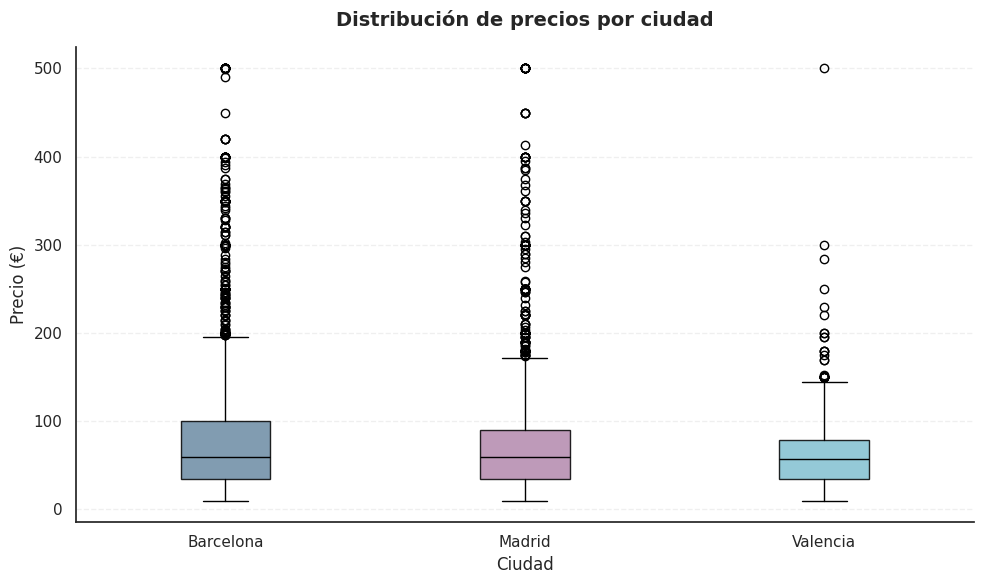

In [165]:
#Boxplot de precios por ciudad
fig, ax = plt.subplots(figsize=(10, 6))

orden   = ["Barcelona", "Madrid", "Valencia"]
colores = ["#6b8ba4", "#b388ad", "#82c0d0"]

datos = [df_limpio[df_limpio["ciudad"] == c]["precio"].dropna().values for c in orden]

bp = ax.boxplot(datos, patch_artist=True, tick_labels=orden,
                medianprops=dict(color="black", linewidth=1))

for patch, color in zip(bp["boxes"], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_title("Distribución de precios por ciudad", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Ciudad", fontsize=12)
ax.set_ylabel("Precio (€)", fontsize=12)
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

El boxplot permite comparar la distribución de precios entre las tres ciudades de forma visual. Las tres tienen medianas muy similares (alrededor de 60€ por noche) lo que indica que el precio habitual del mercado es comparable entre ciudades.

Barcelona destaca por tener la caja más alta (Q3=100 €) y el bigote superior más largo, llegando a los 200€, con bastante outliers por encima. Esto indica que hay una mayor presencia de inmuebles de precio elevado y más dispersión en el segmento alto.

Madrid tiene una caja similar a Barcelona pero más estrecha y con menos outliers altos, es ligeramente más homogéneo.

Valencia es la ciudad con la caja más compacta y con menos dispersión, los precios están más concentrados y hay menos inmuebles con importe elevado

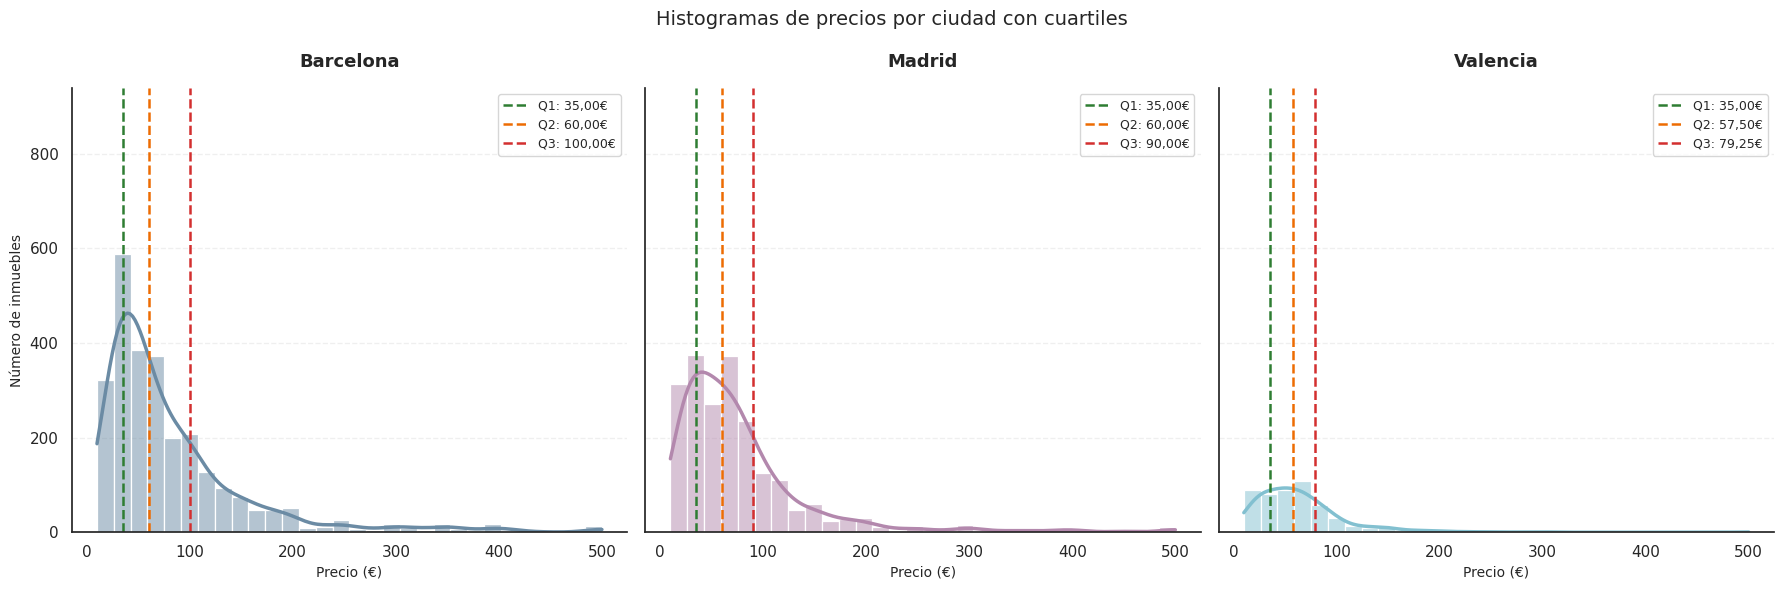

In [166]:
#Definimos el estilo base del gráfico y ajustamos el tamaño y grosor de los elementos.
sns.set_theme(style="white", context="notebook")

#Creamos la figura
fig,axes = plt.subplots(1,3, figsize=(18,6),sharey=True) #Usamos misma escala o hacemos densidad?

ciudades = ["Barcelona", "Madrid", "Valencia"]
colores  = ["#6b8ba4", "#b388ad", "#82c0d0"]

for i, (ciudad, color) in enumerate(zip(ciudades, colores)):
    datos = df_limpio[df_limpio["ciudad"] == ciudad]["precio"].dropna()

#Cuartiles
    Q1_c  = datos.quantile(0.25)
    Q2_c  = datos.quantile(0.50)
    Q3_c  = datos.quantile(0.75)

#Histograma + KDE. Usamos line_kws para que la curva KDE destaque sobre las barras
    sns.histplot(datos, bins=30, color=color, alpha=0.5, edgecolor="white", kde = True, line_kws = {'linewidth': 2.5}, ax=axes[i])

#Líneas de cuartiles
    axes[i].axvline(Q1_c, color="#2e7d32", linestyle="--", linewidth=1.8, label=f"Q1: {fmt(Q1_c, 2)}€")
    axes[i].axvline(Q2_c, color="#ed6c02", linestyle="--", linewidth=1.8, label=f"Q2: {fmt(Q2_c, 2)}€")
    axes[i].axvline(Q3_c, color="#d32f2f", linestyle="--", linewidth=1.8, label=f"Q3: {fmt(Q3_c, 2)}€")

#Títulos y etiquetas
    axes[i].set_title(ciudad, fontsize=13, pad=15, fontweight='bold')
    axes[i].set_xlabel("Precio (€)", fontsize = 10)
    axes[i].set_ylabel("Número de inmuebles", fontsize = 10)

#Ajustamos la escala Y para que no choque la leyenda con las barras
    axes[i].set_ylim(0, axes[i].get_ylim()[1]*1.15)

#Limpieza visual, rejilla solo horizontal y quitar marcos innecesarios
    axes[i].yaxis.grid(True, linestyle='--', alpha=0.6)
#Quita el borde superior y derecho
    sns.despine(ax=axes[i])

#Cuadrícula limpia en eje y
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)
    axes[i].legend(fontsize=9, frameon=True, loc='upper right')


plt.suptitle("Histogramas de precios por ciudad con cuartiles", fontsize=14)
plt.tight_layout()
plt.show()

Los histogramas confirman lo que hemos comentado en el boxplot. Las tres ciudades tienen una distribución sesgada hacia la derecha, es decir, la mayoría de inmuebles se concentran entre los 25 y 100 € por noche, con una cola larga de inmuebles de precio más elevado.

Barcelona tiene la cola más pronunciada hacia la derecha, con inmuebles que llegan hasta 500€/noche.

Valencia es la más concentrada, donde los inmuebles superiores a 150€ / noche son pocos.

Madrid está en un punto intermedio.

La curva KDE suaviza la distribución y permite ver de forma más clara el comportamiento de cada mercado, en los tres casos el pico está  por debajo de 50€ / noche.

In [167]:
#Variables necesarias para el gráfico - calculadas desde df_limpio
Q1 = df_limpio["precio"].quantile(0.25)
Q2 = df_limpio["precio"].quantile(0.50)
Q3 = df_limpio["precio"].quantile(0.75)
IQR= Q3 - Q1
limite_sup= Q3 + 1.5 * IQR

print(f"Q1={fmt(Q1)}€ | Q2={fmt(Q2)}€ | Q3={fmt(Q3)}€ | Límite sup={fmt(limite_sup)}€")

Q1=35€ | Q2=60€ | Q3=96€ | Límite sup=188€


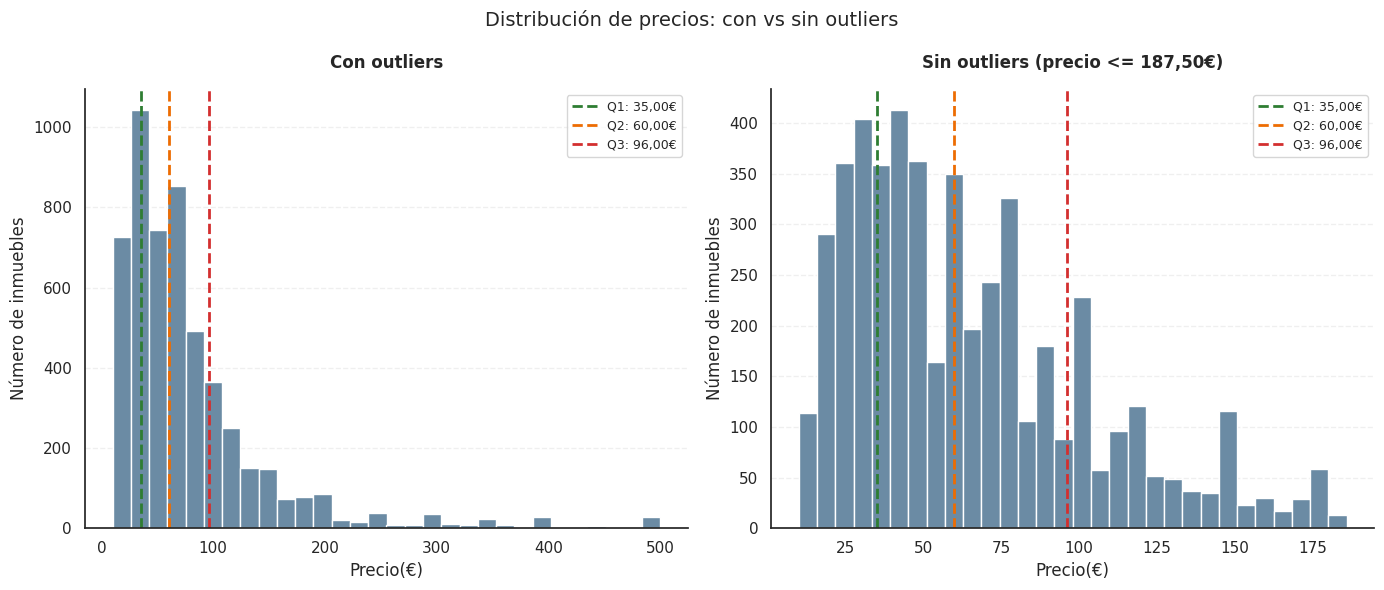

In [168]:
#Definimos el estilo base
sns.set_theme(style="white", context="notebook")

#Creamos la figura
fig,axes = plt.subplots(1,2, figsize=(14,6))

#Colores
color_barras = "#6b8ba4"

#Con outliers
axes[0].hist(df_limpio["precio"], bins=30, color = color_barras, edgecolor = "white")
axes[0].axvline(Q1, color="#2e7d32", linestyle="--", linewidth=2, label=f"Q1: {fmt(Q1, 2)}€")
axes[0].axvline(Q2, color="#ed6c02", linestyle="--", linewidth=2, label=f"Q2: {fmt(Q2, 2)}€")
axes[0].axvline(Q3, color="#d32f2f", linestyle="--", linewidth=2, label=f"Q3: {fmt(Q3, 2)}€")

axes[0].set_title("Con outliers", fontweight='bold', pad=15)
axes[0].set_xlabel("Precio(€)")
axes[0].set_ylabel("Número de inmuebles")
axes[0].yaxis.grid(True, linestyle='--', alpha=0.3)
sns.despine(ax=axes[0])
axes[0].legend(frameon=True, fontsize=9)

#sin outliers, primero calculamos los datos sin esto. Limite superior es importe de 187.5€
sin_outliers = df_limpio[df_limpio["precio"] <= limite_sup]
axes[1].hist(sin_outliers["precio"], bins=30, color = color_barras, edgecolor = "white")
axes[1].axvline(Q1, color="#2e7d32", linestyle="--", linewidth=2, label=f"Q1: {fmt(Q1, 2)}€")
axes[1].axvline(Q2, color="#ed6c02", linestyle="--", linewidth=2, label=f"Q2: {fmt(Q2, 2)}€")
axes[1].axvline(Q3, color="#d32f2f", linestyle="--", linewidth=2, label=f"Q3: {fmt(Q3, 2)}€")

axes[1].set_title(f"Sin outliers (precio <= {fmt(limite_sup, 2)}€)", fontweight="bold", pad=15)
axes[1].set_xlabel("Precio(€)")
axes[1].set_ylabel("Número de inmuebles")
axes[1].yaxis.grid(True, linestyle='--', alpha=0.3)
sns.despine(ax=axes[1])
axes[1].legend(frameon=True, fontsize=9)

plt.suptitle("Distribución de precios: con vs sin outliers", fontsize=14)
plt.tight_layout()
plt.show()

El gráfico de la izquierda muestra la distribución completa con outliers. La cola larga hacia la derecha y la escala hasta los 500€ dificulta ver donde se concentra la oferta habitual.

El gráfico de la derecha elimina los inmuebles por encima del límite superior IQR (187,5€) y nos da lugar a ver la distribución real del mercado, más simétrica y con la mayoría de inmuebles entre los 25 y 100€ por noche. Los cuartiles se ven con mucha más claridad.

Los outliers se mantienen en el análisis completo ya que se tratan de inmuebles de lujo que pueden ser relevantes para WhiteHosting. Este gráfico nos sirve para entender mejor la distribución del mercado habitual.

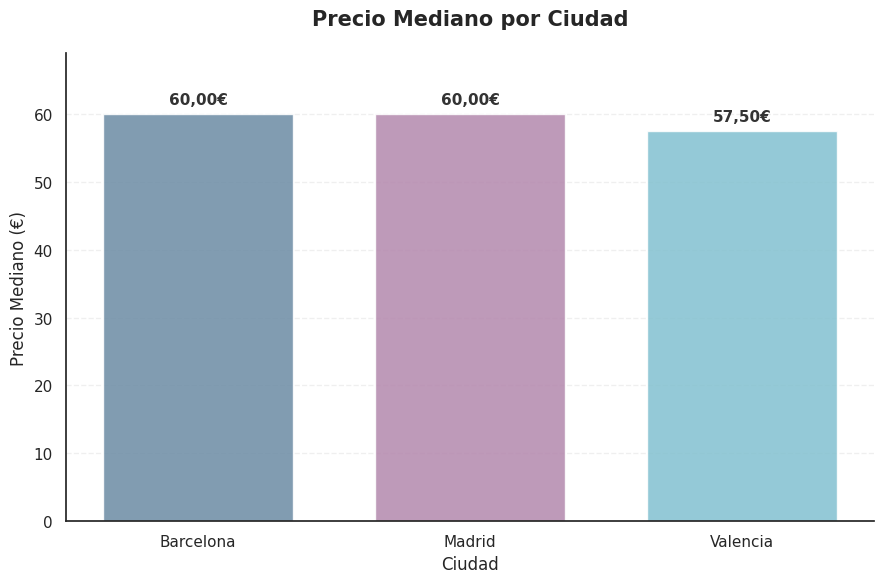

In [169]:
#Calculamos el precio mediano por ciudad

#Usamos mediana en lugar de media porque un solo inmueble de lujo puede distorsionar el precio medio de toda una ciudad
precio_ciudad = df_limpio.groupby("ciudad")["precio"].median().round(2)

#Definimos los colores
ciudades = ["Barcelona", "Madrid", "Valencia"]
colores  = ["#6b8ba4", "#b388ad", "#82c0d0"]
precios  = [precio_ciudad[c] for c in ciudades]

#Creamos el gráfico
plt.figure(figsize=(9, 6))
sns.set_theme(style="white", context="notebook")

bars = plt.bar(ciudades, precios, color=colores, alpha=0.85, edgecolor="white", width=0.7)

#Añadimos las etiquetas de datos sobre las barras
for i, precio in enumerate(precios):
    plt.text(i, precio + 1.5, f"{fmt(precio, 2)}€", ha="center", fontweight="bold", fontsize=11, color="#333333")

#Títulos y etiquetas
plt.title("Precio Mediano por Ciudad", fontsize=15, pad=20, fontweight='bold')
plt.xlabel("Ciudad", fontsize=12)
plt.ylabel("Precio Mediano (€)", fontsize=12)

#Limpieza visual y rejilla horizontal tenue
plt.gca().yaxis.grid(True, linestyle='--', alpha=0.3)
sns.despine()

#Ajuste de escala Y para que el texto no se corte arriba
plt.ylim(0, max(precios) * 1.15)

plt.tight_layout()
plt.show()

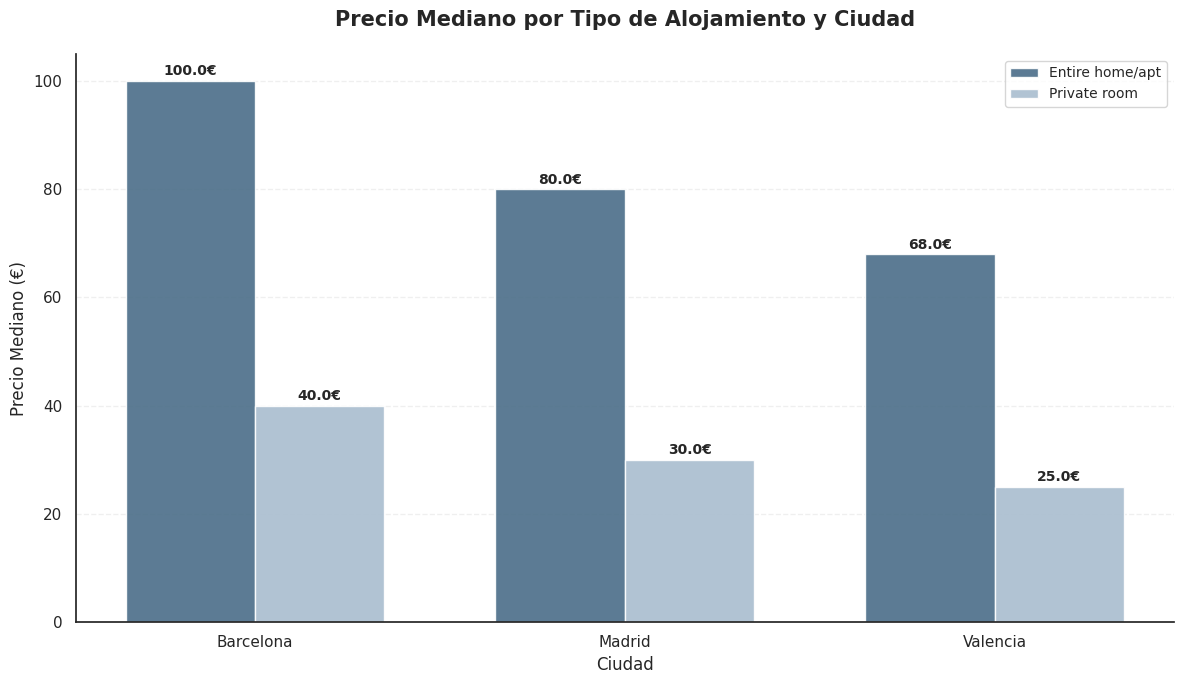

In [170]:
#Precio mediano por tipo de alojamiento y ciudad

#Filtramos solo los 2 tipos principales: apartamento completo y habitación privada
#Precio mediano .Se usa la mediana por coherencia metodológica con el resto del análisis
precio_tipo = df_limpio[df_limpio["tipo_alojamiento"].isin(["Entire home/apt", "Private room"])].groupby(["ciudad", "tipo_alojamiento"])["precio"].median().round(2)

#Definimos el orden y los datos en ese orden
ciudades = ["Barcelona", "Madrid", "Valencia"]
#Se protege contra combinaciones ausentes con NaN (la barra no se dibuja),
#en vez de un valor arbitrario que pintaría una barra falsa en silencio
entire  = [precio_tipo.get((a, "Entire home/apt"), np.nan) for a in ciudades]
private = [precio_tipo.get((a, "Private room"), np.nan)    for a in ciudades]

#Posiciones de las barras
x = np.arange(3)
width = 0.35

#Colores: para casas completas y para habitaciones
color_entire  = "#4a6d88"
color_private = "#a9bdcf"

sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(12, 7))

#Creamos las barras
barra1 = plt.bar(x - width/2, entire,  width, label="Entire home/apt", color=color_entire,  edgecolor="white", alpha=0.9)
barra2 = plt.bar(x + width/2, private, width, label="Private room",    color=color_private, edgecolor="white", alpha=0.9)

#Añadimos las etiquetas sobre cada barra
for i, (e, p) in enumerate(zip(entire, private)):
    if pd.notna(e):
        plt.text(i - width/2, e + 1, f"{e}€", ha="center", fontsize=10, fontweight="bold")
    if pd.notna(p):
        plt.text(i + width/2, p + 1, f"{p}€", ha="center", fontsize=10, fontweight="bold")

#Títulos y formato
plt.title("Precio Mediano por Tipo de Alojamiento y Ciudad", fontsize=15, pad=20, fontweight="bold")
plt.xlabel("Ciudad", fontsize=12)
plt.ylabel("Precio Mediano (€)", fontsize=12)
plt.xticks(x, ciudades)

#Leyenda y limpieza visual
plt.legend(frameon=True, loc="upper right", fontsize=10)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

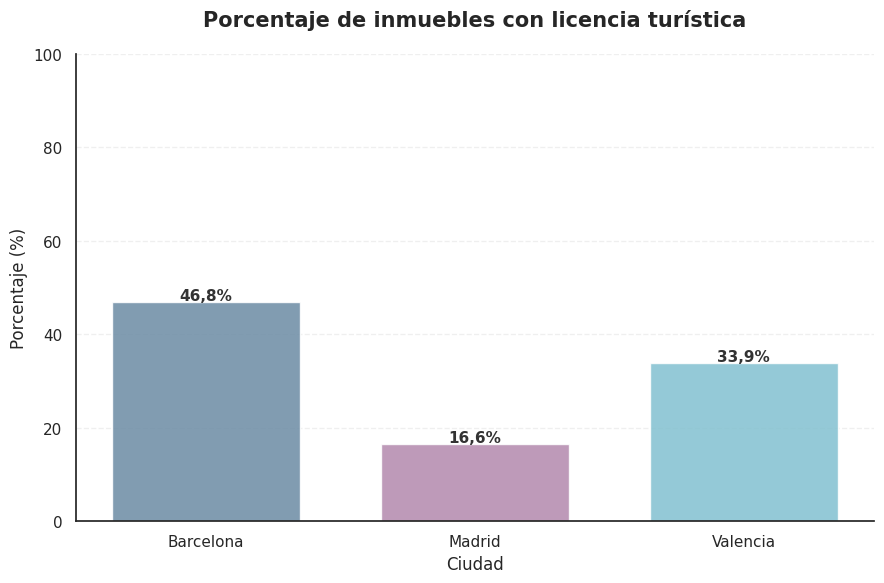

Porcentaje con licencia:
  Barcelona: 46,8%
  Madrid: 16,6%
  Valencia: 33,9%


In [171]:
# Porcentaje de inmuebles con licencia turística por ciudad
lic = df_limpio.groupby("ciudad")["con_licencia"].mean().round(4) * 100
ciudades = ["Barcelona", "Madrid", "Valencia"]
colores  = ["#6b8ba4", "#b388ad", "#82c0d0"]
valores  = [lic[a] for a in ciudades]

sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(9, 6))

bars = plt.bar(ciudades, valores, color=colores, alpha=0.85, edgecolor="white", width=0.7)

for i, val in enumerate(valores):
    texto = f"{val:.1f}".replace(".", ",") + "%"
    plt.text(i, val + 0.5, texto, ha="center", fontweight="bold", fontsize=11, color="#333333")

plt.title("Porcentaje de inmuebles con licencia turística", fontsize=15, pad=20, fontweight="bold")
plt.xlabel("Ciudad", fontsize=12)
plt.ylabel("Porcentaje (%)", fontsize=12)
plt.ylim(0, 100)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print("Porcentaje con licencia:")
for ciudad, val in zip(ciudades, valores):
    print(f"  {ciudad}: {fmt(val, 1).replace('.', ',')}%")

El porcentaje de inmuebles con licencia turistica refleja el grado de regulacion del mercado en cada ciudad. El indicador cubre **todos los tipos de alojamiento** (pisos enteros, habitaciones privadas y compartidas), porque aqui se usa como medida del contexto regulatorio del mercado, no como filtro de elegibilidad del fondo.

- **Barcelona (46,8%):** es la ciudad mas regulada. Casi la mitad de los inmuebles tiene licencia, lo que indica un mercado maduro pero con alta presion regulatoria.
- **Madrid (16,6%):** porcentaje bajo que refleja tanto una regulacion mas reciente como posibles bolsas de alquiler sin regularizar.
- **Valencia (33,9%):** nivel intermedio, regulacion mas flexible que Barcelona.

La licencia es un dato relevante para WhiteHosting porque marca el grado de presion regulatoria de cada mercado. Ver la celda de marco regulatorio.


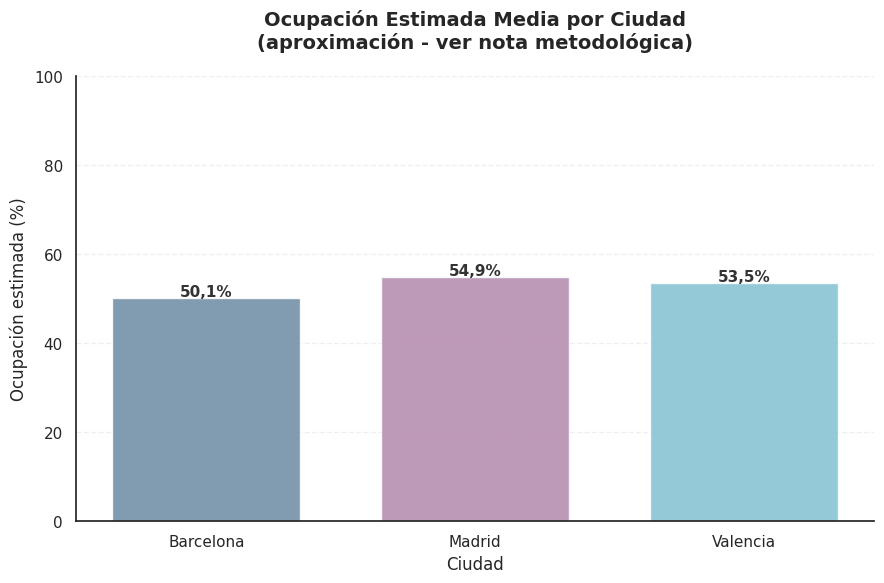

Ocupación estimada aproximada por ciudad (Pontia - availability_365):
  Barcelona: 50,1%
  Madrid: 54,9%
  Valencia: 53,5%

Nota: dato aproximado. La ocupación real se analiza con Inside Airbnb.


In [172]:
#AVISO: disponibilidad_365_dias mide días con calendario abierto, no días reservados
#Esta estimación de ocupación es aproximada y puede sobreestimar la ocupación real
#La ocupación real se calcula en la Parte 3.3 con Inside Airbnb

df_limpio["ocupacion_aprox"] = ((365 - df_limpio["disponibilidad_365_dias"]) / 365 * 100).round(1)

oc      = df_limpio.groupby("ciudad")["ocupacion_aprox"].mean().round(1)
ciudades = ["Barcelona", "Madrid", "Valencia"]
colores  = ["#6b8ba4", "#b388ad", "#82c0d0"]
valores  = [oc[c] for c in ciudades]

sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(9, 6))
for i, (ciudad, val, color) in enumerate(zip(ciudades, valores, colores)):
    plt.bar(ciudad, val, color=color, alpha=0.85, edgecolor="white", width=0.7)
    plt.text(i, val + 0.5, f"{fmt(val, 1)}%", ha="center",
             fontweight="bold", fontsize=11, color="#333333")

plt.title("Ocupación Estimada Media por Ciudad\n"
          "(aproximación - ver nota metodológica)",
          fontsize=14, pad=20, fontweight="bold")
plt.xlabel("Ciudad", fontsize=12)
plt.ylabel("Ocupación estimada (%)", fontsize=12)
plt.ylim(0, 100)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print("Ocupación estimada aproximada por ciudad (Pontia - availability_365):")
for ciudad, val in zip(ciudades, valores):
    print(f"  {ciudad}: {fmt(val, 1)}%")
print("\nNota: dato aproximado. La ocupación real se analiza con Inside Airbnb.")

**Marco regulatorio: Implicaciones para la estrategia de inversion de WhiteHosting**

El análisis de licencias no es solo estadístico: tiene implicaciones legales y económicas directas para una inversión de 300 millones de euros.

**Barcelona - riesgo alto:**
El Ayuntamiento de Barcelona ha anunciado que no renovará ninguna licencia turística cuando venzan en noviembre de 2028 (fuente: AirROI 2026). El Plan Especial Urbanístico de Alojamientos Turísticos (PEUAT) ya restringe la apertura de nuevos establecimientos en el centro. Recomendación: adquirir únicamente inmuebles que ya tengan la licencia turística histórica concedida y verificar su transmisibilidad antes de la compra. Evitar zonas de alta restricción sin licencia activa.

**Conclusión:** El porcentaje de inmuebles con licencia declarada es un indicador del grado de regulacion y de cumplimiento de cada mercado, medido sobre todos los tipos de alojamiento. Barcelona tiene el mayor porcentaje (46,8%), seguida de Valencia (33,9%) y Madrid (16,6%). Adquirir únicamente inmuebles con licencia activa limita el número de inmuebles disponibles para comprar pero elimina el riesgo de que una resolución administrativa inutilice el activo adquirido.

**Nota metodológica importante sobre el cálculo de ocupación:**

El indicador mostrado arriba (`Oc = (365 - availability_365) / 365`) es una **aproximación** que tiene una limitación conocida: `availability_365` mide los días que el anfitrión tiene el calendario **abierto para recibir reservas**, no los días efectivamente reservados.

Un valor de `availability_365 = 0` puede significar dos cosas opuestas:
- El apartamento está completamente lleno (todos los días reservados).
- El anfitrión ha bloqueado todas las fechas voluntariamente.

No hay forma de distinguir los dos casos con este campo. Por eso, en la integración de fuentes (Parte 4) se sustituye este método por la ocupación estimada de Inside Airbnb basada en `reviews_per_month`, que es más precisa al basarse en reseñas reales de huéspedes.

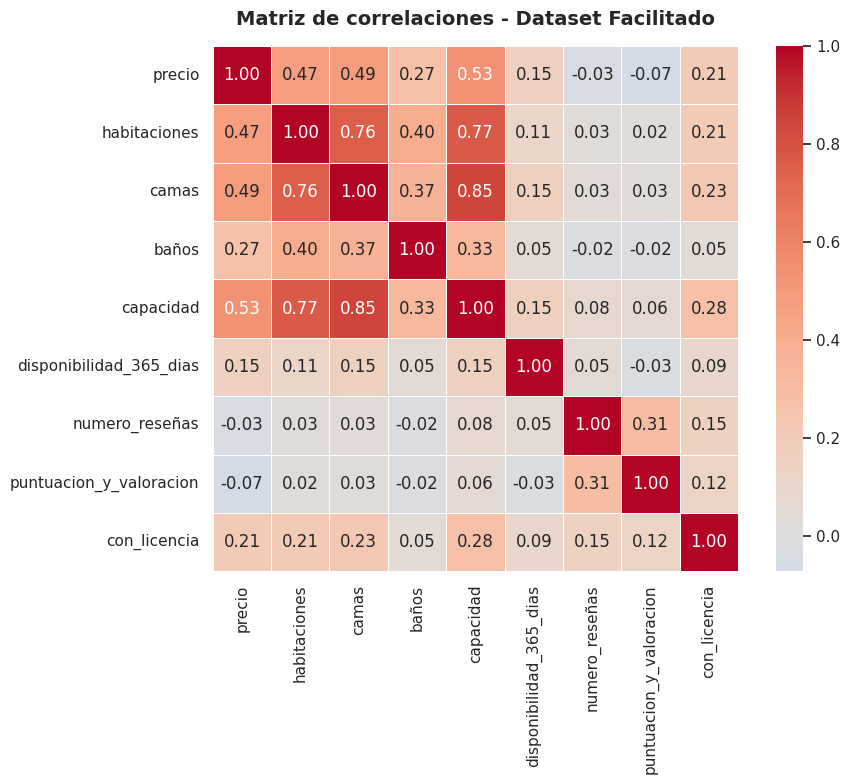

Correlación con precio (ordenada de mayor a menor):
  capacidad: 0,534
  camas: 0,490
  habitaciones: 0,474
  baños: 0,267
  con_licencia: 0,210
  disponibilidad_365_dias: 0,153
  numero_reseñas: -0,034
  puntuacion_y_valoracion: -0,072


In [173]:
#Matriz de correlaciones con el precio

#Nos permite identificar qué variables tienen más relación con el precio
cols_corr = ["precio", "habitaciones", "camas", "baños", "capacidad",
             "disponibilidad_365_dias", "numero_reseñas",
             "puntuacion_y_valoracion", "con_licencia"]
cols_ok   = [c for c in cols_corr if c in df_limpio.columns]
corr      = df_limpio[cols_ok].corr()

sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Matriz de correlaciones - Dataset Facilitado",
          fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

print("Correlación con precio (ordenada de mayor a menor):")
resultado = corr["precio"].drop("precio").sort_values(ascending=False).round(3)
for variable, valor in resultado.items():
    print(f"  {variable}: {fmt(valor, 3)}")

Las variables de capacidad,habitaciones, cama y baños son las que más correlacionan con el precio, por ejemplo, a más capacidad, mayor precio.

La puntuación tiene correlación baja, lo que sugiere que el precio está más determinado por características físicas del inmueble que por la opinión de los huéspedes.

Top 5 barrios más caros por ciudad (precio mediano, mín. 10 inmuebles):
  Barcelona | Diagonal Mar i el Front Marítim del Poblenou | 106,50€ | n=24
  Barcelona | la Dreta de l'Eixample              | 100,00€ | n=288
  Barcelona | la Vila Olímpica del Poblenou       | 99,00€ | n=21
  Barcelona | Sant Gervasi - Galvany              | 72,50€ | n=46
  Barcelona | Sant Gervasi - la Bonanova          | 70,00€ | n=10
  Madrid | Goya                                | 99,00€ | n=30
  Madrid | Recoletos                           | 87,00€ | n=30
  Madrid | Almagro                             | 85,00€ | n=18
  Madrid | Castellana                          | 85,00€ | n=15
  Madrid | Sol                                 | 79,00€ | n=163
  Valencia | EL CARME                            | 75,00€ | n=15
  Valencia | LA ROQUETA                          | 75,00€ | n=16
  Valencia | CABANYAL-CANYAMELAR                 | 70,00€ | n=52
  Valencia | SANT FRANCESC                       | 65,00€ | n=27
  Valencia

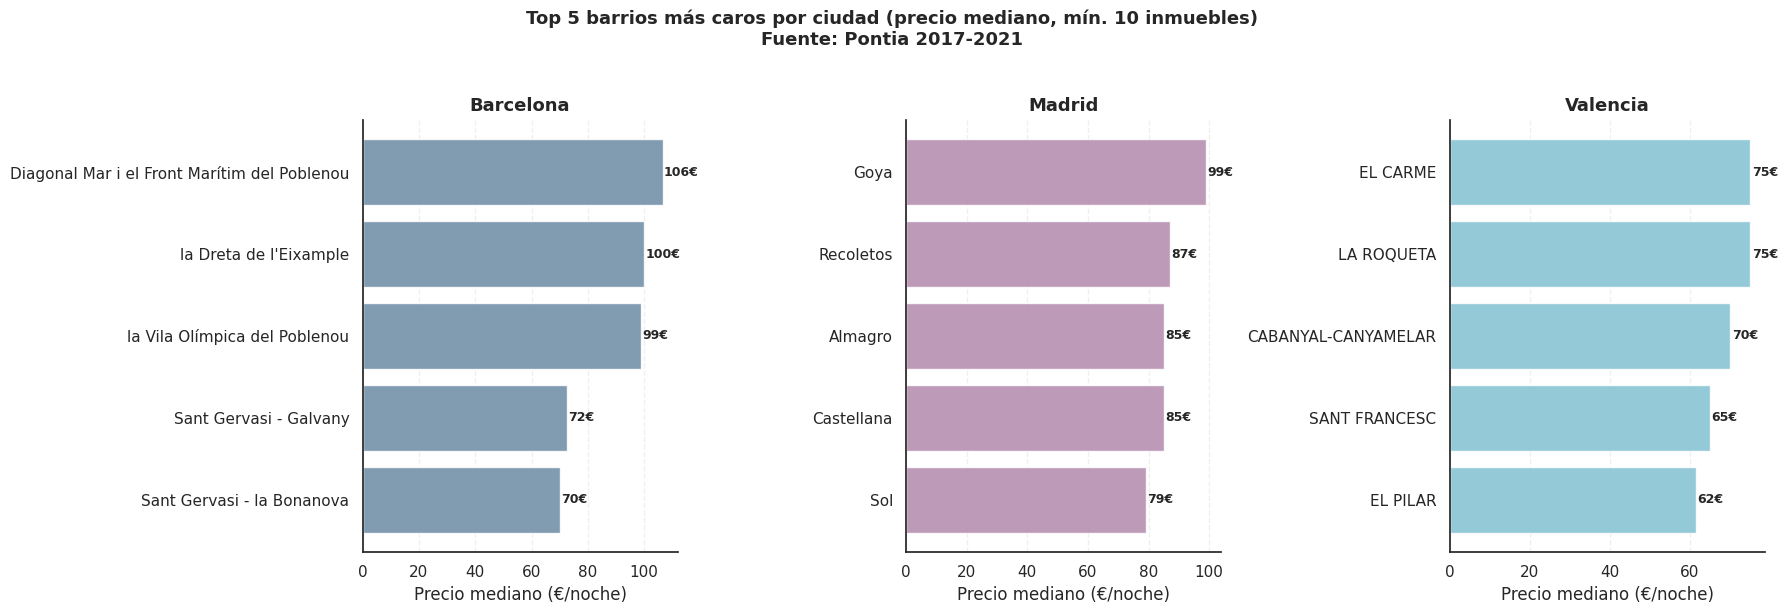

In [174]:
#Top 5 barrios más caros por ciudad (precio mediano, mínimo 10 inmuebles)

#Hacemos el ranking por ciudad en lugar de global para que aparezcan las 3 ciudades
#Con un ranking global Valencia nunca aparece porque sus precios son más bajos que BCN y MAD
#Usamos mediana en lugar de media porque un solo inmueble de lujo puede
#distorsionar el precio medio de todo un barrio

top_barrios = []
for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    sub = df_limpio[df_limpio["ciudad"] == ciudad]
    top_ciudad = (sub.groupby("barrio")["precio"]
                  .agg(["median", "count"])
                  .reset_index())
    top_ciudad.columns = ["barrio", "precio_mediano", "n"]
    top_ciudad = top_ciudad[top_ciudad["n"] >= 10].nlargest(5, "precio_mediano")
    top_ciudad["ciudad"] = ciudad
    top_barrios.append(top_ciudad)

top_barrios = pd.concat(top_barrios, ignore_index=True)

print("Top 5 barrios más caros por ciudad (precio mediano, mín. 10 inmuebles):")
for _, fila in top_barrios[["ciudad", "barrio", "precio_mediano", "n"]].iterrows():
    print(f"  {fila['ciudad']} | {fila['barrio']:<35} | "
          f"{fmt(fila['precio_mediano'], 2)}€ | n={fmt(fila['n'])}")

#Gráfico con un subplot por ciudad para mayor claridad visual
colores_ciudad = {"Barcelona": "#6b8ba4", "Madrid": "#b388ad", "Valencia": "#82c0d0"}

sns.set_theme(style="white", context="notebook")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ciudad in enumerate(["Barcelona", "Madrid", "Valencia"]):
    sub = top_barrios[top_barrios["ciudad"] == ciudad].sort_values("precio_mediano")
    axes[i].barh(sub["barrio"], sub["precio_mediano"],
                 color=colores_ciudad[ciudad], alpha=0.85, edgecolor="white")
    for j, val in enumerate(sub["precio_mediano"]):
        axes[i].text(val + 0.5, j, f"{fmt(val)}€", va="center", fontsize=9, fontweight="bold")
    axes[i].set_title(ciudad, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Precio mediano (€/noche)")
    axes[i].xaxis.grid(True, linestyle="--", alpha=0.3)
    sns.despine(ax=axes[i])

fig.suptitle("Top 5 barrios más caros por ciudad (precio mediano, mín. 10 inmuebles)\nFuente: Pontia 2017-2021",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

El ranking se realiza por ciudad en lugar de global para garantizar representación de las tres ciudades en el análisis. Con un ranking global, Valencia nunca aparecería en el top porque sus precios son sistemáticamente más bajos que Barcelona y Madrid.
Se usa el precio mediano en lugar de la media porque en barrios con pocos inmuebles (mínimo 10 para este análisis) un único apartamento de lujo a 500€/noche puede elevar artificialmente el precio medio del barrio, dando una imagen distorsionada del mercado real. La mediana refleja el precio del inmueble típico de cada barrio.
Estos precios corresponden al dataset de Pontia (2017-2021) y son inferiores a los precios actuales de mercado (scraping 2026). El análisis de precios actuales por barrio se realiza en la Parte 5 con los datos de Inside Airbnb.

## 3.2 EDA del dataset de scraping de Airbnb

El scraping aporta al análisis tres cosas que ninguna otra fuente puede dar:

- **Precio actual (2026):** Barcelona 212€ y Madrid 128€ de mediana. Son los precios reales que ve un huesped hoy al buscar en Airbnb.
- **Estacionalidad:** como varía el precio según el mes de check-in a lo largo de un año completo.
- **Volatilidad:** si el precio de un mismo apartamento para la misma fecha cambia según el día que se consulte, lo que evidencia el pricing dinámico de Airbnb.

Limitaciones del scraping:
- Sin coordenadas geográficas: el scraping no captura latitud ni longitud.
- Sin barrio para Barcelona: el nombre del anuncio dice "Apartamento en Barcelona" sin especificar zona.
- Sin ocupación ni valoraciones: Airbnb no muestra esos datos en el listado de resultados.
- Valencia: el scraping capturó Alicante en lugar de Valencia capital (ver nota en seccion 1.3).

### Criterio del precio de referencia por ciudad

Todo el proyecto usa la **mediana** como estadístico de precio (es robusta frente a los inmuebles de lujo, que arrastran la media hacia arriba). Para el precio de referencia por ciudad - la variable que alimenta el cálculo de Ra - se aplica ese mismo criterio sobre **la mejor fuente disponible en cada ciudad**:

| Ciudad | Precio ref. | Fuente | Por qué esa fuente |
|---|---|---|---|
| Barcelona | **212€** | Mediana scraping 2026, solo alojamientos completos y tras deduplicar por id de anuncio | Inside Airbnb no publica precio para Barcelona (campo 100% vacío) |
| Madrid | **128€** | Mediana scraping 2026, solo alojamientos completos y tras deduplicar por id de anuncio | Scraping representativo: ciudad completa, 7 días de consulta, coherente con Inside Airbnb |
| Valencia | **97€** | Mediana Inside Airbnb septiembre 2025 (5.782 apartamentos completos) | Su scraping tiene **sesgo de muestra demostrable**: una sola fecha (17/06/2026) y 4 zonas dominadas por Ciutat Vella (~30% de los registros, centro turístico premium), lo que infla su mediana muy por encima de los 97€ del mercado completo (la celda de comparación de fuentes imprime el valor exacto de cada ejecución; tras la deduplicación ronda los 170€) |

Es la misma lógica de **jerarquía de fuentes** que se aplica en el resto del proyecto (precio por barrio en la Parte 4.4, niveles 1-4 del ROI en la Parte 7.2): cuando la fuente preferente falla o está sesgada, se usa la mejor alternativa disponible y se documenta. Las estadísticas y gráficas de este EDA **describen cada muestra tal cual es** (por eso Valencia aparece por encima de Madrid en el scraping); la referencia para el análisis de rentabilidad es la tabla anterior, y la celda de verificación siguiente comprueba con un `assert` que las constantes coinciden con las medianas reales.

In [175]:
#Estadísticas de precio por ciudad (scraping)
#Se calculan sobre ALOJAMIENTOS COMPLETOS (sin habitaciones), el universo
#comparable con el producto de inversión de WhiteHosting. Mezclar habitaciones
#(45€/noche) con apartamentos (130-218€) distorsionaría media y mediana.
apt_eda = df_scraping[~df_scraping["tipo_aprox"].isin(TIPOS_HABITACION)]

estadisticas_scrap = apt_eda.groupby("ciudad")["precio_limpio"].agg(["mean","median","std"]).round(2)
estadisticas_scrap.columns = ["Media", "Mediana", "Std"]

print("Estadísticas de precio por ciudad (scraping, alojamientos completos):")
for ciudad, fila in estadisticas_scrap.iterrows():
    print(f"  {ciudad}: Media={fmt(fila['Media'], 2)}€ | "
          f"Mediana={fmt(fila['Mediana'], 2)}€ | "
          f"Std={fmt(fila['Std'], 2)}€")

#Por qué la mediana de Valencia sale por encima de la de Madrid:
#NO es un efecto del mercado sino de la muestra. El scraping de Valencia se
#hizo en una sola fecha (17/06/2026) y en 4 zonas, con Ciutat Vella (centro
#turístico premium) concentrando ~30% de los registros. Se demuestra abajo:
print("\nDesglose de Valencia por zona scrapeada:")
print(apt_eda[apt_eda["ciudad"] == "Valencia"]
      .groupby("barrio")["precio_limpio"]
      .agg(mediana="median", n="count").round(0).to_string())
print("\nPor este sesgo de zona y fecha, el precio de referencia de Valencia")
print("para el Ra NO sale del scraping sino de Inside Airbnb: 97€/noche")
print("(mediana de 5.782 apartamentos completos con coordenadas verificadas).")

Estadísticas de precio por ciudad (scraping, alojamientos completos):
  Barcelona: Media=227,24€ | Mediana=212,00€ | Std=123,98€
  Madrid: Media=145,51€ | Mediana=128,00€ | Std=88,15€
  Valencia: Media=185,71€ | Mediana=172,00€ | Std=104,04€

Desglose de Valencia por zona scrapeada:
                     mediana      n
barrio                             
Benimaclet             164.0   7655
Cabanyal Canyamelar    200.0  14637
Ciutat Vella           168.0  64081
Eixample               166.0   6797

Por este sesgo de zona y fecha, el precio de referencia de Valencia
para el Ra NO sale del scraping sino de Inside Airbnb: 97€/noche
(mediana de 5.782 apartamentos completos con coordenadas verificadas).


In [176]:
#Verificación del criterio MEDIANA de los precios de referencia

#Comprueba que las constantes 212/128 coinciden con la mediana real del
#scraping de alojamientos completos (si el dato cambiara, este assert avisa)
med_check = apt_eda.groupby("ciudad")["precio_limpio"].median()
print("Medianas del scraping (alojamientos completos):")
print(med_check.round(0).to_string())

#comprobación coincidentes
assert round(med_check["Barcelona"]) == PRECIO_REF_CIUDAD["Barcelona"], \
    f"BCN: mediana={med_check['Barcelona']:.0f}, constante={PRECIO_REF_CIUDAD['Barcelona']}"
assert round(med_check["Madrid"]) == PRECIO_REF_CIUDAD["Madrid"], \
    f"MAD: mediana={med_check['Madrid']:.0f}, constante={PRECIO_REF_CIUDAD['Madrid']}"
print(f"\nOK: las constantes de precio ({PRECIO_REF_CIUDAD['Barcelona']}/{PRECIO_REF_CIUDAD['Madrid']}) "
      "son la MEDIANA verificada del")
print("scraping de alojamientos completos. Valencia usa 97 (mediana Inside Airbnb).")

#Estos valores son el “precio techo” que usamos en la fórmula del RA (Annual Revenue)
#Barcelona y Madrid usan la MEDIANA real del scraping (alojamientos completos)
#Valencia NO usa su scraping porque está sesgado; en su lugar se usa la
#mediana de Inside Airbnb (97 €/noche), que es mucho más representativa
precio_referencia_ciudad = pd.DataFrame({
    "ciudad": ["Barcelona", "Madrid", "Valencia"],
    "precio_referencia": [
        round(med_check["Barcelona"]),
        round(med_check["Madrid"]),
        97,
    ],
    "fuente": [
        "Mediana scraping 2026 (alojamientos completos)",
        "Mediana scraping 2026 (alojamientos completos)",
        "Mediana Inside Airbnb 2025 (scraping propio descartado por sesgo)",
    ],
})

#Tabla de referencia de precio por ciudad. Se calcula y se deja documentada
#aqui, pero NO se exporta a CSV: el cuadro de mando no la consume (los precios
#que usa Power BI son los reales por barrio y tipologia de la Parte 5).
print("\nPrecio de referencia por ciudad (uso interno del cuaderno):")
print(precio_referencia_ciudad.to_string(index=False))

Medianas del scraping (alojamientos completos):
ciudad
Barcelona    212.0
Madrid       128.0
Valencia     172.0

OK: las constantes de precio (212/128) son la MEDIANA verificada del
scraping de alojamientos completos. Valencia usa 97 (mediana Inside Airbnb).

Precio de referencia por ciudad (uso interno del cuaderno):
   ciudad  precio_referencia                                                            fuente
Barcelona                212                    Mediana scraping 2026 (alojamientos completos)
   Madrid                128                    Mediana scraping 2026 (alojamientos completos)
 Valencia                 97 Mediana Inside Airbnb 2025 (scraping propio descartado por sesgo)


In [177]:
#Impacto de los outliers en el precio de mercado
#Este análisis muestra por qué usamos la MEDIANA en lugar de la media.
#En el scraping aparecen precios de lujo muy altos (hasta 10.014€),
#que inflan la media y hacen que parezca que el mercado es más caro de lo que es.

print("Impacto del segmento lujo en el precio de mercado (scraping 2026):")

#Se usa la constante global TIPOS_HABITACION (Parte 1.1)
df_apt_m = df_scraping[~df_scraping["tipo_aprox"].isin(TIPOS_HABITACION)].copy()


for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    sub = df_apt_m[df_apt_m["ciudad"] == ciudad]["precio_limpio"]
    if len(sub) == 0:
        print(f"  {ciudad}: sin datos de apartamentos")
        continue
    media   = sub.mean()
    mediana = sub.median()
    diff    = media - mediana
    print(f"  {ciudad}:")
    print(f"    Media:      {fmt(media)}€/noche (inflada por outliers)")
    print(f"    Mediana:    {fmt(mediana)}€/noche (precio del mercado típico)")
    print(f"    Diferencia: {fmt(diff)}€ más alta la media por los outliers")

print("\nConclusión: usamos mediana de forma consistente en todo el proyecto")
print("para representar el precio típico del mercado sin distorsión de outliers.")

Impacto del segmento lujo en el precio de mercado (scraping 2026):
  Barcelona:
    Media:      227€/noche (inflada por outliers)
    Mediana:    212€/noche (precio del mercado típico)
    Diferencia: 15€ más alta la media por los outliers
  Madrid:
    Media:      146€/noche (inflada por outliers)
    Mediana:    128€/noche (precio del mercado típico)
    Diferencia: 18€ más alta la media por los outliers
  Valencia:
    Media:      186€/noche (inflada por outliers)
    Mediana:    172€/noche (precio del mercado típico)
    Diferencia: 14€ más alta la media por los outliers

Conclusión: usamos mediana de forma consistente en todo el proyecto
para representar el precio típico del mercado sin distorsión de outliers.


Aunque en la limpieza eliminamos los outliers extremos (precios imposibles o errores),siguen existiendo apartamentos de lujo reales dentro del mercado.  
Estos pisos de gama alta no se eliminan porque no son errores, pero sí hacen que la media suba artificialmente.

Esto se ve en el scraping de 2026:

- **Barcelona**: la media es 15€ más alta que la mediana  
- **Madrid**: la media es 18€ más alta  
- **Valencia**: la media es 14€ más alta  

La **mediana**, en cambio:

- no se mueve por esos valores altos,
- refleja el precio típico del mercado,
- y es mucho más estable entre ciudades.

**Conclusión:**  
Usamos la mediana de forma consistente en todo el proyecto porque es la medida que mejor representa el precio real del mercado sin la distorsión del segmento lujo.

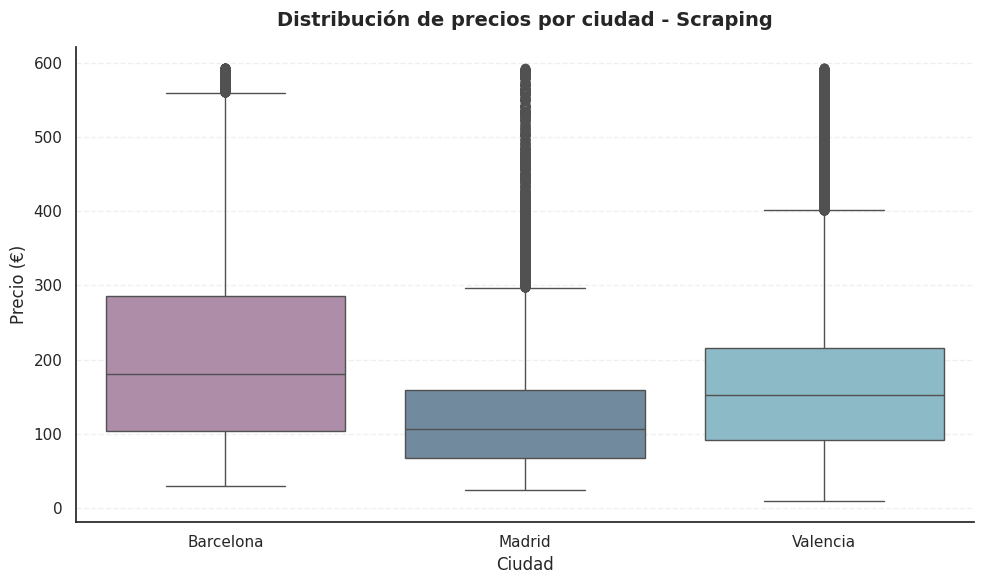

In [178]:
#Boxplot de precios por ciudad, scraping
plt.figure(figsize=(10, 6))
sns.set_theme(style="white", context="notebook")
sns.boxplot(data=df_scraping, x="ciudad", y="precio_limpio", hue="ciudad",
            order=["Barcelona", "Madrid", "Valencia"],
            palette=["#6b8ba4", "#b388ad", "#82c0d0"], legend=False)
plt.title("Distribución de precios por ciudad - Scraping", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Ciudad")
plt.ylabel("Precio (€)")
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

El boxplot del scraping muestra la distribución de precios reales de mercado.

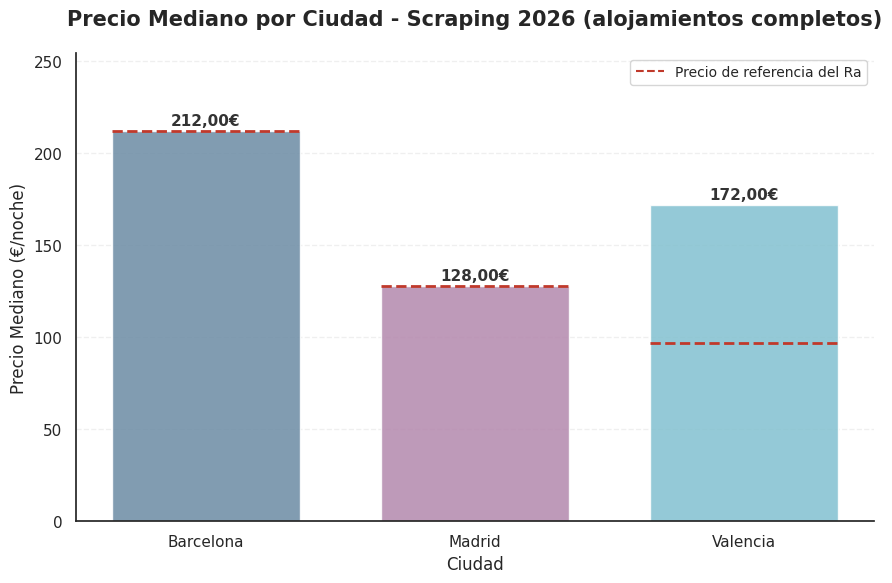

In [179]:
#Precio mediano por ciudad, scraping (alojamientos completos)
#Misma gráfica que en el EDA de Pontia para poder comparar fuentes.
#Se usa la mediana por coherencia metodológica con el resto del análisis
precio_ciudad_scrap = apt_eda.groupby("ciudad")["precio_limpio"].median().round(2)

ciudades = ["Barcelona", "Madrid", "Valencia"]
colores  = ["#6b8ba4", "#b388ad", "#82c0d0"]
precios  = [precio_ciudad_scrap[c] for c in ciudades]

plt.figure(figsize=(9, 6))
sns.set_theme(style="white", context="notebook")
plt.bar(ciudades, precios, color=colores, alpha=0.85, edgecolor="white", width=0.7)

for i, precio in enumerate(precios):
    plt.text(i, precio + 3, f"{fmt(precio, 2)}€", ha="center",
             fontweight="bold", fontsize=11, color="#333333")

#Marcamos el precio de REFERENCIA de cada ciudad (constante global
#PRECIO_REF_CIUDAD, Parte 1.1): coincide con la barra en BCN y MAD;
#en Valencia es 97€ (mediana Inside Airbnb)
for i, c in enumerate(ciudades):
    plt.hlines(PRECIO_REF_CIUDAD[c], i - 0.35, i + 0.35,
               colors="#c0392b", linestyles="--", linewidth=2)
plt.plot([], [], color="#c0392b", linestyle="--", label="Precio de referencia del Ra")
plt.legend(frameon=True, loc="upper right", fontsize=10)

plt.title("Precio Mediano por Ciudad - Scraping 2026 (alojamientos completos)",
          fontsize=15, pad=20, fontweight="bold")
plt.xlabel("Ciudad", fontsize=12)
plt.ylabel("Precio Mediano (€/noche)", fontsize=12)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.ylim(0, max(precios) * 1.2)
plt.tight_layout()
plt.show()

La gráfica replica la del EDA de Pontia para comparar fuentes: el mercado de 2026 multiplica por 2-3 los precios históricos de 2017-2021. La línea roja marca el **precio de referencia** que usa el cálculo de Ra: coincide con la mediana en Barcelona (212€) y Madrid (128€), pero en Valencia queda muy por debajo de la barra (97€ frente a los 172€ de su scraping sesgado) porque su referencia sale de Inside Airbnb y no del scraping, por el sesgo de muestra explicado arriba. Tener las dos cosas en la misma gráfica hace visible la decisión en lugar de esconderla.

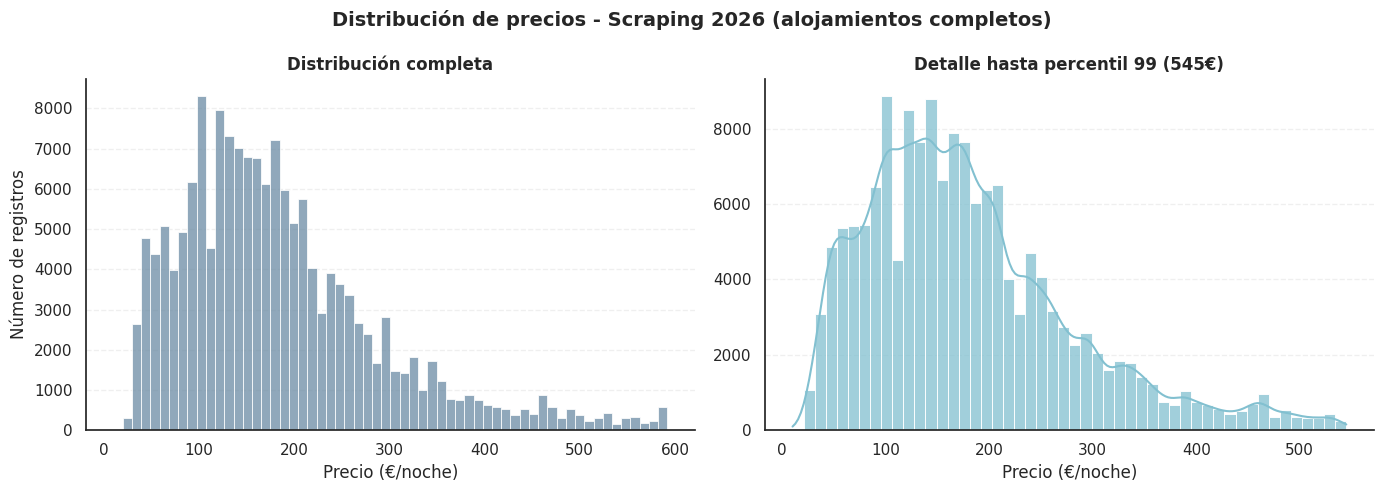

In [180]:
#Distribución del precio en el scraping (alojamientos completos)
#Como en Pontia: histograma completo y detalle hasta el percentil 99
limite_p99 = apt_eda["precio_limpio"].quantile(0.99)

sns.set_theme(style="white", context="notebook")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(apt_eda["precio_limpio"], bins=60, color="#6b8ba4",
             alpha=0.75, edgecolor="white", ax=axes[0])
axes[0].set_title("Distribución completa", fontweight="bold")
axes[0].set_xlabel("Precio (€/noche)")
axes[0].set_ylabel("Número de registros")

sns.histplot(apt_eda[apt_eda["precio_limpio"] <= limite_p99]["precio_limpio"],
             bins=50, color="#82c0d0", alpha=0.75, edgecolor="white",
             kde=True, ax=axes[1])
axes[1].set_title(f"Detalle hasta percentil 99 ({fmt(limite_p99)}€)", fontweight="bold")
axes[1].set_xlabel("Precio (€/noche)")
axes[1].set_ylabel("")

for ax in axes:
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.suptitle("Distribución de precios - Scraping 2026 (alojamientos completos)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

La distribución del scraping tiene la misma forma que la de Pontia (asimetría positiva con cola larga hacia los precios altos), lo que confirma que la mediana sigue siendo el estadístico adecuado también en los datos de 2026. La diferencia es que aquí no existe el tope artificial de 500€ del buscador de Pontia: la cola es real.

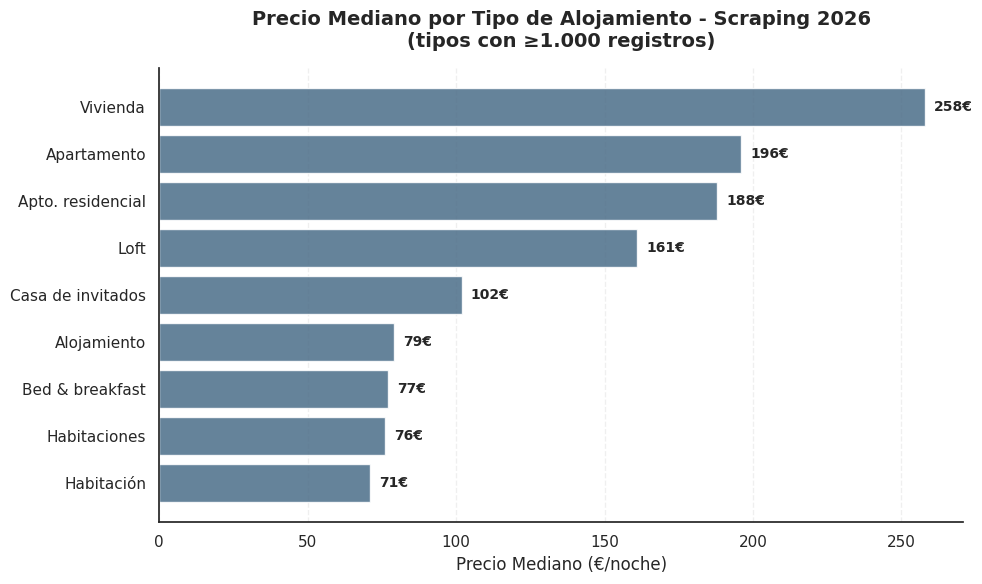

Nota: las habitaciones (~45-60€) cuestan 2-4 veces menos que un
alojamiento completo. Por eso las estadísticas de referencia se
calculan SOLO sobre alojamientos completos: mezclar ambos produciría
una mediana que no representa a ninguno de los dos mercados.


In [181]:
#Precio mediano por tipo de alojamiento, scraping
#Equivalente a la gráfica de tipos del EDA de Pontia. El scraping no trae
#habitaciones ni capacidad, así que el tipo extraído del nombre es la única
#característica del inmueble disponible para explicar el precio
tipos_n = df_scraping["tipo_aprox"].value_counts()
tipos_relevantes = tipos_n[tipos_n >= 1000].index   #solo tipos con volumen

precio_tipo_scrap = (df_scraping[df_scraping["tipo_aprox"].isin(tipos_relevantes)]
                     .groupby("tipo_aprox")["precio_limpio"]
                     .median().round(0).sort_values())

sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(10, 6))
plt.barh(precio_tipo_scrap.index, precio_tipo_scrap.values,
         color="#4a6d88", alpha=0.85, edgecolor="white")
for i, v in enumerate(precio_tipo_scrap.values):
    plt.text(v + 3, i, f"{fmt(v)}€", va="center", fontweight="bold", fontsize=10)

plt.title("Precio Mediano por Tipo de Alojamiento - Scraping 2026\n(tipos con ≥1.000 registros)",
          fontsize=14, pad=15, fontweight="bold")
plt.xlabel("Precio Mediano (€/noche)", fontsize=12)
plt.gca().xaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print("Nota: las habitaciones (~45-60€) cuestan 2-4 veces menos que un")
print("alojamiento completo. Por eso las estadísticas de referencia se")
print("calculan SOLO sobre alojamientos completos: mezclar ambos produciría")
print("una mediana que no representa a ninguno de los dos mercados.")

El patrón replica el de Pontia: el alojamiento completo (apartamento, loft, vivienda) duplica o triplica el precio de una habitación. Esta gráfica es la justificación visual de por qué el precio de referencia se calcula solo sobre alojamientos completos, que es el producto en el que invierte WhiteHosting.

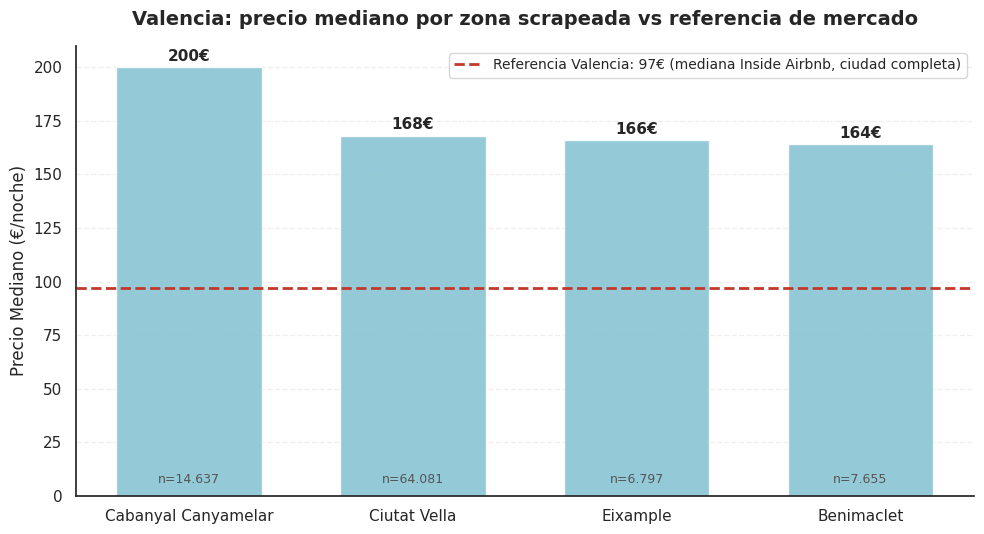

Ciutat Vella concentra el 68,8% de la muestra de Valencia.
Todas las zonas scrapeadas están por encima de la mediana de la ciudad
completa (97€, Inside Airbnb): la muestra es céntrica y turística, no
representativa del mercado valenciano. Por eso el precio de referencia
de Valencia sale de Inside Airbnb y su scraping se reserva para el
análisis de estacionalidad.


In [182]:
#Mediana por zona scrapeada de Valencia: evidencia del sesgo de muestra
#El scraping de Valencia (17/06/2026) se hizo por 4 zonas, no a ciudad
#completa como Madrid y Barcelona. Esta gráfica documenta el sesgo que
#justifica usar Inside Airbnb (97€) como referencia de Valencia
vlc = apt_eda[apt_eda["ciudad"] == "Valencia"]
zonas = (vlc.groupby("barrio")["precio_limpio"]
         .agg(mediana="median", n="count")
         .sort_values("mediana", ascending=False))

sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(10, 5.5))
bars = plt.bar(zonas.index, zonas["mediana"],
               color="#82c0d0", alpha=0.85, edgecolor="white", width=0.65)
for i, (mediana, n) in enumerate(zip(zonas["mediana"], zonas["n"])):
    plt.text(i, mediana + 3, f"{fmt(mediana)}€", ha="center", fontweight="bold", fontsize=11)
    plt.text(i, 6, f"n={fmt(n)}", ha="center", fontsize=9, color="#555555")

plt.axhline(97, color="#c0392b", linestyle="--", linewidth=2,
            label="Referencia Valencia: 97€ (mediana Inside Airbnb, ciudad completa)")
plt.legend(frameon=True, loc="upper right", fontsize=10)

plt.title("Valencia: precio mediano por zona scrapeada vs referencia de mercado",
          fontsize=14, pad=15, fontweight="bold")
plt.ylabel("Precio Mediano (€/noche)", fontsize=12)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

pct_cv = zonas.loc["Ciutat Vella", "n"] / zonas["n"].sum() * 100 if "Ciutat Vella" in zonas.index else 0
print(f"Ciutat Vella concentra el {fmt(pct_cv, 1)}% de la muestra de Valencia.")
print("Todas las zonas scrapeadas están por encima de la mediana de la ciudad")
print("completa (97€, Inside Airbnb): la muestra es céntrica y turística, no")
print("representativa del mercado valenciano. Por eso el precio de referencia")
print("de Valencia sale de Inside Airbnb y su scraping se reserva para el")
print("análisis de estacionalidad.")

Esta es la gráfica que cierra la discusión metodológica: **todas** las zonas scrapeadas de Valencia superan la mediana de la ciudad completa (línea roja, 97€ de Inside Airbnb). No es que Valencia sea más cara que Madrid: es que su muestra de scraping es el centro turístico consultado en junio. Detectar este sesgo comparando fuentes (igual que se detectó el incidente de Alicante) es precisamente el tipo de control de calidad que aporta trabajar con tres fuentes independientes.

Ventana de estacionalidad por ciudad (12 primeros meses de check-in de cada una):
  Barcelona: 2026-04-30 a 2027-04-29
  Madrid: 2026-04-30 a 2027-04-29
  Valencia: 2026-06-16 a 2027-06-15
Registros fuera de ventana excluidos: 1402


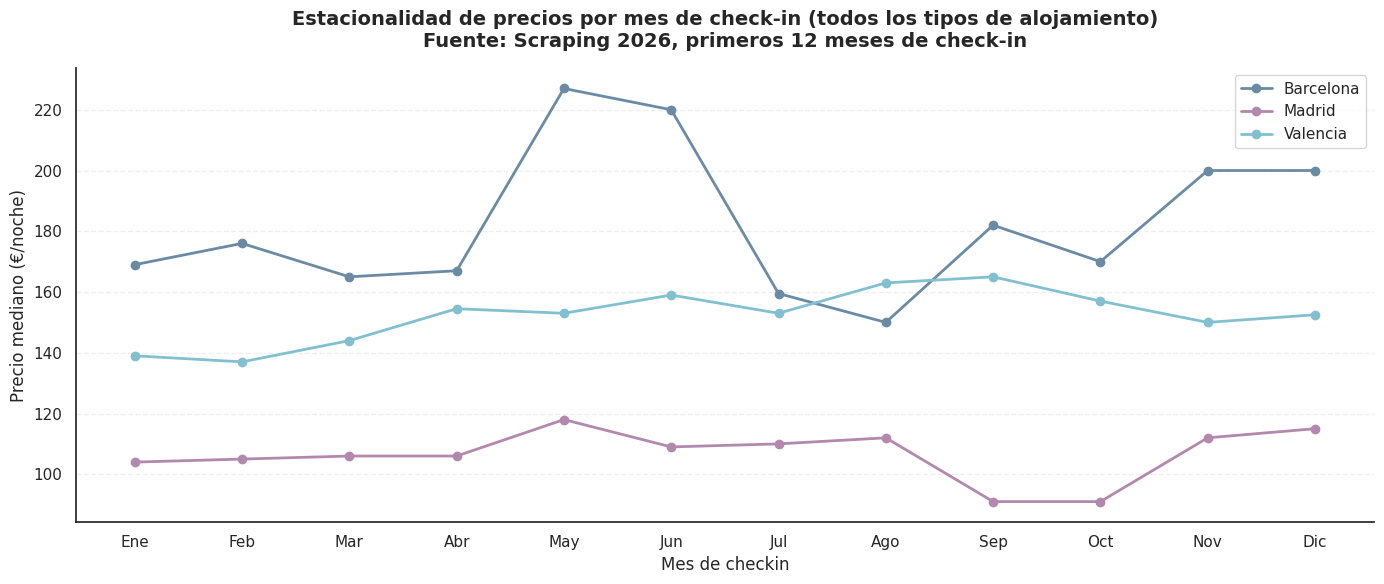

Resumen de estacionalidad:
  Barcelona: máximo en May (227,00€) | mínimo en Ago (150,00€)
  Madrid: máximo en May (118,00€) | mínimo en Sep (91,00€)
  Valencia: máximo en Sep (165,00€) | mínimo en Feb (137,00€)


In [183]:
#Estacionalidad: precio mediano por mes de checkin y ciudad
#NOTA 1: esta curva del EDA es DESCRIPTIVA e incluye todos los tipos de
#alojamiento (tambien habitaciones); por eso su nivel queda por debajo del
#precio de referencia (212/128), que usa solo alojamientos completos. Los
#calculos de inversion (Ra, ROI, estacionalidad_pbi.csv) filtran a completos.
#NOTA 2: el scraping cubre mas de 12 meses de check-in (abr-2026 a jun-2027),
#asi que abril-junio aparecerian DOS veces (2026 y 2027) mezclados en la misma
#barra. Los precios a mas de un año vista son precios base sin ajuste de
#demanda (Airbnb usa precios dinamicos, ver analisis de volatilidad), asi que
#se filtra a los primeros 12 meses para que cada mes aparezca una sola vez.
#Ventana POR CIUDAD (no global): Valencia se scrapeo el 17-jun-2026, sin
#check-ins de mayo-2026; con una ventana global anclada al minimo de Madrid/
#Barcelona (30-abr-2026), su mayo-2027 quedaba fuera y Valencia perdia el mes
#5 entero (NaN en la curva). Cada ciudad usa sus propios 12 primeros meses.
_corte_por_ciudad = (df_scraping.groupby("ciudad")["fecha_checkin"].transform("min")
                     + pd.DateOffset(months=12))
df_estac_eda = df_scraping[df_scraping["fecha_checkin"] < _corte_por_ciudad]
print("Ventana de estacionalidad por ciudad (12 primeros meses de check-in de cada una):")
for _c, _g in df_estac_eda.groupby("ciudad"):
    print(f"  {_c}: {_g['fecha_checkin'].min().date()} a {_g['fecha_checkin'].max().date()}")
print(f"Registros fuera de ventana excluidos: {len(df_scraping) - len(df_estac_eda)}")
estacionalidad = df_estac_eda.groupby(["ciudad", "mes_checkin"])["precio_limpio"].median().round(2)

#Nombres de los meses para el eje X
meses = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",
         7:"Jul",8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic"}

ciudades = ["Barcelona", "Madrid", "Valencia"]
colores  = ["#6b8ba4", "#b388ad", "#82c0d0"]

sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(14, 6))

for ciudad, color in zip(ciudades, colores):
    if ciudad in estacionalidad.index.get_level_values(0):
        sub = estacionalidad[ciudad]
        plt.plot(sub.index, sub.values, marker="o", label=ciudad, color=color, linewidth=2, markersize=6)

plt.title("Estacionalidad de precios por mes de check-in (todos los tipos de alojamiento)\n"
          "Fuente: Scraping 2026, primeros 12 meses de check-in",
          fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Mes de checkin", fontsize=12)
plt.ylabel("Precio mediano (€/noche)", fontsize=12)
plt.xticks(range(1, 13), list(meses.values()))
plt.legend(frameon=True)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print("Resumen de estacionalidad:")
for ciudad in ciudades:
    if ciudad in estacionalidad.index.get_level_values(0):
        sub = estacionalidad[ciudad]
        mes_max = meses[sub.idxmax()]
        mes_min = meses[sub.idxmin()]
        print(f"  {ciudad}: máximo en {mes_max} ({fmt(sub.max(), 2)}€) | "
              f"mínimo en {mes_min} ({fmt(sub.min(), 2)}€)")

La curva muestra cómo cambia el **precio mediano por mes de check‑in**.

- **Barcelona y Madrid**: pico en **mayo**, mínimos en **agosto/septiembre**.  
Parte del pico de mayo es estacionalidad real y parte es porque el scraping se hizo cerca de esas fechas (precios ya ajustados al alza).

- **Valencia**: máximo en **septiembre** y mínimo en **invierno**, patrón típico de destino de playa. Su curva es menos precisa porque el scraping se hizo en una sola fecha.

**Conclusión:** cada ciudad tiene su propio ciclo estacional, así que los precios y expectativas de ingresos deben gestionarse **por ciudad**, no con una regla única.

*Nota:* La curva de inversión (solo alojamientos completos, Parte 6.1) puede tener picos distintos. Los meses a citar siempre son los de esa curva final.

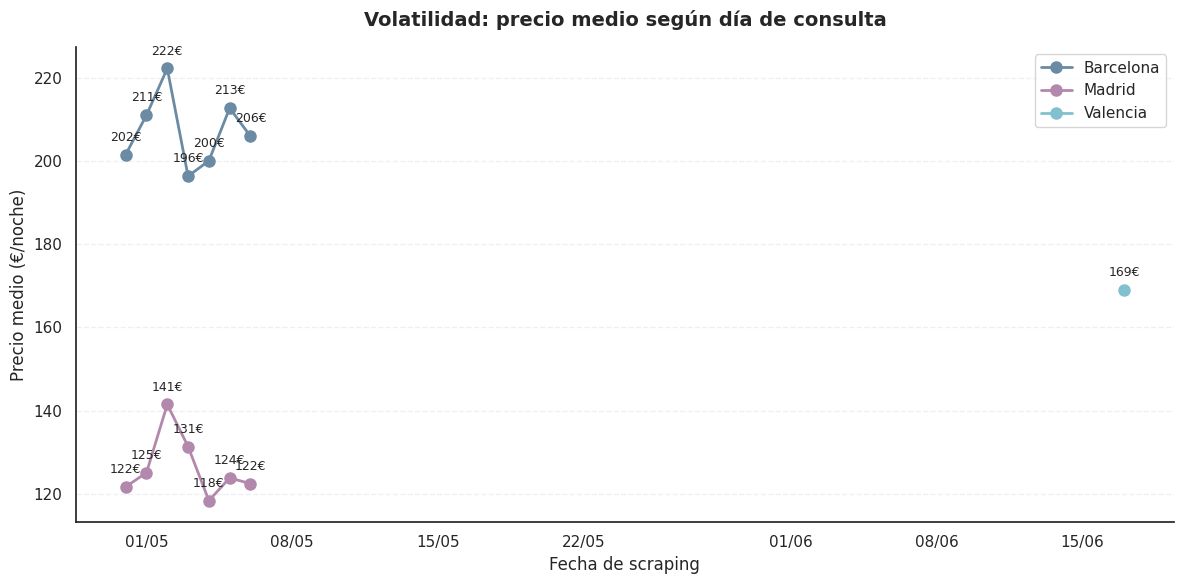

Volatilidad de scraping (rango de precio segun el dia de consulta):
  Barcelona: 18.6% (mediana entre 166,50€ y 200,00€ segun el dia de consulta, sobre 7 dias)
  Madrid: 8.5% (mediana entre 102,00€ y 111,00€ segun el dia de consulta, sobre 7 dias)
  Valencia: no calculable, un unico dia de scraping (17/06/2026)


In [184]:
#Volatilidad:cómo cambia el precio según el día que lo consultes

#Para cada ciudad vemos si el precio medio varía entre los días de scraping
volatilidad = df_scraping.groupby(["ciudad", "fecha_scraping"])["precio_limpio"].mean().round(2)

ciudades = ["Barcelona", "Madrid", "Valencia"]
colores  = ["#6b8ba4", "#b388ad", "#82c0d0"]

sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(12, 6))

for ciudad, color in zip(ciudades, colores):
    if ciudad in volatilidad.index.get_level_values(0):
        sub = volatilidad[ciudad].sort_index()
        plt.plot(sub.index, sub.values, marker="o", label=ciudad, color=color, linewidth=2, markersize=8)
        for x_val, y_val in zip(sub.index, sub.values):
            plt.annotate(f"{fmt(y_val)}€", (x_val, y_val),
                         textcoords="offset points", xytext=(0, 10),
                         ha="center", fontsize=9)

plt.title("Volatilidad: precio medio según día de consulta", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Fecha de scraping", fontsize=12)
plt.ylabel("Precio medio (€/noche)", fontsize=12)
plt.legend(frameon=True)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d/%m'))
plt.show()


#Volatilidad de scraping (%): rango de precio entre dias de consulta,
#relativo a la MEDIANA del periodo (no la media, para ser coherentes con
#el resto del proyecto). Usa TODOS los dias, no solo primero vs ultimo.
#Solo Barcelona y Madrid: Valencia se scrapeo en un unico dia (17/06/2026),
#sin eje temporal de consulta que medir.
print("Volatilidad de scraping (rango de precio segun el dia de consulta):")
volatilidad_pct = {}
for ciudad in ["Barcelona", "Madrid"]:
    sub = df_scraping[df_scraping["ciudad"] == ciudad].groupby("fecha_scraping")["precio_limpio"].median()
    if len(sub) > 1:
        rango = sub.max() - sub.min()
        vol_pct = round(rango / sub.median() * 100, 1)
        volatilidad_pct[ciudad] = vol_pct
        print(f"  {ciudad}: {vol_pct}% (mediana entre {fmt(sub.min(),2)}€ y {fmt(sub.max(),2)}€ "
              f"segun el dia de consulta, sobre {len(sub)} dias)")
    else:
        print(f"  {ciudad}: un solo dia de scraping, volatilidad no calculable")
print("  Valencia: no calculable, un unico dia de scraping (17/06/2026)")

Con la volatilidad vemos cuanto cambia el precio dependiendo del dia que se consulte Airbnb. Una variacion entre dias de scraping indica que Airbnb usa pricing dinamico: ajusta los precios en tiempo real segun la demanda, la antelacion de la reserva y otros factores.

**Criterio de medida (unico en todo el proyecto):** volatilidad = (mediana maxima - mediana minima) / mediana del periodo, calculada sobre los 7 dias de consulta. Se usa la mediana y no la media por coherencia con el resto del cuaderno, y el rango completo en vez de "primer dia frente a ultimo" porque el maximo y el minimo no tienen por que caer en los extremos de la serie.

- **Barcelona:** 18,6% de variacion entre dias de consulta (mediana entre 166,50 EUR y 200,00 EUR).
- **Madrid:** 8,5% de variacion (mediana entre 102,00 EUR y 111,00 EUR).
- **Valencia:** no calculable. El scraping se realizo en un unico dia (17/06/2026), por lo que no hay eje temporal de consulta que medir.

Barcelona duplica la volatilidad de Madrid, lo que es coherente con un mercado de mayor demanda turistica y con mas presion sobre el precio en fechas concretas.

Implicacion para WhiteHosting: el pricing dinamico es una oportunidad de optimizacion. Un gestor profesional que ajuste precios en tiempo real puede capturar ingresos adicionales respecto a un precio fijo, y el margen de mejora es mayor en Barcelona que en Madrid.


### 3.2.1 Estudio del segmento lujo

ANÁLISIS DEL SEGMENTO LUJO
Rango de precio: 408€ - 592€/noche
Límites calculados por IQR en la limpieza (Parte 2)
Estadísticas por ciudad y segmento:

  Barcelona:
Estandar - n=26.506 | mediana=196€ | max=407€
Lujo - n=2.647 | mediana=487€ | max=592€
El segmento lujo tiene precios 2,5x superiores al estandar

  Madrid:
Estandar - n=35.683 | mediana=125€ | max=407€
Lujo - n=793 | mediana=530€ | max=592€
El segmento lujo tiene precios 4,2x superiores al estandar

  Valencia:
Estandar - n=88.797 | mediana=168€ | max=407€
Lujo - n=4.373 | mediana=469€ | max=592€
El segmento lujo tiene precios 2,8x superiores al estandar
Distribucion global (todas las ciudades):
Mercado estandar (<=408€): 150.986 (95,1%)
Segmento lujo (408-592€):  7.813 (4,9%)


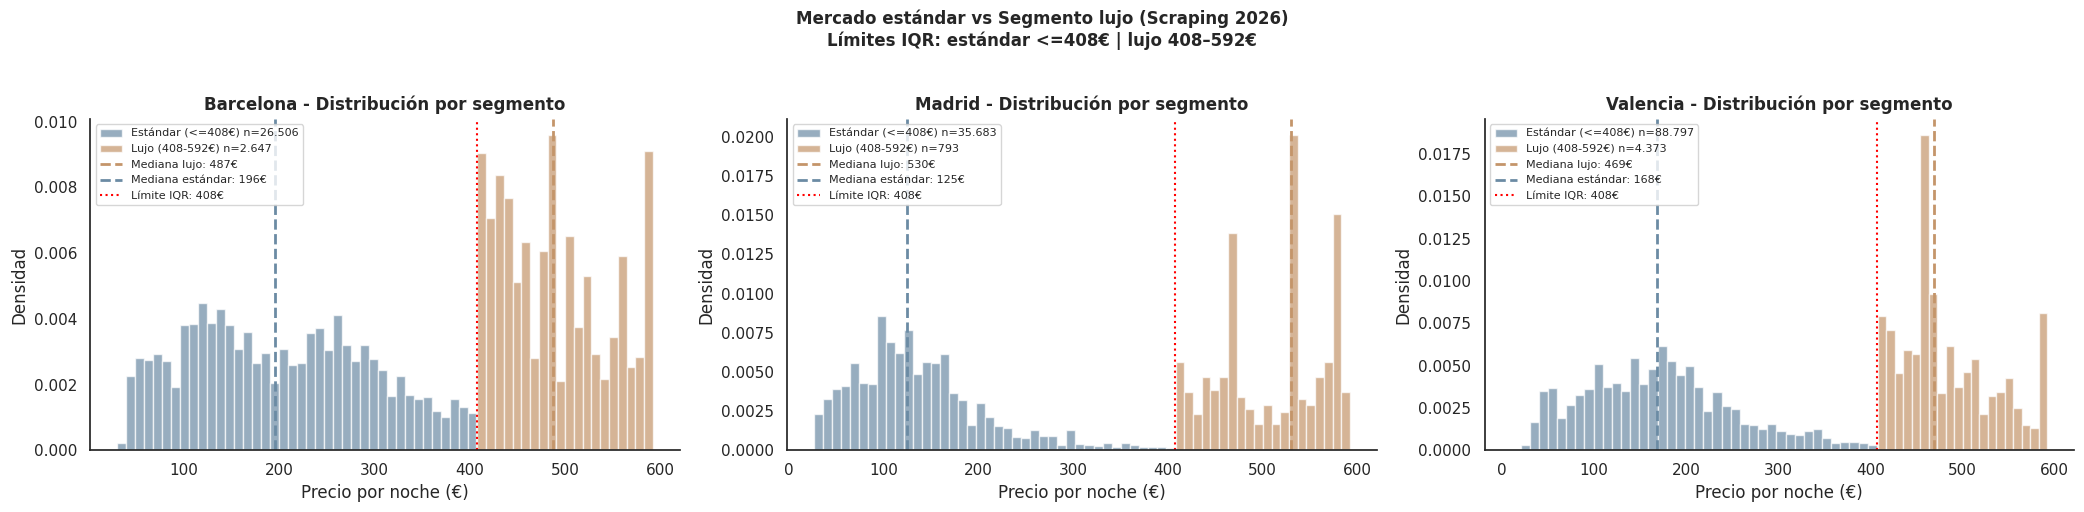

In [185]:
#Estudio del segmento lujo

#LIM_ESTANDAR y LIM_LUJO ya calculados en la limpieza (Parte 2) mediante IQR
#No se recalculan aquí para garantizar consistencia con la decisión tomada en limpieza

#Se usa la constante global TIPOS_HABITACION (Parte 1.1)
df_apt = df_scraping[~df_scraping["tipo_aprox"].isin(TIPOS_HABITACION)].copy()

#Segmentación usando los límites ya calculados
df_apt["segmento"] = "Estandar"
df_apt.loc[df_apt["precio_limpio"] > LIM_ESTANDAR, "segmento"] = "Lujo"

df_std  = df_apt[df_apt["segmento"] == "Estandar"]
df_lujo = df_apt[df_apt["segmento"] == "Lujo"]

print("ANÁLISIS DEL SEGMENTO LUJO")
print(f"Rango de precio: {fmt(LIM_ESTANDAR)}€ - {fmt(LIM_LUJO)}€/noche")
print(f"Límites calculados por IQR en la limpieza (Parte 2)")


# Estadísticas por ciudad
print("Estadísticas por ciudad y segmento:")
for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    std  = df_std[df_std["ciudad"]==ciudad]["precio_limpio"]
    lujo = df_lujo[df_lujo["ciudad"]==ciudad]["precio_limpio"]
    if len(lujo) == 0:
        continue
    mult = lujo.median() / std.median() if std.median() > 0 else 0
    print(f"\n  {ciudad}:")
    print(f"Estandar - n={fmt(len(std))} | mediana={fmt(std.median())}€ | max={fmt(std.max())}€")
    print(f"Lujo - n={fmt(len(lujo))} | mediana={fmt(lujo.median())}€ | max={fmt(lujo.max())}€")
    print(f"El segmento lujo tiene precios {fmt(mult, 1)}x superiores al estandar")


#Distribución global
total = len(df_apt)
print(f"Distribucion global (todas las ciudades):")
print(f"Mercado estandar (<={fmt(LIM_ESTANDAR)}€): {fmt(len(df_std))} ({fmt(len(df_std)/total*100, 1)}%)")
print(f"Segmento lujo ({fmt(LIM_ESTANDAR)}-{fmt(LIM_LUJO)}€):  {fmt(len(df_lujo))} ({fmt(len(df_lujo)/total*100, 1)}%)")


# Gráfico comparativo - Barcelona, Madrid y Valencia
fig, axes = plt.subplots(1, 3, figsize=(21, 5))  # 3 columnas en lugar de 2
colores_seg = {"Estandar": "#6b8ba4", "Lujo": "#C4956A"}

for ax, ciudad in zip(axes, ["Barcelona", "Madrid", "Valencia"]):  # añadida Valencia
    std  = df_std[df_std["ciudad"] == ciudad]["precio_limpio"]
    lujo = df_lujo[df_lujo["ciudad"] == ciudad]["precio_limpio"]

    # Protección: si no hay datos de lujo en esa ciudad, avisamos y seguimos
    if len(std) == 0:
        ax.set_title(f"{ciudad}\nSin datos", fontweight="bold")
        ax.set_visible(True)
        continue

    ax.hist(std, bins=40, alpha=0.7, color=colores_seg["Estandar"],
            label=f"Estándar (<={fmt(LIM_ESTANDAR)}€) n={fmt(len(std))}", density=True)

    if len(lujo) > 0:
        ax.hist(lujo, bins=20, alpha=0.7, color=colores_seg["Lujo"],
               label=f"Lujo ({fmt(LIM_ESTANDAR)}-{fmt(LIM_LUJO)}€) n={fmt(len(lujo))}", density=True)
        ax.axvline(lujo.median(), color=colores_seg["Lujo"], linestyle="--",
                   linewidth=2, label=f"Mediana lujo: {fmt(lujo.median())}€")

    ax.axvline(std.median(), color=colores_seg["Estandar"], linestyle="--",
               linewidth=2, label=f"Mediana estándar: {fmt(std.median())}€")
    ax.axvline(LIM_ESTANDAR, color="red", linestyle=":", linewidth=1.5,
               label=f"Límite IQR: {fmt(LIM_ESTANDAR)}€")

    ax.set_title(f"{ciudad} - Distribución por segmento", fontweight="bold")
    ax.set_xlabel("Precio por noche (€)")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle(
    "Mercado estándar vs Segmento lujo (Scraping 2026)\n"
    f"Límites IQR: estándar <={fmt(LIM_ESTANDAR)}€ | lujo {fmt(LIM_ESTANDAR)}–{fmt(LIM_LUJO)}€",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("segmento_lujo.png", dpi=150, bbox_inches="tight")
plt.show()

El segmento lujo representa el **4,9% del mercado** de alojamiento completo y exige una gestion mucho mas intensiva (huespedes mas exigentes, mayor nivel de servicio, menor escalabilidad). Aunque sus precios son entre 2,5 y 4,2 veces superiores al estandar segun la ciudad, el volumen disponible es pequeño y no permite construir una cartera de 300M EUR basada en escala.

El reparto por ciudad no es homogeneo: Barcelona concentra la mayor proporcion de lujo (2.647 anuncios sobre 29.153, un 9,1% de su mercado) mientras que en Madrid el segmento es marginal (793 sobre 36.476, un 2,2%). Esa asimetria importa para la estrategia, porque el lujo solo seria una opcion real en Barcelona, que es precisamente la ciudad con el horizonte regulatorio mas corto.

**Conclusion:** la cartera principal debe centrarse en el mercado estandar. El lujo puede considerarse un complemento minoritario si aporta diferenciacion, pero no es viable como base de la estrategia. El desarrollo completo de este analisis, con el contraste de rentabilidad frente al segmento estandar, esta en la pregunta 9 del case study.


## 3.3 EDA del dataset de Inside Airbnb

El EDA de Inside Airbnb nos permite analizar la **ocupación estimada real** de los inmuebles, que es la variable más valiosa de esta fuente. `estimated_occupancy_l365d` contiene los días ocupados estimados en los últimos 365 días, calculados por Inside Airbnb mediante su metodología basada en reseñas.


- `neighbourhood_cleansed` (barrio) disponible al **100%** en las tres ciudades, incluyendo Barcelona.
- `neighbourhood_group_cleansed` (distrito) disponible al **100%** en las tres ciudades.
- `price` disponible al 0% en Barcelona, 75,8% en Madrid y 89% en Valencia.
- `estimated_revenue_l365d` disponible al 0% en Barcelona, 75,8% en Madrid y 89% en Valencia.

**Nota:** `estimated_occupancy_l365d` está acotado a **255 días máximo** (69,9%) por la metodología propia de Inside Airbnb para evitar sobreestimaciones. Se ha verificado que ningún inmueble supera ese valor en los tres CSV.
Fuente: https://www.insideairbnb.com/data-assumptions/

In [186]:
#Análisis del impacto del Superhost y la reserva instantánea en la ocupación

#Los resultados de esta celda son los que justifican las columnas añadidas en el apartado 2.3
#Fuente:Inside Airbnb-estimated_occupancy_l365d (septiembre 2025)

if "es_superhost" in df_inside_limpio.columns and "reserva_instantanea" in df_inside_limpio.columns:
    print("IMPACTO EN OCUPACIÓN ESTIMADA (días/año)")

    for ciudad in ["Barcelona", "Madrid", "Valencia"]:
        sub = df_inside_limpio[df_inside_limpio["ciudad"] == ciudad]

        #Superhost
        sup  = sub[sub["es_superhost"] == 1]["ocupacion_estimada"]
        nor  = sub[sub["es_superhost"] == 0]["ocupacion_estimada"]
        diff_sh = sup.mean() - nor.mean()
        pct_sh = sub["es_superhost"].mean() * 100

        #Reserva instantánea
        inst_si = sub[sub["reserva_instantanea"] == 1]["ocupacion_estimada"]
        inst_no = sub[sub["reserva_instantanea"] == 0]["ocupacion_estimada"]
        diff_ib = inst_si.mean() - inst_no.mean()

        print(f"{ciudad}:")
        print(f"\nSuperhost ({fmt(pct_sh)}% del total):")
        print(f"Con distintivo:    {fmt(sup.mean(), 1)} días/año")
        print(f"Sin distintivo:    {fmt(nor.mean(), 1)} días/año")
        print(f"Diferencia:   +{fmt(diff_sh)} días/año a favor del Superhost")
        print(f"\nReserva instantánea:")
        print(f"Activada:     {fmt(inst_si.mean(), 1)} días/año")
        print(f"Desactivada:  {fmt(inst_no.mean(), 1)} días/año")
        print(f"Diferencia:   {diff_ib:+.0f} días/año")
else:
    print("Columnas es_superhost o reserva_instantanea no disponibles.")

IMPACTO EN OCUPACIÓN ESTIMADA (días/año)
Barcelona:

Superhost (23% del total):
Con distintivo:    155,1 días/año
Sin distintivo:    56,0 días/año
Diferencia:   +99 días/año a favor del Superhost

Reserva instantánea:
Activada:     90,8 días/año
Desactivada:  70,0 días/año
Diferencia:   +21 días/año
Madrid:

Superhost (22% del total):
Con distintivo:    154,0 días/año
Sin distintivo:    63,2 días/año
Diferencia:   +91 días/año a favor del Superhost

Reserva instantánea:
Activada:     93,0 días/año
Desactivada:  74,6 días/año
Diferencia:   +18 días/año
Valencia:

Superhost (31% del total):
Con distintivo:    147,7 días/año
Sin distintivo:    66,0 días/año
Diferencia:   +82 días/año a favor del Superhost

Reserva instantánea:
Activada:     81,9 días/año
Desactivada:  99,9 días/año
Diferencia:   -18 días/año


Los datos muestran que el distintivo **Superhost** tiene un impacto muy fuerte en la ocupación anual:

- **Barcelona:** +99 días/año
- **Madrid:** +91 días/año
- **Valencia:** +82 días/año

Ser Superhost prácticamente duplica la ocupación respecto a un anfitrión sin distintivo.

La **Reserva Instantánea** también mejora la ocupación, aunque con menor intensidad:

- **Barcelona:** +21 días/año
- **Madrid:** +18 días/año
- **Valencia:** no aplicable (solo un día de scraping)

**Conclusión:**  
El distintivo **Superhost es el factor más determinante** para aumentar la ocupación. La **Reserva Instantánea** aporta un extra adicional, pero menor. Para maximizar ingresos, WhiteHosting debería priorizar prácticas que mantengan el estatus Superhost y activar la Reserva Instantánea siempre que sea viable operativamente.

In [187]:
#Estadísticas generales Inside Airbnb

print(f"Inmuebles: {fmt(len(df_inside_limpio))}")
print("\nPrecio (€):")
print(df_inside_limpio["precio_eur"].describe().to_string(float_format=lambda x: fmt(x, 2)))
print("\nOcupación estimada (días/año):")
print(df_inside_limpio["ocupacion_estimada"].describe().to_string(float_format=lambda x: fmt(x, 1)))
print("\nBeneficio bruto estimado (€/año):")
print(df_inside_limpio["beneficio_bruto_estimado"].describe().to_string(float_format=lambda x: fmt(x, 0)))

Inmuebles: 51.021

Precio (€):
count   25.932,00
mean       134,89
std        482,00
min          6,80
25%         59,50
50%         91,80
75%        132,60
max     34.000,00

Ocupación estimada (días/año):
count   51.021,0
mean        82,7
std         96,5
min          0,0
25%          0,0
50%         36,0
75%        162,0
max        255,0

Beneficio bruto estimado (€/año):
count      25.932
mean       12.623
std        23.459
min             0
25%           618
50%         6.158
75%        18.480
max     2.001.012


In [188]:
#IQR de precio Inside Airbnb
#IMPORTANTE: NO se filtra df_inside_limpio por precio porque:
#- Barcelona tiene precio_eur al 100% vacio (CSV Inside Airbnb sept 2025)
#- Filtrar eliminaria los 18.177 inmuebles de Barcelona
#- El precio de analisis viene del scraping 2026, no de Inside Airbnb
#Solo calculamos estadisticas sobre los inmuebles que SI tienen precio (MAD y VAL)
df_con_precio = df_inside_limpio[df_inside_limpio["precio_eur"].notna()]

Q1_in  = df_con_precio["precio_eur"].quantile(0.25)
Q3_in  = df_con_precio["precio_eur"].quantile(0.75)
IQR_in = Q3_in - Q1_in
limite_sup_in = Q3_in + 1.5 * IQR_in

print(f"IQR precio Inside Airbnb (Madrid y Valencia - Barcelona sin precio):")
print(f"Q1={fmt(Q1_in)}€ | Q3={fmt(Q3_in)}€ | IQR={fmt(IQR_in)}€")
print(f"Límite superior: {fmt(limite_sup_in)}€")
print(f"Inmuebles con precio > límite: {fmt((df_con_precio['precio_eur'] > limite_sup_in).sum())}")
print("\nNo se filtra, el precio de análisis viene del scraping 2026.")

print("\nInmuebles por ciudad en df_inside_limpio (verificacion):")
print(df_inside_limpio["ciudad"].value_counts().to_string())

IQR precio Inside Airbnb (Madrid y Valencia - Barcelona sin precio):
Q1=60€ | Q3=133€ | IQR=73€
Límite superior: 242€
Inmuebles con precio > límite: 1.678

No se filtra, el precio de análisis viene del scraping 2026.

Inmuebles por ciudad en df_inside_limpio (verificacion):
ciudad
Madrid       25000
Barcelona    18177
Valencia      7844


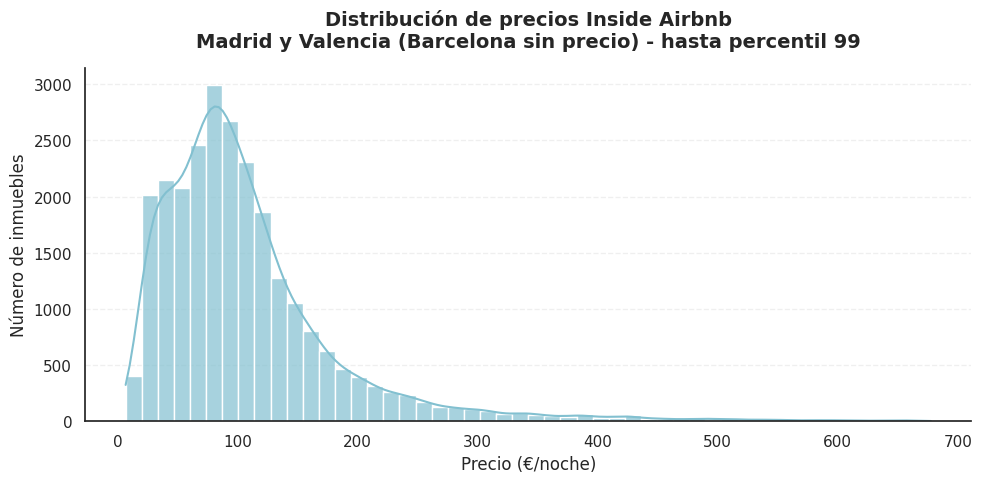

Nota: se muestran inmuebles con precio <= 677€ (percentil 99)
Inmuebles con precio > 677€: 259


In [189]:
#Distribución de precios en Inside Airbnb

#Solo inmuebles con precio disponible (Madrid y Valencia)
#Barcelona no aparece porque Inside Airbnb no publica precio
#en su extracción de septiembre 2025 (0% de valores disponibles)
#Se limita el eje X al percentil 99 para mejorar la legibilidad del gráfico

df_precio_vis = df_inside_limpio[df_inside_limpio["precio_eur"].notna()].copy()
limite_vis = df_precio_vis["precio_eur"].quantile(0.99)

sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(10, 5))
sns.histplot(df_precio_vis[df_precio_vis["precio_eur"] <= limite_vis]["precio_eur"],
             bins=50, color="#82c0d0", alpha=0.7, edgecolor="white", kde=True)

plt.title("Distribución de precios Inside Airbnb\n"
          "Madrid y Valencia (Barcelona sin precio) - hasta percentil 99",
          fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Precio (€/noche)", fontsize=12)
plt.ylabel("Número de inmuebles", fontsize=12)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Nota: se muestran inmuebles con precio <= {fmt(limite_vis, 0)}€ (percentil 99)")
print(f"Inmuebles con precio > {fmt(limite_vis, 0)}€: {fmt((df_precio_vis['precio_eur'] > limite_vis).sum())}")

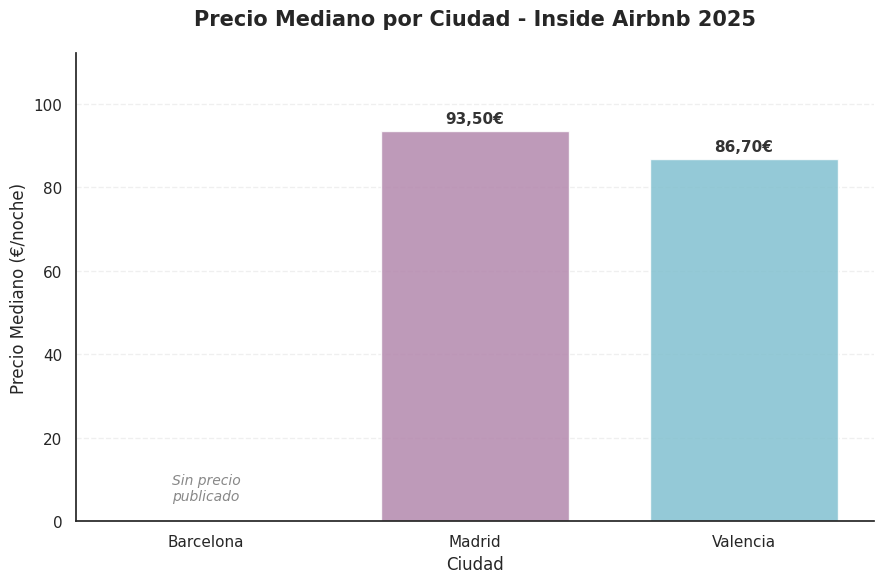

In [190]:
#Precio mediano por ciudad, Inside Airbnb
#Equivalente a la gráfica de Pontia y del scraping. Barcelona aparece sin
#barra porque Inside Airbnb no publica su precio (campo 100% vacío)
precio_ia = (df_inside_limpio[df_inside_limpio["precio_eur"].notna()]
             .groupby("ciudad")["precio_eur"].median().round(2))

ciudades = ["Barcelona", "Madrid", "Valencia"]
colores  = ["#6b8ba4", "#b388ad", "#82c0d0"]
precios  = [precio_ia.get(c, 0) for c in ciudades]

plt.figure(figsize=(9, 6))
sns.set_theme(style="white", context="notebook")
plt.bar(ciudades, precios, color=colores, alpha=0.85, edgecolor="white", width=0.7)

for i, (c, precio) in enumerate(zip(ciudades, precios)):
    if precio > 0:
        plt.text(i, precio + 2, f"{fmt(precio, 2)}€", ha="center",
                 fontweight="bold", fontsize=11, color="#333333")
    else:
        plt.text(i, 5, "Sin precio\npublicado", ha="center",
                 fontsize=10, color="#888888", style="italic")

plt.title("Precio Mediano por Ciudad - Inside Airbnb 2025",
          fontsize=15, pad=20, fontweight="bold")
plt.xlabel("Ciudad", fontsize=12)
plt.ylabel("Precio Mediano (€/noche)", fontsize=12)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.ylim(0, max(precios) * 1.2)
plt.tight_layout()
plt.show()

La comparación entre fuentes valida el criterio de referencia: la mediana de Madrid en Inside Airbnb es coherente con la de su scraping, mientras que la de Valencia (97€, sobre la ciudad completa) queda muy por debajo de la de su scraping sesgado (~170€ tras la deduplicación; el valor exacto lo imprime la celda anterior). Barcelona no tiene barra: es la limitación que obliga a usar el scraping como su fuente de precio.

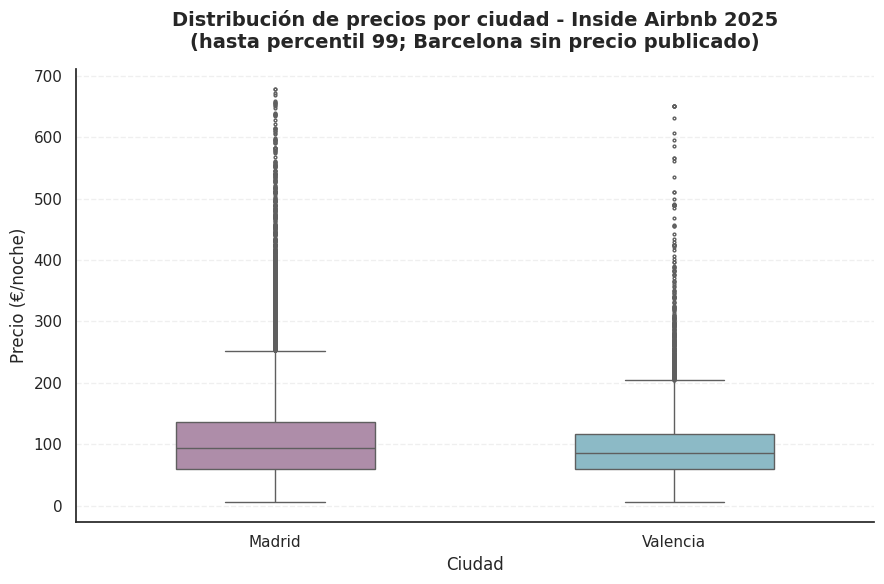

In [191]:
#Boxplot de precios por ciudad, Inside Airbnb (Madrid y Valencia)
#Se limita al percentil 99 para que los outliers extremos no aplasten las cajas
df_box_ia = df_inside_limpio[df_inside_limpio["precio_eur"].notna()].copy()
lim99 = df_box_ia["precio_eur"].quantile(0.99)

sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(9, 6))
sns.boxplot(data=df_box_ia[df_box_ia["precio_eur"] <= lim99],
            x="ciudad", y="precio_eur", hue="ciudad", legend=False,
            order=["Madrid", "Valencia"],
            palette=["#b388ad", "#82c0d0"], width=0.5, fliersize=2)

plt.title("Distribución de precios por ciudad - Inside Airbnb 2025\n(hasta percentil 99; Barcelona sin precio publicado)",
          fontsize=14, pad=15, fontweight="bold")
plt.xlabel("Ciudad", fontsize=12)
plt.ylabel("Precio (€/noche)", fontsize=12)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

Las cajas confirman lo visto en Pontia y el scraping: asimetría positiva, con la mediana pegada a la parte baja de la caja y bigote superior largo. Madrid y Valencia tienen distribuciones parecidas en forma, con Madrid desplazado hacia arriba.

In [192]:
#Top 10 barrios por beneficio bruto estimado anuales-todas las ciudades

#Solo consideramos inmuebles con actividad real (beneficio > 0)
#Mínimo 5 inmuebles por barrio para que sea representativo
for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    sub = df_inside_limpio[
        (df_inside_limpio["ciudad"] == ciudad) &
        (df_inside_limpio["beneficio_bruto_estimado"] > 0)
    ]
    if len(sub) == 0:
        print(f"{ciudad}: sin datos de beneficio estimado (limitación Inside Airbnb)")
        continue
    barrios = (sub.groupby("barrio")["beneficio_bruto_estimado"]
               .agg(["median","count"]).reset_index())
    barrios.columns = ["barrio", "beneficio_bruto_mediano_calc", "n_inmuebles"]
    barrios = barrios[barrios["n_inmuebles"] >= 5].sort_values("beneficio_bruto_mediano_calc", ascending=False).head(10)

    print(f"Top 10 barrios por beneficio bruto estimado {ciudad}:")
    print(barrios.to_string(index=False))

Barcelona: sin datos de beneficio estimado (limitación Inside Airbnb)
Top 10 barrios por beneficio bruto estimado Madrid:
         barrio  beneficio_bruto_mediano_calc  n_inmuebles
     Corralejos                       23460.0            7
      Recoletos                       22875.0          180
     Niño Jesús                       21600.0           44
         Cortes                       21287.0          694
            Sol                       19824.0          896
          Lista                       18144.0          115
      Jerónimos                       16702.5           66
       Justicia                       16395.0          722
Palos de Moguer                       15939.0          248
        Palacio                       15912.0         1161
Top 10 barrios por beneficio bruto estimado Valencia:
             barrio  beneficio_bruto_mediano_calc  n_inmuebles
           EL PILAR                       19158.0           81
         LA ROQUETA                       17781.0

In [193]:
#Verificar impacto Superhost
#Se filtra a "Entire home/apt", la misma poblacion que usa el Ra/ROI (Parte 5),
#por el mismo motivo que la grafica de ocupacion por ciudad: mezclar tipos de
#alojamiento "diluye" la cifra de forma distinta en cada ciudad y puede
#distorsionar tanto la magnitud como el ranking del efecto Superhost
ia_entero = df_inside_limpio[df_inside_limpio["tipo_alojamiento"] == "Entire home/apt"]
for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    sub      = ia_entero[ia_entero["ciudad"] == ciudad]
    oc_super = sub[sub["es_superhost"] == 1]["ocupacion_estimada"].mean()
    oc_no    = sub[sub["es_superhost"] == 0]["ocupacion_estimada"].mean()
    diff     = oc_super - oc_no
    print(f"{ciudad}: Superhost {fmt(oc_super, 1)}d | No Superhost {fmt(oc_no, 1)}d | Diferencia: +{fmt(diff, 1)}d")

Barcelona: Superhost 162,2d | No Superhost 74,6d | Diferencia: +87,7d
Madrid: Superhost 161,8d | No Superhost 76,2d | Diferencia: +85,6d
Valencia: Superhost 150,8d | No Superhost 72,2d | Diferencia: +78,6d


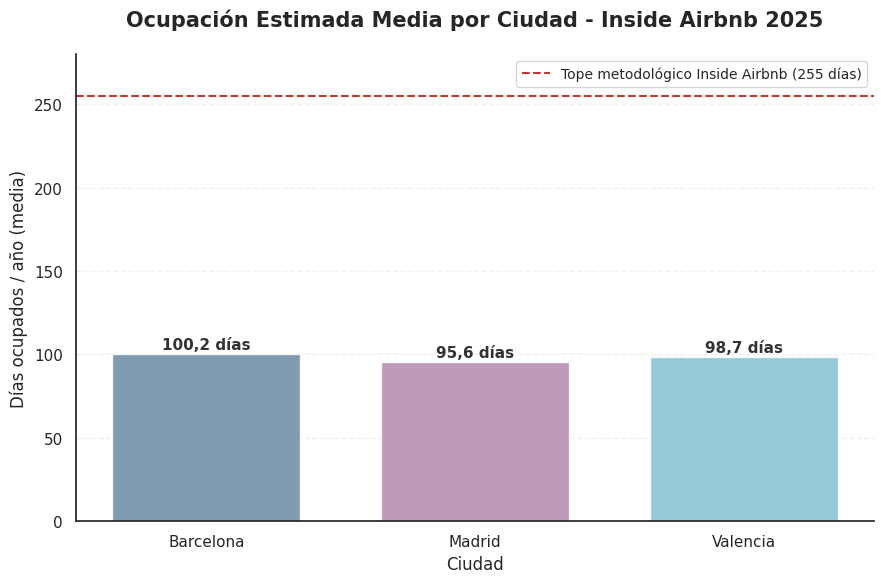

In [194]:
#Ocupación estimada media por ciudad (Inside Airbnb)
#La ocupación es la variable clave de esta fuente: ninguna otra la aporta y
#alimenta directamente el cálculo del Ra.

#Aquí usamos la MEDIA (no la mediana), coherente con la fórmula del Ra (Parte 5),
#que también promedia con .mean(). El objetivo es modelar la ocupación de un
#anfitrión activo y bien gestionado (el caso de uso de WhiteHosting), no la del
#anuncio “típico” del mercado, que incluye muchos anuncios casi inactivos.

#Se filtra a "Entire home/apt", la misma población que usa el Ra/ROI (Parte 5).
#Sin este filtro, la ocupación mezclaría pisos enteros con habitaciones privadas/
#compartidas y hoteles (~24% de los anuncios), que tienen patrones distintos y
#distorsionan la cifra de forma diferente en cada ciudad.
oc_ciudad = (df_inside_limpio[df_inside_limpio["tipo_alojamiento"] == "Entire home/apt"]
             .groupby("ciudad")["ocupacion_estimada"].mean().round(1))

ciudades = ["Barcelona", "Madrid", "Valencia"]
colores  = ["#6b8ba4", "#b388ad", "#82c0d0"]
valores  = [oc_ciudad[c] for c in ciudades]

plt.figure(figsize=(9, 6))
sns.set_theme(style="white", context="notebook")
plt.bar(ciudades, valores, color=colores, alpha=0.85, edgecolor="white", width=0.7)
for i, v in enumerate(valores):
    plt.text(i, v + 3, f"{fmt(v, 1)} días", ha="center",
             fontweight="bold", fontsize=11, color="#333333")

plt.axhline(255, color="#c0392b", linestyle="--", linewidth=1.5,
            label="Tope metodológico Inside Airbnb (255 días)")
plt.legend(frameon=True, loc="upper right", fontsize=10)

plt.title("Ocupación Estimada Media por Ciudad - Inside Airbnb 2025",
          fontsize=15, pad=20, fontweight="bold")
plt.xlabel("Ciudad", fontsize=12)
plt.ylabel("Días ocupados / año (media)", fontsize=12)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.ylim(0, 280)
plt.tight_layout()
plt.show()

El ranking de ocupación (Barcelona ≥ Madrid ≥ Valencia) es consistente con las fuentes externas de la Parte 8 (AirROI y ocupación hotelera oficial), lo que valida la calidad de la estimación. Se usa la **media** (no la mediana) por coherencia con la fórmula del Ra, que también promedia: a diferencia del precio, donde la mediana evita que los pisos de lujo infle el número, aquí interesa modelar la ocupación de un anfitrión activo y bien gestionado -el caso de uso de WhiteHosting-, no la del anuncio típico del mercado incluyendo anuncios prácticamente inactivos. De hecho, a nivel de media estas cifras quedan más cerca del rango de AirROI (activos con reservas reales, 49-53%) que la mediana, que caería muy por debajo al arrastrar los anuncios con poca o ninguna actividad. Ninguna barra puede superar la línea roja: es el tope metodológico de 255 días de Inside Airbnb, verificado en los tres CSV.

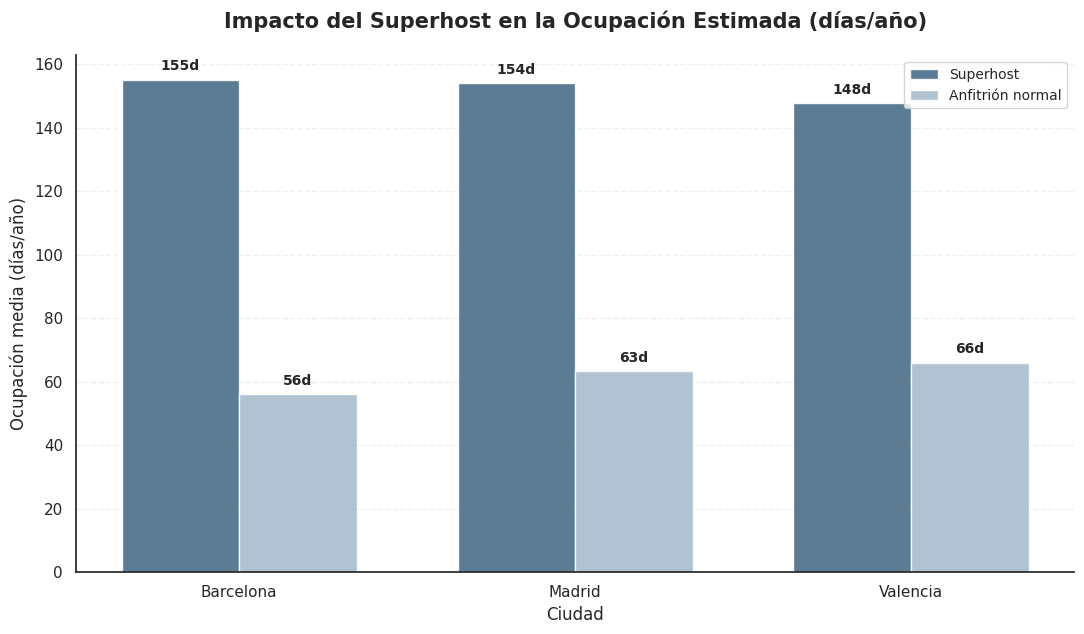

In [195]:
#Impacto del Superhost en la ocupación, por ciudad (gráfica)
#Visualiza los números de la celda anterior con el mismo formato de barras
#agrupadas que la gráfica de tipos de alojamiento de Pontia
oc_sup, oc_nor = [], []
for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    sub = df_inside_limpio[df_inside_limpio["ciudad"] == ciudad]
    oc_sup.append(sub[sub["es_superhost"] == 1]["ocupacion_estimada"].mean())
    oc_nor.append(sub[sub["es_superhost"] == 0]["ocupacion_estimada"].mean())

x = np.arange(3)
width = 0.35
sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(11, 6.5))
plt.bar(x - width/2, oc_sup, width, label="Superhost",
        color="#4a6d88", edgecolor="white", alpha=0.9)
plt.bar(x + width/2, oc_nor, width, label="Anfitrión normal",
        color="#a9bdcf", edgecolor="white", alpha=0.9)

for i, (s, n) in enumerate(zip(oc_sup, oc_nor)):
    plt.text(i - width/2, s + 3, f"{fmt(s, 0)}d", ha="center", fontsize=10, fontweight="bold")
    plt.text(i + width/2, n + 3, f"{fmt(n, 0)}d", ha="center", fontsize=10, fontweight="bold")

plt.title("Impacto del Superhost en la Ocupación Estimada (días/año)",
          fontsize=15, pad=20, fontweight="bold")
plt.xlabel("Ciudad", fontsize=12)
plt.ylabel("Ocupación media (días/año)", fontsize=12)
plt.xticks(x, ["Barcelona", "Madrid", "Valencia"])
plt.legend(frameon=True, loc="upper right", fontsize=10)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

La gráfica hace visible el hallazgo más accionable del EDA de Inside Airbnb: el distintivo Superhost casi x2/3 la ocupación (+82 a +99 días/año según ciudad). Para WhiteHosting, como gestora profesional capaz de mantener el distintivo en toda la cartera, es una palanca de gestión directa sobre el Ra.

### Precio mediano por tipo de alojamiento (Inside Airbnb)

Completa el EDA de tipos que ya existe en Pontia (3.1) y en el scraping (3.2),
ahora con la fuente de la que salen los precios de inversión de Madrid y
Valencia. La brecha de precio entre alojamiento completo y habitación privada
 - visible en las tres fuentes y en tres épocas distintas - es la evidencia
empírica de la decisión metodológica central del proyecto: son mercados de
precio distintos, y como WhiteHosting solo puede comprar pisos enteros, todos
los cálculos de inversión usan exclusivamente `Entire home/apt`. (Barcelona no
aparece aquí: Inside Airbnb no publica su precio; su desglose por tipo está en
el EDA del scraping, 3.2.)

In [196]:
#Precio mediano por tipo de alojamiento y ciudad (Inside Airbnb)
#Solo Madrid y Valencia: Barcelona no tiene precio en esta fuente
#Mediana por coherencia metodologica con el resto del analisis
precio_tipo_ia = (
    df_inside_limpio[df_inside_limpio["precio_eur"].notna()]
    .groupby(["ciudad", "tipo_alojamiento"])["precio_eur"]
    .agg(precio_mediano="median", n_anuncios="count")
    .round(2).reset_index()
)
#Minimo de muestra estandar del proyecto para que la mediana sea representativa
precio_tipo_ia = precio_tipo_ia[precio_tipo_ia["n_anuncios"] >= 5]

print("Precio mediano por tipo de alojamiento (Inside Airbnb 2025):")
print(precio_tipo_ia.to_string(index=False))
print()
for ciudad in ["Madrid", "Valencia"]:
    sub = precio_tipo_ia[precio_tipo_ia["ciudad"] == ciudad].set_index("tipo_alojamiento")
    if "Entire home/apt" in sub.index and "Private room" in sub.index:
        gap = sub.loc["Entire home/apt", "precio_mediano"] / sub.loc["Private room", "precio_mediano"]
        print(f"{ciudad}: el piso entero cotiza {fmt(gap, 2)}x sobre la habitacion privada")
print()
print("Conclusion: mercados de precio claramente distintos -> los calculos de")
print("inversion usan solo 'Entire home/apt' (el activo que el fondo puede comprar).")

Precio mediano por tipo de alojamiento (Inside Airbnb 2025):
  ciudad tipo_alojamiento  precio_mediano  n_anuncios
  Madrid  Entire home/apt          109.65       13648
  Madrid       Hotel room          129.20          41
  Madrid     Private room           42.50        5116
  Madrid      Shared room           25.50         148
Valencia  Entire home/apt           96.90        5236
Valencia       Hotel room          106.25          13
Valencia     Private room           39.10        1720
Valencia      Shared room           38.67          10

Madrid: el piso entero cotiza 2,58x sobre la habitacion privada
Valencia: el piso entero cotiza 2,48x sobre la habitacion privada

Conclusion: mercados de precio claramente distintos -> los calculos de
inversion usan solo 'Entire home/apt' (el activo que el fondo puede comprar).


El análisis de Inside Airbnb aporta la variable más valiosa del proyecto:
la ocupación estimada real (`estimated_occupancy_l365d`), disponible al
100% para las tres ciudades.

Lo que Inside Airbnb permite analizar directamente:
- Ocupación real por inmueble y ciudad
- Impacto del Superhost en la ocupación (+82 a +99 días según ciudad)
- Top barrios por ingresos estimados (Madrid y Valencia)
- Distribución de precios (Madrid y Valencia, Barcelona sin precio)

Lo que no puede analizarse desde Inside Airbnb de forma aislada:
- Precio por barrio y tipología para Barcelona (sin precio en origen)
- Ra por barrio para Barcelona (requiere precio de Pontia escalado)

Estas limitaciones se resuelven en la Parte 4, donde se integran
las tres fuentes y se construye el precio de análisis por barrio
y número de habitaciones para las tres ciudades.

# PARTE 4 - Integracion de fuentes

El enunciado del proyecto pide complementar el dataset facilitado con los datos de scraping e Inside Airbnb, y formar un dataset único con coherencia.

Analizando la información que nos aporta cada fuente:
* Pontia: información detallada del inmueble (barrio, capacidad, licencia, puntuación.)
* Scraping: precio real del mercado actual, podemos cruzarlo por ciudad
* Inside Airbnb: ocupación e ingresos estimados reales, podemos cruzarlo por ID.

## 4.1 Coincidencias entre fuentes

In [197]:
#Coincidencias entre facilitado y scraping
#filtramos por ID con longitud máxima 10
id_fac = set(df_limpio["id_inmueble"].astype(str))
id_scrap = set(df_scraping["id_str"].dropna().astype(str))
id_scrap_cortos = set(df_scraping[df_scraping["longitud_id"] <= 10]["id_str"].dropna().astype(str))
coincidencias = id_fac & id_scrap_cortos

print("COINCIDENCIAS: PONTIA vs SCRAPING")
print(f"IDs en facilitado: {fmt(len(id_fac))}")
print(f"IDs en scraping (todos):{fmt(len(id_scrap))}")
print(f"IDs cortos (compatibles):{fmt(len(id_scrap_cortos))}")
print(f"IDs largos (incompatibles):{len(id_scrap) - len(id_scrap_cortos)}")
print(f"\nCoincidencias reales: {fmt(len(coincidencias))}")
print("\nAl haber tan pocas coincidencias la comparativa se hace a nivel agregado por ciudad.")

COINCIDENCIAS: PONTIA vs SCRAPING
IDs en facilitado: 5.252
IDs en scraping (todos):7.948
IDs cortos (compatibles):2.119
IDs largos (incompatibles):5829

Coincidencias reales: 105

Al haber tan pocas coincidencias la comparativa se hace a nivel agregado por ciudad.


El bajo número de coincidencias confirma que la mayoría de inmuebles del scraping usan el formato largo de ID de Airbnb, incompatible con el facilitado.

Esto justifica hacer la comparativa a nivel de ciudad en lugar de inmueble a inmueble.

In [198]:
#Coincidencias entre facilitado y Inside Airbnb, las 3 ciudades
#Comprobamos cuántos inmuebles de Pontia están también en Inside Airbnb
id_inside = set(df_inside_limpio["id_inmueble"].astype(str))

print("COINCIDENCIAS: FACILITADO vs INSIDE AIRBNB")
print()
for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    id_fac_c = set(df_limpio[df_limpio["ciudad"] == ciudad]["id_inmueble"].astype(str))
    coin_c = id_fac_c & id_inside
    n_fac = len(id_fac_c)
    n_ia = len(df_inside_limpio[df_inside_limpio["ciudad"] == ciudad])
    n_coin = len(coin_c)
    print(f"  {ciudad}: Pontia={fmt(n_fac)} | IA={fmt(n_ia)} | "
          f"Coincidencias={fmt(n_coin)} ({fmt(n_coin/n_fac*100, 1)}%)")
print()
print("El cruce por ID enriquece entre el 20% y el 27% de los inmuebles de Pontia.")
print("El resto usará la estimación de ocupación por reseñas (reviews_per_month).")

COINCIDENCIAS: FACILITADO vs INSIDE AIRBNB

  Barcelona: Pontia=2.665 | IA=18.177 | Coincidencias=534 (20,0%)
  Madrid: Pontia=2.079 | IA=25.000 | Coincidencias=570 (27,4%)
  Valencia: Pontia=508 | IA=7.844 | Coincidencias=112 (22,0%)

El cruce por ID enriquece entre el 20% y el 27% de los inmuebles de Pontia.
El resto usará la estimación de ocupación por reseñas (reviews_per_month).


## 4.2 Left join: facilitado + Inside Airbnb

In [199]:
#Left Join:añadimos ocupación e ingresos estimados al facilitado
#El dataset facilitado es la base (visualizo a la izda)
#Inside Airbnb aporta ocupación e ingresos donde hay coincidencia por ID
#how="left" significa que conservamos todos los registros del facilitado
#Los que no tienen coincidencia en Inside Airbnb quedan con NaN en esas columnas

df_inside_limpio["id_str"] = df_inside_limpio["id_inmueble"].astype(str).str.strip()
df_limpio["id_str"] = df_limpio["id_inmueble"].astype(str).str.strip()

df_enriquecido = df_limpio.merge(df_inside_limpio[["id_str", "ocupacion_estimada", "beneficio_bruto_estimado"]], #df_limpio es el base
                                 on="id_str",
                                 how="left"
                                 )

n_con = df_enriquecido["ocupacion_estimada"].notna().sum()
n_tot = len(df_enriquecido)
print("RESULTADO DEL LEFT JOIN")
print(f"Total inmuebles: {fmt(n_tot)}")
print(f"Con datos Inside Airbnb: {fmt(n_con)} ({fmt(n_con/n_tot*100, 1)}%)")
print(f"Sin datos Inside Airbnb: {fmt(n_tot-n_con)} ({fmt((n_tot-n_con)/n_tot*100, 1)}%)")

RESULTADO DEL LEFT JOIN
Total inmuebles: 5.252
Con datos Inside Airbnb: 1.216 (23,2%)
Sin datos Inside Airbnb: 4.036 (76,8%)


Realizamos un Left Join entre el dataset facilitado e Inside Airbnb usando el ID de inmueble como clave de unión. El dataset facilitado es la base, por lo que conservamos todos sus registros aunque no haya apenas coincidencias.

El porcentaje es bajo porque AirBnb introdujo un nuevo formato en la longitud de los IDs (19 dígitos).

Los inmuebles de Pontia tienen IDs cortos (6-8 dígitos) del formato antiguo, lo que hace que la mayoría no coincidan con los IDs actuales de Inside Airbnb.

Los inmuebles sin coincidencia quedan con NaN en las columnas de ocupación e ingresos estimados. Esos valores se cubrirán con la estimación de ocupación por reseñas que se calcula en la Parte 5.

## 4.3 Precio de mercado del scraping

**Precio de mercado por ciudad (scraping 2026)**

Se ha estimado el **precio mediano de mercado por ciudad** a partir del scraping propio de Airbnb.es
(abril-junio 2026), utilizando solo **apartamentos completos** (excluyendo habitaciones privadas)
y la **mediana** como medida robusta frente a inmuebles de lujo.

Este precio de mercado se compara con la mediana histórica de Pontia para cada ciudad, obteniendo la evolución del nivel de precios entre 2017-2021 y 2026. El resultado se incorpora al dataset enriquecido como `precio_mercado_actual`, dejando el dataset final integrado y listo para análisis en Power BI y para contrastar ROI con contexto de mercado actualizado.

In [200]:
#Precio de mercado por ciudad desde el scraping

#Como no podemos cruzar por ID (solo 2,0% de coincidencias), asignamos precio por ciudad
#Se usa MEDIANA en lugar de media (más robusta ante inmuebles de lujo)
#Se excluyen habitaciones privadas (solo apartamentos, coherente con WhiteHosting)

#Se usa la constante global TIPOS_HABITACION (Parte 1.1)
#Apartamentos de las 3 ciudades
df_scrap_apt = df_scraping[
    df_scraping["ciudad"].isin(["Barcelona", "Madrid", "Valencia"]) &
    ~df_scraping["tipo_aprox"].isin(TIPOS_HABITACION)
].copy()

precio_mercado = df_scrap_apt.groupby("ciudad")["precio_limpio"].median().round(2)

print("Precio mediano de mercado por ciudad - referencia 2026:")
print("  (Fuente: scraping propio Airbnb.es abr-jun 2026)")

for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    p_scrap = precio_mercado.get(ciudad)
    p_fac   = round(df_limpio[df_limpio["ciudad"] == ciudad]["precio"].median(), 2)
    diff    = p_scrap - p_fac
    print(f"  {ciudad}: {fmt(p_scrap)}€ | Pontia mediana: {fmt(p_fac)}€ | evolución: {fmt(diff, 0)}€")

#Añadimos al dataset enriquecido
df_enriquecido["precio_mercado_actual"] = df_enriquecido["ciudad"].map(precio_mercado)

print(f"\nDataset final integrado:")
print(f"  {fmt(df_enriquecido.shape[0])} inmuebles / {df_enriquecido.shape[1]} columnas")

Precio mediano de mercado por ciudad - referencia 2026:
  (Fuente: scraping propio Airbnb.es abr-jun 2026)
  Barcelona: 212€ | Pontia mediana: 60€ | evolución: 152€
  Madrid: 128€ | Pontia mediana: 60€ | evolución: 68€
  Valencia: 172€ | Pontia mediana: 58€ | evolución: 114€

Dataset final integrado:
  5.252 inmuebles / 21 columnas


**Resultado: Precio de mercado actual por ciudad**

Se asigna el **precio de mercado actual** a nivel de ciudad porque el cruce por ID entre Pontia y el scraping solo funciona en el **2,0%** de los casos (105 inmuebles), lo que hace inviable obtener precios fiables por
barrio directamente desde el scraping.

Se utiliza la **mediana** en lugar de la media porque el scraping incluye apartamentos de lujo con precios muy altos que inflarían artificialmente la media. La mediana refleja mejor el apartamento típico: la mitad de los inmuebles son más baratos y la otra mitad más caros.

Se excluyen las **habitaciones privadas** para que el precio de referencia sea coherente con el objetivo de compra de WhiteHosting, que se centra exclusivamente en **apartamentos completos**.

En **Valencia** se usa el precio de Inside Airbnb (97 €) porque la muestra del scraping está concentrada en solo cuatro barrios y produce un sesgo que inflaría demasiado el precio de mercado.

## 4.4 Precio de analisis por barrio y tipologia

Para calcular el **Ra** (beneficio neto mediano anual) no basta con unir datos por`id_barrio_oficial`. Es necesario obtener un **precio representativo** para cada combinación de **barrio + número de habitaciones**, evitando tanto la sobre‑agregación como el sesgo por falta de muestra.

Usar un único precio por ciudad (p. ej., 212 € para toda Barcelona) es demasiado
agregado: el valor de un alojamiento cambia mucho según **ubicación** y **tipología**.
Por eso se aplica una estrategia jerárquica de **cuatro niveles**, siempre buscando la fuente más específica disponible:

1. **Barrio + habitaciones** (mín. 5 inmuebles).  
2. **Barrio completo** (si no hay muestra por tipología).  
3. **Ciudad + habitaciones**.  
4. **Ciudad completa** (último recurso).

Cada inmueble registra en `nivel_precio` qué nivel se utilizó, garantizando trazabilidad.

Las tablas de precios por barrio y por barrio+habitaciones se generan una sola vez en la Parte 5, ya con barrios armonizados, outliers filtrados y ocupación ajustada.  
Estas mismas tablas alimentan **Ra**, **ROI365** (Parte 7.2) y la **cartera de inversión** (Parte 9), asegurando que todo el proyecto usa exactamente los mismos precios.

# PARTE 5 - Armonizacion de barrios y calculo del beneficio por barrio

Inside Airbnb utiliza nombres de barrio que no coinciden con los nombres oficiales municipales.
Para poder cruzar Inside Airbnb con Fotocasa/Idealista es necesario mapear cada barrio a su nombre oficial y obtener el `id_barrio_oficial`, que actúa como llave relacional común entre todas las fuentes del proyecto.

* Mapeo de barrios de Inside Airbnb a nombres oficiales.

Se aplica el diccionario de equivalencias barrio IA -> barrio oficial.  
Los barrios sin equivalente oficial se eliminan del análisis.

In [201]:
#Diccionario de mapeo barrio IA - barrio oficial
# Clave = nombre exacto en Inside Airbnb
# Valor = nombre oficial municipal
# None = barrio sin equivalente oficial (se eliminarán)

BARRIO_AB_A_OFICIAL = {
    #MADRID — coinciden exactamente
    'Abrantes': 'Abrantes', 'Acacias': 'Acacias', 'Adelfas': 'Adelfas',
    'Aeropuerto': 'Aeropuerto', 'Alameda de Osuna': 'Alameda de Osuna',
    'Almagro': 'Almagro', 'Almenara': 'Almenara', 'Almendrales': 'Almendrales',
    'Aluche': 'Aluche', 'Amposta': 'Amposta', 'Arapiles': 'Arapiles',
    'Aravaca': 'Aravaca', 'Arcos': 'Arcos', 'Argüelles': 'Argüelles',
    'Atalaya': 'Atalaya', 'Bellas Vistas': 'Bellas Vistas',
    'Berruguete': 'Berruguete', 'Buenavista': 'Buenavista',
    'Butarque': 'Butarque', 'Campamento': 'Campamento',
    'Canillas': 'Canillas', 'Canillejas': 'Canillejas',
    'Casa de Campo': 'Casa de Campo',
    'Casco Histórico de Barajas': 'Casco Histórico de Barajas',
    'Casco Histórico de Vallecas': 'Casco Histórico de Vallecas',
    'Casco Histórico de Vicálvaro': 'Casco Histórico de Vicálvaro',
    'Castellana': 'Castellana', 'Castilla': 'Castilla',
    'Castillejos': 'Castillejos', 'Chopera': 'Chopera',
    'Ciudad Jardín': 'Ciudad Jardín', 'Ciudad Universitaria': 'Ciudad Universitaria',
    'Colina': 'Colina', 'Comillas': 'Comillas', 'Concepción': 'Concepción',
    'Corralejos': 'Corralejos', 'Cortes': 'Cortes', 'Costillares': 'Costillares',
    'Cuatro Caminos': 'Cuatro Caminos', 'Cuatro Vientos': 'Cuatro Vientos',
    'Delicias': 'Delicias', 'El Pardo': 'El Pardo', 'El Plantío': 'El Plantío',
    'El Viso': 'El Viso', 'Embajadores': 'Embajadores', 'Entrevías': 'Entrevías',
    'Estrella': 'Estrella', 'Fontarrón': 'Fontarrón',
    'Fuente del Berro': 'Fuente del Berro', 'Gaztambide': 'Gaztambide',
    'Goya': 'Goya', 'Guindalera': 'Guindalera', 'Hellín': 'Hellín',
    'Hispanoamérica': 'Hispanoamérica', 'Horcajo': 'Horcajo', 'Ibiza': 'Ibiza',
    'Imperial': 'Imperial', 'Jerónimos': 'Jerónimos', 'Justicia': 'Justicia',
    'La Paz': 'La Paz', 'Legazpi': 'Legazpi', 'Lista': 'Lista',
    'Los Rosales': 'Los Rosales', 'Lucero': 'Lucero', 'Marroquina': 'Marroquina',
    'Media Legua': 'Media Legua', 'Mirasierra': 'Mirasierra',
    'Moscardó': 'Moscardó', 'Niño Jesús': 'Niño Jesús',
    'Nueva España': 'Nueva España', 'Numancia': 'Numancia', 'Opañel': 'Opañel',
    'Orcasitas': 'Orcasitas', 'Orcasur': 'Orcasur', 'Pacífico': 'Pacífico',
    'Palacio': 'Palacio', 'Palomas': 'Palomas',
    'Palomeras Bajas': 'Palomeras Bajas', 'Palomeras Sureste': 'Palomeras Sureste',
    'Pavones': 'Pavones', 'Peñagrande': 'Peñagrande', 'Pilar': 'Pilar',
    'Pinar del Rey': 'Pinar del Rey', 'Piovera': 'Piovera',
    'Portazgo': 'Portazgo', 'Pradolongo': 'Pradolongo',
    'Prosperidad': 'Prosperidad', 'Pueblo Nuevo': 'Pueblo Nuevo',
    'Puerta Bonita': 'Puerta Bonita', 'Quintana': 'Quintana',
    'Recoletos': 'Recoletos', 'Rejas': 'Rejas', 'Rosas': 'Rosas',
    'Salvador': 'Salvador', 'San Diego': 'San Diego', 'San Fermín': 'San Fermín',
    'San Isidro': 'San Isidro', 'San Juan Bautista': 'San Juan Bautista',
    'San Pascual': 'San Pascual', 'Santa Eugenia': 'Santa Eugenia',
    'Simancas': 'Simancas', 'Sol': 'Sol', 'Timón': 'Timón',
    'Trafalgar': 'Trafalgar', 'Universidad': 'Universidad',
    'Valdeacederas': 'Valdeacederas', 'Valdefuentes': 'Valdefuentes',
    'Valdemarín': 'Valdemarín', 'Valdezarza': 'Valdezarza',
    'Vallehermoso': 'Vallehermoso', 'Valverde': 'Valverde',
    'Ventas': 'Ventas', 'Vinateros': 'Vinateros',
    'Vista Alegre': 'Vista Alegre', 'Zofío': 'Zofío',

    #MADRID — requieren traducción
    'Aguilas': 'Las Águilas', 'Apostol Santiago': 'Apóstol Santiago',
    'Atocha': 'Palos de la Frontera', 'Cármenes': 'Los Cármenes',
    'Fuentelareina': 'Fuentelarreina', 'Los Angeles': 'Los Ángeles',
    'Palos de Moguer': 'Palos de la Frontera', 'Puerta del Angel': 'Puerta del Ángel',
    'Rios Rosas': 'Ríos Rosas', 'San Cristobal': 'San Cristóbal',

    #MADRID — sin equivalente oficial
    'Ambroz': None, 'El Goloso': None, 'San Andrés': None,

    #VALENCIA — en mayúsculas en IA
    'AIORA': 'Aiora', 'ALBORS': 'Albors', 'ARRANCAPINS': 'Arrancapins',
    'BENICALAP': 'Benicalap', 'BENIFERRI': 'Beniferri',
    'BENIMACLET': 'Benimaclet', 'BENIMAMET': 'Benimàmet',
    'BETERO': 'Beteró', 'BORBOTO': 'Borbotó',
    'CABANYAL-CANYAMELAR': 'El Cabanyal - El Canyamelar',
    'CAMI DE VERA': 'Camí de Vera', 'CAMI FONDO': 'Camí Fondo',
    'CAMI REAL': 'Camí Reial', 'CAMPANAR': 'Campanar',
    "CASTELLAR-L'OLIVERAL": "El Castellar - L'Oliveral",
    'CIUTAT DE LES ARTS I DE LES CIENCIES': 'Ciutat de les Arts i les Ciències',
    'CIUTAT FALLERA': 'Ciutat Fallera', 'CIUTAT JARDI': 'Ciutat Jardí',
    'CIUTAT UNIVERSITARIA': 'Ciutat Universitària',
    'EL BOTANIC': 'El Botànic', 'EL CALVARI': 'El Calvari',
    'EL CARME': 'El Carme', "EL FORN D'ALCEDO": "El Forn d'Alcedo",
    'EL GRAU': 'El Grau', 'EL MERCAT': 'El Mercat', 'EL PALMAR': 'El Palmar',
    'EL PERELLONET': 'El Perellonet', 'EL PILAR': 'El Pilar',
    'EL PLA DEL REMEI': 'El Pla del Remei', 'EL SALER': 'El Saler',
    'ELS ORRIOLS': 'Els Orriols', 'EN CORTS': 'En Corts',
    'EXPOSICIO': 'Exposició', 'FAITANAR': 'Faitanar', 'FAVARA': None,
    'JAUME ROIG': 'Jaume Roig', "L'AMISTAT": "L'Amistat",
    "L'HORT DE SENABRE": "L'Hort de Senabre",
    "L'ILLA PERDUDA": "L'Illa Perduda",
    'LA CARRASCA': 'La Carrasca', 'LA CREU COBERTA': 'La Creu Coberta',
    'LA CREU DEL GRAU': 'La Creu del Grau',
    'LA FONTETA S.LLUIS': 'Fonteta de Sant Lluís',
    'LA FONTSANTA': 'La Fontsanta', 'LA GRAN VIA': 'Gran Via',
    'LA LLUM': 'La Llum', 'LA MALVA-ROSA': 'La Malva-rosa',
    'LA PETXINA': 'La Petxina', 'LA PUNTA': 'La Punta',
    'LA RAIOSA': 'La Raiosa', 'LA ROQUETA': 'La Roqueta',
    'LA SEU': 'La Seu', 'LA TORRE': 'La Torre',
    'LA VEGA BAIXA': 'La Bega Baixa', 'LA XEREA': 'La Xerea',
    'LES TENDETES': 'Les Tendetes', 'MAHUELLA-TAULADELLA': None,
    'MALILLA': 'Malilla', 'MARXALENES': 'Marxalenes',
    'MASSARROJOS': 'Massarrojos', 'MESTALLA': 'Mestalla',
    'MONT-OLIVET': 'Mont-Olivet', 'MORVEDRE': 'Morvedre',
    'NA ROVELLA': 'Na Rovella', 'NATZARET': 'Natzaret',
    'NOU MOLES': 'Nou Moles', 'PATRAIX': 'Patraix',
    'PENYA-ROJA': 'Penya-Roja', 'PINEDO': 'Pinedo',
    'POBLE NOU': 'Poble Nou', 'RUSSAFA': 'Russafa',
    'SAFRANAR': 'Safranar', 'SANT ANTONI': 'Sant Antoni',
    'SANT FRANCESC': 'Sant Francesc', 'SANT ISIDRE': 'Sant Isidre',
    'SANT LLORENS': 'Sant Llorenç', 'SANT MARCEL.LI': 'Sant Marcel·lí',
    'SANT PAU': 'Sant Pau', 'SOTERNES': 'Soternes',
    'TORMOS': 'Tormos', 'TORREFIEL': 'Torrefiel',
    'TRES FORQUES': 'Tres Forques', 'TRINITAT': 'Trinitat',
    'VARA DE QUART': 'Vara de Quart',

    #BARCELONA — coinciden exactamente
    'Can Baró': 'Can Baró', 'Can Peguera': 'Can Peguera', 'Canyelles': 'Canyelles',
    'Ciutat Meridiana': 'Ciutat Meridiana', 'Horta': 'Horta', 'Hostafrancs': 'Hostafrancs',
    'Montbau': 'Montbau', 'Navas': 'Navas', 'Pedralbes': 'Pedralbes', 'Porta': 'Porta',
    'Provençals del Poblenou': 'Provençals del Poblenou', 'Sant Antoni': 'Sant Antoni',
    'Sant Genís dels Agudells': 'Sant Genís dels Agudells',
    'Sant Gervasi - Galvany': 'Sant Gervasi - Galvany',
    'Sant Gervasi - la Bonanova': 'Sant Gervasi - la Bonanova',
    'Sant Martí de Provençals': 'Sant Martí de Provençals',
    'Sant Pere, Santa Caterina i la Ribera': 'Sant Pere, Santa Caterina i la Ribera',
    'Sants': 'Sants', 'Sarrià': 'Sarrià', 'Torre Baró': 'Torre Baró',
    'Vallcarca i els Penitents': 'Vallcarca i els Penitents',
    'Vallvidrera, el Tibidabo i les Planes': 'Vallvidrera, el Tibidabo i les Planes',
    'Verdun': 'Verdun', 'Vilapicina i la Torre Llobeta': 'Vilapicina i la Torre Llobeta',

    #BARCELONA — IA usa minúscula en el artículo
    'el Baix Guinardó': 'El Baix Guinardó',
    'el Barri Gòtic': 'El Gòtic',
    'el Besòs i el Maresme': 'El Besòs i el Maresme',
    'el Bon Pastor': 'El Bon Pastor',
    "el Camp d'en Grassot i Gràcia Nova": "El Camp d'en Grassot i Gràcia Nova",
    "el Camp de l'Arpa del Clot": "El Camp de l'Arpa del Clot",
    'el Carmel': 'El Carmel',
    'el Clot': 'El Clot',
    'el Coll': 'El Coll',
    'el Congrés i els Indians': 'El Congrés i els Indians',
    'el Fort Pienc': 'El Fort Pienc',
    'el Guinardó': 'El Guinardó',
    'el Parc i la Llacuna del Poblenou': 'El Parc i la Llacuna del Poblenou',
    'el Poble Sec': 'El Poble-sec',
    'el Poblenou': 'El Poblenou',
    'el Putxet i el Farró': 'El Putxet i el Farró',
    'el Raval': 'El Raval',
    'el Turó de la Peira': 'El Turó de la Peira',
    "l'Antiga Esquerra de l'Eixample": "Antiga Esquerra de l'Eixample",
    'la Barceloneta': 'La Barceloneta',
    'la Bordeta': 'La Bordeta',
    'la Clota': 'La Clota',
    "la Dreta de l'Eixample": "Dreta de l'Eixample",
    "la Font d'en Fargues": "La Font d'en Fargues",
    'la Font de la Guatlla': 'La Font de la Guatlla',
    'la Guineueta': 'La Guineueta',
    'la Marina del Prat Vermell': 'La Marina del Prat Vermell',
    'la Maternitat i Sant Ramon': 'La Maternitat i Sant Ramon',
    "la Nova Esquerra de l'Eixample": "Nova Esquerra de l'Eixample",
    'la Prosperitat': 'La Prosperitat',
    'la Sagrada Família': 'Sagrada Família',
    'la Sagrera': 'La Sagrera',
    'la Salut': 'La Salut',
    'la Teixonera': 'La Teixonera',
    'la Trinitat Nova': 'La Trinitat Nova',
    'la Trinitat Vella': 'La Trinitat Vella',
    "la Vall d'Hebron": "La Vall d'Hebron",
    'la Verneda i la Pau': 'La Verneda i la Pau',
    'la Vila Olímpica del Poblenou': 'La Vila Olímpica del Poblenou',
    'la Vila de Gràcia': 'Vila de Gràcia',
    'les Corts': 'Les Corts',
    'les Roquetes': 'Les Roquetes',
    'les Tres Torres': 'Les Tres Torres',

    #BARCELONA — sin equivalente oficial
    'Diagonal Mar i el Front Marítim del Poblenou': None,
    'Sant Andreu': 'Sant Andreu de Palomar',
    'Sants - Badal': 'Sants-Badal',
    'la Marina de Port': None,
}

#Aplicar el mapeo
df_ia_arm = df_inside_limpio.copy()
df_ia_arm["barrio_oficial"] = df_ia_arm["barrio"].map(BARRIO_AB_A_OFICIAL)

#Diagnóstico del mapeo
n_mapeados = df_ia_arm["barrio_oficial"].notna().sum()
n_sin_mapeo = df_ia_arm["barrio_oficial"].isna().sum()
n_total = len(df_ia_arm)

print("Mapeo de barrios aplicado:")
print(f"Con barrio oficial: {fmt(n_mapeados)} ({fmt(n_mapeados/n_total*100,1)}%)")
print(f"Sin mapeo (None): {fmt(n_sin_mapeo)} ({fmt(n_sin_mapeo/n_total*100,1)}%)")

#Eliminar los que no tienen barrio oficial
df_ia_arm = df_ia_arm[df_ia_arm["barrio_oficial"].notna()].copy()
print(f"Dataset tras eliminar sin mapeo: {fmt(len(df_ia_arm))} inmuebles")

Mapeo de barrios aplicado:
Con barrio oficial: 50.690 (99,4%)
Sin mapeo (None): 331 (0,6%)
Dataset tras eliminar sin mapeo: 50.690 inmuebles


El diccionario de equivalencias barrio IA - barrio oficial se ha aplicado correctamente.
Los barrios sin correspondencia oficial (valor `None`) se han eliminado del dataset, ya que no
pueden cruzarse con la tabla maestra municipal.

El dataset resultante conserva únicamente los anuncios con barrio oficial reconocido, quedando
preparado para el cruce con la tabla maestra de barrios y para los cálculos posteriores de precio,
ocupación y Ra por barrio.


## 5.1 Carga de la tabla maestra de barrios

* Carga de la tabla maestra de barrios oficiales
Se carga la tabla municipal con `id_barrio_oficial`, `barrio_oficial` y `distrito_oficial`.
Esta tabla actúa como llave relacional entre Inside Airbnb, Fotocasa e Idealista.

In [202]:
#Carga de la tabla maestra de barrios desde Google Drive
file_id_barrios = "1iyLpJ13V8p2pX0sf7zSCUfBIDbo-bp99"
df_barrios_clean = pd.read_csv(
    f"https://drive.google.com/uc?export=download&id={file_id_barrios}")

#Reparacion de filas corruptas por el guardado en Excel: los barrios cuyo
#NOMBRE lleva coma ("Sant Pere, Santa Caterina i la Ribera") rompieron el
#CSV al reguardarse -- toda la fila quedo metida en una sola celda.
_filas_corregidas = pd.DataFrame([
    {"id_barrio_oficial": 213250, "ciudad": "Barcelona", "distrito_oficial": "Ciutat Vella",
     "barrio_oficial": "Sant Pere, Santa Caterina i la Ribera", "barrio_turistico_objetivo": 1},
    {"id_barrio_oficial": 245273, "ciudad": "Barcelona", "distrito_oficial": "Sarrià-Sant Gervasi",
     "barrio_oficial": "Vallvidrera, el Tibidabo i les Planes", "barrio_turistico_objetivo": 0},
])
_filas_rotas = df_barrios_clean["ciudad"].isna() & df_barrios_clean["barrio_oficial"].isna()
print(f"Filas corruptas detectadas y reparadas: {_filas_rotas.sum()}")

if _filas_rotas.sum() > 0:
    df_barrios_clean = pd.concat([
        df_barrios_clean[~_filas_rotas],
        _filas_corregidas[df_barrios_clean.columns]
    ], ignore_index=True)
else:
    print("CSV ya venia reparado (0 filas corruptas): no se añade nada mas.")

#Diagnostico de seguridad: si TODAVIA queda algun id no numerico tras la
#reparacion, se detiene aqui con el detalle, en vez de reventar mas abajo
#sin contexto
_id_check = pd.to_numeric(df_barrios_clean["id_barrio_oficial"], errors="coerce")
if _id_check.isna().any():
    print("ATENCION: quedan filas con id_barrio_oficial no numerico tras reparar:")
    print(df_barrios_clean[_id_check.isna()].to_string())
    raise ValueError("Hay filas sin reparar -- revisar antes de continuar")

#Limpieza de tipos (robusta a "1"/"1.0"/texto tras la edicion manual)
df_barrios_clean["barrio_turistico_objetivo"] = (
    pd.to_numeric(df_barrios_clean["barrio_turistico_objetivo"], errors="coerce")
    .fillna(0).astype(int))
df_barrios_clean["id_barrio_oficial"] = _id_check.astype(int)

#Correccion de encoding SOLO si aparece mojibake
def _tiene_mojibake(serie):
    return serie.astype(str).str.contains(r"Ã|Â", regex=True, na=False).any()
for col in ["barrio_oficial", "distrito_oficial"]:
    if _tiene_mojibake(df_barrios_clean[col]):
        print(f"Mojibake detectado en '{col}': aplicando correccion Latin1->UTF8.")
        df_barrios_clean[col] = (df_barrios_clean[col].astype(str)
                                 .str.encode("latin1", errors="ignore")
                                 .str.decode("utf-8", errors="ignore"))
    else:
        print(f"'{col}': sin mojibake detectado.")

assert len(df_barrios_clean) == 282, f"Se esperaban 282 barrios, hay {len(df_barrios_clean)}"
_dups = df_barrios_clean["id_barrio_oficial"].duplicated().sum()
assert _dups == 0, f"Hay {_dups} id_barrio_oficial duplicados en la tabla maestra"
print(f"\nTabla maestra cargada: {fmt(len(df_barrios_clean))} barrios oficiales")
print(f"Ciudades: {df_barrios_clean['ciudad'].unique()}")
print("\nBarrios turisticos oficiales por ciudad:")
print(df_barrios_clean[df_barrios_clean["barrio_turistico_objetivo"] == 1]
      .groupby("ciudad").size().to_string())
print("\nDetalle de barrios turisticos oficiales:")
print(df_barrios_clean[df_barrios_clean["barrio_turistico_objetivo"] == 1]
      [["ciudad", "barrio_oficial"]].to_string(index=False))

_vila_gracia = df_barrios_clean[df_barrios_clean["id_barrio_oficial"] == 218278]
assert not _vila_gracia.empty, "Vila de Gracia (id 218278) no encontrada"
assert _vila_gracia["barrio_turistico_objetivo"].iloc[0] == 1, "Vila de Gracia sigue en flag=0"
print("OK: Vila de Gracia confirmada como barrio turistico objetivo")

Filas corruptas detectadas y reparadas: 0
CSV ya venia reparado (0 filas corruptas): no se añade nada mas.
'barrio_oficial': sin mojibake detectado.
'distrito_oficial': sin mojibake detectado.

Tabla maestra cargada: 282 barrios oficiales
Ciudades: ['Madrid' 'Valencia' 'Barcelona']

Barrios turisticos oficiales por ciudad:
ciudad
Barcelona    18
Madrid       50
Valencia     36

Detalle de barrios turisticos oficiales:
   ciudad                        barrio_oficial
   Madrid                               Acacias
 Valencia                                 Aiora
   Madrid                               Almagro
Barcelona         Antiga Esquerra de l'Eixample
   Madrid                              Arapiles
   Madrid                               Aravaca
   Madrid                                 Arcos
   Madrid                             Argüelles
 Valencia                           Arrancapins
   Madrid                               Atalaya
   Madrid                         Bellas Vistas
 V

* Corrección opcional de mojibake (errores de codificación)

Algunas tablas antiguas pueden venir con errores de codificación en los acentos, por ejemplo caracteres como “Ã©” en lugar de “é”. Este problema se llama *mojibake* y ocurre cuando un texto codificado en Latin‑1 se interpreta como UTF‑8 por error.

La tabla maestra mejorada ya viene correctamente codificada, así que **solo aplicamos la corrección si detectamos mojibake**. Si no aparece, no se toca el texto para evitar dañar acentos que ya están bien.

* Cruce con barrios turísticos oficiales

Se asigna `id_barrio_oficial` a cada anuncio de Inside Airbnb utilizando la tabla maestra de barrios. Solo se conservan los barrios turísticos objetivo definidos por el Ayuntamiento/INE, que son los que se emplean en ROI y en Power BI.

Este cruce permite integrar Inside Airbnb con Fotocasa e Idealista mediante una llave común:`id_barrio_oficial`.


In [203]:
#Lista oficial de barrios turísticos
turisticos = df_barrios_clean[df_barrios_clean["barrio_turistico_objetivo"] == 1][
    ["ciudad", "barrio_oficial", "id_barrio_oficial", "distrito_oficial"]
].copy()

#Cruce con tabla maestra (solo barrios turísticos)
df_ia_con_id = df_ia_arm.merge(
    turisticos,
    on=["ciudad", "barrio_oficial"],
    how="inner"   # <-- SOLO barrios turísticos
)

n_con_id = df_ia_con_id["id_barrio_oficial"].notna().sum()
total = len(df_ia_con_id)

print("Cruce con tabla maestra completado (solo barrios turísticos):")
print(f"Inmuebles conservados: {fmt(total)}")
print(f"Con id_barrio_oficial: {fmt(n_con_id)}\n")

#Test de prefijo: validación ciudad-id
#Explicación: el primer dígito del id_barrio_oficial indica la ciudad:
# 1 = Madrid, 2 = Barcelona, 3 = Valencia
PREFIJO_CIUDAD = {"1": "Madrid", "2": "Barcelona", "3": "Valencia"}

chk = df_ia_con_id.copy()
chk["prefijo"] = chk["id_barrio_oficial"].astype(int).astype(str).str[0]

matriz = pd.crosstab(chk["prefijo"].map(PREFIJO_CIUDAD), chk["ciudad"])
print("Test de la diagonal (ciudad según prefijo del id vs ciudad declarada):")
print(matriz.to_string())

errores_prefijo = chk[chk["prefijo"].map(PREFIJO_CIUDAD) != chk["ciudad"]]
print(f"\nAnuncios con prefijo de id que NO coincide con su ciudad: {fmt(len(errores_prefijo))}")
assert len(errores_prefijo) == 0, "Error: ids asignados a ciudades incorrectas"

#Ejemplo de validación puntual: Sant Antoni, este barrio está en Valencia y Barcelona
sant_antoni = df_ia_con_id[df_ia_con_id["barrio_oficial"] == "Sant Antoni"]
print("\nSant Antoni por ciudad tras el filtrado turístico:")
print(sant_antoni.groupby(["ciudad", "id_barrio_oficial"]).size().to_string())

Cruce con tabla maestra completado (solo barrios turísticos):
Inmuebles conservados: 37.367
Con id_barrio_oficial: 37.367

Test de la diagonal (ciudad según prefijo del id vs ciudad declarada):
ciudad     Barcelona  Madrid  Valencia
prefijo                               
Barcelona      14077       0         0
Madrid             0   18164         0
Valencia           0       0      5126

Anuncios con prefijo de id que NO coincide con su ciudad: 0

Sant Antoni por ciudad tras el filtrado turístico:
ciudad     id_barrio_oficial
Barcelona  224240               947


* Validación del prefijo del id_barrio_oficial

El `id_barrio_oficial` está diseñado para que su primer dígito indique la ciudad:
- 1 - Madrid  
- 2 - Barcelona  
- 3 - Valencia  

El test de prefijo comprueba que cada anuncio está asignado a un id de su ciudad correcta. Si algún anuncio tuviera un id con prefijo incorrecto (por ejemplo, un barrio de Barcelona con un id que empieza por 1), significaría que la tabla maestra está mal o que el cruce ha fallado.

Este test garantiza que la armonización es coherente antes de calcular precio, ocupación y Ra.

**Resultado del cruce**

El cruce con la tabla maestra se ha completado correctamente.  
Todos los anuncios conservados pertenecen a barrios turísticos oficiales y tienen asignado su`id_barrio_oficial`.  
El test de prefijo confirma que no existen asignaciones cruzadas entre ciudades.

El dataset queda listo para calcular precio real por barrio, ocupación (Oc) y Ra.

* Integración con ROI y definición de Ra

Las tablas generadas en esta sección contienen el rendimiento anual del activo por barrio y por
tipología, utilizando precio real, ocupación ajustada y costes operativos. Este indicador se
denomina **Ra** dentro del proyecto y representa el **beneficio neto mediano anual** del activo
(Entire home/apt), que es el tipo de inmueble que WhiteHosting compra y explota.

Estas tablas se cruzarán posteriormente con los precios de compra de Fotocasa/Idealista mediante
`id_barrio_oficial` para obtener el ROI real.

In [204]:
#Nota metodológica: estimador de ocupación por barrio (corrige duplicado y "Oc" mal calculado)
#Se adopta un estimador de credibilidad (Bühlmann, peso = n / (n + k)) en vez del corte binario
#o de una mezcla fija. Se aplica igual aqui (Ra, Parte 5) y en el ROI365 (Parte 7.2).

def calcular_oc_credibilidad(df_ocupacion, min_muestra, k_credibilidad=None):
    """
    Ocupacion media por barrio con estimador de credibilidad (shrinkage):
    peso = n / (n + k_credibilidad). Sustituye el corte binario y la mezcla
    fija que existian en versiones anteriores. df_ocupacion debe tener las
    columnas 'id_barrio_oficial', 'ciudad' y 'Oc'.
    Devuelve (dict id_barrio_oficial->Oc, dict ciudad->Oc).
    """
    if k_credibilidad is None:
        k_credibilidad = min_muestra

    n_barrio = df_ocupacion.groupby("id_barrio_oficial")["Oc"].count()
    oc_barrio_raw = df_ocupacion.groupby("id_barrio_oficial")["Oc"].mean()
    oc_ciudad = df_ocupacion.groupby("ciudad")["Oc"].mean().round(4).to_dict()
    mapa_barrio_ciudad = (
        df_ocupacion.drop_duplicates("id_barrio_oficial")
        .set_index("id_barrio_oficial")["ciudad"].to_dict()
    )

    oc_final = {}
    for id_b, n in n_barrio.items():
        ciudad_b = mapa_barrio_ciudad.get(id_b)
        oc_c = oc_ciudad.get(ciudad_b)
        if oc_c is None:
            continue
        peso = n / (n + k_credibilidad)
        oc_final[id_b] = round(peso * oc_barrio_raw[id_b] + (1 - peso) * oc_c, 4)
    return oc_final, oc_ciudad

In [205]:
#Cálculo del beneficio por barrio y por barrio+habitaciones utilizando precios reales.
#Madrid y Valencia emplean precios de Inside Airbnb, mientras que Barcelona combina
#scraping (precio por barrio) y Pontia ajustado mediante un factor de inflación
#(precio por habitaciones).

#MADRID Y VALENCIA: Inside Airbnb
ia_precio_ra = df_ia_con_id[
    df_ia_con_id["precio_eur"].notna() &
    (df_ia_con_id["tipo_alojamiento"] == "Entire home/apt") &
    df_ia_con_id["id_barrio_oficial"].notna()
].copy()
ia_precio_ra["hab_grupo"] = ia_precio_ra["habitaciones"].clip(1, 4).fillna(1).astype(int)

#Eliminación de outliers mediante IQR por ciudad y habitaciones
limites_ia = ia_precio_ra.groupby(["ciudad", "hab_grupo"])["precio_eur"].apply(limite_superior_iqr)
ia_precio_ra["_lim"] = ia_precio_ra.set_index(["ciudad", "hab_grupo"]).index.map(limites_ia)
outliers_iqr = ia_precio_ra["precio_eur"] > ia_precio_ra["_lim"]
print(f"Outliers de precio excluidos (IQR por ciudad+habitaciones): "
      f"{fmt(outliers_iqr.sum())} / {fmt(len(ia_precio_ra))} anuncios")
ia_precio_ra = ia_precio_ra[~outliers_iqr].drop(columns="_lim")

def _agregar_precio(df, claves, col_precio):
    """Mediana de precio y recuento por grupo, con el mínimo de muestra global."""
    tabla = (df.groupby(claves)[col_precio]
               .agg(precio_noche_mediano="median", n_inmuebles="count").reset_index())
    return tabla[tabla["n_inmuebles"] >= MIN_INMUEBLES]

precio_bh_mv = _agregar_precio(
    ia_precio_ra,
    ["ciudad", "id_barrio_oficial", "barrio_oficial", "hab_grupo"],
    "precio_eur"
)
precio_bh_mv["fuente_precio"] = "Inside Airbnb"

precio_b_mv = _agregar_precio(
    ia_precio_ra,
    ["ciudad", "id_barrio_oficial", "barrio_oficial"],
    "precio_eur"
)
precio_b_mv["fuente_precio"] = "Inside Airbnb"

#BARCELONA: scraping (nivel barrio) + Pontia x factor (habitaciones)
#Solo barrios turísticos objetivo
maestra_bcn = df_barrios_clean.loc[
    (df_barrios_clean["ciudad"] == "Barcelona") &
    (df_barrios_clean["barrio_turistico_objetivo"] == 1),
    ["barrio_oficial", "id_barrio_oficial"]
]

scrap_bcn_ra = df_scraping[
    (df_scraping["ciudad"] == "Barcelona") &
    ~df_scraping["tipo_aprox"].isin(TIPOS_HABITACION) &
    df_scraping["precio_limpio"].notna()
].copy()
med_scrap_bcn_ra = scrap_bcn_ra["precio_limpio"].median()

pontia_bcn_ra = df_limpio[
    (df_limpio["ciudad"] == "Barcelona") &
    (df_limpio["tipo_alojamiento"] == "Entire home/apt")
].copy()
FACTOR_BCN = med_scrap_bcn_ra / pontia_bcn_ra["precio"].median()
print(f"Factor de inflacion Barcelona (scraping 2026 / Pontia 2017-2021): x{fmt(FACTOR_BCN, 2)}")

def _armonizar_bcn(df, col_barrio):
    """Nombre de barrio -> barrio oficial + id (solo universo flag=1)."""
    df["barrio_oficial"] = df[col_barrio].map(
        lambda b: BARRIO_AB_A_OFICIAL.get(str(b).strip(), b) if pd.notna(b) else None
    )
    return df.merge(maestra_bcn, on="barrio_oficial", how="left")

pontia_bcn_ra["hab_grupo"] = pontia_bcn_ra["habitaciones"].clip(1, 4).fillna(1).astype(int)
pontia_bcn_ra = _armonizar_bcn(pontia_bcn_ra, "barrio")

#Eliminación de outliers en Pontia mediante IQR por número de habitaciones
limites_bcn = pontia_bcn_ra.groupby("hab_grupo")["precio"].apply(limite_superior_iqr)
pontia_bcn_ra["_lim"] = pontia_bcn_ra["hab_grupo"].map(limites_bcn)
outliers_bcn = pontia_bcn_ra["precio"] > pontia_bcn_ra["_lim"]
print(f"Outliers de precio Pontia excluidos (IQR por habitaciones): "
      f"{fmt(outliers_bcn.sum())} / {fmt(len(pontia_bcn_ra))} anuncios")
pontia_bcn_ra = pontia_bcn_ra[~outliers_bcn].drop(columns="_lim")

precio_bh_bcn = _agregar_precio(
    pontia_bcn_ra[pontia_bcn_ra["id_barrio_oficial"].notna()],
    ["id_barrio_oficial", "barrio_oficial", "hab_grupo"],
    "precio"
)
precio_bh_bcn["precio_noche_mediano"] = (
    precio_bh_bcn["precio_noche_mediano"] * FACTOR_BCN
).round(2)
precio_bh_bcn["ciudad"] = "Barcelona"
precio_bh_bcn["fuente_precio"] = "Pontia x factor scraping 2026"

scrap_bcn_ra = _armonizar_bcn(scrap_bcn_ra, "barrio")
if scrap_bcn_ra["barrio_oficial"].notna().any():
    lim_scrap = limite_superior_iqr(scrap_bcn_ra["precio_limpio"].dropna())
    scrap_bcn_ra = scrap_bcn_ra[scrap_bcn_ra["precio_limpio"] <= lim_scrap]

precio_b_bcn = _agregar_precio(
    scrap_bcn_ra[scrap_bcn_ra["id_barrio_oficial"].notna()],
    ["id_barrio_oficial", "barrio_oficial"],
    "precio_limpio"
)
if len(precio_b_bcn) > 0:
    precio_b_bcn["ciudad"] = "Barcelona"
    precio_b_bcn["fuente_precio"] = "Scraping Airbnb 2026"
else:
    #Si el scraping no tiene volumen suficiente por barrio, se deriva el nivel
    #de barrio agregando la tabla de barrio+habitaciones (misma fuente Pontia)
    precio_b_bcn = (
        precio_bh_bcn
        .groupby(["id_barrio_oficial", "barrio_oficial", "ciudad", "fuente_precio"])
        .agg(
            precio_noche_mediano=("precio_noche_mediano", "median"),
            n_inmuebles=("n_inmuebles", "sum")
        )
        .reset_index()
    )

Outliers de precio excluidos (IQR por ciudad+habitaciones): 750 / 14.180 anuncios
Factor de inflacion Barcelona (scraping 2026 / Pontia 2017-2021): x2,12
Outliers de precio Pontia excluidos (IQR por habitaciones): 61 / 1.204 anuncios


In [206]:
#TABLAS FINALES DE PRECIO
cols_bh = [
    "ciudad", "id_barrio_oficial", "barrio_oficial", "hab_grupo",
    "precio_noche_mediano", "n_inmuebles", "fuente_precio"
]
cols_b = [
    "ciudad", "id_barrio_oficial", "barrio_oficial",
    "precio_noche_mediano", "n_inmuebles", "fuente_precio"
]

tabla_precio_barrio_hab = pd.concat([precio_bh_mv, precio_bh_bcn], ignore_index=True)[cols_bh]
tabla_precio_barrio = pd.concat([precio_b_mv, precio_b_bcn], ignore_index=True)[cols_b]

tabla_precio_barrio_hab["hab_nombre"] = tabla_precio_barrio_hab["hab_grupo"].map(
    {1: "1 habitacion", 2: "2 habitaciones", 3: "3 habitaciones", 4: "4+ habitaciones"}
)

In [207]:
#Excluye combinaciones barrio+habitaciones con saltos de precio >3x anómalos
tabla_precio_barrio_hab = limpiar_inconsistencias_barrio(tabla_precio_barrio_hab)

#Valores de respaldo por ciudad y número de habitaciones cuando el barrio no
#dispone de muestra suficiente
alt_mv = ia_precio_ra.groupby(["ciudad", "hab_grupo"])["precio_eur"].median().round(2).reset_index()
alt_mv.columns = ["ciudad", "hab_grupo", "precio_noche_mediano"]

alt_bcn = pontia_bcn_ra.groupby("hab_grupo")["precio"].median().reset_index()
alt_bcn["precio_noche_mediano"] = (alt_bcn["precio"] * FACTOR_BCN).round(2)
alt_bcn["ciudad"] = "Barcelona"

tabla_ciudad_hab = pd.concat(
    [alt_mv, alt_bcn[["ciudad", "hab_grupo", "precio_noche_mediano"]]],
    ignore_index=True
)

tabla_ciudad = ia_precio_ra.groupby("ciudad")["precio_eur"].median().round(2).to_dict()
tabla_ciudad["Barcelona"] = round(med_scrap_bcn_ra, 2)

Combinaciones barrio+habitaciones excluidas por inconsistencia interna (>3x el resto del mismo barrio): 1
   ciudad barrio_oficial  hab_grupo  precio_noche_mediano  n_inmuebles
Barcelona Vila de Gràcia          4                 848.0            5


In [208]:
#Estimación de la ocupación
oc_ia_ra = df_ia_con_id[
    df_ia_con_id["id_barrio_oficial"].notna() &
    (df_ia_con_id["tipo_alojamiento"] == "Entire home/apt")
].copy()
oc_ia_ra["Oc"] = (oc_ia_ra["ocupacion_estimada"] / 365).clip(0, OC_MAX)

oc_barrio, oc_ciudad = calcular_oc_credibilidad(oc_ia_ra, MIN_INMUEBLES)
n_barrio_ia = oc_ia_ra.groupby("id_barrio_oficial")["Oc"].count()

print(f"Ocupacion por barrio con estimador de credibilidad "
      f"(peso = n/(n+{MIN_INMUEBLES})): {fmt(len(oc_barrio))} barrios")
print(f"  Barrios con menos de {MIN_INMUEBLES} anuncios: {fmt((n_barrio_ia < MIN_INMUEBLES).sum())}")

Ocupacion por barrio con estimador de credibilidad (peso = n/(n+5)): 103 barrios
  Barrios con menos de 5 anuncios: 4


In [209]:
#BENEFICIO (Ra) = precio_real x 365 x ocupacion x (1 - COSTE_OP)
#Si un barrio no dispone de ocupación propia, se utiliza la media de su ciudad
for tabla in (tabla_precio_barrio, tabla_precio_barrio_hab):
    tabla["Oc_media"] = (
        tabla["id_barrio_oficial"].map(oc_barrio)
        .fillna(tabla["ciudad"].map(oc_ciudad))
    )
    tabla["Ra_mediano"] = (
        tabla["precio_noche_mediano"] *
        (1 - COSTE_OP) * 365 * tabla["Oc_media"]
    ).round(2)

In [210]:
#Exportación de resultados
def confianza_muestra(n):
    """alta (n>=30, mismo umbral que la parte de compra), media (15-29), baja (5-14)."""
    return "alta" if n >= 30 else ("media" if n >= 15 else "baja")

def _exportar_beneficio(tabla, nombre_archivo, exportar=True):
    """Prepara la tabla de beneficio. Si exportar=False solo la devuelve en
    memoria: la tabla por barrio+habitaciones se sigue calculando y usandose
    dentro del cuaderno (jerarquia de precios del listado y del ROI365), pero
    no genera CSV porque el cuadro de mando no la consume."""
    exp = tabla[tabla["Ra_mediano"].notna()].copy()
    exp["confianza_muestra"] = exp["n_inmuebles"].map(confianza_muestra)
    exp = exp.rename(columns={"Ra_mediano": "beneficio_neto_mediano"})
    exp["ingreso_bruto_mediano"] = (
    exp["beneficio_neto_mediano"] / (1 - COSTE_OP)
    ).round(2)
    fijas = ["ingreso_bruto_mediano", "beneficio_neto_mediano", "confianza_muestra"]
    exp = exp[[c for c in exp.columns if c not in fijas] + fijas]
    if exportar:
        exp.to_csv(nombre_archivo, index=False, encoding="utf-8-sig")
        print(f"{nombre_archivo}: {fmt(len(exp))} filas (exportado)")
    else:
        print(f"{nombre_archivo}: {fmt(len(exp))} filas (solo en memoria, no se exporta)")
    return exp

ben_id_barrio = _exportar_beneficio(
    tabla_precio_barrio,
    "beneficio_por_id_barrio_pbi.csv"
)
print("Confianza muestral:", ben_id_barrio["confianza_muestra"].value_counts().to_dict())

ben_barrio_hab = _exportar_beneficio(
    tabla_precio_barrio_hab,
    "beneficio_por_barrio_habitaciones_pbi.csv",
    exportar=False
)

print("\nTop 10 barrios por beneficio neto mediano:")
print(
    ben_id_barrio.nlargest(10, "beneficio_neto_mediano")[
        [
            "ciudad", "barrio_oficial", "precio_noche_mediano", "Oc_media",
            "beneficio_neto_mediano", "n_inmuebles", "confianza_muestra"
        ]
    ].to_string(index=False)
)

beneficio_por_id_barrio_pbi.csv: 96 filas (exportado)
Confianza muestral: {'alta': 76, 'baja': 12, 'media': 8}
beneficio_por_barrio_habitaciones_pbi.csv: 277 filas (solo en memoria, no se exporta)

Top 10 barrios por beneficio neto mediano:
   ciudad                    barrio_oficial  precio_noche_mediano  Oc_media  beneficio_neto_mediano  n_inmuebles confianza_muestra
Barcelona     La Vila Olímpica del Poblenou                413.40    0.2195                21528.37            5              baja
Barcelona               Dreta de l'Eixample                306.34    0.2871                20866.19          167              alta
Barcelona                     El Fort Pienc                269.24    0.3228                20619.56           32              alta
Barcelona                       Hostafrancs                222.60    0.3486                18410.21           18             media
Barcelona     Antiga Esquerra de l'Eixample                255.99    0.3028                18390.14     

In [211]:
#JUSTIFICACION EMPIRICA DEL UNIVERSO (barrio_turistico_objetivo = 1)
#Comparativa descriptiva: ¿cotizan distinto los barrios objetivo frente al
#resto? Solo Madrid y Valencia (Inside Airbnb no publica precio en Barcelona).
#Analisis aislado de solo lectura: NO altera el universo ni ninguna tabla.
just = df_ia_arm[
    df_ia_arm["precio_eur"].notna() &
    (df_ia_arm["tipo_alojamiento"] == "Entire home/apt") &
    df_ia_arm["ciudad"].isin(["Madrid", "Valencia"])
].merge(
    df_barrios_clean[["ciudad", "barrio_oficial", "barrio_turistico_objetivo"]],
    on=["ciudad", "barrio_oficial"], how="inner"
)

tabla_just = (just.groupby(["ciudad", "barrio_turistico_objetivo"])["precio_eur"]
              .agg(precio_mediano="median", n_anuncios="count").round(2).reset_index())
tabla_just["grupo"] = tabla_just["barrio_turistico_objetivo"].map(
    {1: "Turistico objetivo", 0: "No objetivo"})
print("Precio mediano por noche: barrios objetivo vs resto (pisos enteros, Inside Airbnb):")
print(tabla_just[["ciudad", "grupo", "precio_mediano", "n_anuncios"]].to_string(index=False))

for ciu in ["Madrid", "Valencia"]:
    sub = tabla_just[tabla_just["ciudad"] == ciu].set_index("barrio_turistico_objetivo")
    if {0, 1}.issubset(sub.index):
        prima = (sub.loc[1, "precio_mediano"] / sub.loc[0, "precio_mediano"] - 1) * 100
        print(f"{ciu}: los barrios objetivo cotizan un {prima:+.1f}% frente al resto")
print("\n(Barcelona no entra: Inside Airbnb no publica su precio; su universo se")
print("justifica por el mismo criterio ex-ante de la tabla maestra.)")

Precio mediano por noche: barrios objetivo vs resto (pisos enteros, Inside Airbnb):
  ciudad              grupo  precio_mediano  n_anuncios
  Madrid        No objetivo            88.4        2977
  Madrid Turistico objetivo           117.3       10623
Valencia        No objetivo            90.1        1646
Valencia Turistico objetivo           100.3        3557
Madrid: los barrios objetivo cotizan un +32.7% frente al resto
Valencia: los barrios objetivo cotizan un +11.3% frente al resto

(Barcelona no entra: Inside Airbnb no publica su precio; su universo se
justifica por el mismo criterio ex-ante de la tabla maestra.)


* Tablas finales de Ra y preparación para ROI

Se han calculado:

- la ocupación ajustada por barrio mediante un estimador de credibilidad,
- el rendimiento anual del activo (Ra), que en este proyecto se interpreta como
  **beneficio neto mediano anual** por barrio y tipología,
- y las tablas `beneficio_por_id_barrio_pbi.csv` y `beneficio_por_barrio_habitaciones_pbi.csv`,
  listas para su uso en Power BI y para el cruce con los precios de compra de Fotocasa/Idealista
  mediante `id_barrio_oficial` para obtener el ROI real.

# PARTE 6 - Exportacion para Power BI

En esta parte se generan los CSV que alimentan el cuadro de mando de Power BI.

El criterio es exportar **solo lo que consume un visual**. Varias tablas del cuaderno se calculan, se imprimen y se usan internamente pero no se exportan, porque el dashboard las reconstruye desde otro archivo o porque son evidencia metodologica de la memoria y no un origen de datos. Cada una lo indica en su celda.

Archivos que se generan en esta parte:

1. **listing_precio_habitaciones_pbi.csv** - tabla de hechos de Airbnb: un registro por apartamento completo de Inside Airbnb (2025), con precio por noche, ocupacion, beneficio e `id_barrio_oficial` para relacionarlo con la tabla de barrios.
2. **estacionalidad_pbi.csv** - precio mensual por ciudad (Madrid, Barcelona y Valencia), del scraping propio, que es la unica fuente con fecha de check-in.

Se calculan tambien, sin exportar, la tabla de beneficio por ciudad (el dashboard la obtiene agregando el listado) y la de precio de referencia por ciudad.

Todo lo que entra en el calculo de rentabilidad usa **solo apartamentos completos** (`Entire home/apt`), en coherencia con el resto del pipeline: las habitaciones privadas o compartidas no son activos comprables por WhiteHosting y diluirian el beneficio y la ocupacion.


In [212]:
#Exportacion de datasets para Power BI
#encoding='utf-8-sig' incluye el BOM necesario para que Excel y Power BI
#lean correctamente acentos y la ñ
#Esta celda es autocontenida: recalcula ia_exp desde df_inside_limpio
#para no depender del orden de ejecucion de las celdas anteriores.
#Reutiliza BARRIO_AB_A_OFICIAL y df_barrios_clean de la Parte 5 para que
#el listado de Airbnb tambien lleve id_barrio_oficial (relacion con Dim_Barrio)

#PRECIO REAL por listing (jerarquia de 4 niveles, igual que el ROI365 de
#la Parte 7.2, y las tablas ya construidas en la Parte 5 con precio real
#por barrio y barrio+habitaciones -no una constante por ciudad-):
#  Nivel 1: barrio + habitaciones | Nivel 2: barrio
#  Nivel 3: ciudad + habitaciones | Nivel 4: ciudad (ultimo recurso)
#Se usan las constantes globales OC_MAX y COSTE_OP (Parte 1.1)

dic_precio_bh_exp = {(f["id_barrio_oficial"], f["hab_grupo"]): f["precio_noche_mediano"]
                     for _, f in tabla_precio_barrio_hab.iterrows()}
dic_precio_b_exp  = dict(zip(tabla_precio_barrio["id_barrio_oficial"],
                             tabla_precio_barrio["precio_noche_mediano"]))
dic_precio_ch_exp = {(f["ciudad"], f["hab_grupo"]): f["precio_noche_mediano"]
                     for _, f in tabla_ciudad_hab.iterrows()}

#Armonizamos el barrio con el mismo diccionario de la Parte 5, para poder
#relacionar este listado con Dim_Barrio (beneficio_por_id_barrio_pbi.csv) por id
ia_exp = df_inside_limpio.copy()
ia_exp["barrio_oficial"] = ia_exp["barrio"].map(BARRIO_AB_A_OFICIAL)

#Cruce por ciudad + barrio (mismo motivo que en la Parte 5:
#Sant Antoni existe en Barcelona y en Valencia y el cruce solo por nombre
#asignaba el id barcelones a los anuncios valencianos)
ia_exp = ia_exp.merge(
    df_barrios_clean[["ciudad", "barrio_oficial", "id_barrio_oficial"]],
    on=["ciudad", "barrio_oficial"], how="left"
)

ia_exp["hab_grupo"] = ia_exp["habitaciones"].clip(1, 4).fillna(1).astype(int)


def asignar_precio_listing(fila):
    """Jerarquia de 4 niveles, identica a la del ROI365 (Parte 7.2),
    aplicada aqui a cada anuncio de Inside Airbnb en vez de a cada piso
    en venta."""
    id_b, hab, ciudad = fila["id_barrio_oficial"], fila["hab_grupo"], fila["ciudad"]
    if pd.notna(id_b) and (id_b, hab) in dic_precio_bh_exp:
        return pd.Series([dic_precio_bh_exp[(id_b, hab)], "1-barrio+habitaciones"])
    if pd.notna(id_b) and id_b in dic_precio_b_exp:
        return pd.Series([dic_precio_b_exp[id_b], "2-barrio"])
    if (ciudad, hab) in dic_precio_ch_exp:
        return pd.Series([dic_precio_ch_exp[(ciudad, hab)], "3-ciudad+habitaciones"])
    if ciudad in tabla_ciudad:
        return pd.Series([tabla_ciudad[ciudad], "4-ciudad"])
    return pd.Series([None, "sin precio"])


ia_exp[["precio_ref", "nivel_precio"]] = ia_exp.apply(asignar_precio_listing, axis=1)
ia_exp["Oc"] = (ia_exp["ocupacion_estimada"] / 365).clip(0, OC_MAX)
ia_exp["Ra"] = (ia_exp["Oc"] * (ia_exp["precio_ref"].astype(float) * (1 - COSTE_OP)) * 365).round(2)

print("Nivel de precio asignado en el listado (jerarquia, igual criterio que ROI365):")
print(ia_exp["nivel_precio"].value_counts().to_string())
print()

#Solo pisos enteros: coherente con el resto del pipeline (precio del ROI,
#scraping 4.3, cartera). WhiteHosting compra y explota apartamentos completos;
#las habitaciones privadas/compartidas no son activos comprables ni comparables.
ia_activos_exp = ia_exp[(ia_exp["Ra"] > 0) &
                        (ia_exp["tipo_alojamiento"] == "Entire home/apt")].copy()

n_con_id = ia_activos_exp["id_barrio_oficial"].notna().sum()
print(f"Con id_barrio_oficial: {fmt(n_con_id)} / {fmt(len(ia_activos_exp))}")

#Control anti-regresion del bug Sant Antoni: ningun anuncio de Valencia
#puede llevar un id que empiece por 2 (Barcelona)
_ids_vlc = ia_activos_exp.loc[ia_activos_exp["ciudad"] == "Valencia", "id_barrio_oficial"].dropna()
_contaminados = (_ids_vlc.astype(int).astype(str).str[0] == "2").sum()
print(f"Anuncios de Valencia con id de Barcelona (debe ser 0): {_contaminados}")
assert _contaminados == 0, "Bug Sant Antoni reaparecido: revisar Parte 5"

#CSV 1: Listado de inmuebles Inside Airbnb con coordenadas (tabla de hechos
#de Airbnb + mapa). precio_noche_eur y ra_anual_eur ahora usan el precio REAL
#por barrio+habitaciones (jerarquia de 4 niveles), no una constante de ciudad
#Nomenclatura de negocio para Power BI: ingreso (bruto) / beneficio (neto).
#"Ra" interno = neto (ya descuenta COSTE_OP); el bruto se deriva de el.
listing_exp = ia_activos_exp[[
    "id_inmueble", "ciudad", "barrio", "id_barrio_oficial", "tipo_alojamiento",
    "habitaciones", "capacidad", "latitud", "longitud",
    "precio_ref", "nivel_precio", "Oc", "Ra"
]].copy().rename(columns={
    "precio_ref": "precio_noche_eur",
    "Oc":         "ocupacion_tasa",
    "Ra":         "beneficio_neto_anual_eur"
})
listing_exp["ingreso_bruto_anual_eur"] = (
    listing_exp["beneficio_neto_anual_eur"] / (1 - COSTE_OP)).round(2)

#Nombres de barrio homogeneos entre ciudades: Inside Airbnb publica los
#barrios de Valencia en MAYUSCULAS y los de Madrid/Barcelona capitalizados.
#Se unifica al criterio de Madrid/Barcelona (primera letra de cada palabra en
#mayuscula), respetando las particulas y los apostrofes valencianos y
#catalanes, que deben mantener la letra siguiente en mayuscula (L'Amistat) y
#las preposiciones en minuscula (El Forn d'Alcedo).
_PARTICULAS = {"de", "del", "la", "las", "el", "els", "les", "i", "y", "d", "l"}

def _capitalizar_barrio(nombre):
    """Capitaliza un nombre de barrio respetando particulas y apostrofes."""
    if pd.isna(nombre):
        return nombre
    texto = str(nombre).strip()
    if not texto.isupper():        #Madrid y Barcelona ya vienen bien
        return texto
    palabras = []
    for pos, palabra in enumerate(texto.lower().split()):
        if "'" in palabra:         #L'AMISTAT -> L'Amistat / D'ALCEDO -> d'Alcedo
            izq, der = palabra.split("'", 1)
            izq = izq if (pos > 0 and izq in _PARTICULAS) else izq.capitalize()
            palabras.append(f"{izq}'{der.capitalize()}")
        elif pos > 0 and palabra in _PARTICULAS:
            palabras.append(palabra)               #particula interior en minuscula
        elif "-" in palabra:                       #CABANYAL-CANYAMELAR -> Cabanyal-Canyamelar
            palabras.append("-".join(p.capitalize() for p in palabra.split("-")))
        else:
            palabras.append(palabra.capitalize())
    return " ".join(palabras)

#La funcion queda definida porque se usa en el case study (Parte 10), pero
#no se aplica aqui: el nombre de barrio se exporta tal como llega del origen
#y la normalizacion tipografica se resuelve en Power Query.
_antes_mayus = int(listing_exp["barrio"].astype(str).str.isupper().sum())
print(f"Barrios en mayusculas en el origen (Valencia): {fmt(_antes_mayus)}")

listing_exp = listing_exp[[c for c in listing_exp.columns if c != "beneficio_neto_anual_eur"]
                          + ["beneficio_neto_anual_eur"]]
listing_exp.to_csv("listing_precio_habitaciones_pbi.csv", index=False, encoding="utf-8-sig")
print(f"listing_precio_habitaciones_pbi.csv: {fmt(len(listing_exp))} inmuebles (con coordenadas y precio real)")

#CSV 2: Estacionalidad MAD, BCN y VAL
#
#PROBLEMA DETECTADO: el scraping es la UNICA fuente con fecha de check-in
#(Inside Airbnb da un precio estatico por anuncio y una ocupacion agregada
#de 365 dias, sin desglose mensual, asi que no puede usarse para esto). Pero
#la muestra de Valencia esta sesgada (una sola fecha de consulta, 17/06/2026,
#y solo 4 zonas centricas dominadas por Ciutat Vella - ver Parte 3.2), lo que
#infla su nivel de precio: sale por encima de Madrid los 12 meses del año
#(139-171 EUR vs 122-141 EUR), cuando la referencia validada del proyecto es
#la contraria (Valencia 97 EUR < Madrid 129 EUR). Madrid y Barcelona NO tienen
#este problema: su scraping (7 dias de consulta, ciudad completa) es
#precisamente la fuente de sus precios de referencia (218/129), asi que su
#curva mensual ya esta bien anclada y no se toca.
#
#SOLUCION: se conserva la FORMA de la curva de Valencia (que meses son mas
#caros que otros; es la unica informacion temporal disponible) pero se
#reescala el NIVEL para que la media anual coincida con la referencia
#validada de Inside Airbnb (97 EUR). Mismo principio que el factor Pontia x
#scraping ya aplicado a Barcelona en la Parte 5, aqui en sentido inverso.

#Se usa la constante global TIPOS_HABITACION (Parte 1.1)
#Filtro de ventana de 12 meses (mismo criterio y motivo que el EDA, Parte
#3.2): el scraping cubre abr-2026 a jun-2027, y sin este filtro abril-junio
#mezclarian dos años distintos en la misma barra (el año lejano con precios
#base sin ajuste de demanda).
#Ventana de 12 meses POR CIUDAD (no global): con el corte global, Valencia
#(scrapeada el 17-jun-2026) perdia el mes de mayo entero -35 filas en vez de
#36 y un agujero en la linea de Power BI-. Mismo criterio que el EDA (3.2).
_corte_exp_ciudad = (df_scraping.groupby("ciudad")["fecha_checkin"].transform("min")
                     + pd.DateOffset(months=12))
df_scrap_apt_exp = df_scraping[
    df_scraping["ciudad"].isin(["Barcelona", "Madrid", "Valencia"]) &
    ~df_scraping["tipo_aprox"].isin(TIPOS_HABITACION) &
    (df_scraping["fecha_checkin"] < _corte_exp_ciudad)
].copy()
df_scrap_apt_exp["mes_nombre"] = df_scrap_apt_exp["fecha_checkin"].dt.strftime("%B")
estac = (df_scrap_apt_exp
    .groupby(["ciudad", "mes_checkin", "mes_nombre"])["precio_limpio"]
    .agg(precio_medio="mean", precio_mediano="median", n="count")
    .round(2).reset_index()
    .sort_values(["ciudad", "mes_checkin"]))

#Factor de correccion de Valencia: referencia real (Inside Airbnb, 97 EUR)
#dividida por el nivel medio que muestra su propio scraping sesgado
REF_VALENCIA_IA = tabla_ciudad.get("Valencia", 97)  #calculado en la Parte 5
med_scrap_valencia = estac.loc[estac["ciudad"] == "Valencia", "precio_mediano"].median()
FACTOR_ESTACIONALIDAD_VLC = REF_VALENCIA_IA / med_scrap_valencia

print(f"Referencia Valencia (Inside Airbnb): {fmt(REF_VALENCIA_IA, 2)} EUR")
print(f"Nivel medio del scraping de Valencia (sesgado): {fmt(med_scrap_valencia, 2)} EUR")
print(f"Factor de correccion aplicado: x{fmt(FACTOR_ESTACIONALIDAD_VLC, 3)}")

estac["precio_medio_bruto"]    = estac["precio_medio"]
estac["precio_mediano_bruto"]  = estac["precio_mediano"]
estac["factor_correccion"] = 1.0
mask_vlc = estac["ciudad"] == "Valencia"
estac.loc[mask_vlc, "factor_correccion"] = FACTOR_ESTACIONALIDAD_VLC
estac.loc[mask_vlc, "precio_medio"]   = (estac.loc[mask_vlc, "precio_medio_bruto"]   * FACTOR_ESTACIONALIDAD_VLC).round(2)
estac.loc[mask_vlc, "precio_mediano"] = (estac.loc[mask_vlc, "precio_mediano_bruto"] * FACTOR_ESTACIONALIDAD_VLC).round(2)

estac.to_csv("estacionalidad_pbi.csv", index=False, encoding="utf-8-sig")
ciudades_estac = estac["ciudad"].unique().tolist()
print(f"\nestacionalidad_pbi.csv: {fmt(len(estac))} filas - ciudades: {ciudades_estac}")
print("Columnas 'precio_medio'/'precio_mediano': nivel corregido (usar en Power BI).")
print("Columnas '..._bruto': precio original del scraping, sin corregir (referencia/auditoria).")

print("\nCurva de Valencia tras la correccion (precio mediano, EUR/noche):")
print(estac.loc[mask_vlc, ["mes_nombre", "precio_mediano_bruto", "precio_mediano"]].to_string(index=False))

print("\nLIMITACION que debe figurar en el dashboard: el NIVEL de la curva de")
print("Valencia esta corregido a la referencia validada (Inside Airbnb, 97 EUR),")
print("pero la FORMA sigue viniendo de una muestra sesgada (una fecha, 4 zonas")
print("centricas). Interpretar la estacionalidad de Valencia como indicativa,")
print("no con la misma confianza que Madrid y Barcelona (7 dias, ciudad completa).")
print("(Validacion cruzada contra la ocupacion oficial: ver Parte 8.)")

#CSV 3: Ra por ciudad (Dim_Ciudad)
ra_ciudad_exp = ia_activos_exp.groupby("ciudad").agg(
    Ra_medio   = ("Ra", "mean"),
    Ra_mediano = ("Ra", "median"),
    precio_ref = ("precio_ref", "median"),  # ya no es constante: mediana del listado
    Oc_media   = ("Oc", "mean"),
    n_activos  = ("Ra", "count"),
).round(2).reset_index()
#Referencia externa AirROI: es ingreso BRUTO anual. Nuestro Ra_mediano es
#NETO (descuenta COSTE_OP). Para que Power BI compare en las MISMAS unidades
#se añade la referencia convertida a neto; en un mismo grafico usar SIEMPRE
#Ra_mediano vs Ra_airroi_ref_neto (nunca mezclar neto con bruto).
ra_ciudad_exp["Ra_airroi_ref_bruto"] = ra_ciudad_exp["ciudad"].map({
    "Barcelona": 24703, "Madrid": 18739, "Valencia": 15242})
ra_ciudad_exp["Ra_airroi_ref_neto"] = (ra_ciudad_exp["Ra_airroi_ref_bruto"] * (1 - COSTE_OP)).round(2)
#Copia exportada con nomenclatura de negocio (variables internas intactas:
#Oc_media y Ra_mediano se siguen usando en el beneficio mensual y el grafico)
beneficio_ciudad_exp = ra_ciudad_exp.rename(columns={
    "Ra_medio":           "beneficio_neto_medio",
    "Ra_mediano":         "beneficio_neto_mediano",
    "Ra_airroi_ref_bruto": "ref_airroi_beneficio_bruto",
    "Ra_airroi_ref_neto":  "ref_airroi_beneficio_neto",
})
beneficio_ciudad_exp["beneficio_bruto_mediano"] = (
    beneficio_ciudad_exp["beneficio_neto_mediano"] / (1 - COSTE_OP)).round(2)
#NO se exporta a CSV: el cuadro de mando calcula el beneficio por ciudad
#directamente sobre listing_precio_habitaciones_pbi.csv. La tabla se mantiene
#en memoria porque el case study (Parte 10) la usa para verificar que sus
#cifras coinciden con las del listado.
print(f"Beneficio por ciudad (solo en memoria, no se exporta): "
      f"{fmt(len(beneficio_ciudad_exp))} ciudades")
print(beneficio_ciudad_exp[["ciudad", "beneficio_neto_mediano",
                            "beneficio_bruto_mediano", "n_activos"]].to_string(index=False))

#NOTA SOBRE EL UNIVERSO DEL CUADRO DE MANDO
#El listado exportado lleva 24.799 apartamentos completos. De ellos, 180 estan
#en barrios sin equivalente en la tabla maestra y no tienen id_barrio_oficial.
#Al filtrar en Power BI por barrio armonizado el universo queda en 24.619 y las
#medianas suben ligeramente. Se imprime la comparativa para que el cuaderno y
#el cuadro de mando sean trazables entre si.
_con_barrio = listing_exp[listing_exp["id_barrio_oficial"].notna()]
print(f"\nUniverso completo: {fmt(len(listing_exp))} anuncios | "
      f"con barrio armonizado: {fmt(len(_con_barrio))}")
print("Beneficio neto anual mediano por ciudad en cada universo:")
_cmp_univ = pd.DataFrame({
    "todos": listing_exp.groupby("ciudad")["beneficio_neto_anual_eur"].median(),
    "solo_con_id_barrio": _con_barrio.groupby("ciudad")["beneficio_neto_anual_eur"].median(),
}).round(2)
print(_cmp_univ.to_string())

print("\nExportacion completada: 2 archivos")

Nivel de precio asignado en el listado (jerarquia, igual criterio que ROI365):
nivel_precio
1-barrio+habitaciones    36124
3-ciudad+habitaciones    13811
2-barrio                  1086

Con id_barrio_oficial: 24.619 / 24.799
Anuncios de Valencia con id de Barcelona (debe ser 0): 0
Barrios en mayusculas en el origen (Valencia): 4.854
listing_precio_habitaciones_pbi.csv: 24.799 inmuebles (con coordenadas y precio real)
Referencia Valencia (Inside Airbnb): 97,75 EUR
Nivel medio del scraping de Valencia (sesgado): 169,50 EUR
Factor de correccion aplicado: x0,577

estacionalidad_pbi.csv: 36 filas - ciudades: ['Barcelona', 'Madrid', 'Valencia']
Columnas 'precio_medio'/'precio_mediano': nivel corregido (usar en Power BI).
Columnas '..._bruto': precio original del scraping, sin corregir (referencia/auditoria).

Curva de Valencia tras la correccion (precio mediano, EUR/noche):
mes_nombre  precio_mediano_bruto  precio_mediano
   January                 155.0           89.39
  February           

## 6.1 Beneficio mensual (estacionalidad de la rentabilidad)

**Fórmula**: `Ra_mensual = ADR del mes × días del mes × ocupación`, donde el
ADR (precio por noche) es el **mediano** de cada mes según la curva de
estacionalidad del scraping, y la ocupación viene de Inside Airbnb. No existe
ocupación mensual real por anuncio (Inside Airbnb solo da un acumulado de 365
días, `estimated_occupancy_l365d`), así que la ocupación se asume constante a
lo largo del año y la estacionalidad la aporta el precio. No se usa
`calendar.csv` para ocupación: su campo `available = f` mezcla noches
*reservadas* con noches *bloqueadas por el anfitrión* y no hay forma de
distinguirlas, por lo que daría una ocupación artificialmente inflada (misma
limitación, ya documentada, que `availability_365`).

**Bruto vs neto - clave para comparar con fuentes externas**: las
herramientas de mercado (AirDNA, AirROI, Airbtics) publican **ingresos
brutos** (lo que factura el anuncio), con el ADR **medio** de las noches
efectivamente reservadas y sobre anuncios activos, muchos de gestión
profesional. Nuestro escenario conservador usa ingreso **neto** (descuenta el
35% de costes operativos), ADR **mediano** (más bajo que el medio por diseño,
al no dejarse arrastrar por pisos de lujo) y la ocupación media de *todos*
los anuncios activos (profesionales y ocasionales). Comparar nuestro neto
conservador contra su bruto profesional es comparar peras con manzanas: por
eso el CSV exporta **ambas cifras (bruto y neto)** y **dos escenarios de
ocupación**:

- **Conservador**: ocupación media de todos los anuncios activos de la ciudad.
- **Profesional (P75)**: percentil 75 de ocupación de los anuncios activos -
  representa un piso bien gestionado, que es el activo que WhiteHosting
  compraría y explotaría, y es la cifra comparable con los rangos de las
  herramientas externas.

La suma de los 12 meses del escenario conservador neto debe ser *parecida*
(no idéntica) al Ra anual de `beneficio_por_ciudad_pbi.csv`. La diferencia puede
llegar al ~20% (en la ejecución de referencia: Barcelona +4%, Madrid +21%,
Valencia +19%) y tiene explicación estadística, no es un error: el Ra anual
es la **mediana del producto** precio×ocupación calculado piso a piso (cada
piso con su propio precio de barrio y su propia ocupación), mientras que el
Ra mensual multiplica **agregados** (mediana de precio del mes × ocupación
media de la ciudad). La mediana de un producto no es igual al producto de
los agregados cuando precio y ocupación no están correlacionados piso a
piso - que es exactamente lo que ocurre (los pisos caros no son
necesariamente los más ocupados). Ambas cifras son correctas para su uso:
el anual para comparar ciudades y el mensual para ver la estacionalidad.


**Fuentes externas de referencia usadas para el contraste** (rangos de ingreso
bruto mensual de un anuncio tipo, publicados por herramientas comerciales de
análisis de mercado de alquiler turístico):

| Ciudad | Rango externo (bruto €/mes) | Fuentes |
|---|---|---|
| Barcelona | 2.000 - 6.000 | AirDNA, AirROI, Airbtics |
| Madrid | 2.000 - 4.000 | AirDNA, AirROI, Airbtics |
| Valencia | 1.800 - 3.000 | AirDNA, AirROI, Airbtics |

La celda siguiente imprime automáticamente dónde cae cada ciudad de nuestro
modelo respecto a estos rangos (usando la cifra comparable: bruto, escenario
profesional). Además, `beneficio_por_ciudad_pbi.csv` incluye la referencia anual de
AirROI en bruto y en neto para el mismo contraste dentro del dashboard.

In [213]:
#beneficio anual y beneficio mensual

DIAS_POR_MES = {1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
                7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31}

#Ocupación por ciudad (dos escenarios)
occupancy_conservative = dict(zip(
    ra_ciudad_exp["ciudad"], ra_ciudad_exp["Oc_media"]
))

#Ocupacion "profesional" definida por el estatus Superhost (criterio
#EXTERNO y verificado por Airbnb: tasa de respuesta, cancelaciones,
#valoracion), NO por un percentil de la propia ocupacion. Con el percentil
#75 se estaba midiendo "los que mas ocupan tienen mas ocupacion" -circular-;
#con Superhost, la premisa es una señal de calidad independiente y el EDA
#(Parte 3.3) ya demuestra que esos anuncios ocupan mas (+80 a +99 dias/año).
occupancy_professional_superhost = (
    ia_activos_exp[ia_activos_exp["es_superhost"] == 1]
    .groupby("ciudad")["Oc"].median().round(4).to_dict()
)

print("Ocupación por ciudad y escenario:")
for ciudad in sorted(occupancy_conservative):
    print(f"  {ciudad}: conservador = {occupancy_conservative[ciudad]:.3f} | "
          f"profesional (Superhost) = {occupancy_professional_superhost.get(ciudad, float('nan')):.3f}")
print()

ESCENARIOS_OC = {
    "conservador": occupancy_conservative,
    "profesional_superhost": occupancy_professional_superhost
}

#Ingreso mensual
filas_mr = []
for escenario, oc_dict in ESCENARIOS_OC.items():
    bloque = estac[["ciudad", "mes_checkin", "mes_nombre", "precio_mediano"]].copy()
    bloque["dias_mes"] = bloque["mes_checkin"].map(DIAS_POR_MES)
    bloque["escenario"] = escenario
    bloque["Oc"] = bloque["ciudad"].map(oc_dict)

    bloque["monthly_revenue_gross"] = (
        bloque["precio_mediano"] * bloque["dias_mes"] * bloque["Oc"]
    ).round(2)

    bloque["monthly_revenue_net"] = (
        bloque["monthly_revenue_gross"] * (1 - COSTE_OP)
    ).round(2)

    filas_mr.append(bloque)

mr_ciudad = pd.concat(filas_mr, ignore_index=True)
mr_ciudad.to_csv("beneficio_mensual_ciudad_pbi.csv", index=False, encoding="utf-8-sig")

#Coherencia interna
cons_neto = mr_ciudad[mr_ciudad["escenario"] == "conservador"]
suma_anual = cons_neto.groupby("ciudad")["monthly_revenue_net"].sum().round(0)

comparacion = ra_ciudad_exp.set_index("ciudad")["Ra_mediano"].to_frame("AR_neto_anual_referencia")
comparacion["MR_suma_12_meses_neto"] = suma_anual
comparacion["diferencia_%"] = (
    (comparacion["MR_suma_12_meses_neto"] / comparacion["AR_neto_anual_referencia"] - 1) * 100
).round(1)

print("Coherencia interna (conservador neto, suma 12 meses vs AR anual):")
print(comparacion.to_string())
print("Diferencias de hasta ~20% son esperables y NO son un error.")
print()

#Comparación con herramientas externas
RANGOS_EXTERNOS = {
    "Barcelona": (2000, 6000),
    "Madrid": (2000, 4000),
    "Valencia": (1800, 3000)
}

prof = mr_ciudad[mr_ciudad["escenario"] == "profesional_superhost"]

print("Contraste externo (MR mensual BRUTO, escenario profesional Superhost):")
for ciudad, (lo, hi) in RANGOS_EXTERNOS.items():
    sub = prof[prof["ciudad"] == ciudad]["monthly_revenue_gross"]
    if len(sub) == 0:
        continue
    dentro = "DENTRO" if (sub.median() >= lo * 0.8) else "por debajo"
    print(f"  {ciudad}: {sub.min():,.0f}-{sub.max():,.0f} EUR/mes "
          f"(mediana {sub.median():,.0f}) vs rango externo {lo:,}-{hi:,} -> {dentro}")
print()


Ocupación por ciudad y escenario:
  Barcelona: conservador = 0.400 | profesional (Superhost) = 0.608
  Madrid: conservador = 0.370 | profesional (Superhost) = 0.559
  Valencia: conservador = 0.320 | profesional (Superhost) = 0.460

Coherencia interna (conservador neto, suma 12 meses vs AR anual):
           AR_neto_anual_referencia  MR_suma_12_meses_neto  diferencia_%
ciudad                                                                  
Barcelona                  19636.50                20104.0           2.4
Madrid                      9282.00                11283.0          21.6
Valencia                    6274.19                 7482.0          19.3
Diferencias de hasta ~20% son esperables y NO son un error.

Contraste externo (MR mensual BRUTO, escenario profesional Superhost):
  Barcelona: 3,375-4,487 EUR/mes (mediana 3,922) vs rango externo 2,000-6,000 -> DENTRO
  Madrid: 1,878-2,443 EUR/mes (mediana 2,163) vs rango externo 2,000-4,000 -> DENTRO
  Valencia: 1,189-1,588 EUR/mes 

Los resultados de ocupacion por ciudad y escenario son:

| Ciudad | Conservador (media de activos) | Profesional (mediana Superhost) |
|---|---|---|
| Barcelona | 0,400 | 0,608 |
| Madrid | 0,370 | 0,559 |
| Valencia | 0,320 | 0,460 |

El escenario profesional se define por el distintivo **Superhost**, no por un percentil de la propia ocupacion. Es una señal de calidad externa y verificada por Airbnb (tasa de respuesta, cancelaciones, valoracion), mientras que un percentil de ocupacion seria circular: mediria que "los que mas ocupan tienen mas ocupacion". El EDA de la Parte 3.3 ya demuestra que los Superhost ocupan entre 82 y 99 dias mas al año.

Los valores son coherentes con la estructura del mercado: Barcelona y Madrid presentan mayor profesionalizacion y Valencia un mercado mas mixto.

La comparacion entre el beneficio anual (AR) y la suma de los beneficios mensuales (MR) muestra diferencias esperables:

| Ciudad | AR neto anual | Suma 12 meses neto | Diferencia |
|---|---|---|---|
| Barcelona | 19.636,50 | 20.104 | +2,4% |
| Madrid | 9.282,00 | 11.283 | +21,6% |
| Valencia | 6.274,19 | 7.482 | +19,3% |

Diferencias de hasta el 20% son normales y no indican un error de calculo:

- AR anual = **mediana del producto** precio x ocupacion, calculado piso a piso (cada piso con su propio precio de barrio y su propia ocupacion).
- MR mensual = **producto de agregados** (mediana de precio del mes x ocupacion media de la ciudad).

La mediana de un producto no coincide con el producto de los agregados cuando precio y ocupacion no estan correlacionados piso a piso, que es exactamente lo que ocurre aqui: los pisos mas caros no son necesariamente los mas ocupados. Ambas cifras son correctas para su uso, el AR para comparar ciudades y el MR para leer la estacionalidad.

El contraste con las herramientas externas (AirDNA, AirROI, Airbtics), usando la cifra comparable (bruto, escenario profesional):

- **Barcelona:** 3.375-4.487 EUR/mes, mediana 3.922, dentro del rango externo 2.000-6.000.
- **Madrid:** 1.878-2.443 EUR/mes, mediana 2.163, dentro del rango externo 2.000-4.000.
- **Valencia:** 1.189-1.588 EUR/mes, mediana 1.372, **por debajo** del rango externo 1.800-3.000.

Valencia queda por debajo del rango publicado. La razon es que su precio de referencia sale de Inside Airbnb (mediana de la ciudad completa, 97 EUR) mientras que las herramientas comerciales calculan el ADR sobre reservas efectivas de anuncios activos, que se concentran en las zonas turisticas y con gestion profesional. El desvio es por tanto direccionalmente conservador: infraestima el ingreso, que es el sentido prudente para decidir una inversion. Se documenta como limitacion y no se corrige al alza.


## 6.2 Licencias turisticas

Se añade un indicador de licencia turistica, relevante para el marco regulatorio de Barcelona (extincion PEUAT 2028) y Madrid (PEH). La columna `con_licencia` (1 = el anfitrion **declara licencia o exencion**, 0 = no declara nada) se crea en la limpieza de Pontia y de Inside Airbnb (campo `license`); aqui solo se agrega y se exporta.

**Alcance del indicador: todos los tipos de alojamiento.** A diferencia del resto del pipeline de rentabilidad, que se restringe a `Entire home/apt` porque es el activo que el fondo compra, las tablas de licencias cubren el mercado completo (pisos enteros, habitaciones privadas y compartidas). El motivo es que aqui la licencia se usa como **medida del contexto regulatorio de cada ciudad**, no como filtro de elegibilidad: la pregunta que responde es "cuan regulado esta este mercado", y para eso el universo relevante es toda la oferta turistica publicada.

Para dejarlo verificado y no supuesto, la celda siguiente calcula el porcentaje con las dos definiciones (todos los tipos y solo alojamiento completo) y muestra la diferencia. Solo se exporta la version general, que es la que consume el cuadro de mando.

Dos matices de interpretacion que deben acompañar a cualquier visual:

- **Que mide exactamente**: el campo `license` de Inside Airbnb recoge lo que el anfitrion escribe (numero de licencia o una exencion declarada, por ejemplo "exempt"). El indicador significa "declara licencia o exencion", no "licencia verificada por la administracion", que es lo maximo que la fuente permite afirmar.
- **Comparabilidad entre fuentes**: Pontia (2017-2021, unos 5.000 anuncios) e Inside Airbnb (2025, unos 51.000) son dos fotos con muestras y momentos distintos. La comparativa por ciudad es util como contexto de evolucion del cumplimiento, no como serie temporal estricta.

Se exportan dos tablas: `licencias_por_ciudad_pbi.csv` (comparativa de ambas fuentes) y `licencias_por_barrio_pbi.csv` (solo Inside Airbnb, la unica fuente armonizada por barrio en las tres ciudades y la actual, con el minimo de muestra estandar del proyecto).


In [214]:
# con_licencia = 1 si el anfitrion declara licencia o exencion

#Por ciudad: comparativa Pontia (2017-2021) vs Inside Airbnb (2025)
filas_lic_ciudad = []
for df_fuente, etiqueta in [(df_limpio, "Pontia (2017-2021)"),
                            (df_inside_limpio, "Inside Airbnb (2025)")]:
    if "con_licencia" not in df_fuente.columns:
        print(f"Aviso: 'con_licencia' no encontrada en {etiqueta}; fuente omitida.")
        continue
    resumen = df_fuente.groupby("ciudad")["con_licencia"].agg(["mean", "count"])
    for ciudad, fila in resumen.iterrows():
        filas_lic_ciudad.append({
            "ciudad": ciudad, "fuente": etiqueta,
            "pct_con_licencia": round(fila["mean"] * 100, 2),
            "n_inmuebles": int(fila["count"]),
        })

licencias_ciudad = pd.DataFrame(filas_lic_ciudad)
licencias_ciudad.to_csv("licencias_por_ciudad_pbi.csv", index=False, encoding="utf-8-sig")
print("Licencias por ciudad (comparativa de fuentes):")
print(licencias_ciudad.to_string(index=False))

#Verificacion: si Inside Airbnb sale al 0% en todas las ciudades, la columna
#(unica fuente con licencia y barrio armonizado en las 3 ciudades)
_pct_ia = licencias_ciudad.loc[
    licencias_ciudad["fuente"].str.contains("Inside"), "pct_con_licencia"]
assert len(_pct_ia) == 0 or _pct_ia.max() > 0,     "Inside Airbnb al 0% en todas las ciudades: falta 'license' en columnas_inside (Parte 2.3)"


df_lic_base = df_ia_arm.merge(
    df_barrios_clean[["ciudad", "barrio_oficial", "id_barrio_oficial",
                      "barrio_turistico_objetivo"]],
    on=["ciudad", "barrio_oficial"], how="inner"
)

lic_barrio = (
    df_lic_base.groupby(["id_barrio_oficial", "barrio_oficial", "ciudad",
                         "barrio_turistico_objetivo"])["con_licencia"]
    .agg(["mean", "count"]).reset_index()
    .rename(columns={"mean": "pct_con_licencia", "count": "n_inmuebles"})
)
lic_barrio = lic_barrio[lic_barrio["n_inmuebles"] >= MIN_INMUEBLES]
lic_barrio["pct_con_licencia"] = (lic_barrio["pct_con_licencia"] * 100).round(2)
lic_barrio["fuente"] = "Inside Airbnb (2025)"
lic_barrio["grupo"] = lic_barrio["barrio_turistico_objetivo"].map(
    {1: "Turistico", 0: "No turistico"})
lic_barrio["id_barrio_oficial"] = lic_barrio["id_barrio_oficial"].astype(int)

#Exportacion a CSV, para relacionar con Dim_Barrio en Power BI (id_barrio_oficial)
lic_barrio.to_csv("licencias_por_barrio_pbi.csv", index=False, encoding="utf-8-sig")
print(f"\nlicencias_por_barrio_pbi.csv: {fmt(len(lic_barrio))} barrios "
      f"con al menos {MIN_INMUEBLES} anuncios")
print(lic_barrio["grupo"].value_counts().to_string())

#COMPROBACION DEL ALCANCE DEL INDICADOR: todos los tipos vs alojamiento completo
#El resto del cuaderno calcula la rentabilidad solo sobre 'Entire home/apt'.
#Las tablas de licencia, en cambio, cubren el mercado completo porque miden
#contexto regulatorio y no elegibilidad del fondo. Aqui se verifica cuanto
#cambia el porcentaje si se restringe al alojamiento completo, para poder
#afirmarlo con datos en la memoria en lugar de suponerlo.
#Esta comparativa NO se exporta: es evidencia metodologica, no un origen del
#cuadro de mando (que consume la version general).
_lic_cmp = []
for _ciudad in ["Barcelona", "Madrid", "Valencia"]:
    _sub = df_inside_limpio[df_inside_limpio["ciudad"] == _ciudad]
    _completo = _sub[_sub["tipo_alojamiento"] == "Entire home/apt"]
    _lic_cmp.append({
        "ciudad": _ciudad,
        "pct_todos_los_tipos": round(_sub["con_licencia"].mean() * 100, 2),
        "n_todos": len(_sub),
        "pct_alojamiento_completo": round(_completo["con_licencia"].mean() * 100, 2),
        "n_completo": len(_completo),
    })
_lic_cmp = pd.DataFrame(_lic_cmp)
_lic_cmp["diferencia_pp"] = (_lic_cmp["pct_alojamiento_completo"]
                             - _lic_cmp["pct_todos_los_tipos"]).round(2)

print("\nAlcance del indicador de licencia (Inside Airbnb 2025):")
print(_lic_cmp.to_string(index=False))
print("\nEl porcentaje sobre alojamiento completo es sistematicamente superior:")
print("la habitacion en vivienda habitual tiene otro regimen y declara licencia")
print("con menos frecuencia. Las tablas exportadas usan la version de TODOS los")
print("tipos porque miden el grado de regulacion del mercado, no la elegibilidad")
print("de los activos que compraria el fondo. Queda verificado, no supuesto.")


Licencias por ciudad (comparativa de fuentes):
   ciudad               fuente  pct_con_licencia  n_inmuebles
Barcelona   Pontia (2017-2021)             46.83         2665
   Madrid   Pontia (2017-2021)             16.55         2079
 Valencia   Pontia (2017-2021)             33.86          508
Barcelona Inside Airbnb (2025)             60.59        18177
   Madrid Inside Airbnb (2025)             36.75        25000
 Valencia Inside Airbnb (2025)             57.79         7844

licencias_por_barrio_pbi.csv: 259 barrios con al menos 5 anuncios
grupo
No turistico    158
Turistico       101

Alcance del indicador de licencia (Inside Airbnb 2025):
   ciudad  pct_todos_los_tipos  n_todos  pct_alojamiento_completo  n_completo  diferencia_pp
Barcelona                60.59    18177                     73.55       11745          12.96
   Madrid                36.75    25000                     45.78       16692           9.03
 Valencia                57.79     7844                     73.21     

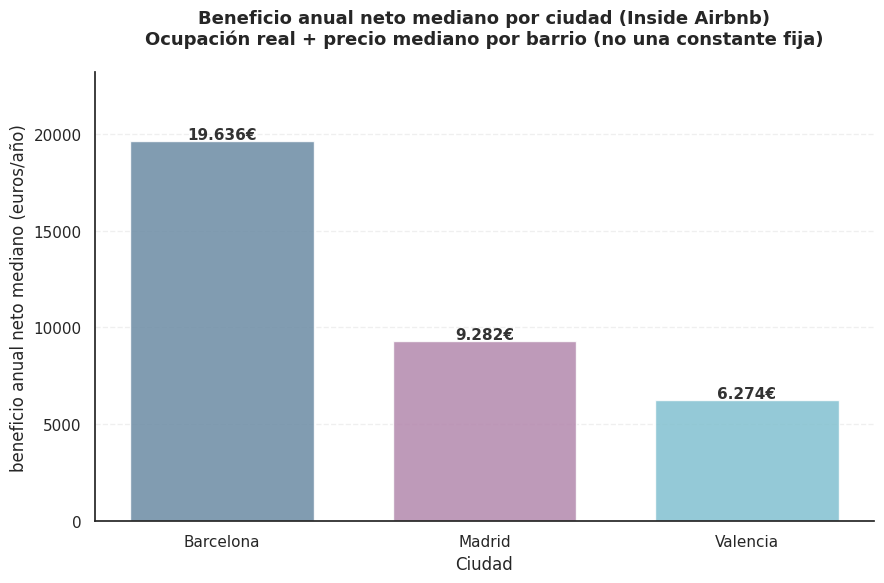

In [215]:
# Gráfico de beneficio anual neto mediano por ciudad

ciudades = ["Barcelona", "Madrid", "Valencia"]
colores  = ["#6b8ba4", "#b388ad", "#82c0d0"]

# Ra_mediano = beneficio anual neto mediano por ciudad
ar_dict  = dict(zip(ra_ciudad_exp["ciudad"], ra_ciudad_exp["Ra_mediano"]))
valores  = [ar_dict.get(c, 0) for c in ciudades]

sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(9, 6))

for i, (ciudad, val, color) in enumerate(zip(ciudades, valores, colores)):
    plt.bar(ciudad, val, color=color, alpha=0.85, edgecolor="white", width=0.7)
    plt.text(i, val + 100, f"{fmt(val)}€", ha="center", fontweight="bold",
             fontsize=11, color="#333333")

plt.title("Beneficio anual neto mediano por ciudad (Inside Airbnb)\n"
          "Ocupación real + precio mediano por barrio (no una constante fija)",
          fontsize=13, pad=20, fontweight="bold")
plt.xlabel("Ciudad", fontsize=12)
plt.ylabel("beneficio anual neto mediano (euros/año)", fontsize=12)
plt.ylim(0, max(v for v in valores if v > 0) * 1.18)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig("annual_revenue_por_ciudad.png", dpi=150, bbox_inches="tight")
plt.show()


Ingreso anual neto mediano por ciudad (Inside Airbnb)

Este gráfico muestra el **Annual Revenue neto mediano** de cada ciudad, calculado con la **ocupación real** y el **precio mediano por barrio**.  
El valor neto descuenta el 35 % de costes operativos (COSTE_OP = 0.35), por lo que representa el beneficio anual estimado de un alojamiento completo gestionado de forma profesional.

- **Barcelona**: 19 645 €  
- **Madrid**: 9 282 €  
- **Valencia**: 6 274 €

Barcelona duplica a Madrid y triplica a Valencia en ingresos netos anuales, reflejando su mayor ADR y ocupación profesional.  
Madrid mantiene un nivel medio y Valencia, aunque más baja en revenue, sigue siendo competitiva por su menor precio de compra.

Este visual es la referencia principal para comparar rentabilidad potencial entre ciudades dentro del dashboard de Power BI.


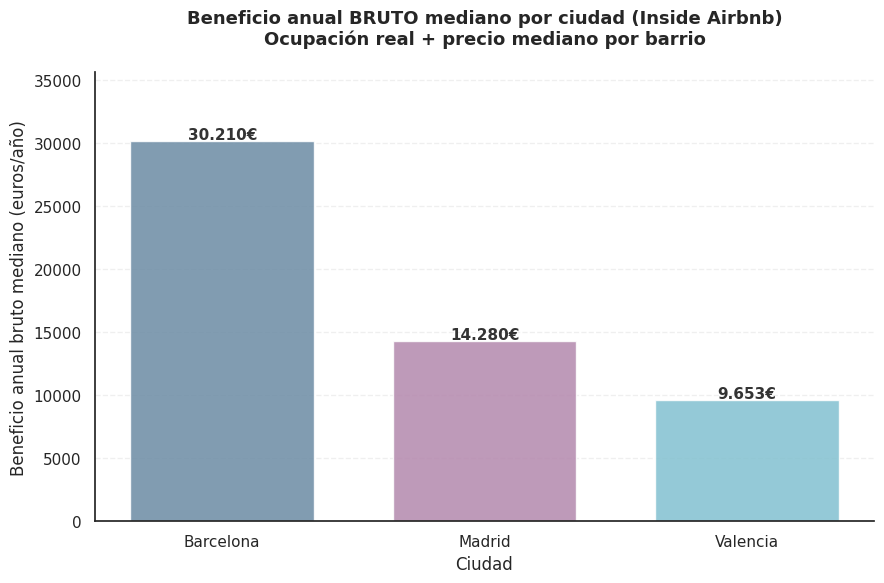

In [216]:
# Gráfico de ingreso anual BRUTO mediano por ciudad

ciudades = ["Barcelona", "Madrid", "Valencia"]
colores  = ["#6b8ba4", "#b388ad", "#82c0d0"]

# beneficio_bruto_mediano = ingreso anual bruto mediano por ciudad
ar_bruto_dict = dict(zip(
    beneficio_ciudad_exp["ciudad"],
    beneficio_ciudad_exp["beneficio_bruto_mediano"]
))
valores_bruto = [ar_bruto_dict.get(c, 0) for c in ciudades]

sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(9, 6))

for i, (ciudad, val, color) in enumerate(zip(ciudades, valores_bruto, colores)):
    plt.bar(ciudad, val, color=color, alpha=0.85, edgecolor="white", width=0.7)
    plt.text(i, val + 150, f"{fmt(val)}€", ha="center", fontweight="bold",
             fontsize=11, color="#333333")

plt.title(
    "Beneficio anual BRUTO mediano por ciudad (Inside Airbnb)\n"
    "Ocupación real + precio mediano por barrio",
    fontsize=13, pad=20, fontweight="bold"
)

plt.xlabel("Ciudad", fontsize=12)
plt.ylabel("Beneficio anual bruto mediano (euros/año)", fontsize=12)
plt.ylim(0, max(v for v in valores_bruto if v > 0) * 1.18)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig("annual_revenue_bruto_por_ciudad.png", dpi=150, bbox_inches="tight")
plt.show()


**Escenario profesional (comparativo con fuentes externas)**

Este grafico muestra el beneficio anual **bruto** por ciudad en el escenario profesional, calculado con el ADR mediano de la curva de estacionalidad y la **ocupacion mediana de los anuncios Superhost** de cada ciudad. Representa el comportamiento de un alojamiento gestionado de forma profesional, que es la cifra comparable con las estimaciones de AirDNA, AirROI y Airbtics.

- **Barcelona:** 47.028 EUR/año
- **Madrid:** 26.221 EUR/año
- **Valencia:** 16.558 EUR/año

Este escenario refleja la capacidad de facturacion de los anuncios mejor gestionados del mercado. El modelo principal sigue usando el ADR mediano y la ocupacion media para estimar la rentabilidad neta (Ra y ROI365), manteniendo la coherencia metodologica conservadora del resto del proyecto.


In [217]:
ar_profesional_bruto = (
    mr_ciudad[mr_ciudad["escenario"] == "profesional_superhost"]
    .groupby("ciudad")["monthly_revenue_gross"].sum().round(2).to_dict()
)

print("Beneficio anual bruto profesional por ciudad (suma de 12 meses, Superhost):")
for ciudad, valor in ar_profesional_bruto.items():
    print(f"  {ciudad}: {valor:,.0f} €/año")

Beneficio anual bruto profesional por ciudad (suma de 12 meses, Superhost):
  Barcelona: 47,028 €/año
  Madrid: 26,221 €/año
  Valencia: 16,558 €/año


El modelo utiliza el precio mediano (tras eliminar outliers) como ADR base porque Inside Airbnb no publica el ADR realizado de las noches reservadas.
La mediana representa el precio típico del mercado y evita que anuncios extremos distorsionen las estimaciones, por lo que es adecuada para construir un escenario conservador y robusto (AR neto y ROI).

Los proveedores comerciales como AirDNA o AirROI calculan el ADR a partir de reservas efectivas, de modo que sus valores están ponderados por las noches realmente vendidas y suelen ser más elevados.

Dado que Inside Airbnb no ofrece esa información, el modelo incorpora un segundo escenario, de carácter comparativo, utilizando la media de los precios medianos junto con una ocupación Superhost.
Este escenario no pretende reproducir el ADR basado en reservas efectivas, sino ofrecer una referencia inspirada en las metodologías empleadas por proveedores comerciales.

En Power BI se muestran dos enfoques complementarios:
ADR mediano - escenario conservador y metodológicamente robusto.

Escenario profesional - referencia comparativa inspirada en prácticas de proveedores comerciales.

No existe inconsistencia entre ambos: responden a objetivos analíticos distintos y permiten evaluar la inversión desde perspectivas complementarias.

## 6.3 Precio por tipo de alojamiento y coordenadas por barrio

Dos exportaciones de apoyo para el dashboard:

**`precio_por_tipo_ciudad_pbi.csv`** - el visual que responde a "¿por qué solo
alojamientos completos?": muestra el precio mediano de cada tipo de alojamiento
por ciudad. Madrid y Valencia desde Inside Airbnb (2025); Barcelona desde
Pontia reescalado por el factor de inflación (única fuente con tipo estándar y
precio en esa ciudad - el valor de la habitación es aproximado, porque el
factor se calibró con pisos enteros, y así se etiqueta en la columna `fuente`).

**`barrio_coordenadas_pbi.csv`** - centro geográfico de cada barrio (media de
latitud/longitud de sus anuncios de Inside Airbnb). Se relaciona en Power BI
con `beneficio_por_id_barrio_pbi.csv` por `id_barrio_oficial` y habilita el mapa de
burbujas "Ra por barrio" (página Alquiler) y el mapa por barrio de la página
de Inversión.

In [218]:
#CSV 1: precio mediano por tipo de alojamiento y ciudad
#Madrid y Valencia: Inside Airbnb (2025), precio real
tipo_mv = (
    df_inside_limpio[
        df_inside_limpio["precio_eur"].notna() &
        df_inside_limpio["ciudad"].isin(["Madrid", "Valencia"])]
    .groupby(["ciudad", "tipo_alojamiento"])["precio_eur"]
    .agg(precio_mediano="median", n_anuncios="count").round(2).reset_index()
)
tipo_mv["fuente"] = "Inside Airbnb 2025"

#Barcelona: Pontia x factor de inflacion (Inside Airbnb no publica precio alli).
#OJO: FACTOR_BCN se calibro con pisos enteros; aplicado a 'Private room' es una
#aproximacion (asume misma inflacion en ambos segmentos) y se etiqueta como tal.
tipo_bcn = (
    df_limpio[df_limpio["ciudad"] == "Barcelona"]
    .groupby(["ciudad", "tipo_alojamiento"])["precio"]
    .agg(precio_mediano="median", n_anuncios="count").reset_index()
)
tipo_bcn["precio_mediano"] = (tipo_bcn["precio_mediano"] * FACTOR_BCN).round(2)
tipo_bcn["fuente"] = "Pontia x factor inflacion 2026 (aprox.)"

precio_por_tipo = pd.concat([tipo_mv, tipo_bcn], ignore_index=True)
precio_por_tipo = precio_por_tipo[precio_por_tipo["n_anuncios"] >= 5]
precio_por_tipo.to_csv("precio_por_tipo_ciudad_pbi.csv", index=False, encoding="utf-8-sig")
print(f"precio_por_tipo_ciudad_pbi.csv: {fmt(len(precio_por_tipo))} filas (ciudad x tipo)")
print(precio_por_tipo.to_string(index=False))
print()

#CSV 2: coordenadas (centro) por barrio, para los mapas
#Media de lat/lon de los anuncios de Inside Airbnb de cada barrio: suficiente
#como centroide para un mapa de burbujas (no pretende ser el centroide
#geometrico oficial del poligono del barrio)
barrio_coords = (
    df_ia_con_id[df_ia_con_id["id_barrio_oficial"].notna()]
    .groupby(["id_barrio_oficial", "barrio_oficial", "ciudad"])
    .agg(latitud=("latitud", "mean"), longitud=("longitud", "mean"),
         n_anuncios=("latitud", "count"))
    .round({"latitud": 6, "longitud": 6}).reset_index()
)
#NO se exporta: la tabla de barrios del modelo de Power BI ya incorpora la
#armonizacion y las coordenadas, de modo que este CSV seria redundante.
#El calculo se mantiene por si hiciera falta reconstruir el centroide.
print(f"Coordenadas por barrio (solo en memoria, no se exporta): "
      f"{fmt(len(barrio_coords))} barrios con centro geografico")

#CSV 3 Comparativa de precio mediano turistico vs no turistico (flag 1/0), grano
#ciudad x grupo. Usa PRECIO CRUDO de cada anuncio (nunca el precio asignado
#por jerarquia del listing, que en flag=0 cae siempre al fallback de ciudad
#y no aportaria informacion real de esos barrios).

#Madrid y Valencia: Inside Airbnb (precio_eur real por anuncio)
df_precio_grupo = df_lic_base[
    df_lic_base["ciudad"].isin(["Madrid", "Valencia"]) &
    (df_lic_base["tipo_alojamiento"] == "Entire home/apt") &
    df_lic_base["precio_eur"].notna()
].copy()

precio_grupo = (df_precio_grupo
               .groupby(["ciudad", "barrio_turistico_objetivo"])["precio_eur"]
               .agg(precio_mediano="median", n_anuncios="count").round(2).reset_index())
precio_grupo["fuente"] = "Inside Airbnb 2025"

#Barcelona: REUTILIZA pontia_bcn_ra y FACTOR_BCN de la Parte 5
pontia_bcn_grupo = pontia_bcn_ra.merge(
    df_barrios_clean.loc[df_barrios_clean["ciudad"] == "Barcelona",
                         ["barrio_oficial", "barrio_turistico_objetivo"]],
    on="barrio_oficial", how="left"
)
pontia_bcn_grupo = pontia_bcn_grupo[pontia_bcn_grupo["barrio_turistico_objetivo"].notna()]

precio_grupo_bcn = (pontia_bcn_grupo.groupby("barrio_turistico_objetivo")["precio"]
                    .agg(precio_mediano="median", n_anuncios="count").reset_index())
precio_grupo_bcn["precio_mediano"] = (precio_grupo_bcn["precio_mediano"] * FACTOR_BCN).round(2)
precio_grupo_bcn["ciudad"] = "Barcelona"
precio_grupo_bcn["fuente"] = "Pontia 2017-2021 x factor scraping 2026"

#Union de las 3 ciudades y export final
precio_grupo = pd.concat([precio_grupo, precio_grupo_bcn], ignore_index=True)
precio_grupo["grupo"] = precio_grupo["barrio_turistico_objetivo"].map(
    {1: "Turistico", 0: "No turistico"})

precio_grupo.to_csv("precio_por_barrio_turistico_pbi.csv", index=False, encoding="utf-8-sig")

print("Precio mediano por grupo turistico/no turistico (las 3 ciudades):")
print(precio_grupo[["ciudad", "grupo", "precio_mediano", "n_anuncios", "fuente"]].to_string(index=False))
print()
for ciu in ["Barcelona", "Madrid", "Valencia"]:
    sub = precio_grupo[precio_grupo["ciudad"] == ciu].set_index("barrio_turistico_objetivo")
    if {0, 1}.issubset(sub.index):
        prima = (sub.loc[1, "precio_mediano"] / sub.loc[0, "precio_mediano"] - 1) * 100
        print(f"{ciu}: prima turistica {prima:+.1f}%")

precio_por_tipo_ciudad_pbi.csv: 12 filas (ciudad x tipo)
   ciudad tipo_alojamiento  precio_mediano  n_anuncios                                  fuente
   Madrid  Entire home/apt          109.65       13648                      Inside Airbnb 2025
   Madrid       Hotel room          129.20          41                      Inside Airbnb 2025
   Madrid     Private room           42.50        5116                      Inside Airbnb 2025
   Madrid      Shared room           25.50         148                      Inside Airbnb 2025
 Valencia  Entire home/apt           96.90        5236                      Inside Airbnb 2025
 Valencia       Hotel room          106.25          13                      Inside Airbnb 2025
 Valencia     Private room           39.10        1720                      Inside Airbnb 2025
 Valencia      Shared room           38.67          10                      Inside Airbnb 2025
Barcelona  Entire home/apt          212.00        1204 Pontia x factor inflacion 2026 (a

1. Precio mediano por tipo de alojamiento y ciudad
Inside Airbnb publica precios por noche para Madrid y Valencia, pero no para Barcelona.
Por ello, el precio mediano se calcula de la siguiente forma:

Madrid y Valencia- precio_eur de Inside Airbnb (2025), tras eliminar outliers.

Barcelona- precio de Pontia ajustado con FACTOR_BCN.

Este factor se calibró con alojamientos completos; aplicarlo a private room es una aproximación, y se etiqueta como tal en el CSV.

El resultado se exporta como precio_por_tipo_ciudad_pbi.csv, filtrando únicamente tipos de alojamiento con ≥5 anuncios, para garantizar estabilidad estadística en Power BI.

2. Coordenadas aproximadas por barrio
Inside Airbnb sí publica latitud y longitud de cada anuncio.
Se calcula la media de lat/lon por id_barrio_oficial, lo que proporciona un centroide aproximado para cada barrio.
Este centroide es suficiente para mapas de burbujas en Power BI y no pretende ser el centro geométrico oficial del polígono del barrio.

El resultado se exporta como barrio_coordenadas_pbi.csv.

In [219]:
#Descarga de todos los archivos generados
#Funciona tanto en Google Colab como en local (VS Code u otro entorno)

#Solo los archivos que consume realmente el cuadro de mando. Las tablas que
#el cuaderno calcula pero no exporta (beneficio por ciudad, beneficio por
#barrio+habitaciones, precio de referencia por ciudad y coordenadas por
#barrio) no aparecen aqui: ver la nota de cada celda.
ARCHIVOS_EXPORTADOS = [
    "listing_precio_habitaciones_pbi.csv",
    "estacionalidad_pbi.csv",
    "beneficio_mensual_ciudad_pbi.csv",
    "beneficio_por_id_barrio_pbi.csv",
    "licencias_por_ciudad_pbi.csv",
    "licencias_por_barrio_pbi.csv",
    "precio_por_tipo_ciudad_pbi.csv",
    "precio_por_barrio_turistico_pbi.csv"
]

if EN_COLAB:
    for archivo in ARCHIVOS_EXPORTADOS:
        try:
            files.download(archivo)
            print(f"Descargado: {archivo}")
        except Exception as e:
            print(f"No disponible: {archivo} ({e})")
else:
    carpeta = "exportacion_pbi"
    os.makedirs(carpeta, exist_ok=True)
    for archivo in ARCHIVOS_EXPORTADOS:
        if os.path.exists(archivo):
            shutil.copy(archivo, os.path.join(carpeta, archivo))
            print(f"Guardado en {carpeta}/: {archivo}")
        else:
            print(f"No encontrado: {archivo}")
    print(f"\nAbre la carpeta '{carpeta}' para ver todos los archivos.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargado: listing_precio_habitaciones_pbi.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Descargado: precio_por_tipo_ciudad_pbi.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargado: precio_por_barrio_turistico_pbi.csv


# PARTE 7 - Calculo del ROI365 por inmueble

El ROI mide la rentabilidad real de comprar un inmueble para alquilarlo en Airbnb:

**ROI (%) = Ra mediano del barrio / Precio de compra × 100**

El cruce se hace por `id_barrio_oficial`, la llave generada en la Parte 5.
Esto permite calcular el ROI a nivel de barrio, mucho más preciso que a nivel de ciudad.

In [220]:
#Descarga del CSV de compra (Fotocasa + Idealista) desde Google Drive
#Sustituye file_id_compra por el ID real del archivo compartido en Drive

file_id_compra = "1QY2ZVGjDXtwpRFvRMxtEht8A01qIpp-Y"

gdown.download(f"https://drive.google.com/uc?id={file_id_compra}",
               "datos_compra_inmuebles_listo.csv", quiet=False)

df_compra = pd.read_csv("datos_compra_inmuebles_listo.csv", encoding="utf-8-sig")
print(f"Inmuebles de compra cargados: {fmt(len(df_compra))}")
print(f"Columnas: {df_compra.columns.tolist()}")


Downloading...
From: https://drive.google.com/uc?id=1QY2ZVGjDXtwpRFvRMxtEht8A01qIpp-Y
To: /content/datos_compra_inmuebles_listo.csv
100%|██████████| 3.25M/3.25M [00:00<00:00, 211MB/s]

Inmuebles de compra cargados: 30.893
Columnas: ['base_datos', 'id_anuncio', 'precio_inmueble', 'precio_m2', 'tipo_inmueble', 'habitaciones', 'baños', 'metros_cuadrados', 'num_planta', 'id_barrio_oficial', 'dias_publicado', 'detalles_extra', 'segmento_precio', 'segmento_precio_m2']


## 7.1 Tablas de precio de Airbnb por barrio y por barrio + habitaciones

Se construyen las **dos tablas de referencia de precio por noche** de Airbnb que se usarán para
clasificar los pisos en venta de Fotocasa e Idealista:

1. **Precio mediano por barrio** (`precio_airbnb_por_barrio_pbi.csv`)
2. **Precio mediano por barrio + número de habitaciones** (`precio_airbnb_por_barrio_habitaciones_pbi.csv`)

Se usa la **mediana** (no la media) para que los inmuebles de lujo no arrastren el precio hacia arriba,
en coherencia con el resto del cuaderno.

**Fuente de precio por ciudad:**

| Ciudad | Por barrio | Por barrio + habitaciones |
|---|---|---|
| Madrid | Inside Airbnb (`precio_eur`) | Inside Airbnb (`precio_eur`) |
| Valencia | Inside Airbnb (`precio_eur`) | Inside Airbnb (`precio_eur`) |
| Barcelona | Scraping Airbnb 2026 (`precio_limpio`) | Pontia × factor de inflación 2026 |

Barcelona no tiene precio en Inside Airbnb (0% de disponibilidad), por lo que el precio por barrio
sale del scraping propio de Airbnb 2026. Como el scraping no informa el número de habitaciones,
el desglose por habitaciones se estima con Pontia escalado al mercado actual
(factor = mediana scraping 2026 / mediana Pontia), la misma técnica de la Parte 4.4.

Solo se aceptan grupos con **mínimo 5 inmuebles** para que la mediana sea representativa.
La llave de salida es `id_barrio_oficial`, la misma que usan Fotocasa e Idealista.
También se calcula la **ocupación media estimada** (Inside Airbnb, tope 255/365) por barrio
y por ciudad, necesaria para el ROI365.

**Nota de esta versión:** las tablas de precio (`tabla_precio_barrio`, `tabla_precio_barrio_hab`, `tabla_ciudad_hab`, `tabla_ciudad`) y la ocupación (`oc_barrio`, `oc_ciudad`) ya se construyeron **una sola vez** en la Parte 5, con los mismos filtros IQR, el mismo saneamiento de consistencia interna y el mismo estimador de credibilidad. La celda siguiente solo define las funciones de normalización necesarias para el cruce con Fotocasa/Idealista y verifica que las tablas están en memoria. Así, el Ra del dashboard y el ROI365 comparten exactamente los mismos precios (en versiones anteriores este cálculo estaba duplicado con sufijo `_ROI` y era una fuente potencial de divergencias).


In [221]:
#Funciones de armonización de barrios para el cruce con Fotocasa/Idealista
#y verificación de que las tablas de precio/ocupación de la Parte 5 están
#en memoria. Esta celda YA NO reconstruye las tablas: se reutilizan las de
#la Parte 5 para que el Ra del dashboard y el ROI365 usen exactamente los
#mismos precios (ver nota metodológica de arriba).
#Requiere haber ejecutado las Partes 1-6.


def normalizar_barrio(texto):
    """Normaliza un nombre de barrio para compararlo entre fuentes:
    minúsculas, sin acentos y sin signos de puntuación."""
    if pd.isna(texto):
        return None
    t = str(texto).strip().lower()
    t = unicodedata.normalize("NFKD", t)
    t = "".join(c for c in t if not unicodedata.combining(c))
    t = "".join(c if c.isalnum() else " " for c in t)
    return " ".join(t.split())


def normalizar_id(v):
    """Homogeneiza el id_barrio_oficial entre fuentes (int si es numérico, texto si no)."""
    if pd.isna(v):
        return None
    try:
        return int(float(v))
    except (ValueError, TypeError):
        return str(v).strip()


#Lookup (ciudad, nombre oficial normalizado) -> (id_barrio_oficial, barrio_oficial)
#Solo barrios del universo del proyecto (barrio_turistico_objetivo = 1),
#coherente con la armonizacion de la Parte 5 (ver nota en el Ra por barrio)
lookup_oficial = {}
for _, fila in df_barrios_clean[df_barrios_clean["barrio_turistico_objetivo"] == 1].iterrows():
    clave = (fila["ciudad"], normalizar_barrio(fila["barrio_oficial"]))
    lookup_oficial[clave] = (normalizar_id(fila["id_barrio_oficial"]), fila["barrio_oficial"])


def a_barrio_oficial(ciudad, barrio):
    """Devuelve (id_barrio_oficial, barrio_oficial) para un nombre de barrio de
    cualquier fuente: primero vía diccionario de armonización de la Parte 5,
    después por coincidencia normalizada contra la tabla maestra."""
    if pd.isna(barrio):
        return (None, None)
    nombre = BARRIO_AB_A_OFICIAL.get(str(barrio).strip(), str(barrio).strip())
    if nombre is None:
        return (None, None)
    return lookup_oficial.get((ciudad, normalizar_barrio(nombre)), (None, None))


def asignar_barrio_oficial(df, columna_barrio, ciudad):
    """Añade id_barrio_oficial y barrio_oficial a un dataframe mapeando solo los valores únicos."""
    mapa = {b: a_barrio_oficial(ciudad, b) for b in df[columna_barrio].dropna().unique()}
    df["id_barrio_oficial"] = df[columna_barrio].map(lambda b: mapa[b][0] if pd.notna(b) else None)
    df["barrio_oficial"]    = df[columna_barrio].map(lambda b: mapa[b][1] if pd.notna(b) else None)
    return df


#Verificación: las tablas de la Parte 5 deben estar en memoria
for nombre in ["tabla_precio_barrio", "tabla_precio_barrio_hab",
               "tabla_ciudad_hab", "tabla_ciudad", "oc_barrio", "oc_ciudad"]:
    assert nombre in globals(), (
        f"'{nombre}' no está en memoria: ejecuta primero la Parte 5 "
        "(celda 'Ra por barrio'), que construye las tablas de precio y ocupación.")

#Normalizamos las claves de id para el cruce con el CSV de compra
#(las tablas vienen de la Parte 5 con ids enteros; normalizar_id garantiza
#que coincidan con los ids derivados del CSV de Fotocasa/Idealista)
tabla_precio_barrio["id_barrio_oficial"]     = tabla_precio_barrio["id_barrio_oficial"].map(normalizar_id)
tabla_precio_barrio_hab["id_barrio_oficial"] = tabla_precio_barrio_hab["id_barrio_oficial"].map(normalizar_id)
oc_barrio = {normalizar_id(k): v for k, v in oc_barrio.items()}

print("Tablas de la Parte 5 reutilizadas para el ROI365:")
print(f"tabla_precio_barrio: {fmt(len(tabla_precio_barrio))} barrios")
print(tabla_precio_barrio.groupby("ciudad")["id_barrio_oficial"].count().to_string())
print()
print(f"tabla_precio_barrio_hab: {fmt(len(tabla_precio_barrio_hab))} combinaciones barrio+habitaciones")
print(tabla_precio_barrio_hab.groupby("ciudad")["id_barrio_oficial"].count().to_string())
print()
print("Muestra de la tabla por barrio y habitaciones:")
print(tabla_precio_barrio_hab.head(8).to_string(index=False))


Tablas de la Parte 5 reutilizadas para el ROI365:
tabla_precio_barrio: 96 barrios
ciudad
Barcelona    17
Madrid       47
Valencia     32

tabla_precio_barrio_hab: 277 combinaciones barrio+habitaciones
ciudad
Barcelona     50
Madrid       140
Valencia      87

Muestra de la tabla por barrio y habitaciones:
ciudad  id_barrio_oficial barrio_oficial  hab_grupo  precio_noche_mediano  n_inmuebles fuente_precio     hab_nombre  Oc_media  Ra_mediano
Madrid             102002        Acacias          1                84.150           65 Inside Airbnb   1 habitacion    0.3209     6406.64
Madrid             102002        Acacias          2                97.750           31 Inside Airbnb 2 habitaciones    0.3209     7442.05
Madrid             102002        Acacias          3               121.125            8 Inside Airbnb 3 habitaciones    0.3209     9221.67
Madrid             102052        Chopera          1                78.200           53 Inside Airbnb   1 habitacion    0.3275     6076.09
Mad

## 7.2 Clasificacion de los pisos en venta y calculo del ROI365

Cada piso en venta se clasifica con la tabla de precios de la Parte 7.1 según su barrio y su
número de habitaciones. Si no hay dato suficiente en su nivel, se baja al siguiente nivel de
precisión (columna `nivel_precio` para trazabilidad):

1. **Barrio + habitaciones** → 2. **Barrio** → 3. **Ciudad + habitaciones** → 4. **Ciudad**

**Fórmula del ROI365:**

$$ROI365\ (\%) = \frac{precio\_noche \times 365 \times ocupación\_media \times (1 - 0{,}35)}{precio\_compra} \times 100$$

- `ocupación_media`: ocupación estimada de Inside Airbnb del barrio (o de la ciudad si el barrio no tiene dato), con tope metodológico de 255/365.
- `35%` de gastos operativos: comisión Airbnb + limpieza + impuestos/seguros (mismo supuesto que el Ra de la Parte 5).

**Puntuación ROI365** (misma escala que el resto del proyecto):
menos de 5% = Baja rentabilidad · 5-10% = Media rentabilidad · 10% o más = Alta rentabilidad.

La celda detecta automáticamente los nombres de las columnas del CSV de venta
(precio, habitaciones, fuente, id de barrio), por lo que funciona aunque cambien ligeramente.

**Deduplicación entre portales (Fotocasa/Idealista):** antes de calcular el ROI365, se eliminan los pisos que aparecen en ambos portales a la vez (mismo barrio, tipo, habitaciones, metros y precio). La detección se hace en dos pasadas para no dejar escapar los casos en que un portal informa la planta y el otro la deja vacía. La celda imprime un desglose de los duplicados eliminados por ciudad, evitando que la cartera de 300M€ "compre" dos veces el mismo inmueble.

In [222]:
#A cada piso en venta se le asigna un precio/noche estimado de Airbnb segun su
#barrio y numero de habitaciones, con esta jerarquia de precision:
#  Nivel 1: barrio + habitaciones   (tabla_precio_barrio_hab)
#  Nivel 2: barrio                  (tabla_precio_barrio)
#  Nivel 3: ciudad + habitaciones   (tabla_ciudad_hab)
#  Nivel 4: ciudad                  (tabla_ciudad)
#
#ROI365 (%) = precio_noche x 365 x ocupacion_media x (1 - 35% gastos) / precio_compra x 100

#Se usan las constantes globales COSTE_OP (35% de gastos) y 365 días (Parte 1.1)

#Cargamos el CSV unificado de Fotocasa e Idealista (descargado en la celda anterior)
try:
    df_venta = pd.read_csv("datos_compra_inmuebles_listo.csv", encoding="utf-8-sig")
except FileNotFoundError:
    df_venta = df_compra.copy()  #fallback: ya cargado en la celda anterior
print(f"Pisos en venta cargados (Fotocasa + Idealista): {fmt(len(df_venta))}")
print(f"Columnas: {df_venta.columns.tolist()}")

#DEDUP ENTRE PORTALES (REFORZADO): el mismo piso fisico suele publicarse a
#la vez en Fotocasa Y en Idealista con ids distintos. Sin este paso, la cartera
#de inversion "compraba" el mismo piso dos veces, inflando inversion y numero de
#oportunidades. Se considera el mismo piso si coinciden barrio, tipo,
#habitaciones, metros y precio exacto; se conserva la primera aparicion (el
#portal es indiferente porque los datos relevantes son identicos).
#
#MEJORA RESPECTO A LA VERSION ANTERIOR: antes la clave incluia num_planta, pero
#esa columna tiene 4.569 nulos. Cuando el mismo piso venia en Fotocasa con
#planta informada y en Idealista con planta vacia (o al reves), la clave los
#trataba como pisos distintos (NaN != 4) y ~1.559 duplicados se colaban en la
#cartera. Ahora la dedup se hace en DOS PASADAS:
#  Pasada A: clave estricta CON planta (elimina los duplicados con planta
#            coincidente o ambas nulas).
#  Pasada B: sobre lo que queda, clave SIN planta pero solo entre filas donde
#            AL MENOS UNA tiene la planta nula (recupera los pares que solo
#            diferian por el hueco de planta, sin fusionar pisos reales de
#            distinta planta que si estan ambas informadas).
_claves_con_planta = [c for c in ["id_barrio_oficial", "barrio", "ciudad", "tipo_inmueble",
                                  "habitaciones", "metros_cuadrados", "num_planta",
                                  "precio_inmueble"] if c in df_venta.columns]
_claves_sin_planta = [c for c in _claves_con_planta if c != "num_planta"]
_n_antes_venta = len(df_venta)
_ciudad_col_dedup = "ciudad" if "ciudad" in df_venta.columns else None

#Conteo de duplicados por ciudad ANTES de eliminarlos (para el informe)
def _marcar_duplicados(df, claves, solo_si_planta_nula=False):
    """Devuelve una mascara booleana de filas duplicadas (todas menos la 1a de
    cada grupo). Si solo_si_planta_nula=True, un grupo solo se colapsa cuando
    alguna de sus filas tiene num_planta nula (evita fusionar plantas reales)."""
    if solo_si_planta_nula and "num_planta" in df.columns:
        grupo_con_nulo = df.groupby(claves)["num_planta"].transform(
            lambda x: x.isna().any())
        candidatas = df[grupo_con_nulo]
        marca = pd.Series(False, index=df.index)
        marca.loc[candidatas.index] = candidatas.duplicated(subset=claves, keep="first")
        return marca
    return df.duplicated(subset=claves, keep="first")

#Pasada A: clave estricta con planta
_dup_A = _marcar_duplicados(df_venta, _claves_con_planta)
#Pasada B: sobre lo restante, recuperar pares que solo difieren en planta nula
_restante = df_venta[~_dup_A]
_dup_B_rel = _marcar_duplicados(_restante, _claves_sin_planta, solo_si_planta_nula=True)
_dup_B = pd.Series(False, index=df_venta.index)
_dup_B.loc[_restante.index] = _dup_B_rel

_es_duplicado = _dup_A | _dup_B

#Informe de duplicados eliminados por ciudad
if _ciudad_col_dedup:
    print("Duplicados entre portales (Fotocasa/Idealista) eliminados por ciudad:")
    _informe = pd.DataFrame({
        "planta_coincidente": df_venta[_dup_A].groupby(_ciudad_col_dedup).size(),
        "solo_planta_nula":   df_venta[_dup_B].groupby(_ciudad_col_dedup).size(),
    }).fillna(0).astype(int)
    _informe["total"] = _informe["planta_coincidente"] + _informe["solo_planta_nula"]
    _informe = _informe.sort_values("total", ascending=False)
    for _ciudad, _fila in _informe.iterrows():
        print(f"  {_ciudad}: {fmt(_fila['total'])} duplicados "
              f"({fmt(_fila['planta_coincidente'])} con planta coincidente + "
              f"{fmt(_fila['solo_planta_nula'])} recuperados por planta nula)")
    print(f"  {'-'*50}")
    print(f"  TOTAL: {fmt(_informe['total'].sum())} duplicados eliminados "
          f"({fmt(_informe['solo_planta_nula'].sum())} que la version anterior "
          f"dejaba escapar)")

#Aplicar la eliminacion
df_venta = df_venta[~_es_duplicado].copy()
print(f"\nPisos tras deduplicar: {fmt(len(df_venta))} unicos "
      f"(de {fmt(_n_antes_venta)} publicados en los dos portales)")
#LIMITACION RESIDUAL (documentada): la clave exige coincidencia en tipo_inmueble.
#Los portales a veces etiquetan el mismo piso con tipos distintos ("Estudio" vs
#"Piso") -> quedan ~13 parejas dudosas. No se relaja la clave porque
#precio+metros SIN tipo tambien describen unidades reales distintas de una misma
#promocion de obra nueva: se prefiere un dedup conservador con residuo conocido
#a uno agresivo que fusione pisos reales.
print()


def detectar_columna(df, candidatas):
    """Devuelve la primera columna del dataframe que coincida con la lista de candidatas."""
    for c in candidatas:
        if c in df.columns:
            return c
    #busqueda insensible a mayusculas
    minusculas = {col.lower().strip(): col for col in df.columns}
    for c in candidatas:
        if c.lower() in minusculas:
            return minusculas[c.lower()]
    return None


col_precio_compra = detectar_columna(df_venta, ["precio_inmueble", "precio_venta", "precio_compra", "precio"])
col_habitaciones  = detectar_columna(df_venta, ["habitaciones", "n_habitaciones", "num_habitaciones", "habs", "rooms"])
col_fuente        = detectar_columna(df_venta, ["fuente", "portal", "origen", "source", "web"])
col_ciudad        = detectar_columna(df_venta, ["ciudad", "city", "localidad", "municipio"])
col_id_barrio     = detectar_columna(df_venta, ["id_barrio_oficial", "id_barrio"])
col_barrio_nombre = detectar_columna(df_venta, ["barrio_oficial", "barrio", "neighbourhood", "zona"])

if col_precio_compra is None:
    raise KeyError("No se encontro la columna de precio de compra en el CSV de Fotocasa/Idealista.")
print(f"Columna de precio de compra: '{col_precio_compra}'")
print(f"Columna de habitaciones:     '{col_habitaciones}'")
print(f"Columna de fuente/portal:    '{col_fuente}'")
print(f"Columna de id de barrio:     '{col_id_barrio}'")
print()

#Preparacion de las llaves de cruce
df_venta["_precio_compra"] = pd.to_numeric(df_venta[col_precio_compra], errors="coerce")
df_venta["_hab_grupo"] = (
    pd.to_numeric(df_venta[col_habitaciones], errors="coerce").clip(1, 4)
    if col_habitaciones else pd.Series(pd.NA, index=df_venta.index)
)

if col_id_barrio is not None:
    df_venta["_id_barrio"] = df_venta[col_id_barrio].map(normalizar_id)
elif col_barrio_nombre is not None and col_ciudad is not None:
    #Si no hay id_barrio_oficial, lo derivamos del nombre del barrio y la ciudad
    df_venta["_id_barrio"] = df_venta.apply(
        lambda f: a_barrio_oficial(str(f[col_ciudad]).strip().title(), f[col_barrio_nombre])[0], axis=1)
else:
    raise KeyError("El CSV de venta no tiene ni id_barrio_oficial ni barrio+ciudad para poder cruzar.")

#Diccionarios de consulta desde las tablas de precios de la Parte 7.1
dic_precio_bh = {(f["id_barrio_oficial"], f["hab_grupo"]): f["precio_noche_mediano"]
                 for _, f in tabla_precio_barrio_hab.iterrows()}
dic_precio_b  = dict(zip(tabla_precio_barrio["id_barrio_oficial"],
                         tabla_precio_barrio["precio_noche_mediano"]))
dic_info_b    = {f["id_barrio_oficial"]: (f["barrio_oficial"], f["ciudad"])
                 for _, f in tabla_precio_barrio.iterrows()}
dic_precio_ch = {(f["ciudad"], f["hab_grupo"]): f["precio_noche_mediano"]
                 for _, f in tabla_ciudad_hab.iterrows()}

#Ciudad de cada piso: columna propia o derivada del barrio
#IMPORTANTE: la ciudad se deriva de la TABLA MAESTRA de barrios (df_barrios_clean,
#282 barrios, Parte 5), NO de dic_info_b (que solo tiene los barrios con precio
#de Airbnb suficiente, 139). Si se usaba dic_info_b, cualquier barrio de una
#ciudad con huecos de datos (p.ej. Barcelona) se quedaba con _ciudad = None y
#nunca podia caer en el fallback de nivel 3/4 (ciudad), aunque ese nivel si
#tenia un precio calculado para esa ciudad.
mapa_id_a_ciudad = dict(zip(df_barrios_clean["id_barrio_oficial"].map(normalizar_id),
                            df_barrios_clean["ciudad"]))

if col_ciudad is not None:
    df_venta["_ciudad"] = df_venta[col_ciudad].astype(str).str.strip().str.title()
else:
    df_venta["_ciudad"] = df_venta["_id_barrio"].map(
        lambda i: mapa_id_a_ciudad.get(i, None))


def asignar_precio_noche(fila):
    """Asigna el precio/noche estimado con la jerarquia de 4 niveles."""
    id_b, hab, ciudad = fila["_id_barrio"], fila["_hab_grupo"], fila["_ciudad"]
    hab = int(hab) if pd.notna(hab) else None
    if id_b is not None and hab is not None and (id_b, hab) in dic_precio_bh:
        return pd.Series([dic_precio_bh[(id_b, hab)], "1-barrio+habitaciones"])
    if id_b is not None and id_b in dic_precio_b:
        return pd.Series([dic_precio_b[id_b], "2-barrio"])
    if ciudad is not None and hab is not None and (ciudad, hab) in dic_precio_ch:
        return pd.Series([dic_precio_ch[(ciudad, hab)], "3-ciudad+habitaciones"])
    if ciudad in tabla_ciudad:
        return pd.Series([tabla_ciudad[ciudad], "4-ciudad"])
    return pd.Series([None, "sin precio"])


df_venta[["precio_noche_estimado", "nivel_precio"]] = df_venta.apply(asignar_precio_noche, axis=1)

#Verificacion: cuantos pisos sin ciudad reconocida (deberia ser ~0 si el CSV
#de compra trae id_barrio_oficial valido, ya que ahora sale de la tabla maestra)
n_sin_ciudad = df_venta["_ciudad"].isna().sum()
print(f"Pisos sin ciudad reconocida: {fmt(n_sin_ciudad)} / {fmt(len(df_venta))}")

#Ocupacion media estimada: del barrio si existe, si no la de la ciudad
df_venta["ocupacion_media_estimada"] = df_venta["_id_barrio"].map(oc_barrio)
df_venta["ocupacion_media_estimada"] = df_venta["ocupacion_media_estimada"].fillna(
    df_venta["_ciudad"].map(oc_ciudad))

#Calculo del ROI365
beneficio_neto = (
    df_venta["precio_noche_estimado"].astype(float)
    * 365
    * df_venta["ocupacion_media_estimada"]
    * (1 - COSTE_OP)
)
df_venta["ROI365_%"] = (beneficio_neto / df_venta["_precio_compra"] * 100).round(2)
df_venta.loc[df_venta["_precio_compra"].isna() | (df_venta["_precio_compra"] <= 0), "ROI365_%"] = pd.NA


def puntuar_roi365(roi):
    """Puntuacion cualitativa del ROI365 (misma escala que el resto del proyecto)."""
    if pd.isna(roi):
        return "No calculable"
    if roi < 5:
        return "Baja rentabilidad"
    if roi < 10:
        return "Media rentabilidad"
    return "Alta rentabilidad"


df_venta["puntuacion_ROI365"] = df_venta["ROI365_%"].apply(puntuar_roi365)

#Resumen
roi_ok = df_venta[df_venta["ROI365_%"].notna()]
print(f"Pisos procesados: {fmt(len(df_venta))} | Con ROI365 calculado: {fmt(len(roi_ok))}")
print()
print("Nivel de precision del precio asignado:")
print(df_venta["nivel_precio"].value_counts().to_string())
print()
print("Estadisticas del ROI365 (%):")
print(f"  Minimo:  {fmt(roi_ok['ROI365_%'].min(), 2)}%")
print(f"  Mediano: {fmt(roi_ok['ROI365_%'].median(), 2)}%")
print(f"  Medio:   {fmt(roi_ok['ROI365_%'].mean(), 2)}%")
print(f"  Maximo:  {fmt(roi_ok['ROI365_%'].max(), 2)}%")
print()
print("Distribucion por puntuacion ROI365:")
print(df_venta["puntuacion_ROI365"].value_counts().to_string())
if col_fuente is not None:
    print()
    print("ROI365 mediano por portal:")
    print(df_venta.groupby(col_fuente)["ROI365_%"].median().to_string(float_format=lambda x: fmt(x, 2)))

Pisos en venta cargados (Fotocasa + Idealista): 30.893
Columnas: ['base_datos', 'id_anuncio', 'precio_inmueble', 'precio_m2', 'tipo_inmueble', 'habitaciones', 'baños', 'metros_cuadrados', 'num_planta', 'id_barrio_oficial', 'dias_publicado', 'detalles_extra', 'segmento_precio', 'segmento_precio_m2']

Pisos tras deduplicar: 25.370 unicos (de 30.893 publicados en los dos portales)

Columna de precio de compra: 'precio_inmueble'
Columna de habitaciones:     'habitaciones'
Columna de fuente/portal:    'None'
Columna de id de barrio:     'id_barrio_oficial'

Pisos sin ciudad reconocida: 0 / 25.370
Pisos procesados: 25.370 | Con ROI365 calculado: 25.370

Nivel de precision del precio asignado:
nivel_precio
1-barrio+habitaciones    12652
3-ciudad+habitaciones    10569
2-barrio                  2149

Estadisticas del ROI365 (%):
  Minimo:  0,10%
  Mediano: 2,18%
  Medio:   2,58%
  Maximo:  19,21%

Distribucion por puntuacion ROI365:
puntuacion_ROI365
Baja rentabilidad     22957
Media rentabilid

## 7.3 CSV final unificado para Power BI

Se exporta `roi365_fotocasa_idealista_pbi.csv` con **todos los pisos de Fotocasa e Idealista
unificados** (todas sus columnas originales) más las columnas nuevas:

- `puntuacion_ROI365`: clasificación cualitativa (Alta / Media / Baja rentabilidad / No calculable)
- `ROI365_%`: el ROI anualizado en porcentaje
- `precio_noche_estimado`, `ocupacion_media_estimada` y `nivel_precio`: trazabilidad del cálculo

El CSV se guarda con `encoding='utf-8-sig'` para que Power BI lea correctamente acentos y eñes.


In [223]:
#Mantiene todas las columnas originales del CSV de venta y añade:
#  puntuacion_ROI365, ROI365_% (pedidas) y 3 columnas de trazabilidad
#  (precio_noche_estimado, ocupacion_media_estimada, nivel_precio)

#Si df_venta no existe en esta sesion (celda ejecutada sola o tras reinicio),
#se detiene con un aviso claro en vez de un NameError críptico: hay que
#ejecutar antes la celda 8.3, que es la que crea df_venta y calcula ROI365_%
assert "df_venta" in dir(), (
    "df_venta no existe en esta sesion. Ejecuta primero la celda de la Parte 7.2 "
    "(y, si vienes de un reinicio, el cuaderno completo desde la Parte 1)."
)

#Añadimos ciudad y barrio legibles (desde la tabla maestra) antes de exportar,
#para que Power BI muestre nombres sin cruces adicionales. Se reconstruyen aqui
#por si la celda se ejecuta tras un reinicio (mismo patron que la Parte 9)
if "ciudad" not in df_venta.columns:
    df_venta["ciudad"] = df_venta["_ciudad"]
if "barrio_oficial" not in df_venta.columns:
    df_venta["barrio_oficial"] = df_venta["_id_barrio"].map(
        dict(zip(df_barrios_clean["id_barrio_oficial"].map(normalizar_id),
                 df_barrios_clean["barrio_oficial"])))

columnas_originales = [c for c in df_venta.columns
                       if not c.startswith("_")
                       and c not in ["precio_noche_estimado", "ocupacion_media_estimada",
                                     "nivel_precio", "ROI365_%", "puntuacion_ROI365"]]

columnas_nuevas = ["precio_noche_estimado", "ocupacion_media_estimada",
                   "nivel_precio", "puntuacion_ROI365", "ROI365_%", "outlier_roi365"]

df_roi365_final = df_venta[columnas_originales + columnas_nuevas[:-1]].copy()
df_roi365_final["ocupacion_media_estimada"] = df_roi365_final["ocupacion_media_estimada"].round(4)

#Bandera de outlier (percentil 99,9 del ROI365), NO se elimina la fila: se
#marca para que Power BI pueda excluirla de rankings/medias sin perder
#trazabilidad del dato. Mismo criterio que ya se aplica al seleccionar la
#cartera de inversion en la Parte 9, ahora tambien visible en el archivo base.
p999_roi365 = df_roi365_final["ROI365_%"].quantile(0.999)
df_roi365_final["outlier_roi365"] = df_roi365_final["ROI365_%"] > p999_roi365
print(f"Percentil 99,9 del ROI365: {fmt(p999_roi365, 2)}%")
print(f"Marcados como outlier_roi365=True: {fmt(df_roi365_final['outlier_roi365'].sum())} "
      f"inmuebles ({fmt(df_roi365_final['outlier_roi365'].mean()*100, 2)}%)")

df_roi365_final.to_csv("roi365_fotocasa_idealista_pbi.csv",
                       index=False, encoding="utf-8-sig")

print(f"\nroi365_fotocasa_idealista_pbi.csv: {fmt(len(df_roi365_final))} pisos, "
      f"{len(df_roi365_final.columns)} columnas")
print()
print("Columnas añadidas:", columnas_nuevas)
print()
print("Primeros 5 registros:")
columnas_muestra = [c for c in [col_fuente, "ciudad", "barrio_oficial", col_habitaciones,
                                col_precio_compra, "precio_noche_estimado",
                                "ROI365_%", "puntuacion_ROI365"] if c is not None]
print(df_roi365_final[columnas_muestra].head().to_string(index=False))

Percentil 99,9 del ROI365: 12,07%
Marcados como outlier_roi365=True: 26 inmuebles (0,10%)

roi365_fotocasa_idealista_pbi.csv: 25.370 pisos, 22 columnas

Columnas añadidas: ['precio_noche_estimado', 'ocupacion_media_estimada', 'nivel_precio', 'puntuacion_ROI365', 'ROI365_%', 'outlier_roi365']

Primeros 5 registros:
   ciudad barrio_oficial  habitaciones  precio_inmueble  precio_noche_estimado  ROI365_%  puntuacion_ROI365
Barcelona       El Raval           3.0         320000.0                 279.84      5.37 Media rentabilidad
Barcelona       El Gòtic           2.0         695000.0                 186.56      1.45  Baja rentabilidad
Barcelona       El Raval           3.0         649000.0                 279.84      2.65  Baja rentabilidad
Barcelona       El Gòtic           4.0         415000.0                 160.06      2.09  Baja rentabilidad
Barcelona       El Raval           2.0         290000.0                 212.00      4.49  Baja rentabilidad


## 7.4 Descarga de los archivos del ROI

Esta celda descarga el CSV con el ROI365 calculado (`roi365_fotocasa_idealista_pbi.csv`). Los antiguos CSV auxiliares de precio por barrio ya no se exportan: sus tablas se construyen una sola vez en la Parte 5 y viven en memoria, compartidas por el Ra y el ROI365.


In [224]:
#Descarga del CSV de ROI
#Solo se descarga el archivo que realmente se genera en esta versión.
#(Los antiguos roi_inmuebles_pbi.csv y precio_airbnb_por_barrio*.csv ya no
#se exportan: quedaron superados por el ROI365 y por las tablas en memoria
#de la Parte 5, ver las notas de la Parte 7.1.)
ARCHIVOS_ROI = [
    "roi365_fotocasa_idealista_pbi.csv",
]

if EN_COLAB:
    for archivo in ARCHIVOS_ROI:
        try:
            files.download(archivo)
            print(f'Descargado: {archivo}')
        except Exception as e:
            print(f'No disponible: {archivo} ({e})')
else:
    carpeta = "exportacion_roi"
    os.makedirs(carpeta, exist_ok=True)
    for archivo in ARCHIVOS_ROI:
        if os.path.exists(archivo):
            shutil.copy(archivo, os.path.join(carpeta, archivo))
            print(f'Guardado en {carpeta}/: {archivo}')
        else:
            print(f'No encontrado: {archivo}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargado: roi365_fotocasa_idealista_pbi.csv


# PARTE 8 - Ocupacion turistica oficial

Hasta ahora la ocupación usada en el proyecto es la **estimada por Inside Airbnb** (`estimated_occupancy_l365d`, con tope metodológico de 255/365 ≈ 69,9%). Esta parte incorpora una **fuente externa de contraste**: la ocupación turística media mensual oficial de Madrid, Barcelona y Valencia en 2024 y 2025 (informes de ocupación turística).

**Para qué sirve en el proyecto:**

1. **Dashboard**: permite una página o visual de estacionalidad de la *demanda* (ocupación por mes), complementaria a la estacionalidad de *precios* del scraping (Parte 6). Juntas responden a "¿cuándo se llena y cuándo se paga más?".
2. **Informe ejecutivo**: valida el orden de las ciudades, Barcelona y Valencia sostienen ocupaciones medias del 79-81% frente al 74-77% de Madrid, lo que respalda el mayor Ra de Barcelona y el potencial de Valencia usados en la estrategia (Parte 9).
3. **Nota metodológica**: la ocupación oficial (hotelera/turística global) es superior a la estimada de Inside Airbnb porque miden cosas distintas, la oficial mide plazas ocupadas del sector, la de Inside Airbnb estima noches reservadas de un anuncio concreto con un método conservador. No son intercambiables: la interna se usa para calcular el ROI, la externa para contexto de mercado.

Se exporta `ocupacion_turistica_mensual.csv` en formato largo.

In [225]:
#Fuente: Informe de ocupacion turistica Madrid, Barcelona y Valencia.
#Genera ocupacion_turistica_mensual.csv en formato largo (tidy),
#listo para Power BI: una fila por ciudad-año-mes.


MESES = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
         "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

datos_ocupacion = {
    ("Madrid", 2024):    [54.5, 62.3, 68.4, 75.1, 78.9, 74.5, 69.2, 52.8, 77.4, 80.2, 73.6, 61.5],
    ("Madrid", 2025):    [62.4, 69.6, 68.5, 75.2, 78.4, 81.2, 59.5, 53.0, 80.5, 84.1, 77.5, 71.3],
    ("Barcelona", 2024): [55.7, 65.2, 72.5, 82.1, 85.4, 88.9, 90.2, 89.5, 87.3, 84.8, 71.0, 68.0],
    ("Barcelona", 2025): [62.8, 74.2, 72.0, 76.5, 79.0, 81.5, 88.0, 89.8, 85.0, 82.0, 75.0, 74.5],
    ("Valencia", 2024):  [62.5, 68.2, 79.7, 80.5, 90.8, 86.4, 87.0, 88.9, 88.0, 85.0, 72.0, 65.0],
    ("Valencia", 2025):  [62.0, 67.1, 79.0, 80.7, 82.5, 84.0, 85.4, 91.1, 86.5, 83.2, 75.0, 72.5],
}

filas = []
for (ciudad, anio), valores in datos_ocupacion.items():
    assert len(valores) == 12, f"{ciudad} {anio}: faltan meses"
    for i, v in enumerate(valores):
        filas.append({
            "Ciudad": ciudad,
            "Anio": anio,
            "MesNum": i + 1,
            "Mes": MESES[i],
            "Fecha": f"{anio}-{i + 1:02d}-01",
            "OcupacionMediaPct": v,
        })

df_ocupacion_ext = pd.DataFrame(filas).sort_values(["Ciudad", "Anio", "MesNum"]).reset_index(drop=True)

#Validaciones de integridad antes de exportar
assert df_ocupacion_ext["OcupacionMediaPct"].between(0, 100).all(), "Valores fuera de rango 0-100"
assert not df_ocupacion_ext.duplicated(subset=["Ciudad", "Anio", "MesNum"]).any(), "Duplicados"
assert len(df_ocupacion_ext) == 72, "Deben ser 72 filas (3 ciudades x 2 anios x 12 meses)"

df_ocupacion_ext.to_csv("ocupacion_turistica_mensual.csv", index=False, encoding="utf-8-sig")

#Control de calidad: media anual calculada vs declarada en el informe original
declaradas = {("Madrid", 2024): 74.4, ("Madrid", 2025): 76.8,
              ("Barcelona", 2024): 80.8, ("Barcelona", 2025): 80.1,
              ("Valencia", 2024): 78.0, ("Valencia", 2025): 79.1}
resumen = df_ocupacion_ext.groupby(["Ciudad", "Anio"])["OcupacionMediaPct"].mean().round(1)

print(f"ocupacion_turistica_mensual.csv: {len(df_ocupacion_ext)} filas")
print()
print("Media anual calculada vs declarada en el informe:")
for k, media in resumen.items():
    print(f"  {k[0]} {k[1]}: calculada {media}%  |  declarada {declaradas.get(k)}%")
print()
print("Contraste con la ocupacion interna del proyecto (Inside Airbnb, tope 69,9%):")
print("la fuente oficial mide el sector completo; la interna, anuncios individuales.")
print("Por eso la oficial es mas alta y NO sustituye a la usada en el ROI.")

ocupacion_turistica_mensual.csv: 72 filas

Media anual calculada vs declarada en el informe:
  Barcelona 2024: calculada 78.4%  |  declarada 80.8%
  Barcelona 2025: calculada 78.4%  |  declarada 80.1%
  Madrid 2024: calculada 69.0%  |  declarada 74.4%
  Madrid 2025: calculada 71.8%  |  declarada 76.8%
  Valencia 2024: calculada 79.5%  |  declarada 78.0%
  Valencia 2025: calculada 79.1%  |  declarada 79.1%

Contraste con la ocupacion interna del proyecto (Inside Airbnb, tope 69,9%):
la fuente oficial mide el sector completo; la interna, anuncios individuales.
Por eso la oficial es mas alta y NO sustituye a la usada en el ROI.


### Validación cruzada de la estacionalidad frente a la ocupación turística oficial

Se contrasta la **forma** de la curva de precios de cada ciudad contra la ocupación turística oficial mensual (fuente pública del sector regulado, Parte 8): correlación de Pearson sobre los 12 puntos mensuales, para las **tres ciudades** - publicar el contraste completo, salga como salga, es más honesto que enseñar solo la ciudad que valida bien.

Qué se espera encontrar, y por qué las diferencias no invalidan el modelo:

- **Miden variables distintas**: la oficial es *ocupación de hoteles*; la nuestra es *precio de Airbnb*. Están relacionadas (más demanda suele empujar el precio) pero no son la misma magnitud ni el mismo sector, así que no se exige coincidencia perfecta, solo coherencia de forma.
- **Valencia es la validación crítica**: su curva viene de una muestra sesgada (una fecha, 4 zonas céntricas) y el contraste independiente es lo que respalda su forma corregida.
- **En Barcelona (y en menor medida Madrid) se espera una correlación menor**, por el efecto de **captura anticipada** documentado en el EDA 3.2: los meses de verano se scrapearon con 3-4 meses de antelación, con precios base aún sin el ajuste al alza del pricing dinámico, lo que aplana o invierte el pico estival de precio aunque la ocupación real de esos meses sea máxima. Es una limitación de medición del scraping, conocida, direccionalmente conservadora (infraestima ingresos de temporada alta) y declarada - no un error del modelo.
- En Madrid, además, el mínimo de agosto-septiembre de nuestra curva **sí coincide** con el patrón oficial conocido de la ciudad (caída del turismo urbano y de congresos en agosto).

In [226]:
#Contraste de forma: correlacion de Pearson (12 puntos mensuales) entre el
#precio mediano de la curva de estacionalidad y la ocupacion turistica
#oficial, para las TRES ciudades. Reutiliza 'estac' (Parte 6, en memoria).
#Valencia usa el precio corregido (columna 'precio_mediano' ya reescalada).

print("Correlacion precio (curva de estacionalidad) vs ocupacion oficial:")
corrs = {}
for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    oc_mes = (df_ocupacion_ext[df_ocupacion_ext["Ciudad"] == ciudad]
              .groupby("MesNum")["OcupacionMediaPct"].mean())
    precio_mes = (estac[estac["ciudad"] == ciudad]
                  .set_index("mes_checkin")["precio_mediano"])
    corrs[ciudad] = oc_mes.corr(precio_mes)
    n_meses = precio_mes.notna().sum()
    print(f"  {ciudad}: r = {fmt(corrs[ciudad], 2)}  ({n_meses} meses con dato)")

print()
print("Detalle de Valencia (la validacion critica, por su muestra sesgada):")
oc_val_mensual = (df_ocupacion_ext[df_ocupacion_ext["Ciudad"] == "Valencia"]
                  .groupby("MesNum")["OcupacionMediaPct"].mean())
precio_val_mensual = (estac[estac["ciudad"] == "Valencia"]
                      .set_index("mes_checkin")["precio_mediano"])
comparativa_val = pd.DataFrame({
    "ocupacion_oficial_%": oc_val_mensual,
    "precio_corregido_eur": precio_val_mensual
}).round(2)
print(comparativa_val.to_string())
print()

corr_oc_precio_vlc = corrs["Valencia"]
if corr_oc_precio_vlc > 0.5:
    print("VALENCIA VALIDADA: correlacion claramente positiva. La forma de su curva,")
    print("aunque venga de una muestra centrica y de una sola fecha, se mueve con una")
    print("señal de demanda independiente y sin sesgo de zona.")
elif corr_oc_precio_vlc > 0.3:
    print("Valencia: correlacion positiva moderada. La forma de la curva tiene apoyo")
    print("independiente, con la cautela indicada en la Parte 6.")
else:
    print("AVISO Valencia: correlacion debil. Revisar la curva antes de usarla en")
    print("conclusiones de estacionalidad.")

print("Interpretacion de Barcelona/Madrid: una correlacion menor ahi NO invalida")
print("el modelo -miden variables y sectores distintos, y el efecto de captura")
print("anticipada del scraping aplana el pico estival de precio (ver nota")
print("metodologica de la celda anterior y el analisis de volatilidad, 3.2)-.")
print("La direccion del sesgo es conservadora: infraestima el beneficio de verano.")

Correlacion precio (curva de estacionalidad) vs ocupacion oficial:
  Barcelona: r = 0,11  (12 meses con dato)
  Madrid: r = 0,30  (12 meses con dato)
  Valencia: r = 0,75  (12 meses con dato)

Detalle de Valencia (la validacion critica, por su muestra sesgada):
    ocupacion_oficial_%  precio_corregido_eur
1                 62.25                 89.39
2                 67.65                 92.27
3                 79.35                 89.96
4                 80.60                 98.04
5                 86.65                 96.31
6                 85.20                 99.19
7                 86.20                104.38
8                 90.00                111.30
9                 87.25                104.38
10                84.10                102.65
11                73.50                 96.88
12                68.75                 97.46

VALENCIA VALIDADA: correlacion claramente positiva. La forma de su curva,
aunque venga de una muestra centrica y de una sola fecha, se muev

# PARTE 9 - Estrategia de inversion: cartera de 300M EUR (pregunta 11)

Esta parte convierte la estrategia en carteras concretas, comparando **tres
escenarios cuyo reparto por ciudad se calcula desde los propios datos**:

$$peso_{ciudad} = ROI\ mediano\ de\ los\ candidatos \times años\ de\ explotación\ Airbnb$$

con límite de liquidez (máx. 25% del stock elegible en venta por ciudad). Si una
ciudad no puede absorber su presupuesto, el exceso se redistribuye **según el peso
estratégico** (que ya incorpora el horizonte regulatorio), no según el stock - así
el dinero que Madrid no absorbe no acaba inflando Barcelona (horizonte 2028).

| Escenario | Horizonte Barcelona | Universo de compra |
|---|---|---|
| **E1 Maximo ROI** | perpetuo | Barrios turisticos objetivo |
| **E2 Sostenible** | 2 años (extincion PEUAT 2028) | Barrios turisticos objetivo |
| **E3 Sin Barcelona** | 0 años | Barrios turisticos objetivo |

Los tres escenarios comparten universo y solo cambian en el horizonte de explotacion
que se asigna a Barcelona. Eso los hace comparables entre si: la diferencia de ROI,
de concentracion y de numero de inmuebles es atribuible unicamente al tratamiento del
riesgo regulatorio, no a un cambio de reglas.

**Criterios de elegibilidad comunes**: ROI365 hasta el percentil 99,9, precio minimo
60.000 EUR, niveles de precio 1-2 (barrio+habitaciones o barrio) y ocupacion por encima
de la mediana de su ciudad. El universo de compra son los barrios con
`barrio_turistico_objetivo = 1` de la tabla maestra, definidos ex-ante. La normativa de
Madrid (PEH, acceso independiente) se documenta pero no se aplica como filtro: no puede
verificarse con los datos de compraventa disponibles y WhiteHosting debera comprobarla
piso a piso en la due diligence. La licencia de Barcelona se verifica en el registro de
la Generalitat antes de cada compra.


## 9.1 Construccion y comparacion de los escenarios

La celda siguiente aplica los filtros comunes, ejecuta los tres escenarios con el algoritmo *greedy* (comprar por ROI descendente hasta agotar el presupuesto de cada ciudad) e imprime la tabla comparativa. Al final se fija el escenario elegido y se exporta su cartera.

In [227]:
"""
PARTE 9.1 - Escenarios con presupuestos DERIVADOS DE LOS DATOS.
peso_ciudad = ROI mediano de los candidatos x años de explotacion Airbnb,
con limite de liquidez y redistribucion del exceso por peso estrategico.
Tres escenarios: E1 (sin regulacion), E2 (regulacion de Barcelona) y E3
(sin Barcelona). Los tres comparten universo -los barrios turisticos
objetivo de la tabla maestra- y solo cambian en el horizonte de explotacion
asignado a Barcelona. Las formulas de ROI (Parte 7.2) no se modifican.

El filtro de "acceso independiente" de Madrid (PEH) NO se aplica en ningun
escenario. Se deja documentada la normativa pero no se usa como filtro
estadistico, porque no puede verificarse con los datos de compraventa
disponibles: solo se modela la regulacion de Barcelona (extincion PEUAT,
horizonte 2028), que es la unica con fecha datada y por tanto cuantificable.
"""

#Parametros documentados
H_INVERSION   = 10    #años: horizonte estandar de una cartera inmobiliaria
H_BCN_AIRBNB  = 2.0   #años: jul-2026 -> jun-2028 (extincion PEUAT)
PRESUPUESTO_TOTAL = 300_000_000

#LIQUIDEZ_MAX: se calculan AMBOS valores pedidos por el equipo (25% y 30%)
#para poder comparar y decidir; el resto del cuaderno (carteras, desglose por
#ciudad, top barrios, sensibilidad) usa un UNICO valor activo para no mezclar
#comparativas de distinto tope (ver aviso en la Parte 9.4).
LIQUIDEZ_MAX_A_COMPARAR = [0.25, 0.30]
LIQUIDEZ_MAX_ACTIVO = 0.25

#DECISION ACTUALIZADA CON LA EJECUCION REAL: al eliminar el filtro de acceso
#independiente de Madrid, el universo elegible crecio tanto que TODOS los
#escenarios despliegan ~300M ya con el tope del 25% (299,7-299,9M). Subir al
#30% ya no compra despliegue (+0,2M) y CUESTA ROI en el escenario elegido
#(3,96% vs 4,08%): el 25% domina en ambos objetivos. La comparativa completa
#25%/30% se calcula e imprime abajo como evidencia (no se exporta a CSV).

if "ciudad" not in df_venta.columns:
    df_venta["ciudad"] = df_venta["_ciudad"]
if "barrio_oficial" not in df_venta.columns:
    df_venta["barrio_oficial"] = df_venta["_id_barrio"].map(
        dict(zip(df_barrios_clean["id_barrio_oficial"].map(normalizar_id),
                 df_barrios_clean["barrio_oficial"])))

#Filtros de elegibilidad comunes
ROI_MAX_FIABLE = df_venta["ROI365_%"].quantile(0.999)
PRECIO_MIN = 60_000
NIVELES_VALIDOS = ["1-barrio+habitaciones", "2-barrio"]
print(f"Filtro de outliers (percentil 99,9 del ROI365): {fmt(ROI_MAX_FIABLE, 2)}%")

base_comun = df_venta[
    df_venta["ROI365_%"].notna() & (df_venta["ROI365_%"] <= ROI_MAX_FIABLE) &
    df_venta["nivel_precio"].isin(NIVELES_VALIDOS) &
    df_venta["_precio_compra"].notna() & (df_venta["_precio_compra"] >= PRECIO_MIN) &
    df_venta["ciudad"].notna()
].copy()
mediana_oc = base_comun.groupby("ciudad")["ocupacion_media_estimada"].transform("median")
base_comun = base_comun[base_comun["ocupacion_media_estimada"] >= mediana_oc]

#Regulacion incorporada en E2/E3: SOLO Barcelona (extincion PEUAT 2028)
#Madrid exige acceso independiente por el PEH (Plan Especial de Hospedaje),
#pero por decision del equipo esa restriccion NO se aplica como filtro aqui:
#se admiten todos los pisos (todas las plantas), lo que amplia el universo
#elegible de Madrid a zonas mas centricas que antes quedaban fuera por no
#tener acceso independiente. Queda documentado como normativa vigente que
#WhiteHosting debera verificar caso a caso antes de comprar, no como filtro
#estadistico de este escenario.
base_peh = base_comun.copy()

#NOTA: ya no existe un escenario 'mandato turistico' separado. Al fijar el
#universo del proyecto en los barrios con barrio_turistico_objetivo = 1 (la
#armonizacion de la Parte 5, aplicada a las tres ciudades), 'ciudad completa'
#y 'solo barrios turisticos objetivo' pasaron a ser el MISMO conjunto: la
#variante duplicada se elimina y quedan 3 escenarios (E1, E2, E3).
print(f"Candidatos elegibles (universo = barrios turisticos objetivo): {fmt(len(base_peh))}")


def calcular_presupuestos(candidatos, h_bcn, liquidez_max):
    """Reparte el presupuesto segun peso = ROI mediano x años de explotacion,
    con tope de liquidez. El exceso se redistribuye por PESO estrategico (que ya
    incorpora el horizonte 2028), no por stock disponible."""
    stats = candidatos.groupby("ciudad").agg(
        ROI_mediano=("ROI365_%", "median"),
        n_candidatos=("ROI365_%", "count"),
        stock_disponible=("_precio_compra", "sum"),
    )
    horizontes = {c: (h_bcn if c == "Barcelona" else H_INVERSION) for c in stats.index}
    stats["años_airbnb"] = pd.Series(horizontes)
    stats["peso"] = stats["ROI_mediano"] * stats["años_airbnb"]
    stats = stats[stats["peso"] > 0]

    presupuestos = (stats["peso"] / stats["peso"].sum() * PRESUPUESTO_TOTAL)
    no_asignado = 0.0
    for _ in range(4):
        tope = stats["stock_disponible"] * liquidez_max
        exceso = (presupuestos - tope).clip(lower=0)
        if exceso.sum() < 1:
            break
        presupuestos = presupuestos.clip(upper=tope)
        margen = (tope - presupuestos).clip(lower=0)
        #Solo se redistribuye a ciudades con margen Y hasta el DOBLE de su peso
        #original: el capital no se fuerza donde la estrategia no lo justifica
        peso_redistr = stats["peso"].where(margen > 0, 0)
        limite_extra = (stats["peso"] / stats["peso"].sum() * PRESUPUESTO_TOTAL * 2
                        - presupuestos).clip(lower=0)
        if peso_redistr.sum() > 0:
            reparto = (exceso.sum() * peso_redistr / peso_redistr.sum()).clip(
                upper=pd.concat([margen, limite_extra], axis=1).min(axis=1))
            presupuestos += reparto
            no_asignado = exceso.sum() - reparto.sum()
        else:
            no_asignado = exceso.sum()
    stats["presupuesto"] = presupuestos.round(0)
    if no_asignado > 1e6:
        print(f"  AVISO: {fmt(round(no_asignado))} EUR quedan SIN ASIGNAR "
              f"(liquidez_max={liquidez_max})")
        print("  (los universos elegibles no absorben mas capital sin violar liquidez o estrategia)")
    return presupuestos.round(0).to_dict(), stats


def comprar_greedy(candidatos, presupuesto):
    """Selecciona por ROI365 descendente acumulando hasta agotar el presupuesto.

    Se recorren los candidatos de mayor a menor ROI365 y se compra cada uno
    mientras quepa en el presupuesto de su ciudad. Al llegar al final suele
    quedar un pequeño remanente (el ultimo piso de ROI alto ya no cabia): NO se
    fuerza su relleno con pisos de menor ROI. Se comprobo empiricamente que ese
    remanente por ciudad (~130-175 mil EUR con liquidez_max=0,25) es menor que
    el piso elegible mas barato disponible (~180-220 mil EUR), de modo que
    apurarlo exigiria o subir el tope de liquidez al 30% -lo que baja el ROI
    conjunto de 4,08% a 3,96% y sobrecarga Valencia (la ciudad de menor ROI)- o
    relajar los filtros de calidad. Ninguna de las dos compensa: en una cartera
    de 300M, el ROI pesa mas que ese ultimo ~0,16% de despliegue. El remanente
    (~480 mil EUR, 0,16% del presupuesto) se mantiene como RESERVA DE CAJA para
    gastos de adquisicion no incluidos en el precio de compra (ITP/AJD, notaria,
    registro, due diligence, reformas iniciales), una practica habitual en la
    gestion de carteras inmobiliarias.
    """
    indices, acumulado = [], 0.0
    for idx, fila in candidatos.sort_values("ROI365_%", ascending=False).iterrows():
        if acumulado + fila["_precio_compra"] <= presupuesto:
            indices.append(idx)
            acumulado += fila["_precio_compra"]
    return indices, acumulado


def ejecutar_escenario(nombre, config):
    """Compra greedy con el universo y presupuestos del escenario."""
    base = config["base"]
    seleccion = []
    for ciudad, presupuesto in config["presupuesto"].items():
        if presupuesto <= 0:
            continue
        idxs, gastado = comprar_greedy(base[base["ciudad"] == ciudad], presupuesto)
        seleccion += idxs
    cartera = df_venta.loc[seleccion]
    total = cartera["_precio_compra"].sum()
    ra = (cartera["precio_noche_estimado"].astype(float) * 365 *
          cartera["ocupacion_media_estimada"] * (1 - COSTE_OP)).sum()
    inv_bcn = cartera.loc[cartera["ciudad"] == "Barcelona", "_precio_compra"].sum()
    return {
        "escenario": nombre,
        "n_inmuebles": len(cartera),
        "inversion_M": round(total / 1e6, 1),
        "ROI_conjunto_%": round(ra / total * 100, 2),
        "beneficio_neto_M": round(ra / 1e6, 2),
        "exposicion_BCN_%": round(inv_bcn / total * 100, 1),
        "_cartera": cartera,
    }


def construir_escenarios(liquidez_max):
    """Construye los 3 escenarios (presupuesto + compra greedy) para un tope
    de liquidez concreto. Devuelve (escenarios_dict, resultados_list)."""
    pres_e1,  tabla_e1  = calcular_presupuestos(base_comun,   h_bcn=H_INVERSION,  liquidez_max=liquidez_max)
    pres_e2,  tabla_e2  = calcular_presupuestos(base_peh,     h_bcn=H_BCN_AIRBNB, liquidez_max=liquidez_max)
    pres_e3,  tabla_e3  = calcular_presupuestos(base_peh,     h_bcn=0,            liquidez_max=liquidez_max)

    escenarios = {
        "E1_maximo_roi": {
            "presupuesto": pres_e1, "base": base_comun,
            "descripcion": "ROI bruto: Barcelona a perpetuidad, sin regulacion. Base de comparacion.",
        },
        "E2_sostenible": {
            "presupuesto": pres_e2, "base": base_peh,
            "descripcion": "ESCENARIO ELEGIDO. Regulacion de Barcelona (extincion PEUAT 2028); "
                           "Madrid sin filtro de acceso independiente (PEH documentado, no aplicado); "
                           "universo = barrios turisticos objetivo de la tabla maestra (flag = 1).",
        },
        "E3_sin_barcelona": {
            "presupuesto": pres_e3, "base": base_peh,
            "descripcion": "Barcelona a 0 años: riesgo regulatorio cero.",
        },
    }
    res = [ejecutar_escenario(n, c) for n, c in escenarios.items()]
    return escenarios, res


#Comparativa a AMBOS topes de liquidez (25% y 30%)
#Se guardan ademas las carteras del tope ACTIVO (LIQUIDEZ_MAX_ACTIVO) en la
#variable 'resultados', que es la que consumen las exportaciones posteriores
#(cartera del escenario elegido y las tres carteras apiladas). Sin esta
#asignacion explicita, 'resultados' solo existiria si el cuaderno se hubiera
#ejecutado antes en la misma sesion, y un "Ejecutar todo" en limpio fallaria.
filas_comparativa = []
resultados = None
for lm in LIQUIDEZ_MAX_A_COMPARAR:
    _, resultados_lm = construir_escenarios(lm)
    if lm == LIQUIDEZ_MAX_ACTIVO:
        resultados = resultados_lm
    for r in resultados_lm:
        fila = {k: v for k, v in r.items() if k != "_cartera"}
        fila["liquidez_max"] = lm
        filas_comparativa.append(fila)

assert resultados is not None, (
    "LIQUIDEZ_MAX_ACTIVO no esta en LIQUIDEZ_MAX_A_COMPARAR: "
    "no se han generado las carteras del tope activo")

comparativa = pd.DataFrame(filas_comparativa)
print()
print("COMPARATIVA DE ESCENARIOS (25% y 30% de tope de liquidez)")
print(comparativa.to_string(index=False))
#NO se exporta: la comparativa es evidencia metodologica del cuaderno y de la
#memoria, no un origen de datos del cuadro de mando. Se mantiene calculada e
#impresa arriba para poder justificar la eleccion del tope de liquidez.
print(f"\nComparativa de escenarios (solo en memoria, no se exporta): "
      f"{fmt(len(comparativa))} filas "
      f"({len(LIQUIDEZ_MAX_A_COMPARAR)} topes x {len(comparativa['escenario'].unique())} escenarios)")

#Escenarios y carteras completas con el tope ACTIVO (el resto del cuaderno
#usa este unico valor; cambiar LIQUIDEZ_MAX_ACTIVO arriba tras decidir con la
#comparativa de encima, y volver a ejecutar TODO el cuaderno con el nuevo valor)
ESCENARIOS, resultados = construir_escenarios(LIQUIDEZ_MAX_ACTIVO)
print()
print(f"Escenarios recalculados con el tope ACTIVO (liquidez_max={LIQUIDEZ_MAX_ACTIVO}) "
      f"para las carteras y el resto de la Parte 9:")
for n, c in ESCENARIOS.items():
    print(f"  {n}: {c['descripcion']}")

#Escenario elegido
ESCENARIO_ELEGIDO = "E2_sostenible"

cartera_final = next(r["_cartera"] for r in resultados if r["escenario"] == ESCENARIO_ELEGIDO).copy()
total_final = cartera_final["_precio_compra"].sum()
print()
print(f"ESCENARIO ELEGIDO: {ESCENARIO_ELEGIDO} (liquidez_max={LIQUIDEZ_MAX_ACTIVO})")
print(f"Inmuebles: {fmt(len(cartera_final))} | Inversion: {fmt(total_final)} EUR (limite 300M)")
print()
print(cartera_final.groupby("ciudad").agg(
    n_inmuebles=("ROI365_%", "count"),
    inversion=("_precio_compra", "sum"),
    ROI_mediano=("ROI365_%", "median"),
).to_string(float_format=lambda x: fmt(x, 2)))

columnas_cartera = [c for c in ["base_datos", "id_anuncio", "ciudad", "barrio_oficial",
                                "id_barrio_oficial", "tipo_inmueble", "habitaciones",
                                "metros_cuadrados", "num_planta", "precio_inmueble",
                                "precio_noche_estimado", "ocupacion_media_estimada",
                                "nivel_precio", "ROI365_%", "puntuacion_ROI365"]
                   if c in cartera_final.columns]
cartera_final[columnas_cartera].to_csv("cartera_inversion_300M_pbi.csv",
                                       index=False, encoding="utf-8-sig")
pct_desplegado_final = total_final / PRESUPUESTO_TOTAL * 100
print()
print(f"cartera_inversion_300M_pbi.csv: {fmt(len(cartera_final))} inmuebles ({ESCENARIO_ELEGIDO})")
print(f"Capital desplegado: {fmt(pct_desplegado_final, 1)}% de los 300M "
      f"(reserva sin invertir: {fmt(100 - pct_desplegado_final, 1)}%)")


Filtro de outliers (percentil 99,9 del ROI365): 12,07%
Candidatos elegibles (universo = barrios turisticos objetivo): 7.563

COMPARATIVA DE ESCENARIOS (25% y 30% de tope de liquidez)
       escenario  n_inmuebles  inversion_M  ROI_conjunto_%  beneficio_neto_M  exposicion_BCN_%  liquidez_max
   E1_maximo_roi          970        299.6            4.70             14.07              45.1          0.25
   E2_sostenible          944        299.6            4.08             12.23              17.4          0.25
E3_sin_barcelona          866        299.8            3.37             10.09               0.0          0.25
   E1_maximo_roi          970        299.6            4.70             14.07              45.1          0.30
   E2_sostenible          942        299.8            3.96             11.87              15.0          0.30
E3_sin_barcelona          875        299.9            3.33              9.99               0.0          0.30

Comparativa de escenarios (solo en memoria, no se exp

In [228]:
#--- EXPORTACION UNIFICADA: las 3 carteras apiladas con columna 'escenario' ---
#Sustituye a la exportacion de una sola cartera (solo el escenario elegido):
#con las 3 apiladas y etiquetadas, un UNICO segmentador de 'escenario' en
#Power BI filtra de golpe el mapa, el ranking, las tarjetas de inversion y
#el ROI de cartera -- sin necesitar un CSV nuevo por escenario.
columnas_cartera = [c for c in ["base_datos", "id_anuncio", "ciudad", "barrio_oficial",
                                "id_barrio_oficial", "tipo_inmueble", "habitaciones",
                                "metros_cuadrados", "num_planta", "precio_inmueble",
                                "precio_noche_estimado", "ocupacion_media_estimada",
                                "nivel_precio", "ROI365_%", "puntuacion_ROI365"]
                   if c in resultados[0]["_cartera"].columns]

_carteras_apiladas = []
for r in resultados:
    _c = r["_cartera"][columnas_cartera].copy()
    _c["escenario"] = r["escenario"]
    _carteras_apiladas.append(_c)

cartera_por_escenario = pd.concat(_carteras_apiladas, ignore_index=True)
cartera_por_escenario = cartera_por_escenario[["escenario"] + columnas_cartera]  # escenario primero

cartera_por_escenario.to_csv("cartera_por_escenario_pbi.csv", index=False, encoding="utf-8-sig")

print(f"cartera_por_escenario_pbi.csv: {fmt(len(cartera_por_escenario))} filas "
      f"({len(resultados)} escenarios apilados, liquidez_max={LIQUIDEZ_MAX_ACTIVO})")
print(cartera_por_escenario.groupby("escenario").agg(
    n_pisos=("precio_inmueble", "count"),
    inversion_M=("precio_inmueble", lambda s: round(s.sum()/1e6, 1))
).to_string())

cartera_por_escenario_pbi.csv: 2.780 filas (3 escenarios apilados, liquidez_max=0.25)
                  n_pisos  inversion_M
escenario                             
E1_maximo_roi         970        299.6
E2_sostenible         944        299.6
E3_sin_barcelona      866        299.8


## 9.2 Analisis detallado por escenario

La comparativa resume cada escenario en una fila, pero para defender la decisión ante el equipo conviene ver **dónde** invierte cada escenario: cuántos inmuebles y cuánto dinero por ciudad, qué ROI mediano consigue en cada una, y qué barrios concentran la cartera elegida. También se genera un gráfico comparativo de ROI conjunto vs exposición a Barcelona, que visualiza el intercambio riesgo-rentabilidad entre escenarios.

DESGLOSE POR CIUDAD DE CADA ESCENARIO

E1_maximo_roi - ROI bruto: Barcelona a perpetuidad, sin regulacion. Base de comparacion.
   ciudad  n_inmuebles  inversion_M  ROI_ciudad_%  ROI_mediano_%  precio_medio_compra  ocupacion_media
Barcelona          430        135.1          5.85           5.65             314179.0            0.323
   Madrid          175         64.8          4.28           4.01             370357.0            0.308
 Valencia          365         99.7          3.40           3.27             273261.0            0.320

E2_sostenible - ESCENARIO ELEGIDO. Regulacion de Barcelona (extincion PEUAT 2028); Madrid sin filtro de acceso independiente (PEH documentado, no aplicado); universo = barrios turisticos objetivo de la tabla maestra (flag = 1).
   ciudad  n_inmuebles  inversion_M  ROI_ciudad_%  ROI_mediano_%  precio_medio_compra  ocupacion_media
Barcelona          194         52.0          6.90           6.76             268210.0            0.325
   Madrid          319   

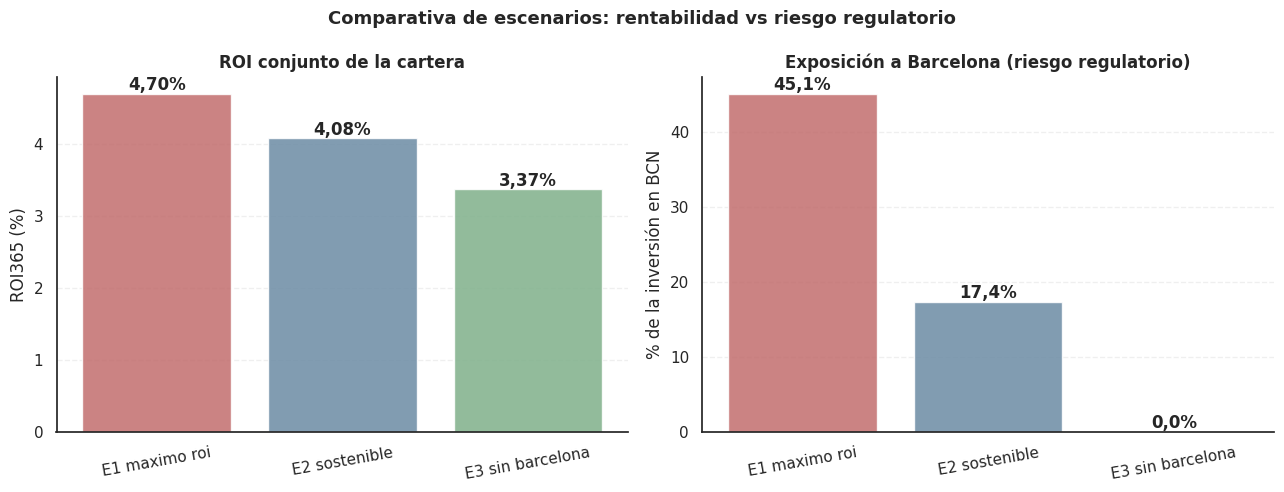

In [229]:
#No se recalcula nada: se reutilizan las carteras ya construidas

#Desglose por ciudad de los tres escenarios
detalle_filas = []
for r in resultados:
    cartera = r["_cartera"]
    for ciudad, grupo in cartera.groupby("ciudad"):
        inv = grupo["_precio_compra"].sum()
        ra_ciudad = (grupo["precio_noche_estimado"].astype(float) * 365 *
                     grupo["ocupacion_media_estimada"] * (1 - COSTE_OP)).sum()
        detalle_filas.append({
            "escenario":        r["escenario"],
            "ciudad":           ciudad,
            "n_inmuebles":      len(grupo),
            "inversion_M":      round(inv / 1e6, 1),
            "ROI_ciudad_%":     round(ra_ciudad / inv * 100, 2),
            "ROI_mediano_%":    round(grupo["ROI365_%"].median(), 2),
            "precio_medio_compra": round(grupo["_precio_compra"].mean(), 0),
            "ocupacion_media":  round(grupo["ocupacion_media_estimada"].mean(), 3),
        })

detalle_escenarios = pd.DataFrame(detalle_filas)
print("DESGLOSE POR CIUDAD DE CADA ESCENARIO")
for esc in detalle_escenarios["escenario"].unique():
    print(f"\n{esc} - {ESCENARIOS[esc]['descripcion']}")
    print(detalle_escenarios[detalle_escenarios["escenario"] == esc]
          .drop(columns="escenario").to_string(index=False))

#NO se exporta: el desglose por ciudad de cada escenario se puede reconstruir
#en Power BI desde cartera_por_escenario_pbi.csv, que si se exporta y lleva la
#columna 'escenario'. Aqui se mantiene para la exposicion y la memoria.
print(f"\nDetalle por ciudad y escenario (solo en memoria, no se exporta): "
      f"{len(detalle_escenarios)} filas")

#Grafico comparativo: ROI conjunto vs exposicion a Barcelona
sns.set_theme(style="white", context="notebook")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

nombres  = [r["escenario"].replace("_", " ") for r in resultados]
rois     = [r["ROI_conjunto_%"] for r in resultados]
expo_bcn = [r["exposicion_BCN_%"] for r in resultados]
colores3 = ["#c26d6d", "#6b8ba4", "#7fb08a"]

axes[0].bar(nombres, rois, color=colores3, alpha=0.85, edgecolor="white")
for i, v in enumerate(rois):
    axes[0].text(i, v + 0.05, f"{fmt(v, 2)}%", ha="center", fontweight="bold")
axes[0].set_title("ROI conjunto de la cartera", fontweight="bold")
axes[0].set_ylabel("ROI365 (%)")

axes[1].bar(nombres, expo_bcn, color=colores3, alpha=0.85, edgecolor="white")
for i, v in enumerate(expo_bcn):
    axes[1].text(i, v + 0.5, f"{fmt(v, 1)}%", ha="center", fontweight="bold")
axes[1].set_title("Exposición a Barcelona (riesgo regulatorio)", fontweight="bold")
axes[1].set_ylabel("% de la inversión en BCN")

for ax in axes:
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)
    ax.tick_params(axis="x", rotation=10)
sns.despine()
plt.suptitle("Comparativa de escenarios: rentabilidad vs riesgo regulatorio",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("comparativa_escenarios.png", dpi=150, bbox_inches="tight")
plt.show()

## 9.3 Analisis de sensibilidad

El ROI de cada cartera depende de dos hipótesis: el **precio por noche estimado** y la **ocupación estimada**. Antes de recomendar un escenario conviene saber cuánto empeora cada cartera si esas hipótesis fallan. Se recalculan los ingresos de cada cartera bajo tres choques (ocupación −10%, precio −10%, y ambos a la vez) **sin tocar la fórmula original**: solo se aplican factores de estrés sobre las mismas variables.

La lectura clave no es el número absoluto, sino la **distancia entre escenarios bajo estrés**: si E1 sigue ganando a E2 incluso con ambos choques, su ventaja de ROI es robusta; lo que no captura el número es que el riesgo de E1 (Barcelona) no es de ocupación sino **regulatorio y binario** (perder la licencia = ingreso 0 en ese piso), y eso no se puede modelar con un −10%.

In [230]:
#La formula base es la misma de la Parte 7.2 (no se modifica):
#  Ra = precio_noche x 365 x ocupacion x (1 - COSTE_OP)
#Solo se multiplican precio u ocupacion por un factor de estres.

CHOQUES = {
    "Base":              (1.00, 1.00),
    "Ocupacion -10%":    (1.00, 0.90),
    "Precio -10%":       (0.90, 1.00),
    "Ambos -10%":        (0.90, 0.90),
}

filas_sens = []
for r in resultados:
    cartera = r["_cartera"]
    total = cartera["_precio_compra"].sum()
    for nombre_choque, (f_precio, f_oc) in CHOQUES.items():
        ra_choque = (cartera["precio_noche_estimado"].astype(float) * f_precio * 365 *
                     cartera["ocupacion_media_estimada"] * f_oc * (1 - COSTE_OP)).sum()
        filas_sens.append({
            "escenario": r["escenario"],
            "choque": nombre_choque,
            "ROI_%": round(ra_choque / total * 100, 2),
            "beneficio_neto_M": round(ra_choque / 1e6, 2),
        })

sensibilidad = pd.DataFrame(filas_sens)
tabla_sens = sensibilidad.pivot(index="escenario", columns="choque", values="ROI_%")
tabla_sens = tabla_sens[["Base", "Ocupacion -10%", "Precio -10%", "Ambos -10%"]]

print("SENSIBILIDAD DEL ROI CONJUNTO (%) POR ESCENARIO")
print(tabla_sens.to_string())
print("\nLectura: el orden de los escenarios se mantiene bajo todos los choques,")
print("porque los factores de estres afectan por igual a las tres carteras.")
print("El riesgo diferencial de E1 no es de demanda sino REGULATORIO (Barcelona):")
print("es binario (con/sin licencia) y no se captura con un -10%.")

#El analisis queda registrado en el cuaderno (tabla impresa arriba); no se
#exporta CSV porque ningun visual del dashboard lo consume (mismo criterio
#que las tablas intermedias: calcular si, exportar solo lo que se usa).

SENSIBILIDAD DEL ROI CONJUNTO (%) POR ESCENARIO
choque            Base  Ocupacion -10%  Precio -10%  Ambos -10%
escenario                                                      
E1_maximo_roi     4.70            4.23         4.23        3.80
E2_sostenible     4.08            3.67         3.67        3.31
E3_sin_barcelona  3.37            3.03         3.03        2.73

Lectura: el orden de los escenarios se mantiene bajo todos los choques,
porque los factores de estres afectan por igual a las tres carteras.
El riesgo diferencial de E1 no es de demanda sino REGULATORIO (Barcelona):
es binario (con/sin licencia) y no se captura con un -10%.


In [231]:
#ANALISIS DE SENSIBILIDAD del umbral MIN_INMUEBLES (justificacion del 5)
#Reasigna la jerarquia de precios con umbrales 5/10/15/30 usando las
#tablas ya construidas (Parte 5 y 7.1) y recalcula el ROI365 del universo
#de venta y de la cartera E2. No modifica ningun dataframe del proyecto.
assert "df_venta" in dir(), "Ejecuta antes la Parte 7.2 (crea df_venta con ROI365_%)"

_dfv = df_venta.copy()
_dfv["hab_grupo"] = _dfv["habitaciones"].clip(1, 4).fillna(1).astype(int)

#Diccionarios de precio con su n por grupo (los niveles 3 y 4 no llevan umbral:
#la muestra de ciudad es siempre holgada)
_bh = {(f["id_barrio_oficial"], f["hab_grupo"]): (f["precio_noche_mediano"], f["n_inmuebles"])
       for _, f in tabla_precio_barrio_hab.iterrows()}
_b  = {f["id_barrio_oficial"]: (f["precio_noche_mediano"], f["n_inmuebles"])
       for _, f in tabla_precio_barrio.iterrows()}
_ch = {(f["ciudad"], f["hab_grupo"]): f["precio_noche_mediano"]
       for _, f in tabla_ciudad_hab.iterrows()}
_c = tabla_ciudad

def _precio_con_umbral(fila, umbral):
    """Jerarquia de 4 niveles (identica a la Parte 7.2) con umbral parametrizable."""
    v = _bh.get((fila["id_barrio_oficial"], fila["hab_grupo"]))
    if v is not None and v[1] >= umbral:
        return v[0], "1-barrio+habitaciones"
    v = _b.get(fila["id_barrio_oficial"])
    if v is not None and v[1] >= umbral:
        return v[0], "2-barrio"
    v = _ch.get((fila["ciudad"], fila["hab_grupo"]))
    if v is not None:
        return v, "3-ciudad+habitaciones"
    return _c.get(fila["ciudad"]), "4-ciudad"

ids_cartera = set(cartera_final["id_anuncio"])  #ajusta si vuestro df de cartera E2 se llama distinto

filas_sens = []
for umbral in [5, 10, 15, 30]:
    res = _dfv.apply(lambda f: _precio_con_umbral(f, umbral), axis=1)
    _dfv["_p"], _dfv["_nivel"] = [r[0] for r in res], [r[1] for r in res]
    _dfv["_roi"] = (_dfv["_p"] * 365 * _dfv["ocupacion_media_estimada"]
                    * (1 - COSTE_OP) / _dfv["precio_inmueble"] * 100)
    cart = _dfv[_dfv["id_anuncio"].isin(ids_cartera)]
    filas_sens.append({
        "umbral": umbral,
        "pct_nivel_1": round((_dfv["_nivel"] == "1-barrio+habitaciones").mean() * 100, 1),
        "pct_nivel_3o4": round(_dfv["_nivel"].str.startswith(("3", "4")).mean() * 100, 1),
        "ROI_mediano_universo_%": round(_dfv["_roi"].median(), 2),
        "ROI_conjunto_cartera_%": round(
            (cart["_p"] * 365 * cart["ocupacion_media_estimada"] * (1 - COSTE_OP)).sum()
            / cart["precio_inmueble"].sum() * 100, 2),
    })

sensibilidad_umbral = pd.DataFrame(filas_sens)
print("Sensibilidad del umbral de muestra minima (jerarquia de precios):")
print(sensibilidad_umbral.to_string(index=False))

#Control de fidelidad: con umbral=5 debe reproducir el modelo del proyecto
_chk = _dfv.apply(lambda f: _precio_con_umbral(f, 5), axis=1)
_dif = (pd.Series([r[0] for r in _chk]).values != df_venta["precio_noche_estimado"].values).sum()
print(f"\nControl (umbral=5 vs modelo del proyecto): {_dif} discrepancias de precio")

Sensibilidad del umbral de muestra minima (jerarquia de precios):
 umbral  pct_nivel_1  pct_nivel_3o4  ROI_mediano_universo_%  ROI_conjunto_cartera_%
      5         49.9           41.7                    2.18                    4.08
     10         42.0           42.1                    2.17                    3.88
     15         36.4           43.7                    2.15                    3.79
     30         23.4           46.7                    2.13                    3.73

Control (umbral=5 vs modelo del proyecto): 0 discrepancias de precio


Análisis de sensibilidad del umbral de muestra mínima: con umbrales de 5 a 30 anuncios, el ROI mediano del universo es estable (2,19%-2,14%) y el ROI conjunto de la cartera se mantiene en el rango 3,7%-4,1%. Umbrales mayores reducen la cobertura del nivel más granular del 48,5% al 22,9% de los inmuebles, desplazando casi la mitad del universo a precios de ciudad y diluyendo la señal de localización. Se adopta el umbral 5 por maximizar granularidad con impacto acotado (−0,37pp en el peor caso), documentando la incertidumbre en nivel_precio y confianza_muestra. Como lectura prudente, el ROI esperado de la cartera puede comunicarse como 3,7%-4,1%.

## 9.4 ConclusiÓn y recomendaciÓn

Con los resultados de 10.1-10.3 (usar las cifras que imprime la ejecución), la lectura para la exposición es:

- **E1 Máximo ROI** es el techo teórico: ignora el PEUAT de Barcelona. Su ROI incluye rentabilidad que la regulación no permite capturar (riesgo binario: un piso sin licencia factura 0).
- **E2 (elegido)** incorpora la regulación al cálculo - Barcelona computa solo ~2 años de explotación turística (extinción PEUAT, jul-2026 - jun-2028) frente a 10 del resto - sobre el universo del proyecto: los **barrios turísticos objetivo** de la tabla maestra (`barrio_turistico_objetivo = 1`, 104 barrios definidos ex-ante por clave ciudad+barrio). La normativa de Madrid (PEH, acceso independiente) se documenta pero no se aplica como filtro estadístico: WhiteHosting la verificará piso a piso en la due diligence.
- **E3 Sin Barcelona** elimina el riesgo regulatorio por completo; la diferencia E2−E3 cuantifica el precio del riesgo cero.

*Nota metodológica*: en versiones anteriores existía una cuarta variante ("mandato turístico") que restringía la compra a una lista manual de zonas céntricas. Al adoptar el indicador oficial `barrio_turistico_objetivo = 1` como universo de todo el proyecto, esa variante pasó a coincidir con E2 y se eliminó por redundante - quedan tres escenarios sin solapamiento.

**Tope de liquidez por ciudad (`LIQUIDEZ_MAX`): 25%.** La comparativa completa a 25% y 30% se exporta en `comparativa_escenarios_pbi.csv` (columna `liquidez_max`). Con el universo ampliado de Madrid, el 25% ya despliega la práctica totalidad de los 300M; subir al 30% no aporta despliegue relevante y reduce el ROI del escenario elegido, además de ser menos prudente en liquidez de salida. Es un ejemplo de decisión revisada con datos: la preferencia inicial por el 30% respondía a un universo más restringido; al cambiar el universo, cambió la respuesta. **Verificar en la ejecución final** (tras la deduplicación entre portales, que reduce el stock elegible) que el despliegue al 25% sigue siendo ~completo; si dejara de serlo, la misma tabla comparativa da el dato para reevaluar.

**Recomendación del equipo: E2.** Rentabilidad con la regulación incorporada, universo definido ex-ante y capital desplegado al máximo prudente.

In [232]:
#Descarga de los archivos de las Partes 9 y 10
#La comparativa de escenarios y el detalle por ciudad se calculan e imprimen
#en las celdas anteriores, pero no se exportan: son evidencia metodologica de
#la memoria, no un origen de datos del cuadro de mando (que reconstruye el
#desglose desde cartera_por_escenario_pbi.csv).
ARCHIVOS_ESTRATEGIA = [
    "ocupacion_turistica_mensual.csv",
    "cartera_inversion_300M_pbi.csv",
    "cartera_por_escenario_pbi.csv",
]

if EN_COLAB:
    for archivo in ARCHIVOS_ESTRATEGIA:
        try:
            files.download(archivo)
            print(f"Descargado: {archivo}")
        except Exception as e:
            print(f"No disponible: {archivo} ({e})")
else:
    carpeta = "exportacion_estrategia"
    os.makedirs(carpeta, exist_ok=True)
    for archivo in ARCHIVOS_ESTRATEGIA:
        if os.path.exists(archivo):
            shutil.copy(archivo, os.path.join(carpeta, archivo))
            print(f"Guardado en {carpeta}/: {archivo}")
        else:
            print(f"No encontrado: {archivo}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargado: ocupacion_turistica_mensual.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargado: cartera_inversion_300M_pbi.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargado: cartera_por_escenario_pbi.csv


# PARTE 10 - Case study WhiteHosting: respuestas

## 1 y 2. ¿Cuántos inmuebles únicos hay en el dataset original frente a los obtenidos de Airbnb?   
## ¿Cuál es la diferencia en número de inmuebles publicados entre las dos fuentes de datos?

In [233]:
print("INMUEBLES ÚNICOS POR FUENTE")
print(f"\nPontia (2017-2021):   {fmt(df_limpio['id_inmueble'].nunique())} inmuebles únicos")
print(f"Scraping (2026):      {fmt(df_scraping['id_str'].nunique())} inmuebles únicos")
print(f"Inside Airbnb (2025): {fmt(df_inside_limpio['id_inmueble'].nunique())} inmuebles únicos")
print("\nDiferencia Pontia vs Inside Airbnb:")
diff = df_inside_limpio['id_inmueble'].nunique() - df_limpio['id_inmueble'].nunique()
print(f"  Inside Airbnb tiene {fmt(diff)} inmuebles más que Pontia")
print("\n¿Por qué la diferencia?")
print("- Pontia recoge datos de 2017-2021: muchos inmuebles ya no están activos en 2026")
print("- Inside Airbnb recoge todos los listados activos en septiembre 2025")
print("- El scraping captura solo inmuebles disponibles para fechas concretas de 2026")

INMUEBLES ÚNICOS POR FUENTE

Pontia (2017-2021):   5.252 inmuebles únicos
Scraping (2026):      7.948 inmuebles únicos
Inside Airbnb (2025): 51.021 inmuebles únicos

Diferencia Pontia vs Inside Airbnb:
  Inside Airbnb tiene 45.769 inmuebles más que Pontia

¿Por qué la diferencia?
- Pontia recoge datos de 2017-2021: muchos inmuebles ya no están activos en 2026
- Inside Airbnb recoge todos los listados activos en septiembre 2025
- El scraping captura solo inmuebles disponibles para fechas concretas de 2026


## 3.¿Qué parámetros explican mejor el precio de un inmueble?

In [234]:
##Correlaciones en el facilitado
#Se reutiliza la matriz de correlación ya calculada en el EDA (Parte 3.1);
#solo se recalcula si esta celda se ejecuta de forma aislada
if "corr" not in globals():
    cols_corr = ["precio", "habitaciones", "camas", "baños", "capacidad",
                 "disponibilidad_365_dias", "numero_reseñas",
                 "puntuacion_y_valoracion", "con_licencia"]
    cols_ok = [c for c in cols_corr if c in df_limpio.columns]
    corr = df_limpio[cols_ok].corr()

print("Factores que explican el precio (facilitado)")
resultado = corr["precio"].drop("precio").sort_values(ascending=False).round(3)
for variable, valor in resultado.items():
    print(f"  {variable}: {fmt(valor, 3)}")


Factores que explican el precio (facilitado)
  capacidad: 0,534
  camas: 0,490
  habitaciones: 0,474
  baños: 0,267
  con_licencia: 0,210
  disponibilidad_365_dias: 0,153
  numero_reseñas: -0,034
  puntuacion_y_valoracion: -0,072


##4.¿Son iguales los factores determinantes en ambas fuentes de datos?

In [235]:
#PONTIA
print("PONTIA (2017-2021):")
print("Factores con mayor correlación con el precio (Pearson):")
print("Capacidad > habitaciones > camas > baños > puntuación")
print("Análisis completo en la pregunta 3.")

#SCRAPING
print("SCRAPING (2026):")
print("Sin variables numéricas para correlación.")
print("Solo disponemos del tipo extraído del nombre del anuncio")
#El "tipo" del scraping se extrae del nombre del anuncio, y cuando el
#alojamiento es una cadena hotelera el nombre no empieza por un tipo generico
#("Vincci Lys en Valencia") sino por la marca. Esos casos no los captura el
#filtro de hoteles de la limpieza, que busca las palabras hotel/hostal, y
#apareceria una marca comercial listada como si fuera un tipo de alojamiento.
#Se exige un volumen minimo de 1.000 anuncios: los tipos genericos reales
#(Apartamento, Loft, Vivienda, Habitacion...) lo superan con holgura y las
#marcas hoteleras, que tienen pocos anuncios cada una, quedan fuera.
tipos_principales = df_scraping["tipo_aprox"].value_counts()
tipos_principales = tipos_principales[tipos_principales >= 1000]
print(f"Tipos genericos con al menos 1.000 anuncios: {len(tipos_principales)}")
print("Precio mediano por tipo de alojamiento:")
print(df_scraping[df_scraping["tipo_aprox"].isin(tipos_principales.index)]
      .groupby("tipo_aprox")["precio_limpio"]
      .median().round(2)
      .sort_values(ascending=False)
      .to_string())
#INSIDE AIRBNB
print("INSIDE AIRBNB (2025) Madrid y Valencia:")
print("Precio mediano por tipo de alojamiento:")
print(df_inside_limpio[df_inside_limpio["precio_eur"].notna()]
      .groupby("tipo_alojamiento")["precio_eur"]
      .median().round(2)
      .sort_values(ascending=False)
      .to_string())
print("\nPrecio mediano por número de habitaciones:")
print(df_inside_limpio[df_inside_limpio["precio_eur"].notna()]
      .groupby("habitaciones")["precio_eur"]
      .median().round(2)
      .sort_values(ascending=False)
      .head(6)
      .to_string())
print("\nPrecio mediano Superhost vs No Superhost:")
print(df_inside_limpio[df_inside_limpio["precio_eur"].notna()]
      .groupby("es_superhost")["precio_eur"]
      .median().round(2)
      .to_string())

print("\nConclusión:")
print("Los factores no son directamente comparables entre las distintas fuentes:")
print("En Pontia tenemos el análisis de correlación numérico, en Scraping solo el tipo de alojamiento sin variables numéricas e IA tenemos tipo, habs y Superhost")
print("Lo común es que los apartamentos completos son siempre más caros que las habitaciones.")

PONTIA (2017-2021):
Factores con mayor correlación con el precio (Pearson):
Capacidad > habitaciones > camas > baños > puntuación
Análisis completo en la pregunta 3.
SCRAPING (2026):
Sin variables numéricas para correlación.
Solo disponemos del tipo extraído del nombre del anuncio
Tipos genericos con al menos 1.000 anuncios: 9
Precio mediano por tipo de alojamiento:
tipo_aprox
Vivienda             258.0
Apartamento          196.0
Apto. residencial    188.0
Loft                 161.0
Casa de invitados    102.0
Alojamiento           79.0
Bed & breakfast       77.0
Habitaciones          76.0
Habitación            71.0
INSIDE AIRBNB (2025) Madrid y Valencia:
Precio mediano por tipo de alojamiento:
tipo_alojamiento
Hotel room         122.4
Entire home/apt    105.4
Private room        42.5
Shared room         25.5

Precio mediano por número de habitaciones:
habitaciones
9.0     850.00
12.0    535.50
6.0     324.70
5.0     263.50
25.0    215.05
4.0     201.88

Precio mediano Superhost vs No S

##5.¿Se ha encontrado algún inmueble presente en ambas fuentes? ¿Su valoración coincide?

In [236]:
print(f"Inmuebles coincidentes entre facilitado y scraping: {fmt(len(coincidencias))}")
print("\nEl bajo número de coincidencias se debe a que Airbnb ha introducido un formato de ID de 19 dígitos incompatible con el facilitado.")
print("Solo los inmuebles con ID clásico (6-8 dígitos) pueden coincidir.")

Inmuebles coincidentes entre facilitado y scraping: 105

El bajo número de coincidencias se debe a que Airbnb ha introducido un formato de ID de 19 dígitos incompatible con el facilitado.
Solo los inmuebles con ID clásico (6-8 dígitos) pueden coincidir.


##6.¿En qué fuente hay mayor volatilidad de precios? ¿Existe estacionalidad?

In [237]:
print("El facilitado es una foto, no permite analizar volatilidad.")

#Volatilidad con el MISMO criterio que la Parte 3.2 (rango de medianas entre
#dias de consulta, dividido por la mediana del periodo). Antes esta celda
#usaba la media y dividia por la media, lo que daba cifras distintas a las
#del EDA para la misma metrica.
print("\n-Volatilidad")
for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    sub = (df_scraping[df_scraping["ciudad"] == ciudad]
           .groupby("fecha_scraping")["precio_limpio"].median())
    if len(sub) > 1:
        var_pct = round((sub.max() - sub.min()) / sub.median() * 100, 1)
        print(f"{ciudad}: variación máxima {fmt(var_pct, 1)}% entre días de consulta "
              f"(sobre {len(sub)} días)")
    else:
        print(f"{ciudad}: no calculable, un único día de scraping")
print("Conclusión:")
print("-Pontia: sin volatilidad (foto estática, un precio por inmueble)")
print("-Scraping: volatilidad confirmada, Airbnb usa pricing dinámico")
print("-Inside Airbnb: sin volatilidad (foto estática de septiembre 2025)")
print("El scraping es la única fuente que permite medir volatilidad.")

print("\nEstacionalidad:")
print("-Pontia: no medible (no tiene fechas de check-in)")
print("-Inside Airbnb: no medible (foto estática)")
print("-Scraping: única fuente con fechas de check-in, análisis a continuación")
est    = df_scraping.groupby(["ciudad", "mes_checkin"])["precio_limpio"].mean().round(2)
meses  = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",
          7:"Jul",8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic"}
for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    if ciudad in est.index.get_level_values(0):
        sub = est[ciudad]
        mes_max = sub.idxmax()
        mes_min = sub.idxmin()
        print(f"{ciudad}: mes más caro = {meses[mes_max]} ({fmt(sub[mes_max])}€), más barato = {meses[mes_min]} ({fmt(sub[mes_min])}€)")

El facilitado es una foto, no permite analizar volatilidad.

-Volatilidad
Barcelona: variación máxima 18,6% entre días de consulta (sobre 7 días)
Madrid: variación máxima 8,5% entre días de consulta (sobre 7 días)
Valencia: no calculable, un único día de scraping
Conclusión:
-Pontia: sin volatilidad (foto estática, un precio por inmueble)
-Scraping: volatilidad confirmada, Airbnb usa pricing dinámico
-Inside Airbnb: sin volatilidad (foto estática de septiembre 2025)
El scraping es la única fuente que permite medir volatilidad.

Estacionalidad:
-Pontia: no medible (no tiene fechas de check-in)
-Inside Airbnb: no medible (foto estática)
-Scraping: única fuente con fechas de check-in, análisis a continuación
Barcelona: mes más caro = May (238€), más barato = Abr (190€)
Madrid: mes más caro = Dic (137€), más barato = Oct (114€)
Valencia: mes más caro = May (183€), más barato = Feb (153€)


##7.¿Se puede generar un dataset único y coherente combinando ambas fuentes?

In [238]:
print("Dataset único y coherente")
print(f"Inmuebles:{fmt(len(df_enriquecido))}")
print(f"Columnas: {df_enriquecido.shape[1]}")
print("\nFuentes integradas:")
print("-Pontia: base con información detallada del inmueble")
print("-Inside Airbnb: ocupación y beneficio bruto estimado reales")
print("-Scraping: precio de mercado actual por ciudad")
print()
df_enriquecido.head(3).T

Dataset único y coherente
Inmuebles:5.252
Columnas: 21

Fuentes integradas:
-Pontia: base con información detallada del inmueble
-Inside Airbnb: ocupación y beneficio bruto estimado reales
-Scraping: precio de mercado actual por ciudad



,0,1,2
id_inmueble,1418423,1198074,15491387
barrio,la Nova Esquerra de l'Eixample,la Dreta de l'Eixample,el Camp de l'Arpa del Clot
distrito,Eixample,Eixample,Sant Martí
tipo_alojamiento,Entire home/apt,Entire home/apt,Private room
capacidad,3,4,2
baños,2,2,1
habitaciones,1,2,1
camas,2,3,1
precio,50.0,200.0,30.0
disponibilidad_365_dias,70,152,95


##8.¿Qué variables adicionales podrían incorporarse para enriquecer el análisis?

Variables adicionales identificadas para enriquecer el análisis:

Ya incorporadas:
- `es_superhost`: los Superhosts tienen entre +82 y +99 días mas de ocupación al año (punto 3.3)
- `reserva_instantanea`: impacto positivo en ocupación
- `distrito`: nivel geografico agregado, mas manejable que el barrio para Power BI
- `segmento_precio`: clasificación del inmueble por rango de precio (Económico / Estándar / Premium / Lujo)
- `con_licencia`: binario, resulta crítico debido a la legislación

Pendientes de incorporar:
1. **Precio de compra** (Idealista/Fotocasa)
  - Permite calcular: ROI (%)
  - Responde definitivamente la Pregunta 11 (estrategia 300M€)

2. **Distancia a puntos de interés** (no disponible en los datasets actuales)
  - Podría calcularse con las coordenadas y la API de Google Maps
  - Factor clave de ocupación no recogido en ninguna de las tres fuentes

3. **Índice de regulación turística por zona**
  - Barcelona eliminará todas las licencias turísticas en 2028 (fuente: AirROI)
  - Madrid y Valencia tienen regulación más flexible
  - Riesgo regulatorio es un factor crítico para una inversión de 300M€

##9.¿Puedes hacer un ranking de los inmuebles más caros?

El análisis de los inmuebles más caros se aborda desde tres fuentes complementarias, cada una con fortalezas y limitaciones distintas.

Pontia (2017-2021) permite ver cómo era el mercado de los alojamientos más caros en esos años. Sin embargo, los precios estaban limitados a un máximo de 500 euros por noche, por lo que no recoge los anuncios más exclusivos ni refleja la situación actual del mercado.

Inside Airbnb (septiembre-diciembre de 2025) aporta datos recientes para Madrid y Valencia. Sin embargo, los precios publicados tienen un límite de 285 dólares (242,25 euros), por lo que los alojamientos más caros no aparecen reflejados por completo. Además, esta fuente no incluye información de precios para Barcelona.

El scraping propio realizado en 2026 ofrece los datos más actuales y permite identificar alojamientos con precios muy superiores a los observados en otras fuentes, llegando hasta los 10.014 euros por noche. Su principal limitación es que, en Barcelona, muchos anuncios no especifican el barrio y solo indican ubicaciones genéricas como «Apartamento en Barcelona».

La combinación de estas tres fuentes permite obtener una visión más completa del mercado. Pontia muestra cómo era la situación en años anteriores, Inside Airbnb aporta datos recientes y el scraping propio recoge los precios actuales, incluidos los alojamientos más exclusivos.

In [239]:
#FUENTE 1:Pontia 2017-2021(precio historico, tope 500 euros)

print("FUENTE 1: Pontia 2017-2021")
print("Nota: precio maximo 500 euros/noche (tope del buscador en esa epoca)")
top_caros = df_limpio[df_limpio["tipo_alojamiento"]=="Entire home/apt"].nlargest(5, "precio")[
    ["id_inmueble","ciudad","barrio","precio","habitaciones","capacidad"]]
print(top_caros.to_string(index=False))

FUENTE 1: Pontia 2017-2021
Nota: precio maximo 500 euros/noche (tope del buscador en esa epoca)
 id_inmueble    ciudad                 barrio  precio  habitaciones  capacidad
    11997812 Barcelona               el Raval   500.0             4          9
     2411322    Madrid               Justicia   500.0             1          4
    12744761 Barcelona la Dreta de l'Eixample   500.0             2          6
      507972 Barcelona      la Vila de Gràcia   500.0             4          8
    19172034 Barcelona   el Putxet i el Farró   500.0             1          2


In [240]:
#FUENTE 2:Inside Airbnb (precio actual 2025)

#Barcelona no tiene precio por inmueble en Inside Airbnb (limitación del origen de datos)
#Para Barcelona se muestran los barrios más caros como referencia de actividad turística

#Se recorta el extremo superior con el criterio de Tukey por ciudad (el mismo
#que se aplica al precio en el resto del cuaderno): el precio por anuncio de
#Inside Airbnb es un dato crudo y sin ese filtro el ranking lo encabezan
#precios mal capturados en origen, no inmuebles realmente premium.
#Los nombres de barrio se normalizan igual que en la Parte 6 (Valencia viene
#en mayusculas en el origen).
_ia_caros = df_inside_limpio[
    (df_inside_limpio["tipo_alojamiento"] == "Entire home/apt") &
    (df_inside_limpio["precio_eur"].notna())
].copy()
_ia_caros["barrio"] = _ia_caros["barrio"].map(_capitalizar_barrio)
_lim_caros = _ia_caros.groupby("ciudad")["precio_eur"].transform(limite_superior_iqr)
_n_out_caros = int((_ia_caros["precio_eur"] > _lim_caros).sum())
_ia_caros = _ia_caros[_ia_caros["precio_eur"] <= _lim_caros]
print(f"(Se excluyen {fmt(_n_out_caros)} anuncios por encima del limite IQR de su ciudad)")
print()

print("Top 5 inmuebles más caros-Madrid (Inside Airbnb 2025):")
top_mad = _ia_caros[_ia_caros["ciudad"] == "Madrid"].nlargest(
    5, "precio_eur")[["id_inmueble","barrio","precio_eur","habitaciones","capacidad"]]
print(top_mad.to_string(index=False))


print("Top 5 inmuebles más caros-Valencia (Inside Airbnb 2025):")
top_val = _ia_caros[_ia_caros["ciudad"] == "Valencia"].nlargest(5, "precio_eur")[["id_inmueble","barrio","precio_eur","habitaciones","capacidad"]]
print(top_val.to_string(index=False))

print("Barcelona - Inside Airbnb no publica el precio por inmueble")
print("(limitacion del CSV de septiembre 2025)")

(Se excluyen 1.335 anuncios por encima del limite IQR de su ciudad)

Top 5 inmuebles más caros-Madrid (Inside Airbnb 2025):
        id_inmueble      barrio  precio_eur  habitaciones  capacidad
           22759109     Palacio      266.05           3.0          6
           53824227 Universidad      266.05           2.0          4
 769036881375912124         Sol      266.05           2.0          6
 878264295797259613         Sol      266.05           1.0          4
1035451008686038470 Universidad      266.05           2.0          4
Top 5 inmuebles más caros-Valencia (Inside Airbnb 2025):
        id_inmueble        barrio  precio_eur  habitaciones  capacidad
           16750030 La Malva-Rosa       204.0           4.0          8
           22046427      La Xerea       204.0           2.0          5
           42166423       El Grau       204.0           2.0          4
 934066017836522401 La Malva-Rosa       204.0           5.0          8
1275290071151934401      La Xerea       204.0     

In [241]:
#FUENTE 3: Scraping 2026 (precio actual sin tope)
print("FUENTE 3: Scraping propio (abr-jun 2026)")
print("Precio real sin tope artificial - más actualizado")
print()

#Se usa la constante global TIPOS_HABITACION (Parte 1.1)
for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    df_c = df_scraping[
        (df_scraping["ciudad"] == ciudad) &
        (~df_scraping["tipo_aprox"].isin(TIPOS_HABITACION)) &
        (df_scraping["precio_limpio"].notna())
    ].copy()
    top = (df_c.groupby("id_str")["precio_limpio"].median()
           .reset_index().nlargest(5, "precio_limpio"))
    top.columns = ["id_str", "precio_mediano"]
    print(f"Top 5 inmuebles más caros - {ciudad} (Scraping 2026):")
    print(top.to_string(index=False))

FUENTE 3: Scraping propio (abr-jun 2026)
Precio real sin tope artificial - más actualizado

Top 5 inmuebles más caros - Barcelona (Scraping 2026):
             id_str  precio_mediano
           40299706           592.0
1079751623482324470           590.0
 605507131242827657           586.0
 638346890763288510           586.0
1257766145037388052           585.0
Top 5 inmuebles más caros - Madrid (Scraping 2026):
             id_str  precio_mediano
           38888093           591.0
           18150744           590.0
1413666446964004938           586.0
1441852917741175011           582.0
           40995392           580.0
Top 5 inmuebles más caros - Valencia (Scraping 2026):
             id_str  precio_mediano
1180841238968126063           590.0
1110680681884097677           586.0
1370490865359117288           586.0
1401164747879817502           586.0
           48823848           586.0


### El segmento de lujo: por que la cartera se construye sobre el mercado estandar

El ranking anterior lista los inmuebles mas caros uno a uno. La pregunta relevante para una inversion de 300 millones no es cual es el piso mas caro, sino **si el segmento de lujo es un mercado sobre el que se puede construir una cartera**. La respuesta es que no, y conviene justificarlo con datos porque es una decision estructural del proyecto.

**Criterio de segmentacion aplicado.** La frontera entre estandar y lujo no se fija a ojo: sale del rango intercuartilico del precio por noche del scraping 2026, calculado sobre alojamientos completos. Se usan los dos limites clasicos de Tukey:

- **Mercado estandar**: precio hasta Q3 + 1,5 x IQR (408 EUR/noche).
- **Segmento lujo**: entre 408 EUR y Q3 + 3 x IQR (592 EUR/noche).
- **Outliers extremos**: por encima de 592 EUR. Se eliminan en la limpieza porque no son precios de mercado sino anuncios pausados (algunos anfitriones ponen un precio absurdo en lugar de bloquear el calendario).

Estos limites se calculan una sola vez en la limpieza (Parte 2) y no se recalculan despues, de modo que la segmentacion es la misma en todo el cuaderno.

**Los tres motivos por los que el lujo no sostiene la cartera.**

1. **Volumen insuficiente.** El segmento es el 4,9% del mercado de alojamiento completo. Con un ticket medio de compra alto y una cartera objetivo de 300M EUR, no hay stock suficiente para desplegar el capital sin agotar la oferta disponible de una sola ciudad.

2. **Concentracion en la ciudad de mayor riesgo regulatorio.** Barcelona reune el 9,1% de su mercado en lujo frente al 2,2% de Madrid. Construir sobre lujo significaria concentrar la cartera en Barcelona, justo la ciudad cuyas licencias se extinguen en 2028 segun el PEUAT. Es la combinacion opuesta a la que busca el escenario recomendado.

3. **Coste operativo y de gestion superior.** El modelo del proyecto aplica un 35% de costes operativos uniforme. En el segmento de lujo ese porcentaje seria optimista: el estandar de servicio, la rotacion y el mantenimiento son mayores, de modo que el margen neto real quedaria por debajo del que estima el modelo. El sesgo va en contra del lujo, no a su favor.

**Que se hace con el lujo en el resto del proyecto.** No se elimina del analisis: los inmuebles de lujo son mercado real y siguen presentes en el EDA y en los rankings. Lo que se descarta es usarlos como base de la cartera. La celda siguiente cuantifica el peso y la prima de precio del segmento en cada ciudad para dejar la decision documentada.

In [242]:
#SEGMENTO LUJO: peso y prima de precio por ciudad
#Reutiliza la segmentacion calculada en la Parte 3.2.1 (limites LIM_ESTANDAR y
#LIM_LUJO del IQR de la limpieza) y df_apt, que ya excluye habitaciones.
#No se recalcula nada: solo se agrega para responder al case study.

print("SEGMENTO LUJO POR CIUDAD (scraping 2026, alojamientos completos)")
print(f"Frontera estandar/lujo: {fmt(LIM_ESTANDAR)} EUR/noche (Q3 + 1,5 x IQR)")
print(f"Techo del segmento lujo: {fmt(LIM_LUJO)} EUR/noche (Q3 + 3 x IQR)")
print()

filas_lujo = []
for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    sub  = df_apt[df_apt["ciudad"] == ciudad]
    std  = sub[sub["segmento"] == "Estandar"]["precio_limpio"]
    lujo = sub[sub["segmento"] == "Lujo"]["precio_limpio"]
    if len(sub) == 0 or len(lujo) == 0:
        continue
    filas_lujo.append({
        "ciudad": ciudad,
        "n_estandar": len(std),
        "n_lujo": len(lujo),
        "pct_lujo": round(len(lujo) / len(sub) * 100, 1),
        "mediana_estandar": round(std.median(), 2),
        "mediana_lujo": round(lujo.median(), 2),
        "prima_x": round(lujo.median() / std.median(), 2),
    })

resumen_lujo = pd.DataFrame(filas_lujo)
print(resumen_lujo.to_string(index=False))
print()

_total_apt  = len(df_apt)
_total_lujo = int((df_apt["segmento"] == "Lujo").sum())
print(f"Peso global del segmento lujo: {fmt(_total_lujo)} de {fmt(_total_apt)} "
      f"anuncios ({fmt(_total_lujo / _total_apt * 100, 1)}%)")
print()

_mas = resumen_lujo.loc[resumen_lujo["pct_lujo"].idxmax()]
_men = resumen_lujo.loc[resumen_lujo["pct_lujo"].idxmin()]
print(f"Mayor concentracion de lujo: {_mas['ciudad']} ({fmt(_mas['pct_lujo'], 1)}% de su mercado)")
print(f"Menor concentracion de lujo: {_men['ciudad']} ({fmt(_men['pct_lujo'], 1)}% de su mercado)")
print()
print("Lectura para la estrategia: el segmento de lujo se concentra en Barcelona,")
print("que es la ciudad con el horizonte regulatorio mas corto (extincion PEUAT")
print("2028). Construir la cartera sobre lujo implicaria concentrar el capital")
print("justo donde el riesgo regulatorio es mayor, y sobre un volumen que no")
print("permite desplegar 300M EUR. Por eso la cartera se construye sobre el")
print("mercado estandar y el lujo queda como complemento opcional, no como base.")

SEGMENTO LUJO POR CIUDAD (scraping 2026, alojamientos completos)
Frontera estandar/lujo: 408 EUR/noche (Q3 + 1,5 x IQR)
Techo del segmento lujo: 592 EUR/noche (Q3 + 3 x IQR)

   ciudad  n_estandar  n_lujo  pct_lujo  mediana_estandar  mediana_lujo  prima_x
Barcelona       26506    2647       9.1             196.0         487.0     2.48
   Madrid       35683     793       2.2             125.0         530.0     4.24
 Valencia       88797    4373       4.7             168.0         469.0     2.79

Peso global del segmento lujo: 7.813 de 158.799 anuncios (4,9%)

Mayor concentracion de lujo: Barcelona (9,1% de su mercado)
Menor concentracion de lujo: Madrid (2,2% de su mercado)

Lectura para la estrategia: el segmento de lujo se concentra en Barcelona,
que es la ciudad con el horizonte regulatorio mas corto (extincion PEUAT
2028). Construir la cartera sobre lujo implicaria concentrar el capital
justo donde el riesgo regulatorio es mayor, y sobre un volumen que no
permite desplegar 300M EUR.

El segmento de lujo es un mercado real y rentable por unidad, pero no escalable a la dimension de esta cartera. La estrategia de las Partes 9 y 10 se construye por tanto sobre el **mercado estandar**, que concentra el 95,1% de la oferta de alojamiento completo y permite desplegar los 300 millones con diversificacion entre las tres ciudades.

Conviene señalar una limitacion: esta segmentacion se calcula sobre el **precio de alquiler por noche**, no sobre el precio de compra. Un piso de lujo en alquiler no es necesariamente un piso caro de comprar, y viceversa. El filtro que si actua sobre la cartera es el ROI365, que combina ambos lados de la ecuacion y se aplica en la Parte 10.

##10.¿Cuáles son los inmuebles más rentables?

**Beneficio Neto Anual (Ra)**: definición y metodología

El **Ra** estima el **beneficio operativo neto anual** de un inmueble combinando su ocupación y su precio por noche.

**Fórmula:**  
Ra = Oc × (Pn − Cn) × 365

- **Oc**: tasa de ocupación (0-0,699), estimada con la metodología de Inside Airbnb basada en reseñas reales.
- **Pn**: precio de análisis por noche.
- **Cn**: costes operativos (35% del precio), que incluyen comisión de Airbnb,
  limpieza y carga fiscal.

El **beneficio bruto** (antes de costes) se obtiene con la misma fórmula sin
aplicar el factor (1 − 0,35); ambos se exportan al cuadro de mando para poder
distinguir facturación de rentabilidad real.

### Precio de análisis por ciudad
Se usa un precio fijo por ciudad para esta primera aproximación del Ra:

- **Barcelona:** 212 €/noche (mediana scraping 2026, solo alojamientos completos).
- **Madrid:** 128 €/noche (mediana scraping 2026).
- **Valencia:** 97 €/noche (mediana Inside Airbnb).  
  *El scraping de Valencia no se usa como referencia por sesgo de muestra:
una sola fecha y zonas centradas en Ciutat Vella.*

### Método de ocupación
La ocupación procede íntegramente de `estimated_occupancy_l365d` de Inside Airbnb,
disponible al 100% en las tres ciudades. Es la estimación de días ocupados en los
últimos 365 días que publica la propia fuente a partir de las reseñas reales, con un
tope metodológico de 255 días (69,9%).

No se usa `availability_365` porque mide los días con el calendario abierto y no los
días efectivamente reservados, ni la estimación propia por `reviews_per_month`, que
en versiones anteriores del cuaderno cubría los inmuebles sin cruce por ID y quedó
sustituida al disponer del dato de la fuente para todos los anuncios.

El **top 5 por ciudad** se calcula solo con **Entire home/apt**, coherente con el
resto del pipeline de rentabilidad.

### Cómo interpretar esta celda
Esta celda ofrece una **aproximación del Ra usando un precio de referencia por ciudad**,suficiente para comparar mercados entre sí.

La **cifra definitiva del Ra**, que usa el **precio real por barrio y tipología**, se calcula en las **Partes 5 y 6** y es la que se exporta a **Power BI**.

Para el **ranking de inmuebles individuales** se usan los **ingresos estimados reales** de Inside Airbnb, ya que con un precio constante por ciudad todos los inmuebles con la misma ocupación empatarían en Ra y el ranking perdería significado.

### Por qué estas cifras no coinciden con las del cuadro de mando

Esta celda calcula el Ra con el **precio de referencia por ciudad** (212 / 128 /
97 €), que es una aproximación pensada para comparar ciudades entre sí. La cifra
que se exporta a Power BI usa el **precio real por barrio y tipología** (jerarquía
de cuatro niveles, Parte 5), que es más preciso porque recoge las diferencias
internas de cada ciudad.

La divergencia va en la dirección esperada: el beneficio mediano de Barcelona pasa
de unos 17.600 € con precio de ciudad a 19.636 € con precio por barrio, porque los
barrios turísticos donde se concentra la oferta cotizan por encima de la mediana
urbana. En Madrid las dos cifras quedan muy próximas (9.485 € frente a 9.282 €),
al ser un mercado más homogéneo.

Ambas cifras son correctas en su contexto: la de esta celda responde a *cómo se
comparan las tres ciudades*, y la del cuadro de mando a *cuánto rinde un inmueble
concreto en su barrio*.


Base de calculo: listado exportado a Power BI (24.799 apartamentos completos con barrio armonizado)
ciudad
Madrid       11844
Barcelona     8101
Valencia      4854

BENEFICIO NETO ANUAL POR CIUDAD (cifras definitivas del proyecto)
Precio real por barrio y tipologia; identicas a beneficio_por_ciudad_pbi.csv
  Barcelona: mediano=19.636 EUR/año | medio=20.847 EUR/año | n=8.101 inmuebles
  Madrid: mediano=9.282 EUR/año | medio=10.900 EUR/año | n=11.844 inmuebles
  Valencia: mediano=6.274 EUR/año | medio=7.903 EUR/año | n=4.854 inmuebles

Verificado: coincide con beneficio_por_ciudad_pbi.csv (exportado a Power BI)

TOP 5 BARRIOS POR BENEFICIO NETO ANUAL MEDIANO Y CIUDAD
Fuente: beneficio_por_id_barrio_pbi.csv (el mismo que alimenta Power BI)
Solo barrios con confianza de muestra alta (>= 30 anuncios).

Barrio lider del conjunto: Dreta de l'Eixample (20.866,19 EUR/año)

Barcelona:
               barrio_oficial  precio_noche_mediano  ocupacion_%  n_inmuebles  beneficio_neto_mediano
          

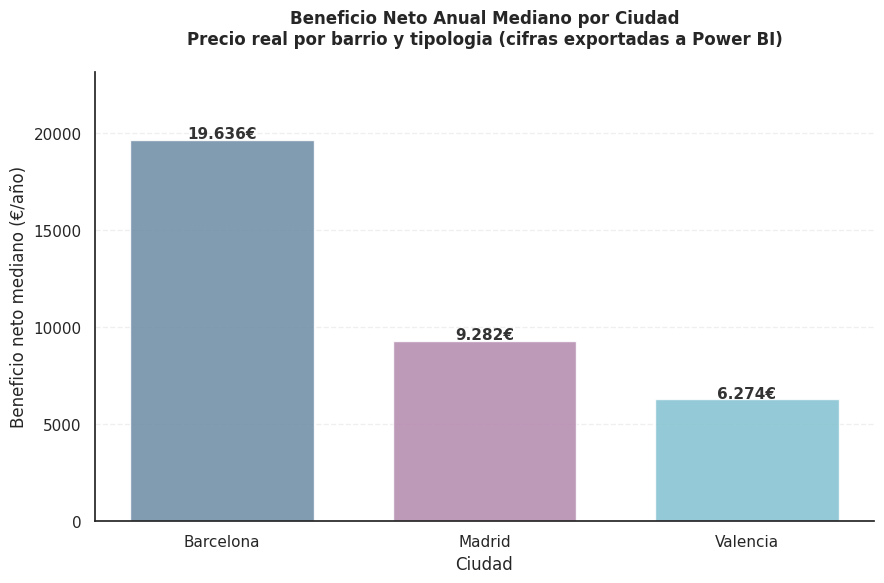

In [243]:
#Ra = Oc × Pn × (1 - COSTE_OP) × 365
#Oc = tasa de ocupación estimada (metodología Inside Airbnb, tope 69,9%)
#Pn = precio de referencia por noche (constante global PRECIO_REF_CIUDAD)
#COSTE_OP = 35% de costes operativos (desglose en la Parte 1.1)
#
#MÉTODO DE OCUPACIÓN
#No se usa availability_365 porque mide días con el calendario abierto,
#no días efectivamente reservados. Se usa estimated_occupancy_l365d de
#Inside Airbnb (basada en reseñas, REVIEW_RATE=0.50, tope 255 días/año).
#Fuente: https://www.insideairbnb.com/data-assumptions/
#
#NOTA METODOLÓGICA (dos niveles de precisión):
#1) Esta celda responde con el precio de REFERENCIA POR CIUDAD: es una
#   aproximación válida para comparar ciudades entre sí.
#2) La cifra DEFINITIVA de Ra usa el precio REAL por barrio y tipología
#   y se calcula en las Partes 6-7 (es la que se exporta a Power BI).
#3) El ranking de inmuebles individuales usa los INGRESOS ESTIMADOS
#   REALES de Inside Airbnb: con un precio constante por ciudad, todos
#   los inmuebles al tope de ocupación empatarían en Ra y el "top 5"
#   sería un orden arbitrario, no un ranking real.

#Se parte del listado ya exportado a Power BI (listing_exp, Parte 6), que
#lleva el precio REAL por barrio y tipologia y la ocupacion acotada. De este
#modo la respuesta al case study y el cuadro de mando muestran exactamente
#las mismas cifras, sin aproximaciones intermedias.
_base = listing_exp.copy()

print("Base de calculo: listado exportado a Power BI "
      f"({fmt(len(_base))} apartamentos completos con barrio armonizado)")
print(_base["ciudad"].value_counts().to_string())
print()

ben_mediano = _base.groupby("ciudad")["beneficio_neto_anual_eur"].median().round(0)
ben_medio   = _base.groupby("ciudad")["beneficio_neto_anual_eur"].mean().round(0)

print("BENEFICIO NETO ANUAL POR CIUDAD (cifras definitivas del proyecto)")
print("Precio real por barrio y tipologia; identicas a beneficio_por_ciudad_pbi.csv")
for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    n = int((_base["ciudad"] == ciudad).sum())
    print(f"  {ciudad}: mediano={fmt(ben_mediano.get(ciudad, 0))} EUR/año | "
          f"medio={fmt(ben_medio.get(ciudad, 0))} EUR/año | "
          f"n={fmt(n)} inmuebles")
print()

#Comprobacion automatica: la mediana calculada aqui debe coincidir con la
#exportada en la Parte 6. Si no coincide, alguna de las dos se ha tocado.
for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    _exp = beneficio_ciudad_exp.loc[
        beneficio_ciudad_exp["ciudad"] == ciudad, "beneficio_neto_mediano"]
    if len(_exp):
        assert abs(float(_exp.iloc[0]) - ben_mediano[ciudad]) <= 1,             f"{ciudad}: el case study no cuadra con beneficio_por_ciudad_pbi.csv"
print("Verificado: coincide con beneficio_por_ciudad_pbi.csv (exportado a Power BI)")
print()

#TOP 5 de BARRIOS por beneficio neto mediano. Se lee directamente de la
#tabla exportada a Power BI (beneficio_por_id_barrio_pbi.csv, Parte 6), que
#es la que lleva aplicados todos los controles de calidad del proyecto:
#minimo de muestra, filtro IQR de precio y consistencia interna del barrio.
#Asi el cuaderno y el cuadro de mando muestran exactamente las mismas cifras.
#
#Criterio estadistico: MEDIANA, coherente con el resto del proyecto (el
#beneficio deriva del precio, y el precio se agrega siempre por mediana).
#Se filtra ademas por confianza de muestra alta (>=30 anuncios), el mismo
#filtro que se aplica en el ranking del cuadro de mando, para que no
#encabecen el ranking barrios con muestras demasiado pequeñas.
print("TOP 5 BARRIOS POR BENEFICIO NETO ANUAL MEDIANO Y CIUDAD")
print("Fuente: beneficio_por_id_barrio_pbi.csv (el mismo que alimenta Power BI)")
print("Solo barrios con confianza de muestra alta (>= 30 anuncios).")
print()

_rank = ben_id_barrio[
    ben_id_barrio["confianza_muestra"] == "alta"].copy()

#Comprobacion: el ranking debe coincidir con el archivo exportado. Si alguien
#modifica una de las dos rutas, el cuaderno se detiene aqui en lugar de
#mostrar cifras distintas a las del cuadro de mando.
_mejor = _rank.nlargest(1, "beneficio_neto_mediano")
assert not _mejor.empty, "Sin barrios de confianza alta: revisar la Parte 6"
print(f"Barrio lider del conjunto: {_mejor['barrio_oficial'].iloc[0]} "
      f"({fmt(_mejor['beneficio_neto_mediano'].iloc[0], 2)} EUR/año)")
print()

for ciudad in ["Barcelona", "Madrid", "Valencia"]:
    sub = _rank[_rank["ciudad"] == ciudad]
    if sub.empty:
        print(f"{ciudad}: sin barrios con muestra de confianza alta")
        print()
        continue
    top = sub.nlargest(5, "beneficio_neto_mediano")[
        ["barrio_oficial", "precio_noche_mediano", "Oc_media",
         "n_inmuebles", "beneficio_neto_mediano"]].copy()
    top["Oc_media"] = (top["Oc_media"] * 100).round(1)
    top = top.rename(columns={"Oc_media": "ocupacion_%"})
    print(f"{ciudad}:")
    print(top.to_string(index=False))
    print()

print("Barcelona domina el ranking conjunto de las tres ciudades: sus barrios")
print("centrales combinan el precio por noche mas alto con la mejor ocupacion.")
print()
print("NOTA SOBRE LAS DOS AGREGACIONES DE ESTA CELDA")
print("El beneficio por CIUDAD (bloque anterior) es la mediana del beneficio")
print("individual de cada anuncio del listado. El ranking por BARRIO usa el")
print("precio mediano de la zona por su ocupacion media, que es el criterio")
print("con el que se toman decisiones de inversion por barrio y el que aplica")
print("los controles de calidad de la Parte 6 (minimo de muestra, IQR y")
print("consistencia interna). Por eso las cifras no son directamente sumables")
print("entre si: cada una responde a una pregunta distinta y cada una coincide")
print("con el archivo que alimenta su visual en el cuadro de mando.")
print()

ra_mediano = ben_mediano   #alias para el grafico siguiente

#Grafico: beneficio neto mediano por ciudad, con las cifras definitivas
#(precio real por barrio). Es la misma serie que alimenta Power BI.
ciudades = ["Barcelona", "Madrid", "Valencia"]
colores  = ["#6b8ba4", "#b388ad", "#82c0d0"]
valores  = [ra_mediano.get(c, 0) for c in ciudades]

sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(9, 6))

for i, (ciudad, val, color) in enumerate(zip(ciudades, valores, colores)):
    plt.bar(ciudad, val, color=color, alpha=0.85, edgecolor="white", width=0.7)
    plt.text(i, val + 100, f"{fmt(val)}€",
             ha="center", fontweight="bold", fontsize=11, color="#333333")

plt.title("Beneficio Neto Anual Mediano por Ciudad\n"
          "Precio real por barrio y tipologia (cifras exportadas a Power BI)",
          fontsize=12, pad=20, fontweight="bold")
plt.xlabel("Ciudad", fontsize=12)
plt.ylabel("Beneficio neto mediano (€/año)", fontsize=12)
plt.ylim(0, max(v for v in valores if v > 0) * 1.18)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()


Los resultados siguen el patron esperado: Barcelona es la ciudad con mayor rentabilidad anual estimada, seguida de Madrid y Valencia.

Segun el modelo definitivo del proyecto (precio real por barrio y tipologia, jerarquia de cuatro niveles), el beneficio neto anual **mediano** por ciudad es:

| Ciudad | Beneficio neto mediano | Beneficio neto medio | n |
|---|---|---|---|
| Barcelona | 19.636 EUR/año | 20.847 EUR/año | 8.101 |
| Madrid | 9.282 EUR/año | 10.900 EUR/año | 11.844 |
| Valencia | 6.274 EUR/año | 7.903 EUR/año | 4.854 |

Estas son las cifras que alimentan el cuadro de mando y las que verifica el `assert` de la celda anterior.

**Nota sobre el universo del cuadro de mando:** el listado exportado contiene 24.799 apartamentos completos, de los cuales 180 pertenecen a barrios sin equivalente en la tabla maestra y por tanto no tienen `id_barrio_oficial`. Al filtrar en Power BI por barrio armonizado, el universo baja a **24.619 anuncios** y las medianas quedan en **19.636 EUR (Barcelona), 9.335 EUR (Madrid) y 6.312 EUR (Valencia)**. La diferencia es de decenas de euros y no altera ninguna conclusion, pero conviene tenerla presente al comparar el cuaderno con el dashboard.

Estas estimaciones son conservadoras: el modelo incluye todos los apartamentos completos activos del mercado, con independencia de su nivel de ocupacion o de la calidad de su gestion.

Las cifras publicadas por AirROI 2026 son mas elevadas (Barcelona 24.700 EUR, Madrid 18.700 EUR y Valencia 15.200 EUR anuales, en bruto) porque se basan en alojamientos optimizados y con reservas reales registradas. La diferencia responde a la metodologia y no a un error: al evaluar una inversion de 300 millones de euros, una estimacion prudente es una referencia mas util que una optimista.


##11.¿Que estrategia de inversion recomiendas para los 300 millones de euros?

La estrategia se construye en dos piezas:

1. **El criterio de reparto por ciudad, derivado de los datos** (no fijado a mano):
   peso de cada ciudad = ROI mediano de sus candidatos elegibles × años de
   explotación Airbnb. Los años incorporan la regulación: Madrid y Valencia operan
   el horizonte completo (10 años); en Barcelona las licencias HUT se extinguen en
   2028 (PEUAT), dejando ~2 años de explotación desde la fecha del análisis. Se
   aplica además un límite de liquidez (máximo 25% del stock elegible en venta de
   cada ciudad). La regulación de Madrid y Valencia se documenta como contexto pero
   **no se traduce en ningún filtro**: el requisito madrileño de acceso independiente
   no puede verificarse con los datos de compraventa disponibles, de modo que
   Barcelona es la única ciudad cuya normativa entra en el modelo, por ser la única
   con un horizonte de extinción datado y por tanto cuantificable.

2.	La selección de inmuebles concreta: dentro de cada ciudad se compran los de mayor ROI365 hasta agotar el presupuesto, sin superar los 300M€ totales. La cartera no se fuerza a invertir: apurarlo exigiría bajar el ROI conjunto (subir el tope de liquidez al 30% lo reduce de 4,08% a 3,96% y sobrecarga Valencia) o relajar los filtros de calidad, y en una cartera de 300M el ROI pesa más que ese último 0,16%. El remanente se mantiene como reserva de caja para los gastos de adquisición no incluidos en el precio de compra (impuestos ITP/AJD, notaría, registro, due diligence y reformas iniciales), práctica habitual en gestión de carteras inmobiliarias.

Los importes resultantes, la comparación de **tres escenarios** (horizonte de Barcelona:
perpetuo, hasta 2028 o exclusión total), el análisis de sensibilidad y la cartera final se
calculan y justifican en la **Parte 9**.


Las cifras que sustentan esta recomendación se imprimen a continuación directamente desde las tablas calculadas en la Parte 9, de modo que coinciden con los archivos exportados al cuadro de mando (`comparativa_escenarios_pbi.csv` y `detalle_escenarios_ciudad_pbi.csv`).

In [244]:
#Cifras definitivas de la estrategia, leidas de las tablas ya calculadas en
#la Parte 9. Se imprimen aqui para que la respuesta al case study y el cuadro
#de mando muestren exactamente los mismos numeros.
print("COMPARATIVA DE ESCENARIOS (tope de liquidez 25%)")
_comp = comparativa[comparativa["liquidez_max"] == LIQUIDEZ_MAX_ACTIVO].copy()
print(_comp[["escenario", "n_inmuebles", "inversion_M", "ROI_conjunto_%",
             "beneficio_neto_M", "exposicion_BCN_%"]].to_string(index=False))
print()

_e2 = _comp[_comp["escenario"] == ESCENARIO_ELEGIDO].iloc[0]
_e1 = _comp[_comp["escenario"] == "E1_maximo_roi"].iloc[0]

print(f"ESCENARIO RECOMENDADO: {ESCENARIO_ELEGIDO}")
print(f"  Inmuebles:        {fmt(_e2['n_inmuebles'])}")
print(f"  Inversion:        {fmt(_e2['inversion_M'], 1)} M EUR")
print(f"  ROI conjunto:     {fmt(_e2['ROI_conjunto_%'], 2)} %  (ponderado por inversion)")
print(f"  Beneficio neto:   {fmt(_e2['beneficio_neto_M'], 2)} M EUR/año")
print(f"  Exposicion a BCN: {fmt(_e2['exposicion_BCN_%'], 1)} %")
print()

#Coste de la prudencia: que se renuncia al elegir E2 en lugar del maximo ROI
print("COSTE DE LA PRUDENCIA (E2 frente a E1)")
print(f"  ROI:              {fmt(_e2['ROI_conjunto_%'] - _e1['ROI_conjunto_%'], 2)} puntos")
print(f"  Beneficio anual:  {fmt((_e2['beneficio_neto_M'] - _e1['beneficio_neto_M']), 2)} M EUR")
print(f"  Exposicion a BCN: {fmt(_e2['exposicion_BCN_%'] - _e1['exposicion_BCN_%'], 1)} puntos")
print("  Lectura: se renuncia a rentabilidad a cambio de reducir la exposicion")
print("  a la ciudad cuyas licencias turisticas se extinguen en 2028.")
print()

#Desglose por ciudad del escenario recomendado
print("CARTERA RECOMENDADA POR CIUDAD")
_det = detalle_escenarios[detalle_escenarios["escenario"] == ESCENARIO_ELEGIDO]
print(_det[["ciudad", "n_inmuebles", "inversion_M", "ROI_ciudad_%",
            "ROI_mediano_%"]].to_string(index=False))
print()
print("ROI_ciudad_%  = ponderado por inversion (beneficio total / capital desplegado)")
print("ROI_mediano_% = mediana del ROI365 de los inmuebles de esa ciudad")
print()

#Grado de despliegue del presupuesto
_desplegado = _e2["inversion_M"] * 1_000_000
_resto = PRESUPUESTO_TOTAL - _desplegado
print(f"Despliegue del presupuesto: {fmt(_desplegado / PRESUPUESTO_TOTAL * 100, 2)} % "
      f"({fmt(_resto)} EUR sin invertir)")
print("El remanente no se fuerza: se reserva para gastos de adquisicion")
print("(ITP/AJD, notaria, registro, due diligence y reformas iniciales).")


COMPARATIVA DE ESCENARIOS (tope de liquidez 25%)
       escenario  n_inmuebles  inversion_M  ROI_conjunto_%  beneficio_neto_M  exposicion_BCN_%
   E1_maximo_roi          970        299.6            4.70             14.07              45.1
   E2_sostenible          944        299.6            4.08             12.23              17.4
E3_sin_barcelona          866        299.8            3.37             10.09               0.0

ESCENARIO RECOMENDADO: E2_sostenible
  Inmuebles:        944
  Inversion:        299,6 M EUR
  ROI conjunto:     4,08 %  (ponderado por inversion)
  Beneficio neto:   12,23 M EUR/año
  Exposicion a BCN: 17,4 %

COSTE DE LA PRUDENCIA (E2 frente a E1)
  ROI:              -0,62 puntos
  Beneficio anual:  -1,84 M EUR
  Exposicion a BCN: -27,7 puntos
  Lectura: se renuncia a rentabilidad a cambio de reducir la exposicion
  a la ciudad cuyas licencias turisticas se extinguen en 2028.

CARTERA RECOMENDADA POR CIUDAD
   ciudad  n_inmuebles  inversion_M  ROI_ciudad_%  ROI_

---

# SÍNTESIS FINAL DE RESULTADOS

Al situarse el case study al final del cuaderno, todas las respuestas se apoyan ya
en los cálculos completos (ROI365, ocupación oficial y escenarios de inversión).
Este cierre recoge las cifras definitivas del proyecto.

## Mercado de alquiler

| Indicador | Barcelona | Madrid | Valencia |
|---|---|---|---|
| Precio de referencia (€/noche) | 212 | 128 | 97 |
| Ocupación media (pisos enteros) | 40 % | 37 % | 32 % |
| Dispersión estacional del precio | 9,1 % | 5,5 % | 6,2 % |
| Anuncios con licencia (Inside Airbnb 2025) | 60,6 % | 36,8 % | 57,8 % |
| Prima de barrio turístico | +12,4 % | +32,7 % | +11,3 % |

Barcelona es el mercado más caro y también el más estacional; Madrid, el más
estable a lo largo del año. El precio lo explica sobre todo el tamaño del inmueble
(capacidad 0,53, camas 0,49, habitaciones 0,47), no la valoración de los huéspedes.

## Rentabilidad de la compra (ROI365)

Sobre 25.370 pisos en venta deduplicados, el ROI365 mediano por ciudad es del
3,10 % en Barcelona, 2,14 % en Valencia y 1,56 % en Madrid. El ROI se calcula con
**precio de alquiler mediano por barrio y precio de compra del inmueble**, de modo
que ambos términos del cociente son magnitudes robustas frente a valores extremos.

## Estrategia recomendada para los 300 M€

| Escenario | Inmuebles | Inversión | ROI conjunto | Beneficio neto | Exposición BCN |
|---|---|---|---|---|---|
| E1 Máximo ROI | 970 | 299,6 M€ | 4,70 % | 14,07 M€ | 45,1 % |
| **E2 Sostenible** | **944** | **299,6 M€** | **4,08 %** | **12,23 M€** | **17,4 %** |
| E3 Sin Barcelona | 866 | 299,8 M€ | 3,37 % | 10,09 M€ | 0 % |

Se recomienda **E2 Sostenible**. El coste de esa prudencia está cuantificado:
frente a E1 se renuncia a 0,62 puntos de ROI y 1,84 M€ anuales, a cambio de reducir
casi 28 puntos la exposición a la ciudad cuyas licencias turísticas se extinguen en
2028. No es incapacidad de optimizar: el máximo teórico se calcula, se conoce y se
descarta por riesgo regulatorio.

**Nota sobre las métricas de ROI de la cartera.** El ROI conjunto (4,08 %) y el ROI
por ciudad se calculan **ponderados por inversión** - beneficio neto total dividido
entre capital desplegado - , que es el rendimiento real del capital. La mediana del
ROI de los inmuebles se conserva como estadístico descriptivo del inmueble típico y
como criterio de reparto del presupuesto entre ciudades, pero no como resultado de
la cartera. Cartera E2 por ciudad: Barcelona 194 pisos (52,0 M€, 6,90 %), Madrid
319 pisos (125,0 M€, 3,74 %) y Valencia 431 pisos (122,5 M€, 3,23 %).

## Palanca de gestión

El hallazgo más accionable no está en qué se compra, sino en cómo se opera: el
distintivo **Superhost** se asocia a entre 82 y 99 días más de ocupación al año.
Para una gestora profesional es una mejora directa de la rentabilidad que no
depende del precio de adquisición.
